<a href="https://colab.research.google.com/github/rsys-adsingh/Machine-Learning/blob/main/study/Chapter_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Chapter 11 : Neural Networks
1. Neural Network : Traditional ML -> Handcrafted Features -> Limited Learning -> Deep Learning -> Automatic Feature Learning

2. Perceptron : Architecture -> Working -> Single Layer Perceptron -> Binary Classification

3. Activation Functions : Linear Activation -> Binary Step -> Sigmoid -> Tanh -> ReLU -> Leaky ReLU -> ELU -> Softmax

4. Loss Functions : MSE -> MAE -> Binary Cross Entropy -> Categorical Cross Entropy -> Huber Loss

5. Feed Forward Neural Network : Input Layer -> Hidden Layer -> Output Layer -> Forward Pass

6. Forward Propagation

7. Backpropagation : Error -> Gradient -> Chain Rule -> Weight Update

8. Gradient Descent : Batch GD -> Mini Batch GD -> Stochastic GD

9. Optimizers : SGD -> Momentum -> AdaGrad -> RMSProp -> Adamizers

10. Vanishing & Exploding Gradient

11. Regularization : Dropout -> L1 -> L2 -> Early Stopping -> Batch Normalization

12. Hyperparameters : Epoch -> Batch Size -> Learning Rate -> Hidden Layers -> Hidden Units -> Activation -> Optimizer

13. Python Project includes all concept (Dataset : MNIST)

## 1. Neural Network

### Definition
A Neural Network (NN) is a computational model inspired by the structure and function of biological neural networks in the human brain. It consists of interconnected nodes (neurons) organized in layers: an input layer, one or more hidden layers, and an output layer. Each connection between neurons has a weight, and each neuron has a bias and an activation function. The network learns by adjusting these weights and biases based on input data to perform tasks like pattern recognition, classification, and regression.

### Why it's needed: Traditional ML vs. Deep Learning

Traditional Machine Learning (ML) algorithms often require **handcrafted features**. This means that a human expert needs to identify and extract relevant features from the raw data that the algorithm can then use for learning. This process is time-consuming, requires domain expertise, and can be **limited** in its ability to capture complex patterns, especially with high-dimensional data like images, audio, or natural language.

**Deep Learning**, a subfield of ML based on Neural Networks, addresses these limitations by performing **automatic feature learning**. Instead of relying on handcrafted features, Deep Learning models learn hierarchical representations of the data directly from the raw input. This allows them to discover intricate patterns and relationships that might be too complex or subtle for humans to identify, leading to superior performance in many complex tasks.

### Intuition
Imagine you're trying to identify whether an image contains a cat.

*   **Traditional ML Approach**: You might tell the computer, 'Look for whiskers, pointy ears, and a tail.' You are explicitly defining the features.

*   **Neural Network/Deep Learning Approach**: You show the Neural Network millions of images, some with cats and some without. Initially, the network doesn't know what a 'cat' looks like. It makes random guesses. When it's wrong, you tell it, 'No, that was a cat' or 'Yes, that was not a cat.' Over time, by repeatedly adjusting its internal connections (weights) based on these corrections, the network starts to 'learn' what a cat looks like. It automatically discovers that certain combinations of pixels represent edges, then combinations of edges represent shapes like ears or eyes, and eventually, that these shapes together form a cat. It's like teaching a child by showing them many examples rather than giving them a rulebook.

### Math
At its core, a neural network performs a series of mathematical operations. For a single neuron (or perceptron), the process involves:

1.  **Weighted Sum of Inputs**: Each input feature ($x_i$) is multiplied by a corresponding weight ($w_i$). These weighted inputs are then summed up.
2.  **Adding a Bias**: A bias term ($b$) is added to the weighted sum. The bias allows the activation function to be shifted left or right, which is crucial for fitting the model to the data.
3.  **Activation Function**: The result from the previous step is passed through an activation function ($f$). This non-linear function introduces non-linearity into the model, enabling it to learn complex patterns and relationships that linear models cannot. Without non-linearity, a neural network, no matter how many layers it has, would simply behave like a single-layer linear model.

In a multi-layer neural network, the output of neurons in one layer becomes the input to neurons in the next layer, and this process repeats until the final output layer.

### Formula
For a single neuron (often referred to as a perceptron in its simplest form), the output ($y$) can be represented by the following formula:

$z = \sum_{i=1}^{n} (x_i w_i) + b$

$y = f(z)$

Where:
*   $x_i$: The $i$-th input feature.
*   $w_i$: The weight associated with the $i$-th input feature.
*   $b$: The bias term.
*   $n$: The number of input features.
*   $z$: The weighted sum of inputs plus the bias (often called the 'pre-activation' or 'net input').
*   $f$: The activation function.
*   $y$: The output of the neuron (often called the 'activation' of the neuron).

In matrix notation, for a single layer with multiple neurons, this can be generalized as:

$Z = XW + B$

$A = f(Z)$

Where:
*   $X$: Input matrix.
*   $W$: Weight matrix for the current layer.
*   $B$: Bias vector for the current layer.
*   $Z$: Pre-activation matrix for the current layer.
*   $f$: Element-wise activation function.
*   $A$: Activation matrix (output) for the current layer.

### Numerical Example
Let's consider a single neuron with two inputs, $x_1$ and $x_2$, and a bias $b$. We'll use a simple step activation function for this example.

**Given:**
*   Inputs: $x_1 = 0.5$, $x_2 = 0.8$
*   Weights: $w_1 = 0.3$, $w_2 = 0.6$
*   Bias: $b = -0.2$
*   Activation Function (Binary Step): $f(z) = 1$ if $z \ge 0$, else $0$

**Calculation:**

1.  **Calculate the weighted sum plus bias ($z$):**
    $z = (x_1 \cdot w_1) + (x_2 \cdot w_2) + b$
    $z = (0.5 \cdot 0.3) + (0.8 \cdot 0.6) + (-0.2)$
    $z = 0.15 + 0.48 - 0.2$
    $z = 0.63 - 0.2$
    $z = 0.43$

2.  **Apply the activation function ($f(z)$):**
    Since $z = 0.43 \ge 0$, our binary step activation function yields:
    $y = f(0.43) = 1$

**Result:**

The output of this single neuron for the given inputs, weights, and bias is **1**.

### Visualization
Let's visualize the structure of a single neuron (perceptron) as described by the formula.

                    Perceptron Computation Flow

        Input X₁ ───► Weight W₁ ─┐
                                 │
        Input X₂ ───► Weight W₂ ─┤
                                 │
                                 ▼
                        ┌─────────────────┐
                        │  Summation (Σ)  │
                        │ X₁W₁ + X₂W₂ + b │
                        └────────┬────────┘
                                 ▲
                                 │
                             Bias (b)
                                 │
                                 ▼
                        ┌─────────────────┐
                        │ Pre-Activation  │
                        │      z          │
                        └────────┬────────┘
                                 │
                                 ▼
                        ┌─────────────────┐
                        │ Activation f(z) │
                        │  Step Function  │
                        └────────┬────────┘
                                 │
                                 ▼
                           Output (Y)

**Explanation of the Visualization:**

*   **Input Layer**: $X_1$ and $X_2$ represent the input features to the neuron.
*   **Weights**: $W_1$ and $W_2$ are the parameters that determine the strength of each input's contribution.
*   **Bias**: $b$ is an additional parameter that shifts the activation function.
*   **Summation Node**: This is where the weighted sum of inputs and the bias are combined to calculate $Z$.
*   **Activation Function**: $f$ applies a non-linear transformation to $Z$, producing the final output $Y$.
*   **Output Layer**: $Y$ is the final output of this single neuron.

### Pros

*   **Automatic Feature Learning**: Neural Networks can automatically learn complex features and representations directly from raw data, eliminating the need for manual feature engineering.
*   **High Performance on Complex Tasks**: They excel in tasks like image recognition, natural language processing, and speech recognition, often outperforming traditional ML algorithms.
*   **Scalability**: Deep Neural Networks can scale to handle very large datasets and complex problems, leveraging parallel processing capabilities (e.g., GPUs).
*   **Adaptability**: They are highly flexible and can be adapted to various types of data and problems, from supervised to unsupervised learning.
*   **Handling Non-linear Relationships**: The use of activation functions allows them to model highly non-linear relationships between inputs and outputs, which is crucial for real-world data.
*   **Distributed Representation**: Information is distributed across many neurons, making them robust to noisy data and partial input loss.

### Cons

*   **Data Hungry**: Neural Networks, especially deep ones, require a vast amount of labeled data to train effectively. Lack of sufficient data can lead to poor generalization.
*   **Computationally Intensive**: Training deep networks can be extremely resource-intensive, requiring significant computational power (GPUs/TPUs) and time.
*   **Black Box Nature**: They are often considered 'black box' models due to their complex internal structure, making it difficult to interpret how they arrive at a particular decision (lack of explainability).
*   **Hyperparameter Tuning**: NNs have many hyperparameters (learning rate, number of layers, number of neurons, activation functions, optimizers, etc.) that need careful tuning, which can be a time-consuming and iterative process.
*   **Overfitting**: Without proper regularization techniques, NNs are prone to overfitting, meaning they learn the training data too well and perform poorly on unseen data.
*   **Vanishing/Exploding Gradients**: During training, gradients can become extremely small (vanishing) or extremely large (exploding), hindering the learning process in deep networks (though techniques like ReLU and batch normalization help mitigate this).

### Time Complexity

The time complexity of Neural Networks can be analyzed for both training and inference. It largely depends on the network's architecture (number of layers, neurons per layer) and the size of the input data.

**1. Training Time Complexity:**

For a single forward and backward pass (one epoch) in a fully connected neural network:

*   Let $L$ be the number of layers.
*   Let $N_k$ be the number of neurons in layer $k$.
*   Let $N_{k-1}$ be the number of neurons in the previous layer $(k-1)$.
*   Let $D$ be the dimension of the input data.
*   Let $M$ be the number of training samples (batch size).

**Forward Pass:** For each layer, the main operation is matrix multiplication between the input from the previous layer and the weights of the current layer. If a layer has $N_k$ neurons and receives input from $N_{k-1}$ neurons, the complexity is roughly $O(N_k \cdot N_{k-1})$. Summing over all layers, the total forward pass complexity is approximately $O(\sum_{k=1}^{L} N_k \cdot N_{k-1})$.

**Backward Pass (Backpropagation):** This involves computing gradients and updating weights, which has a similar computational cost to the forward pass, effectively doubling the complexity per epoch.

**Overall Training Complexity:** If there are $E$ epochs and a batch size of $M$, and assuming the total number of connections (parameters) is $P$, the training complexity is roughly $O(E \cdot \text{number of batches} \cdot P)$, or more precisely $O(E \cdot \text{Total Samples} \cdot \text{average connections per neuron})$.

In essence, training complexity is often very high, especially for deep networks with many parameters and large datasets.

**2. Inference Time Complexity:**

For making a prediction on a single new input sample, only the forward pass is needed. The complexity for a single sample is approximately $O(\sum_{k=1}^{L} N_k \cdot N_{k-1})$, which is typically much faster than training, but still depends on the network's depth and width.

**In summary:**

*   **Training**: High, often dominated by the number of parameters, dataset size, and epochs. $O(E \cdot S \cdot P)$ where S is dataset size and P is parameters.
*   **Inference**: Lower, proportional to the number of parameters and layers. $O(P)$ for a single pass.

### Python Code with plots (small dataset for understanding current topic)

Let's implement a simple Perceptron (a single neuron) to classify a small, linearly separable dataset. We'll use a step activation function and a basic update rule.

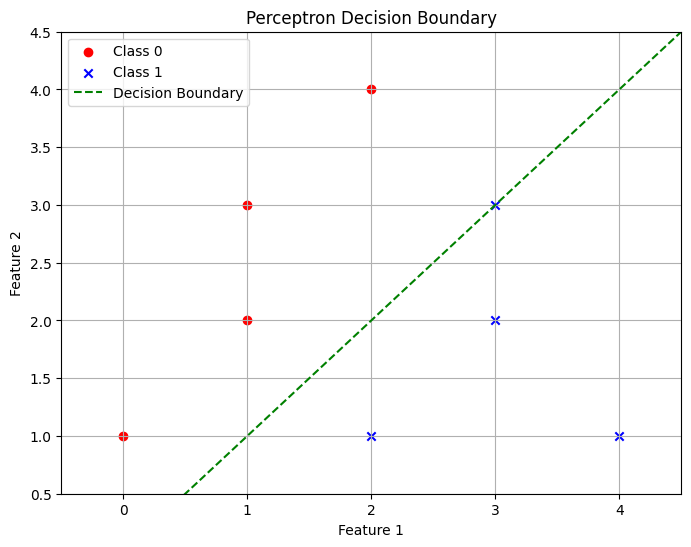


Actual labels: [1 1 1 1 0 0 0 0]
Predictions: [1 1 1 1 0 0 0 0]
Accuracy: 100.00%


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the step activation function
def step_function(z):
    return 1 if z >= 0 else 0

# Perceptron class
class Perceptron:
    def __init__(self, learning_rate=0.1, n_iterations=100):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        # Initialize weights and bias to zeros
        n_features = X.shape[1]
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Iterate for a number of epochs
        for _ in range(self.n_iterations):
            for idx, x_i in enumerate(X):
                # Calculate weighted sum + bias
                linear_output = np.dot(x_i, self.weights) + self.bias
                # Apply activation function
                prediction = step_function(linear_output)

                # Update weights and bias based on error
                update = self.learning_rate * (y[idx] - prediction)
                self.weights += update * x_i
                self.bias += update

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return np.array([step_function(z) for z in linear_output])

# --- Create a small, linearly separable dataset ---
X = np.array([
    [2, 1], [3, 2], [3, 3], [4, 1], # Class 1
    [1, 2], [1, 3], [2, 4], [0, 1]  # Class 0
])
y = np.array([1, 1, 1, 1, 0, 0, 0, 0])

# Create and train the Perceptron
perceptron = Perceptron(learning_rate=0.01, n_iterations=10)
perceptron.fit(X, y)

# --- Visualize the decision boundary ---
plt.figure(figsize=(8, 6))

# Plot the data points
plt.scatter(X[y == 0, 0], X[y == 0, 1], color='red', marker='o', label='Class 0')
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', marker='x', label='Class 1')

# Plot the decision boundary
# The decision boundary is given by w1*x1 + w2*x2 + b = 0
# So, x2 = (-w1*x1 - b) / w2
if perceptron.weights[1] != 0:
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    line_x = np.linspace(x1_min, x1_max, 100)
    line_y = (-perceptron.weights[0] * line_x - perceptron.bias) / perceptron.weights[1]
    plt.plot(line_x, line_y, color='green', linestyle='--', label='Decision Boundary')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Perceptron Decision Boundary')
plt.legend()
plt.grid(True)
plt.xlim(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5)
plt.ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)
plt.show()

# Test the trained perceptron
predictions = perceptron.predict(X)
print("\nActual labels:", y)
print("Predictions:", predictions)
print(f"Accuracy: {np.mean(predictions == y) * 100:.2f}%")

### Summary with comparison plots

This plot effectively visualizes how a simple Perceptron draws a linear decision boundary to separate two classes in a 2D feature space. The green dashed line represents the learned boundary, correctly classifying all the red circles (Class 0) and blue crosses (Class 1) in this linearly separable dataset. This demonstrates the fundamental ability of a single neuron to perform binary classification.

## 2. Perceptron

### Definition
A Perceptron is the simplest form of a feed-forward neural network and a fundamental building block for more complex neural architectures. Introduced by Frank Rosenblatt in 1957, it is a binary linear classifier that takes multiple binary or real-valued inputs, computes a weighted sum of these inputs, adds a bias, and then passes the result through an activation function (typically a step function) to produce a single binary output. Its primary function is to classify data into one of two categories based on a linear decision boundary. It learns by adjusting its weights and bias through an iterative process to correctly classify training examples.

### Why it's needed
The Perceptron, while simple, laid the groundwork for modern neural networks. It was developed to solve **binary classification problems**, particularly to model how a biological neuron might make decisions. Before perceptrons, solving such problems often involved complex, hand-engineered rules. The Perceptron introduced the idea of a learning algorithm that could automatically adjust its internal parameters (weights and bias) from data, making it an early pioneer in adaptive machine learning. It demonstrated that a machine could learn to classify inputs based on examples, rather than being explicitly programmed with rules for every possible scenario. This capability is crucial for tasks where data patterns are too complex for human-defined rules.

### Intuition
Imagine you're at a gate, and you need to decide whether to let someone pass. You have a few pieces of information, like their ID badge, their uniform, and if they're on a list. Each piece of information has a certain importance (weight), and if the combined 'score' of all these pieces of information crosses a certain threshold (bias), you let them pass (output 1); otherwise, you don't (output 0).

That's essentially what a Perceptron does:

1.  **Inputs**: These are the pieces of information (features) it receives.
2.  **Weights**: Each input is assigned a 'weight' reflecting its importance. More important factors get higher weights.
3.  **Summation**: All weighted inputs are added together, and a 'bias' value is also added. This bias acts like an adjustable baseline or threshold.
4.  **Decision (Activation Function)**: The sum is then passed through a simple 'decision function' (like a step function). If the sum is above a certain threshold, the neuron 'fires' (outputs 1); otherwise, it stays 'silent' (outputs 0).

**Learning**: If the Perceptron makes a wrong decision, it adjusts the weights and bias slightly, trying to make a better decision next time. It learns by making errors and correcting them, gradually improving its ability to separate the two classes.

### Math

The Perceptron's mathematical operation is straightforward, mimicking a decision-making process. It involves a weighted sum of inputs and a thresholding function.

For a Perceptron with $n$ input features $x_1, x_2, \dots, x_n$:

1.  **Input Signals**: Each input $x_i$ is received.
2.  **Weighted Sum**: Each input $x_i$ is multiplied by its corresponding weight $w_i$. These products are then summed up.
3.  **Bias Addition**: A bias term $b$ is added to the weighted sum. The bias acts as an offset or a 'threshold' that needs to be overcome for the neuron to activate.
4.  **Activation Function**: The total sum (weighted sum + bias) is then passed through an activation function, typically a **step function** for a classic Perceptron. This function determines the final binary output (0 or 1).

### Formula

The mathematical formula for a single Perceptron can be broken down into two main parts:

1. **Net Input Calculation (Pre-activation):**

   This calculates the weighted sum of inputs plus the bias.

   $$
   z
   =
   (x_1w_1+x_2w_2+\cdots+x_nw_n)+b
   $$

   This can be compactly written using summation notation as:

   $$
   z
   =
   \sum_{i=1}^{n}x_iw_i+b
   $$

   Or, using vector notation:

   $$
   z
   =
   \mathbf{w}^T\mathbf{x}+b
   $$

   Where:

   * $\mathbf{x}$ is the input vector $(x_1,x_2,\dots,x_n)^T$.
   * $\mathbf{w}$ is the weight vector $(w_1,w_2,\dots,w_n)^T$.
   * $b$ is the bias term.

2. **Output Activation (Step Function):**

   The net input $z$ is then passed through an activation function, commonly a **binary step function** (also called the **Heaviside step function**) for a Perceptron.

   $$
   y=f(z)
   $$

   where

   $$
   f(z)=
   \begin{cases}
   1, & \text{if } z\ge0,\\[6pt]
   0, & \text{if } z<0.
   \end{cases}
   $$

So, the final output $y$ of the Perceptron is

$$
y=
\begin{cases}
1,
&
\text{if }
\left(
\displaystyle\sum_{i=1}^{n}x_iw_i+b
\right)
\ge0,
\\[10pt]
0,
&
\text{if }
\left(
\displaystyle\sum_{i=1}^{n}x_iw_i+b
\right)
<0.
\end{cases}
$$

This formula effectively draws a linear decision boundary in the input space, separating the inputs into two classes.

### Numerical Example
Let's use the same example from the Neural Network section but explicitly frame it in the context of a Perceptron.

**Given:**
*   Inputs: $x_1 = 0.5$, $x_2 = 0.8$
*   Weights: $w_1 = 0.3$, $w_2 = 0.6$
*   Bias: $b = -0.2$
*   Activation Function (Binary Step): $f(z) = 1$ if $z \ge 0$, else $0$

**Calculation:**

1.  **Calculate the net input ($z$):**
    $z = (x_1 \cdot w_1) + (x_2 \cdot w_2) + b$
    $z = (0.5 \cdot 0.3) + (0.8 \cdot 0.6) + (-0.2)$
    $z = 0.15 + 0.48 - 0.2$
    $z = 0.63 - 0.2$
    $z = 0.43$

2.  **Apply the step activation function ($f(z)$):**
    Since $z = 0.43 \ge 0$, our binary step activation function yields:
    $y = f(0.43) = 1$

**Result:**

The Perceptron's output for these inputs, weights, and bias is **1**.

### Visualization
This is a visual representation of a single Perceptron's architecture and data flow.

                     Inputs

      x₁ ───────────────┐
      x₂ ───────────────┤
      x₃ ───────────────┤
      ⋮                 ├──────────────┐
      xₙ ───────────────┘              │
                                       ▼
                              ┌─────────────────┐
                              │ Weighted Sum    │
                              │ Σ(xᵢ · wᵢ) + b  │
                              └────────┬────────┘
                                       │
                                       ▼
                              ┌─────────────────┐
                              │ Activation f(z) │
                              │ Step Function   │
                              └────────┬────────┘
                                       │
                                       ▼
                              Predicted Output
                                   y = 0 / 1

**Explanation of the Visualization:**

*   **Inputs ($x_1, x_2$)**: The raw data features fed into the Perceptron.
*   **Weights ($w_1, w_2$)**: Parameters that multiply the input features, indicating their importance.
*   **Bias ($b$)**: An adjustable constant added to the weighted sum, influencing the activation threshold.
*   **Summation (Σ)**: This node calculates the net input ($z$) by summing the weighted inputs and the bias.
*   **Step Function $f(z)$**: The activation function that transforms the net input into a binary output (0 or 1), effectively making the classification decision.
*   **Output ($y$)**: The final binary prediction of the Perceptron.

### Pros

*   **Simplicity and Interpretability**: Perceptrons are very simple models, making them easy to understand and implement. Their decision boundary is a straight line or hyperplane, which is straightforward to visualize and interpret.
*   **Fast Training**: For linearly separable data, the Perceptron learning algorithm is guaranteed to converge in a finite number of steps, leading to quick training times.
*   **Foundation for Neural Networks**: They served as a crucial foundation for the development of more complex neural network architectures.
*   **Computational Efficiency**: Due to their simplicity, Perceptrons are computationally inexpensive during both training and inference compared to multi-layered networks.

### Cons

*   **Limited to Linearly Separable Data**: The most significant limitation of a single Perceptron is its inability to learn non-linear decision boundaries. It can only classify data that is linearly separable (i.e., data that can be perfectly separated by a single straight line or hyperplane). This means it cannot solve problems like the XOR problem.
*   **Binary Output Only**: A single Perceptron can only produce a binary output (0 or 1), limiting its application to binary classification tasks.
*   **No Probabilistic Output**: It provides a hard classification, not a probability score, which can be less informative for certain applications.
*   **Sensitivity to Input Scaling**: Perceptrons can be sensitive to the scale of input features, as weights are updated proportionally to the input values.
*   **Fixed Decision Boundary**: Once trained, the decision boundary is fixed. It doesn't provide information about the confidence of the classification.

### Time Complexity

The time complexity of a Perceptron is relatively low due to its simple architecture.

**1. Training Time Complexity:**

For the Perceptron learning algorithm, the number of updates (and thus iterations) required for convergence for a linearly separable dataset is finite. Let $D$ be the dimensionality of the input features, and $N$ be the number of training samples.

*   **Perceptron Update Rule**: In each iteration, for each misclassified sample, the weights and bias are updated. This update involves operations proportional to the number of features $D$.
*   **Number of Iterations**: While it's guaranteed to converge for linearly separable data, the exact number of iterations can vary. In the worst case, it can be relatively high but is still polynomial in certain parameters related to the separability of the data.

Overall, for a dataset with $N$ samples and $D$ features, and $E$ epochs (or until convergence), the training complexity is approximately $O(E \cdot N \cdot D)$. If the data is linearly separable, $E$ is finite.

**2. Inference Time Complexity:**

For making a prediction on a single new input sample, the Perceptron performs a single weighted sum and applies the activation function.

*   **Weighted Sum**: Involves $D$ multiplications and $D-1$ additions.
*   **Activation Function**: A single comparison.

Therefore, the inference time complexity for a single sample is $O(D)$, which is very fast.

## 3. Activation Functions

### Definition

An **activation function** in a neural network is a non-linear function that is applied to the output of a neuron (the weighted sum of inputs plus bias). It introduces non-linearity into the network, allowing it to learn complex patterns and represent non-linear relationships in the data. Without activation functions, a neural network, regardless of its depth, would simply behave as a linear regression model, as the composition of multiple linear functions is still a linear function.

Key characteristics of activation functions:

*   **Non-linearity**: This is crucial for solving non-linear problems. Without it, the network could only learn linear transformations.
*   **Differentiability**: Required for backpropagation, the algorithm used to train neural networks, as it relies on calculating gradients.
*   **Range**: The output range of the activation function can influence the stability and convergence of training.

Common activation functions include Sigmoid, Tanh, ReLU, Leaky ReLU, ELU, and Softmax, each with its own advantages and use cases.

### Why it's needed

Activation functions are a critical component of neural networks primarily because they introduce **non-linearity** into the model. Here's why this is absolutely essential:

1.  **Modeling Complex Relationships**: Without activation functions, a neural network, no matter how many layers it has, would essentially be performing a series of linear transformations. The composition of multiple linear functions is still just a linear function ($f(g(x))$ where $f$ and $g$ are linear is still linear). This means the network would only be capable of learning linear relationships between inputs and outputs, severely limiting its ability to model real-world data, which is inherently complex and non-linear (e.g., image recognition, natural language processing).

2.  **Learning Hierarchical Representations**: Non-linearity allows the network to learn and represent hierarchical features. Each layer can transform the input in a non-linear way, extracting progressively more abstract and meaningful features. For example, in image recognition, early layers might detect edges, middle layers might combine edges into shapes, and deeper layers might recognize objects from these shapes. This hierarchical learning is only possible with non-linear activation.

3.  **Enabling Backpropagation**: Many activation functions are differentiable, which is a fundamental requirement for the backpropagation algorithm. Backpropagation is the process by which neural networks learn by calculating the gradient of the loss function with respect to the weights and biases, and then updating these parameters to minimize the loss. Without differentiable activation functions, this gradient-based optimization would not be possible.

4.  **Controlling Output Range**: Activation functions also help to scale the output of neurons. Some functions, like Sigmoid or Tanh, compress the output into a specific range (e.g., [0, 1] or [-1, 1]), which can be beneficial for certain tasks (like probability prediction) or for ensuring numerical stability during training.

In essence, activation functions provide the neural network with the power to learn from and make sense of complex, non-linear data, moving it beyond the limitations of simple linear models.

### Intuition

Imagine a neuron as a gatekeeper in a decision-making process. It receives various signals (inputs), weighs their importance, and sums them up. Now, what does this gatekeeper do with that sum?

*   **Without an Activation Function (Linear Gatekeeper)**: If the gatekeeper simply passed on the raw sum, or a scaled version of it, every decision it made would be a simple 'yes' or 'no' along a straight line. If you had many such gatekeepers connected, their combined decisions would still just be linear. This means they could only solve very simple problems, like distinguishing between things that are neatly separated by a straight line. They couldn't understand complex patterns like circles or intricate shapes, because their 'decisions' are always flat.

*   **With an Activation Function (Non-Linear Gatekeeper)**: This is where the activation function comes in. It's like adding a special 'filter' or 'reaction' to the gatekeeper's decision process. Instead of just a simple 'pass-through,' the gatekeeper now reacts to the sum in a more nuanced way.
    *   **

    *   **Threshold (like Perceptron's step function)**: "If the sum is below this, ignore it (0). If it's above, send a strong signal (1)." This creates a sharp, non-linear boundary.
    *   **Smooth Curve (like Sigmoid or Tanh)**: "If the sum is very low, send a weak signal close to 0 (or -1). As the sum increases, gradually increase the signal, but never beyond a certain maximum (or minimum)." This allows for graded responses, where small changes in input can lead to small, smooth changes in output.
    *   **ReLU (Rectified Linear Unit)**: "If the sum is negative, ignore it (0). If it's positive, pass it through directly." This creates a 'switch' effect – the neuron is either off or fully engaged, but in a non-linear way.

This 'reaction' or 'filter' makes the neuron behave non-linearly. When you connect many such non-linear gatekeepers, they can collaboratively learn to recognize incredibly complex, curved, and intertwined patterns that a simple linear system could never distinguish. It's what allows neural networks to learn to identify cats in images, understand human speech, or translate languages – tasks far beyond simple linear separation.

### Math

The role of an activation function $f$ is to transform the weighted sum of inputs and bias (often called the 'net input' or 'pre-activation') $z$ into an output for the neuron. Mathematically, for a given neuron, if the inputs are $x_1, x_2, \dots, x_n$ with corresponding weights $w_1, w_2, \dots, w_n$ and a bias $b$, the net input $z$ is calculated as:

$$z = \sum_{i=1}^{n} (x_i w_i) + b$$

Then, the output of the neuron, often denoted as $a$ (for activation) or $y$, is given by applying the activation function to $z$:

$$a = f(z)$$

The specific form of $f(z)$ varies depending on the type of activation function used. Here, we'll briefly cover the mathematical expressions for some common activation functions.

### Formula

As established, the output of a neuron is $a = f(z)$, where $z = \sum_{i=1}^{n} (x_i w_i) + b$. The form of $f(z)$ defines the specific activation function. Here are the formulas for some of the most widely used activation functions:

---

#### 1. Sigmoid (Logistic) Function

*   **Formula**: $f(z) = \frac{1}{1 + e^{-z}}$
*   **Range**: $(0, 1)$
*   **Derivative**: $f'(z) = f(z) \cdot (1 - f(z))$

#### 2. Tanh (Hyperbolic Tangent) Function

*   **Formula**: $f(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$ or $f(z) = 2 \cdot \text{Sigmoid}(2z) - 1$
*   **Range**: $(-1, 1)$
*   **Derivative**: $f'(z) = 1 - (f(z))^2$

#### 3. ReLU (Rectified Linear Unit) Function

*   **Formula**: $f(z) = \max(0, z)$
*   **Range**: $[0, \infty)$
*   **Derivative**: $f'(z) = \begin{cases} 1 & \text{if } z > 0 \\ 0 & \text{if } z \le 0 \end{cases}$
    *Note: The derivative at $z=0$ is technically undefined, but in practice, it's often treated as 0 or 1. Some implementations use 0, others use 1, or rely on subgradient.*

#### 4. Leaky ReLU Function

*   **Formula**: $f(z) = \begin{cases} z & \text{if } z > 0 \\ \alpha z & \text{if } z \le 0 \end{cases}$, where $\alpha$ is a small positive constant (e.g., 0.01).
*   **Range**: $(-\infty, \infty)$
*   **Derivative**: $f'(z) = \begin{cases} 1 & \text{if } z > 0 \\ \alpha & \text{if } z \le 0 \end{cases}$

#### 5. ELU (Exponential Linear Unit) Function

*   **Formula**: $f(z) = \begin{cases} z & \text{if } z > 0 \\ \alpha (e^z - 1) & \text{if } z \le 0 \end{cases}$, where $\alpha$ is a positive constant.
*   **Range**: $(-\alpha, \infty)$
*   **Derivative**: $f'(z) = \begin{cases} 1 & \text{if } z > 0 \\ \alpha e^z & \text{if } z \le 0 \end{cases}$

#### 6. Softmax Function (for Output Layer of Multi-class Classification)

*    **Formula**: For a vector of $K$ inputs $z=[z_1,z_2,\dots,z_K]$, the Softmax function calculates the probability of each class:

  $$
  P(y=j \mid z)=\frac{e^{z_j}}{\sum_{k=1}^{K} e^{z_k}}
  $$
*   **Range**: $(0, 1)$ for each component, and $\sum_{j=1}^{K} P(y=j|z) = 1$.
*   **Derivative**: The derivative is more complex as it depends on all inputs in the vector $z$. For $j=k$, $\frac{\partial P(y=j|z)}{\partial z_k} = P(y=j|z) (1 - P(y=j|z))$, and for $j \ne k$, $\frac{\partial P(y=j|z)}{\partial z_k} = -P(y=j|z) P(y=k|z)$.

### Numerical Example

Let's consider a neuron that has calculated its weighted sum of inputs plus bias, resulting in a pre-activation value $z$. We will see how different activation functions transform this $z$ into an output $a$.

Suppose we have three different pre-activation values:

1.  **$z_1 = 0.5$**
2.  **$z_2 = -2.0$**
3.  **$z_3 = 3.0$**

We'll apply the following common activation functions:

*   **Sigmoid**
*   **Tanh**
*   **ReLU**
*   **Leaky ReLU** (with $\alpha = 0.01$)
*   **ELU** (with $\alpha = 1.0$)

---

**Calculations:**

#### 1. Sigmoid Function ($f(z) = \frac{1}{1 + e^{-z}}$)

*   $a_1 = \frac{1}{1 + e^{-0.5}} \approx \frac{1}{1 + 0.6065} \approx \frac{1}{1.6065} \approx 0.622$
*   $a_2 = \frac{1}{1 + e^{-(-2.0)}} = \frac{1}{1 + e^{2.0}} \approx \frac{1}{1 + 7.389} \approx \frac{1}{8.389} \approx 0.119$
*   $a_3 = \frac{1}{1 + e^{-3.0}} \approx \frac{1}{1 + 0.0498} \approx \frac{1}{1.0498} \approx 0.953$

#### 2. Tanh Function ($f(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$)

*   $a_1 = \frac{e^{0.5} - e^{-0.5}}{e^{0.5} + e^{-0.5}} \approx \frac{1.6487 - 0.6065}{1.6487 + 0.6065} \approx \frac{1.0422}{2.2552} \approx 0.462$
*   $a_2 = \frac{e^{-2.0} - e^{2.0}}{e^{-2.0} + e^{2.0}} \approx \frac{0.1353 - 7.389}{0.1353 + 7.389} \approx \frac{-7.2537}{7.5243} \approx -0.964$
*   $a_3 = \frac{e^{3.0} - e^{-3.0}}{e^{3.0} + e^{-3.0}} \approx \frac{20.0855 - 0.0498}{20.0855 + 0.0498} \approx \frac{20.0357}{20.1353} \approx 0.995$

#### 3. ReLU Function ($f(z) = \max(0, z)$)

*   $a_1 = \max(0, 0.5) = 0.5$
*   $a_2 = \max(0, -2.0) = 0.0$
*   $a_3 = \max(0, 3.0) = 3.0$

#### 4. Leaky ReLU Function ($\alpha = 0.01$)

*   $a_1 = 0.5$ (since $z_1 > 0$)
*   $a_2 = 0.01 \cdot (-2.0) = -0.02$ (since $z_2 \le 0$)
*   $a_3 = 3.0$ (since $z_3 > 0$)

#### 5. ELU Function ($\alpha = 1.0$)

*   $a_1 = 0.5$ (since $z_1 > 0$)
*   $a_2 = 1.0 \cdot (e^{-2.0} - 1) \approx 1.0 \cdot (0.1353 - 1) = -0.8647$ (since $z_2 \le 0$)
*   $a_3 = 3.0$ (since $z_3 > 0$)

---

**Summary of Outputs:**

| Input (z) | Sigmoid (a) | Tanh (a) | ReLU (a) | Leaky ReLU (a) | ELU (a) |
| :-------- | :---------- | :------- | :------- | :------------- | :------ |
| **0.5**   | 0.622       | 0.462    | 0.5      | 0.5            | 0.5     |
| **-2.0**  | 0.119       | -0.964   | 0.0      | -0.02          | -0.865  |
| **3.0**   | 0.953       | 0.995    | 3.0      | 3.0            | 3.0     |

This example demonstrates how each activation function produces a different output for the same input, highlighting their unique non-linear transformations and output ranges.

### Visualization

Let's visualize the behavior of the most common activation functions over a range of input values. This will clearly show their non-linear characteristics and their respective output ranges.

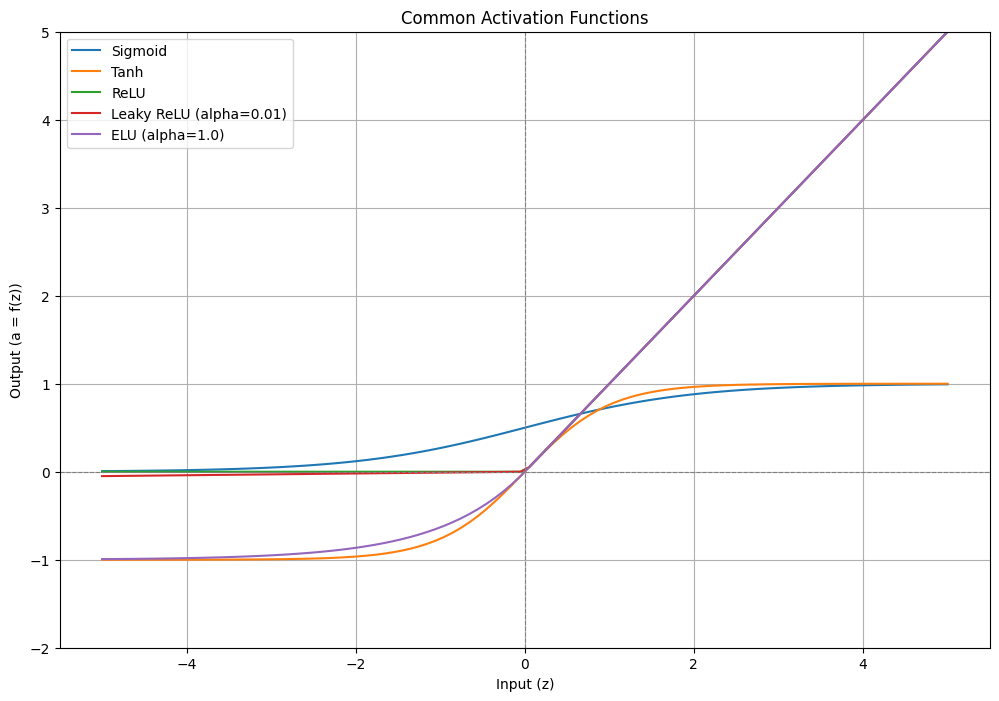

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define the activation functions
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def tanh(z):
    return np.tanh(z)

def relu(z):
    return np.maximum(0, z)

def leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)

def elu(z, alpha=1.0):
    return np.where(z > 0, z, alpha * (np.exp(z) - 1))

# Generate input values (z)
z = np.linspace(-5, 5, 100)

# Calculate outputs for each activation function
a_sigmoid = sigmoid(z)
a_tanh = tanh(z)
a_relu = relu(z)
a_leaky_relu = leaky_relu(z)
a_elu = elu(z)

# Create the plot
plt.figure(figsize=(12, 8))

plt.plot(z, a_sigmoid, label='Sigmoid')
plt.plot(z, a_tanh, label='Tanh')
plt.plot(z, a_relu, label='ReLU')
plt.plot(z, a_leaky_relu, label='Leaky ReLU (alpha=0.01)')
plt.plot(z, a_elu, label='ELU (alpha=1.0)')

plt.title('Common Activation Functions')
plt.xlabel('Input (z)')
plt.ylabel('Output (a = f(z))')
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8) # Add a vertical line at z=0
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Add a horizontal line at a=0
plt.legend()
plt.grid(True)
plt.ylim(-2, 5) # Adjust y-axis limits for better visualization
plt.show()

### Python Code with plots (small dataset for understanding current topic)

Let's visualize not only the activation functions but also their **derivatives**. The derivatives are crucial for understanding how gradients flow during backpropagation, which directly relates to issues like vanishing or exploding gradients mentioned in the 'Cons' section.

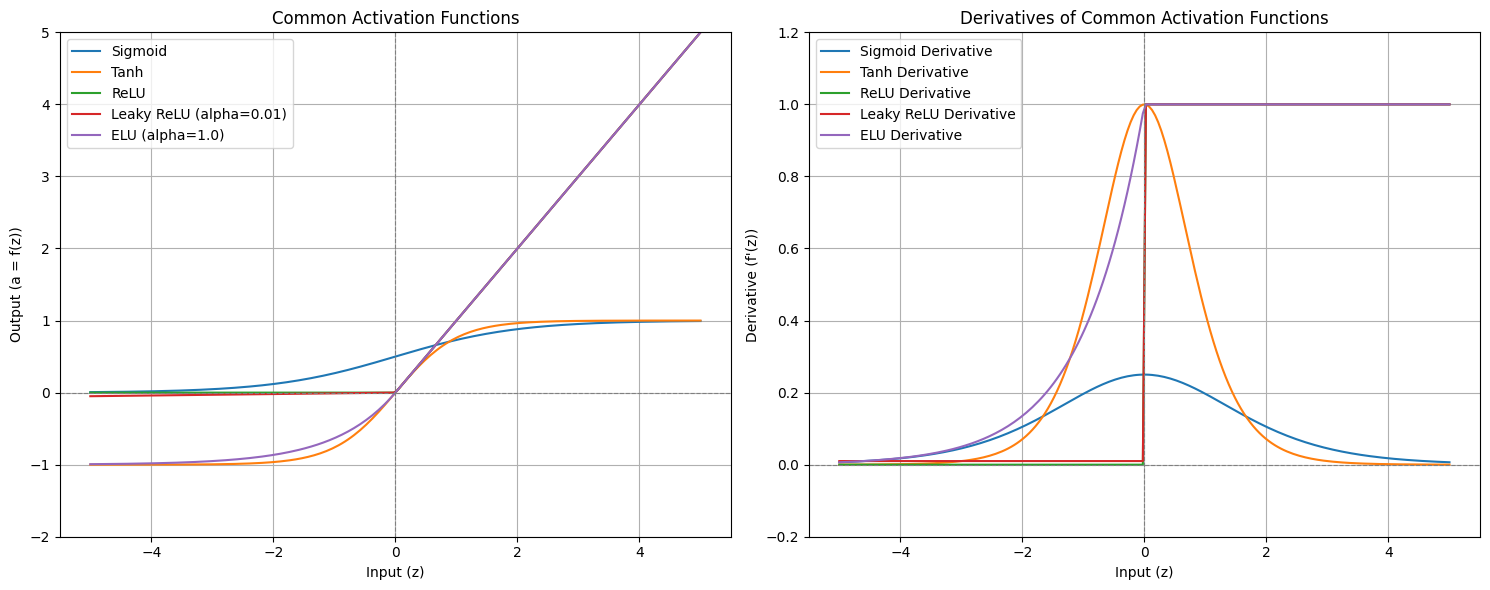

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- Define Activation Functions and their Derivatives ---

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

def tanh(z):
    return np.tanh(z)

def tanh_derivative(z):
    return 1 - (np.tanh(z))**2

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return np.where(z > 0, 1, 0)

def leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)

def leaky_relu_derivative(z, alpha=0.01):
    return np.where(z > 0, 1, alpha)

def elu(z, alpha=1.0):
    return np.where(z > 0, z, alpha * (np.exp(z) - 1))

def elu_derivative(z, alpha=1.0):
    return np.where(z > 0, 1, alpha * np.exp(z))

# --- Generate Input Values ---
z = np.linspace(-5, 5, 200)

# --- Create the plot for Functions ---
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(z, sigmoid(z), label='Sigmoid')
plt.plot(z, tanh(z), label='Tanh')
plt.plot(z, relu(z), label='ReLU')
plt.plot(z, leaky_relu(z), label='Leaky ReLU (alpha=0.01)')
plt.plot(z, elu(z), label='ELU (alpha=1.0)')

plt.title('Common Activation Functions')
plt.xlabel('Input (z)')
plt.ylabel('Output (a = f(z))')
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.legend()
plt.grid(True)
plt.ylim(-2, 5)

# --- Create the plot for Derivatives ---
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(z, sigmoid_derivative(z), label='Sigmoid Derivative')
plt.plot(z, tanh_derivative(z), label='Tanh Derivative')
plt.plot(z, relu_derivative(z), label='ReLU Derivative')
plt.plot(z, leaky_relu_derivative(z), label='Leaky ReLU Derivative')
plt.plot(z, elu_derivative(z), label='ELU Derivative')

plt.title('Derivatives of Common Activation Functions')
plt.xlabel('Input (z)')
plt.ylabel("Derivative (f'(z))")
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.legend()
plt.grid(True)
plt.ylim(-0.2, 1.2) # Adjust y-axis limits for better visualization of derivatives

plt.tight_layout()
plt.show()

### Summary with comparison plots

The plots above offer a comprehensive visual comparison of several common activation functions and their derivatives.

**Key Observations from the Function Plots (Left):**
*   **Sigmoid**: Compresses outputs to `(0, 1)`, making it useful for binary classification output layers (interpretable as probabilities). It's smooth but saturates at extremes.
*   **Tanh**: Similar to Sigmoid but outputs values in `(-1, 1)`, which is zero-centered and often performs better than Sigmoid in hidden layers.
*   **ReLU**: Simple, outputs 0 for negative inputs and the input itself for positive values. It avoids saturation for positive inputs, which helps with vanishing gradients. However, it suffers from the 'dying ReLU' problem for negative inputs.
*   **Leaky ReLU**: Addresses the 'dying ReLU' problem by allowing a small, non-zero gradient for negative inputs (`alpha * z`).
*   **ELU**: Similar to Leaky ReLU but uses an exponential function for negative inputs, providing smoother transitions and often leading to better convergence.

**Key Observations from the Derivative Plots (Right):**
*   **Sigmoid and Tanh Derivatives**: Their derivatives are bell-shaped and approach zero as `|z|` increases. This visually demonstrates the **vanishing gradient problem**: for very large or very small `z` values, the gradients become tiny, leading to very small weight updates during backpropagation, hindering learning in deep networks.
*   **ReLU Derivative**: It's 1 for `z > 0` and 0 for `z <= 0`. This constant gradient for positive inputs helps to mitigate vanishing gradients. However, the zero gradient for negative inputs illustrates the 'dying ReLU' problem, where neurons can stop learning.
*   **Leaky ReLU Derivative**: It's 1 for `z > 0` and a small positive constant (`alpha`) for `z <= 0`. This addresses the dying ReLU problem by ensuring a non-zero gradient even for negative inputs, allowing for some learning.
*   **ELU Derivative**: It's 1 for `z > 0` and `alpha * exp(z)` for `z <= 0`. For negative `z`, the derivative smoothly approaches zero, but it avoids the hard zero of ReLU, contributing to better learning and avoiding the dying ReLU issue while maintaining zero-centered outputs.

### Pros

Activation functions are indispensable components of neural networks, offering several significant advantages:

1.  **Introduces Non-linearity**: This is the most crucial advantage. Without non-linear activation functions, a neural network, regardless of its depth, would only be able to learn linear relationships. Non-linearity allows networks to approximate any complex function and model intricate patterns in data, making them capable of solving highly complex tasks like image recognition, natural language understanding, and more.

2.  **Enables Learning of Complex Features**: By introducing non-linearity, activation functions allow hidden layers to learn increasingly complex and abstract representations of the input data. Each layer can transform the data in a non-linear way, building hierarchical features from simple ones (e.g., edges to shapes to objects).

3.  **Facilitates Backpropagation**: Most widely used activation functions are differentiable, which is a fundamental requirement for the backpropagation algorithm. Backpropagation relies on computing gradients to update network weights and biases, and differentiability ensures that these gradients can be calculated.

4.  **Controls Output Range**: Some activation functions (like Sigmoid and Tanh) map the output of neurons to a specific, bounded range. This can be beneficial for stabilizing gradients, preventing outputs from exploding, and interpreting outputs (e.g., as probabilities in the case of Sigmoid in the output layer).

5.  **Handles Vanishing Gradients (especially ReLU and its variants)**: Functions like ReLU (Rectified Linear Unit) help mitigate the vanishing gradient problem in deep networks. For positive inputs, ReLU's derivative is constant (1), allowing gradients to flow more effectively through many layers, accelerating training convergence compared to Sigmoid or Tanh.

### Cons

While activation functions are essential, they also come with certain disadvantages and can introduce challenges in neural network training:

1.  **Vanishing Gradients (Sigmoid and Tanh)**: For activation functions like Sigmoid and Tanh, when the input $z$ is very large (positive or negative), the derivative becomes very close to zero. During backpropagation, these small gradients get multiplied through many layers, causing the gradients in earlier layers to become extremely small and effectively 'vanish.' This means the weights in initial layers are updated minimally or not at all, hindering the network's ability to learn long-range dependencies.

2.  **Exploding Gradients (less common with proper initialization, but possible)**: Conversely, if the gradients become very large, they can 'explode,' leading to very large weight updates that destabilize the network and cause it to diverge. This is less tied to the activation function itself than vanishing gradients, but can be exacerbated by certain network configurations.

3.  **Dying ReLU Problem**: For ReLU and its variants, if a neuron outputs a negative value for all inputs in a given batch, its gradient becomes zero (for ReLU) or very small (for Leaky ReLU/ELU). Once a ReLU neuron outputs zero, it stops learning because its gradient is zero. This neuron effectively 'dies' and stops contributing to the network's learning. If many neurons suffer from this, the network's capacity can be severely reduced.

4.  **Not Zero-Centered Output (Sigmoid and ReLU)**: Sigmoid outputs are always positive (0 to 1). This can lead to issues during optimization because gradients for weights in subsequent layers will all have the same sign (either all positive or all negative). This can cause a zig-zagging effect during gradient descent, slowing down convergence. Tanh, being zero-centered, mitigates this.

5.  **Computational Cost**: While generally efficient, some more complex activation functions (like Softmax, which involves exponentials and division over multiple outputs) can be slightly more computationally intensive than simpler ones like ReLU. This becomes more noticeable in very large networks.

6.  **Choosing the Right Activation Function**: There is no one-size-fits-all activation function. The choice often depends on the specific problem, network architecture, and dataset. Experimentation and empirical knowledge are often required to select the most effective activation function, which can add to the complexity of model design.

### Time Complexity

The time complexity of an activation function refers to the computational resources (primarily time) required to compute its output for a given input, as well as its derivative (which is needed during backpropagation). In general, the computation for a single activation function is very fast, often considered $O(1)$ for practical purposes in a high-level analysis. However, when considering a large number of neurons and their derivatives, the aggregate cost can become a factor.

Here's a breakdown for common activation functions:

1.  **Binary Step Function (Perceptron)**:
    *   **Forward Pass**: $O(1)$ (a single comparison).
    *   **Backward Pass (Derivative)**: $O(1)$ (derivative is 0 or undefined, handled by convention).
    *   **Notes**: Extremely fast, but not differentiable at 0, which makes it unsuitable for gradient-based optimization in multi-layer networks.

2.  **Sigmoid and Tanh Functions**:
    *   **Forward Pass**: $O(1)$ (involves exponentiation, division, and addition/subtraction). These are slightly more complex than ReLU but still constant time.
    *   **Backward Pass (Derivative)**: $O(1)$ (their derivatives can be expressed in terms of the function's output, making them efficient to compute).
    *   **Notes**: The exponentiation operation is generally more computationally expensive than basic arithmetic operations.

3.  **ReLU (Rectified Linear Unit) Function**:
    *   **Forward Pass**: $O(1)$ (a single comparison and potential identity operation or zero assignment, e.g., `max(0, z)`).
    *   **Backward Pass (Derivative)**: $O(1)$ (derivative is 0 or 1, a simple comparison).
    *   **Notes**: Very computationally efficient, making it popular in deep networks. It avoids the expensive exponentiation of Sigmoid/Tanh.

4.  **Leaky ReLU and ELU Functions**:
    *   **Forward Pass**: $O(1)$ (similar to ReLU, involves a comparison, and for the negative part, a multiplication (Leaky ReLU) or exponentiation (ELU)). ELU is slightly more expensive due to `exp(z)`.
    *   **Backward Pass (Derivative)**: $O(1)$ (simple conditional checks and constant or exponential calculation for the derivative).
    *   **Notes**: Generally very efficient, with ELU being slightly more complex than Leaky ReLU due to the exponential term for negative inputs.

5.  **Softmax Function** (typically used in the output layer for multi-class classification):
    *   **Forward Pass**: For an output layer with $K$ classes, the Softmax function involves $K$ exponentiations, $K-1$ additions for the sum in the denominator, and $K$ divisions. Its complexity is $O(K)$.
    *   **Backward Pass (Derivative)**: The derivative calculation for Softmax is more involved as each output depends on all inputs to the Softmax layer. This typically involves matrix-vector products, resulting in $O(K^2)$ complexity for the gradient computation for a vector of outputs.
    *   **Notes**: This is generally the most computationally intensive activation function listed here, especially as the number of classes $K$ increases.

**Overall Impact**: While the time complexity for a single neuron's activation is small, in a neural network with thousands or millions of neurons across multiple layers, these operations are performed many times per training iteration. Therefore, using computationally efficient activation functions (like ReLU and its variants) can significantly speed up both training and inference times, especially in very deep and wide networks.

## 4. Loss Functions

### Definition

A **Loss Function** (also known as a Cost Function or Objective Function) is a mathematical function that quantifies the difference between the predicted output of a neural network and the actual (true) target values. In simpler terms, it measures how well the neural network is performing for a given set of weights and biases. The goal during the training of a neural network is to minimize this loss function, thereby making the network's predictions as close as possible to the true values.

Key characteristics of loss functions:

*   **Quantifies Error**: It provides a numerical measure of the error or discrepancy between predicted and actual values.
*   **Guidance for Optimization**: The value of the loss function, and more importantly its gradient, guides the optimization algorithm (like Gradient Descent) in adjusting the network's parameters (weights and biases) to improve performance.
*   **Task-Specific**: The choice of loss function is highly dependent on the type of task the neural network is performing (e.g., regression, binary classification, multi-class classification).

Common loss functions include Mean Squared Error (MSE), Mean Absolute Error (MAE), Binary Cross-Entropy, Categorical Cross-Entropy, and Huber Loss, each suited for different problems.

### Why it's needed

Loss functions are fundamental to the training and successful operation of neural networks for several critical reasons:

1.  **Quantifying Error/Performance**: The primary role of a loss function is to provide a quantifiable measure of how far off a model's predictions are from the actual target values. Without this numerical feedback, there would be no objective way to assess the model's current performance.

2.  **Guiding the Learning Process (Optimization)**: Neural network training is essentially an optimization problem, where the goal is to find the set of weights and biases that minimize the error. The loss function provides the 'signal' that guides this optimization. Optimization algorithms, such as Gradient Descent, calculate the **gradient** (the direction and magnitude of the steepest ascent) of the loss function with respect to the model's parameters. By moving in the opposite direction of the gradient, the model iteratively adjusts its parameters to reduce the loss.

3.  **Measuring Model Fitness**: A lower loss value generally indicates a better-performing model. By monitoring the loss during training, we can track the model's progress and identify potential issues like overfitting (where the loss on training data decreases but increases on validation data) or underfitting (where the loss remains high for both training and validation data).

4.  **Task Specificity**: Different machine learning tasks (e.g., regression, binary classification, multi-class classification) have different objectives, and thus require different ways of quantifying error. The choice of a specific loss function directly aligns the model's optimization goal with the requirements of the task. For instance, Mean Squared Error is suitable for regression where predicting continuous values is key, while Cross-Entropy is ideal for classification tasks where predicting probabilities of class membership is important.

5.  **Enabling Backpropagation**: As discussed with activation functions, backpropagation relies on the differentiability of the entire network's computations, including the loss function. The gradients computed by backpropagation start from the loss function and propagate backward through the layers, enabling the efficient update of all network parameters.

In essence, the loss function acts as the 'compass' and 'scorekeeper' for a neural network, telling it how well it's doing and in which direction to adjust its internal settings to improve its performance.

### Intuition

Imagine you are playing a game of 'Hot and Cold' where your goal is to find a hidden object. In the context of a neural network, the 'hidden object' is the perfect set of weights and biases that allow your model to make accurate predictions.

Here's how the intuition maps:

*   **Your Model's Prediction**: This is your current guess of where the object might be.
*   **Actual Value (True Target)**: This is the actual location of the hidden object.
*   **Loss Function**: This is the 'feedback' mechanism. When you make a guess, the loss function tells you *how far off* your guess is from the actual location. If you're far, the 'loss' is high (very 'cold'). If you're close, the 'loss' is low (very 'hot').
    *   It doesn't just say 'hot' or 'cold'; it gives you a precise numerical value: 'You are 5 units away' or 'You are 0.1 units away.'
*   **Minimizing Loss**: Your objective in the game is to get 'hotter' and eventually find the object. In a neural network, the training process is continuously trying to reduce this 'loss' value. By minimizing the loss, the network is effectively moving its 'guesses' (predictions) closer and closer to the 'actual location' (true targets).
*   **Gradient Descent (and optimization)**: This is how you adjust your search. If the loss function tells you that moving slightly to the left makes you 'hotter' (reduces loss), you'll move left. If moving right makes you 'colder' (increases loss), you'll avoid moving right in that direction. The loss function provides the 'direction' and 'magnitude' of the 'heat', guiding your adjustments (weight and bias updates) to reach the minimum error.

So, the loss function is the critical component that provides the model with constant, quantifiable feedback on its performance, allowing it to learn and improve over time, much like the 'hot and cold' signals guide you to the hidden object.

### Math

Mathematically, a loss function $L(\hat{y}, y)$ quantifies the penalty for a neural network's prediction $\hat{y}$ when the true target value is $y$. The goal of training is to find the set of model parameters (weights $W$ and biases $B$) that minimize this loss over the entire training dataset.

For a single training example $(x, y)$:

1. **Forward Pass**: The input $x$ is fed through the network to produce a prediction $\hat{y}$. This involves multiple layers of weighted sums and activation functions:

   $$
   \hat{y} = \text{Network}(x; W, B)
   $$

2. **Loss Calculation**: A loss function $L$ is applied to compare the prediction $\hat{y}$ with the true target $y$:

   $$
   \text{loss} = L(\hat{y}, y)
   $$

For a dataset with $M$ training examples, the **total loss** (or empirical risk) is typically calculated as the average loss over all individual examples:

$$ J(W, B) = \frac{1}{M} \sum_{i=1}^{M} L(\hat{y}^{(i)}, y^{(i)}) $$

Where:
*   $J(W, B)$ is the total loss (often called the cost function or objective function).
*   $M$ is the number of training examples.
*   $\hat{y}^{(i)}$ is the network's prediction for the $i$-th example.
*   $y^{(i)}$ is the true target for the $i$-th example.

The training process then involves iteratively adjusting $W$ and $B$ using optimization algorithms (like Gradient Descent) to find the values that minimize $J(W, B)$. This minimization relies on calculating the **gradient** of the loss function with respect to the parameters:

$$ \frac{\partial J}{\partial W} \quad \text{and} \quad \frac{\partial J}{\partial B} $$

These gradients indicate the direction in which the loss function is increasing most rapidly. To minimize the loss, we move in the opposite direction of the gradient.

Different types of tasks (regression, binary classification, multi-class classification) require different forms of $L(\hat{y}, y)$, each designed to penalize errors in a way that aligns with the specific problem objective.

### Formula

As established, a loss function $L(\hat{y}, y)$ quantifies the error between a model's prediction $\hat{y}$ and the true target $y$. The choice of formula depends heavily on the type of task (regression, binary classification, multi-class classification).

Here are the formulas for some widely used loss functions:

#### 1. Mean Squared Error (MSE) / L2 Loss

*   **Purpose**: Commonly used for **regression** problems.
*   **Formula (for a single sample)**: $L(\hat{y}, y) = (\hat{y} - y)^2$
*   **Formula (for $M$ samples)**: $J(W, B) = \frac{1}{M} \sum_{i=1}^{M} (\hat{y}^{(i)} - y^{(i)})^2$
*   **Characteristics**: Punishes large errors more severely than small ones due to the squaring term. This makes it sensitive to outliers.

#### 2. Mean Absolute Error (MAE) / L1 Loss

*   **Purpose**: Also used for **regression** problems, especially when robustness to outliers is desired.
*   **Formula (for a single sample)**: $L(\hat{y}, y) = |\hat{y} - y|$
*   **Formula (for $M$ samples)**: $J(W, B) = \frac{1}{M} \sum_{i=1}^{M} |\hat{y}^{(i)} - y^{(i)}|$
*   **Characteristics**: Provides a linear penalty for errors, making it less sensitive to outliers compared to MSE. However, its derivative is not smooth at zero, which can cause issues with gradient-based optimization.

#### 3. Binary Cross-Entropy (Log Loss)

*   **Purpose**: Used for **binary classification** problems (where the output is either 0 or 1). Requires the model output $\hat{y}$ to be a probability (often from a Sigmoid activation).
*   **Formula (for a single sample)**: $L(\hat{y}, y) = - [y \log(\hat{y}) + (1 - y) \log(1 - \hat{y})]$
*   **Formula (for $M$ samples)**: $J(W, B) = - \frac{1}{M} \sum_{i=1}^{M} [y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)})]$
*   **Characteristics**: Penalizes confident wrong predictions heavily. Approaches infinity as $\hat{y}$ approaches 0 when $y=1$, or $\hat{y}$ approaches 1 when $y=0$. Effective for probabilistic outputs.

#### 4. Categorical Cross-Entropy

*   **Purpose**: Used for **multi-class classification** problems (where there are more than two classes, and each sample belongs to exactly one class). Requires the model output $\hat{y}$ to be a probability distribution (often from a Softmax activation) and the true label $y$ to be one-hot encoded.
*   **Formula (for a single sample, with $K$ classes)**:

  $$
  L(\hat{y}, y)
  =
  -\sum_{j=1}^{K}
  y_j \log(\hat{y}_j)
  $$

  Where:
  - $y_j = 1$ if the true class is $j$, and $0$ otherwise.
  - $\hat{y}_j$ is the predicted probability for class $j$.
*   **Formula (for $M$ samples)**: $J(W, B) = - \frac{1}{M} \sum_{i=1}^{M} \sum_{j=1}^{K} y_j^{(i)} \log(\hat{y}_j^{(i)})$
*   **Characteristics**: Similar to Binary Cross-Entropy but extended for multiple classes. It effectively measures the difference between two probability distributions (true and predicted).

#### 5. Huber Loss (Smooth Mean Absolute Error)

*   **Purpose**: A robust loss function for **regression** that combines the best properties of MSE and MAE. It's quadratic for small errors and linear for large errors.
*   **Formula (for a single sample)**: $L_{\delta}(\hat{y}, y) = \begin{cases}
    \frac{1}{2}(\hat{y} - y)^2 & \text{if } |\hat{y} - y| \le \delta \\
    \delta (|\hat{y} - y| - \frac{1}{2}\delta) & \text{if } |\hat{y} - y| > \delta
\end{cases}$
    Where $\delta$ (delta) is a hyperparameter that defines the threshold between the quadratic and linear parts.
*   **Formula (for $M$ samples)**: $J(W, B) = \frac{1}{M} \sum_{i=1}^{M} L_{\delta}(\hat{y}^{(i)}, y^{(i)})$
*   **Characteristics**: Less sensitive to outliers than MSE, and smoother around zero than MAE, making it more robust for optimization.

### Numerical Example

Let's calculate the loss for various scenarios using the loss functions we've just discussed. We'll use simple predicted ($\hat{y}$) and true ($y$) values for single samples and small batches.

---

#### Scenario 1: Regression Example (Single Sample)

*   **True Value ($y$)**: $10.0$
*   **Predicted Value ($\hat{y}$)**: $9.5$

**1. Mean Squared Error (MSE)**
$L(\hat{y}, y) = (\hat{y} - y)^2 = (9.5 - 10.0)^2 = (-0.5)^2 = 0.25$

**2. Mean Absolute Error (MAE)**
$L(\hat{y}, y) = |\hat{y} - y| = |9.5 - 10.0| = |-0.5| = 0.5$

**3. Huber Loss (with $\delta = 1.0$)**
Since $|\hat{y} - y| = 0.5 \le \delta = 1.0$, we use the quadratic part:
$L_{\delta}(\hat{y}, y) = \frac{1}{2}(\hat{y} - y)^2 = \frac{1}{2}(9.5 - 10.0)^2 = \frac{1}{2}(-0.5)^2 = \frac{1}{2}(0.25) = 0.125$

---

#### Scenario 2: Regression Example (Batch of 3 Samples)

*   **True Values ($y$)**: $[10.0, 5.0, 12.0]$
*   **Predicted Values ($\hat{y}$)**: $[9.0, 5.5, 11.0]$

**1. Mean Squared Error (MSE)**
Individual errors: $(9.0-10.0)^2 = (-1.0)^2 = 1.0$
$(5.5-5.0)^2 = (0.5)^2 = 0.25$
$(11.0-12.0)^2 = (-1.0)^2 = 1.0$
Average MSE: $J = \frac{1}{3}(1.0 + 0.25 + 1.0) = \frac{2.25}{3} = 0.75$

**2. Mean Absolute Error (MAE)**
Individual errors: $|9.0-10.0| = |-1.0| = 1.0$
$|5.5-5.0| = |0.5| = 0.5$
$|11.0-12.0| = |-1.0| = 1.0$
Average MAE: $J = \frac{1}{3}(1.0 + 0.5 + 1.0) = \frac{2.5}{3} \approx 0.833$

---

#### Scenario 3: Binary Classification Example (Single Sample)

*   **True Label ($y$)**: $1$ (e.g., 'cat')
*   **Predicted Probability ($\hat{y}$)**: $0.85$ (probability of being 'cat')

**Binary Cross-Entropy**
$L(\hat{y}, y) = - [y \log(\hat{y}) + (1 - y) \log(1 - \hat{y})]$
$L(0.85, 1) = - [1 \cdot \log(0.85) + (1 - 1) \cdot \log(1 - 0.85)]$
$L(0.85, 1) = - [\log(0.85) + 0 \cdot \log(0.15)]$
$L(0.85, 1) = - \log(0.85) \approx -(-0.1625) = 0.1625$

Now consider if the prediction was confidently wrong:
*   **True Label ($y$)**: $1$
*   **Predicted Probability ($\hat{y}$)**: $0.15$

$L(0.15, 1) = - [1 \cdot \log(0.15) + 0 \cdot \log(0.85)] = - \log(0.15) \approx -(-1.897) = 1.897$
As expected, a confident wrong prediction yields a much higher loss.

---

#### Scenario 4: Multi-class Classification Example (Single Sample)

*   **True Label ($y$) (one-hot encoded)**: $[0, 1, 0]$ (e.g., class 2 is true)
*   **Predicted Probabilities ($\hat{y}$)**: $[0.1, 0.7, 0.2]$ (summing to 1)

**Categorical Cross-Entropy**
$L(\hat{y}, y) = - \sum_{j=1}^{K} y_j \log(\hat{y}_j)$
$L([0.1, 0.7, 0.2], [0, 1, 0]) = - [0 \cdot \log(0.1) + 1 \cdot \log(0.7) + 0 \cdot \log(0.2)]$
$L = - \log(0.7) \approx -(-0.3567) = 0.3567$

Now, if the model was wrong:
*   **True Label ($y$)**: $[0, 1, 0]$
*   **Predicted Probabilities ($\hat{y}$)**: $[0.8, 0.1, 0.1]$ (summing to 1)

$L([0.8, 0.1, 0.1], [0, 1, 0]) = - [0 \cdot \log(0.8) + 1 \cdot \log(0.1) + 0 \cdot \log(0.1)]$
$L = - \log(0.1) \approx -(-2.3025) = 2.3025$
Again, a confident wrong prediction (predicting 0.1 for the true class 1) results in a significantly higher loss value.

### Visualization

Let's visualize the behavior of some common loss functions to better understand how they penalize errors. We'll plot them against the error (difference between predicted and true values).

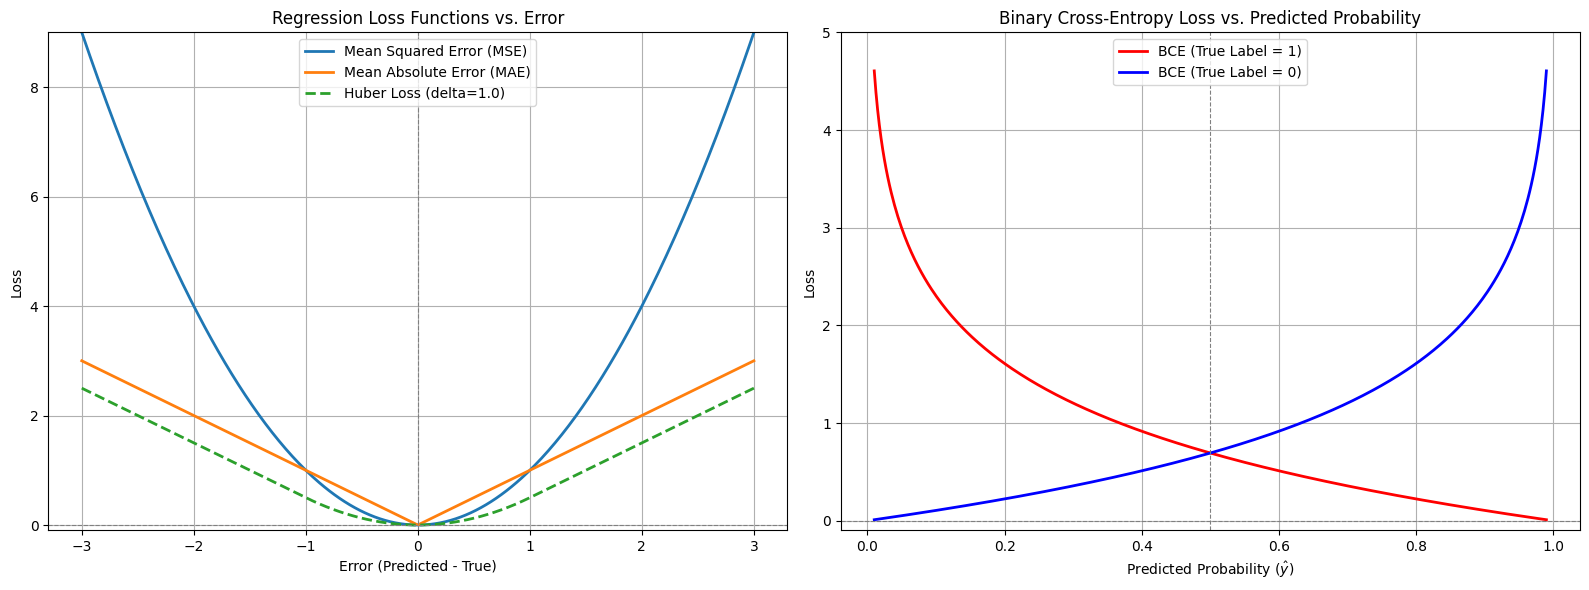

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Define the range of errors (difference between predicted and true value)
errors = np.linspace(-3, 3, 400)

# --- 1. Mean Squared Error (MSE) ---
mse_loss = errors**2

# --- 2. Mean Absolute Error (MAE) ---
mae_loss = np.abs(errors)

# --- 3. Huber Loss ---
def huber_loss_func(errors, delta=1.0):
    abs_errors = np.abs(errors)
    # Quadratic for small errors, linear for large errors
    return np.where(abs_errors <= delta,
                    0.5 * errors**2,
                    delta * (abs_errors - 0.5 * delta))

huber_loss = huber_loss_func(errors, delta=1.0)

# --- 4. Binary Cross-Entropy (BCE) ---
# For BCE, we typically plot against predicted probability given a true label.
# Let's assume true_label y = 1 for this visualization.
predicted_probabilities = np.linspace(0.01, 0.99, 400) # Avoid log(0)
epsilon = 1e-10 # Small value to prevent log(0)
bce_loss_true_1 = -np.log(predicted_probabilities + epsilon) # y=1
bce_loss_true_0 = -np.log(1 - predicted_probabilities + epsilon) # y=0


# --- Plotting Regression Losses ---
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(errors, mse_loss, label='Mean Squared Error (MSE)', linewidth=2)
plt.plot(errors, mae_loss, label='Mean Absolute Error (MAE)', linewidth=2)
plt.plot(errors, huber_loss, label='Huber Loss (delta=1.0)', linestyle='--', linewidth=2)

plt.title('Regression Loss Functions vs. Error')
plt.xlabel('Error (Predicted - True)')
plt.ylabel('Loss')
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.legend()
plt.grid(True)
plt.ylim(-0.1, 9)

# --- Plotting Binary Cross-Entropy (Classification Loss) ---
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot

plt.plot(predicted_probabilities, bce_loss_true_1, label='BCE (True Label = 1)', color='red', linewidth=2)
plt.plot(predicted_probabilities, bce_loss_true_0, label='BCE (True Label = 0)', color='blue', linewidth=2)

plt.title('Binary Cross-Entropy Loss vs. Predicted Probability')
plt.xlabel(r'Predicted Probability ($\hat{y}$)') # Fixed the SyntaxWarning here
plt.ylabel('Loss')
plt.axvline(0.5, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.legend()
plt.grid(True)
plt.ylim(-0.1, 5) # Limit y-axis for better visibility of practical range

plt.tight_layout()
plt.show()

### Pros

Loss functions are fundamental to training neural networks and offer several crucial advantages:

1.  **Quantifies Error Accurately**: They provide a clear, quantifiable measure of the discrepancy between the model's predictions and the actual target values. This numerical representation of 'error' is essential for objective evaluation of model performance.

2.  **Drives Optimization**: The primary advantage is their role in guiding the optimization process. By calculating the gradient of the loss function with respect to the network's parameters (weights and biases), optimization algorithms (like Gradient Descent) know precisely in which direction and by how much to adjust parameters to minimize error.

3.  **Task-Specific Performance Metric**: Loss functions are tailored to specific machine learning tasks (e.g., regression, classification). Choosing the correct loss function ensures that the model's learning objective directly aligns with the goal of the task, leading to more meaningful and effective models.

4.  **Enables Backpropagation**: Being differentiable (for most commonly used ones), loss functions are integral to the backpropagation algorithm. They serve as the starting point for computing gradients that are propagated backward through the network, allowing all layers to update their parameters.

5.  **Handles Outliers Differently (depending on choice)**: Different loss functions offer varying sensitivities to outliers. For example, MAE and Huber Loss are more robust to outliers than MSE, allowing practitioners to choose a loss function that best suits the noise characteristics of their data.

6.  **Provides Feedback for Model Selection and Hyperparameter Tuning**: Monitoring the loss (especially on validation sets) during training helps in tasks like early stopping, comparing different model architectures, and tuning hyperparameters. A decreasing loss on the validation set indicates effective learning, while a rising loss can signal overfitting.

### Cons

While loss functions are essential, their choice and characteristics can also introduce challenges:

1.  **Sensitivity to Outliers (MSE)**: Mean Squared Error (MSE) heavily penalizes large errors due to the squaring operation. This makes it very sensitive to outliers in the data. A few extreme errors can significantly increase the MSE, potentially leading the model to adjust its parameters too much to accommodate these outliers, thus performing poorly on typical data points.

2.  **Gradient Issues (MAE)**: Mean Absolute Error (MAE) provides a constant gradient regardless of the error size, which can be problematic during optimization. The derivative of MAE is not defined at zero, and it can cause oscillations around the minimum during gradient descent, making it difficult to converge to a precise minimum.

3.  **Computational Cost (e.g., Categorical Cross-Entropy for many classes)**: While typically efficient, some loss functions, particularly those involving exponentials or summations over many classes (like Categorical Cross-Entropy with a very large number of classes), can introduce a higher computational cost during both forward and backward passes. This can become a consideration for extremely large-scale models.

4.  **Imbalanced Data Challenges**: For classification tasks, especially with highly imbalanced datasets, standard loss functions like Binary or Categorical Cross-Entropy might lead the model to favor the majority class. This is because minimizing the overall loss might be achieved by simply predicting the majority class most of the time, even if it means misclassifying the minority class.

5.  **Requires Careful Hyperparameter Tuning (Huber Loss)**: Loss functions with additional hyperparameters, like the `delta` in Huber Loss, require careful tuning. Choosing an inappropriate value for these hyperparameters can negate the benefits of the loss function or even lead to suboptimal model performance.

6.  **Choosing the Right Loss Function**: There is no universal 'best' loss function. The optimal choice is highly dependent on the problem type (regression, classification), data distribution, presence of outliers, and the desired behavior of the model. Selecting an inappropriate loss function can lead to slow convergence, poor performance, or a model that doesn't align with the true objective of the task.

### Time Complexity

The time complexity of a loss function refers to the computational resources required to calculate the loss value itself and, more importantly, its gradient (derivative) during the backpropagation process. While typically very fast for a single prediction, the cumulative cost across millions of samples and numerous training iterations can be significant.

Let's consider the complexity for a batch of $M$ samples, $D$ features for regression, and $K$ classes for classification.

1.  **Mean Squared Error (MSE)**:
    *   **Calculation**: For each sample, it involves subtraction, squaring, and summation. For $M$ samples, it sums $M$ squared differences.
    *   **Complexity**: $O(M)$ for the loss calculation. The gradient computation is also $O(M)$.
    *   **Notes**: Simple arithmetic operations, very efficient.

2.  **Mean Absolute Error (MAE)**:
    *   **Calculation**: For each sample, it involves subtraction, absolute value, and summation. For $M$ samples, it sums $M$ absolute differences.
    *   **Complexity**: $O(M)$ for the loss calculation. The gradient computation is also $O(M)$.
    *   **Notes**: Similar efficiency to MSE, as absolute value is also a quick operation.

3.  **Huber Loss**:
    *   **Calculation**: For each sample, it involves checking a condition (`abs_error <= delta`) and then performing either a quadratic or linear calculation. This is done for $M$ samples.
    *   **Complexity**: $O(M)$ for the loss calculation. The gradient computation is also $O(M)$.
    *   **Notes**: Slightly more complex than MSE/MAE due to the conditional logic, but still highly efficient and constant time per sample.

4.  **Binary Cross-Entropy (BCE)**:
    *   **Calculation**: For each sample, it involves two logarithm operations, two multiplications, and one addition (inside the square brackets), performed for $M$ samples. Assuming $	ext{log}$ is $O(1)$ on a CPU.
    *   **Complexity**: $O(M)$ for the loss calculation. The gradient computation is also $O(M)$.
    *   **Notes**: Logarithm is computationally more intensive than basic arithmetic but still very fast. Often used with Sigmoid, where the overall complexity remains efficient.

5.  **Categorical Cross-Entropy**:
    *   **Calculation**: For each sample, it involves $K$ multiplications and $K$ logarithm operations, summed across $K$ classes, and then averaged over $M$ samples.
    *   **Complexity**: $O(M \cdot K)$ for the loss calculation. The gradient computation is also $O(M \cdot K)$.
    *   **Notes**: The complexity directly scales with the number of classes $K$. For tasks with a very large number of classes (e.g., language models predicting words from a large vocabulary), this can become a significant computational bottleneck.

**Summary:**

Most loss functions (MSE, MAE, Huber, BCE) have a time complexity of $O(M)$, where $M$ is the batch size, meaning the computation scales linearly with the number of samples in a batch. Categorical Cross-Entropy's complexity is $O(M \cdot K)$, where $K$ is the number of classes, making it potentially more expensive for multi-class problems with many output categories. Despite these differences, they are generally optimized to be very fast due to their fundamental role in neural network training.

### Python Code with plots (small dataset for understanding current topic)

Let's implement the calculation of several loss functions using Python for a small, representative dataset. This will solidify our understanding of how they penalize errors in both regression and classification contexts.

--- Regression Losses ---
Good Predictions: MSE=0.0850, MAE=0.2500, Huber=0.0425
Bad Predictions: MSE=5.7500, MAE=2.2500, Huber=1.7500
Predictions with Outlier: MSE=12.2500, MAE=1.7500, Huber=1.6250

--- Binary Classification Losses ---
Good Predictions: BCE=0.1643
Bad Predictions: BCE=1.9560

--- Multi-class Classification Losses ---
Good Predictions: CCE=0.1839
Bad Predictions: CCE=2.5336


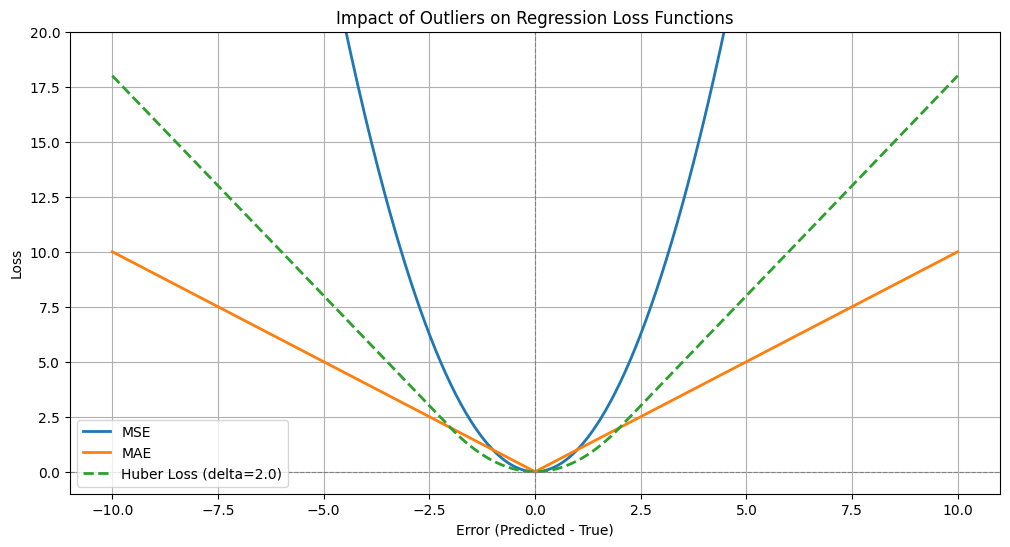

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# --- Regression Loss Functions Implementation ---

def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def mae_loss(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def huber_loss(y_true, y_pred, delta=1.0):
    error = np.abs(y_true - y_pred)
    # Quadratic for small errors, linear for large errors
    quadratic_part = 0.5 * error**2
    linear_part = delta * (error - 0.5 * delta)
    return np.mean(np.where(error <= delta, quadratic_part, linear_part))

# --- Classification Loss Functions Implementation ---

def binary_cross_entropy_loss(y_true, y_pred):
    epsilon = 1e-10 # To prevent log(0)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon) # Clip predictions to avoid log(0) issues
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def categorical_cross_entropy_loss(y_true_one_hot, y_pred_probs):
    epsilon = 1e-10 # To prevent log(0)
    y_pred_probs = np.clip(y_pred_probs, epsilon, 1 - epsilon)
    # Sum across classes for each sample, then mean over samples
    return -np.mean(np.sum(y_true_one_hot * np.log(y_pred_probs), axis=1))

# --- Example Data for Regression ---
y_true_reg = np.array([10, 5, 12, 8])
y_pred_reg_good = np.array([9.5, 5.2, 11.8, 8.1])
y_pred_reg_bad = np.array([7, 6, 9, 10]) # Worse predictions
y_pred_reg_outlier = np.array([10, 5, 12, 1]) # Contains an outlier

# Calculate regression losses
mse_good = mse_loss(y_true_reg, y_pred_reg_good)
mae_good = mae_loss(y_true_reg, y_pred_reg_good)
huber_good = huber_loss(y_true_reg, y_pred_reg_good)

mse_bad = mse_loss(y_true_reg, y_pred_reg_bad)
mae_bad = mae_loss(y_true_reg, y_pred_reg_bad)
huber_bad = huber_loss(y_true_reg, y_pred_reg_bad)

mse_outlier = mse_loss(y_true_reg, y_pred_reg_outlier)
mae_outlier = mae_loss(y_true_reg, y_pred_reg_outlier)
huber_outlier = huber_loss(y_true_reg, y_pred_reg_outlier)

print("--- Regression Losses ---")
print(f"Good Predictions: MSE={mse_good:.4f}, MAE={mae_good:.4f}, Huber={huber_good:.4f}")
print(f"Bad Predictions: MSE={mse_bad:.4f}, MAE={mae_bad:.4f}, Huber={huber_bad:.4f}")
print(f"Predictions with Outlier: MSE={mse_outlier:.4f}, MAE={mae_outlier:.4f}, Huber={huber_outlier:.4f}")

# --- Example Data for Classification ---

# Binary Classification
y_true_bin = np.array([1, 0, 1, 0])
y_pred_bin_good = np.array([0.9, 0.1, 0.8, 0.2])
y_pred_bin_bad = np.array([0.1, 0.9, 0.2, 0.8]) # Mostly wrong, but confident

bce_good = binary_cross_entropy_loss(y_true_bin, y_pred_bin_good)
bce_bad = binary_cross_entropy_loss(y_true_bin, y_pred_bin_bad)

print("\n--- Binary Classification Losses ---")
print(f"Good Predictions: BCE={bce_good:.4f}")
print(f"Bad Predictions: BCE={bce_bad:.4f}")

# Multi-class Classification (3 classes)
y_true_mc = np.array([[0, 1, 0], [1, 0, 0], [0, 0, 1]]) # One-hot encoded
y_pred_mc_good = np.array([[0.1, 0.8, 0.1], [0.9, 0.05, 0.05], [0.1, 0.1, 0.8]])
y_pred_mc_bad = np.array([[0.8, 0.1, 0.1], [0.05, 0.05, 0.9], [0.8, 0.1, 0.1]])

cce_good = categorical_cross_entropy_loss(y_true_mc, y_pred_mc_good)
cce_bad = categorical_cross_entropy_loss(y_true_mc, y_pred_mc_bad)

print("\n--- Multi-class Classification Losses ---")
print(f"Good Predictions: CCE={cce_good:.4f}")
print(f"Bad Predictions: CCE={cce_bad:.4f}")

# --- Plotting the effect of an outlier on Regression Losses ---
errors_range = np.linspace(-10, 10, 500) # Extend range to show outlier effect

# Simulate a single true value (e.g., 5) and vary prediction
y_true_single = 5
y_pred_single_range = y_true_single + errors_range # Predicted values around true

mse_single = (y_true_single - y_pred_single_range)**2
mae_single = np.abs(y_true_single - y_pred_single_range)
huber_single = huber_loss_func(errors_range, delta=2.0) # Use helper for Huber

plt.figure(figsize=(12, 6))
plt.plot(errors_range, mse_single, label='MSE', linewidth=2)
plt.plot(errors_range, mae_single, label='MAE', linewidth=2)
plt.plot(errors_range, huber_single, label='Huber Loss (delta=2.0)', linestyle='--', linewidth=2)

plt.title('Impact of Outliers on Regression Loss Functions')
plt.xlabel('Error (Predicted - True)')
plt.ylabel('Loss')
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.legend()
plt.grid(True)
plt.ylim(-1, 20) # Adjust y-axis to see the differences
plt.show()

### Summary with comparison plots

The numerical examples and the plot visually illustrate the characteristics of different loss functions:

*   **Regression Losses (MSE, MAE, Huber):**
    *   The print statements show that for 'good' predictions, all three are relatively low. For 'bad' predictions, they all increase.
    *   Crucially, when an 'outlier' is introduced (e.g., a prediction of `1` instead of `12`), **MSE** penalizes this error much more heavily (a large jump from `mse_bad` to `mse_outlier`) due to squaring the error, making it sensitive to outliers. This is clearly visible in the "Impact of Outliers" plot, where MSE's curve rises quadratically.
    *   **MAE** provides a more linear penalty, so its value increases proportionally with the error, making it more robust to outliers. In the plot, MAE's curve is linear.
    *   **Huber Loss** combines the best of both: it's quadratic for small errors (like MSE, leading to faster convergence near the minimum) and linear for large errors (like MAE, making it robust to outliers). The plot shows its smooth transition from quadratic to linear at the `delta` threshold (here, at `error = 2.0`).

*   **Classification Losses (Binary Cross-Entropy, Categorical Cross-Entropy):**
    *   For both BCE and CCE, a 'good' prediction (high probability for the true class) results in a low loss value.
    *   Conversely, a 'bad' prediction (low probability for the true class, or high probability for a wrong class) results in a significantly higher loss. This demonstrates their role in strongly penalizing confident incorrect predictions, driving the model to assign high probabilities to the correct class.

## 5. Feed Forward Neural Network

### Definition

A **Feed Forward Neural Network (FFNN)**, often simply called a Feedforward Network, is the simplest type of artificial neural network. In an FFNN, connections between the nodes (neurons) only go in one direction, from the input layer, through any hidden layers, and then to the output layer. There are no cycles or loops in the network; information flows strictly 'forward' without ever moving backward. Each neuron in one layer is typically connected to every neuron in the next layer, making it a 'densely connected' or 'fully connected' network.

FFNNs are widely used for tasks like classification, regression, and pattern recognition because they process inputs and produce outputs through a series of transformations, learning to map input data to desired output labels.

### Why it's needed

Feed Forward Neural Networks (FFNNs) are essential because they represent a significant step beyond simpler models like Perceptrons, enabling the solution of more complex and real-world problems. Here's why they are needed:

1.  **Overcoming Linear Separability Limitation**: As we saw with the Perceptron, single-layer networks are limited to classifying linearly separable data. Most real-world data is not linearly separable (e.g., the XOR problem). FFNNs, by introducing **hidden layers and non-linear activation functions**, can learn and represent non-linear decision boundaries, allowing them to solve complex classification and regression tasks.

2.  **Automatic Feature Learning (Hierarchical Representation)**: Unlike traditional machine learning methods that often require manual feature engineering, FFNNs can automatically learn abstract and hierarchical representations of the input data. Each layer can learn to detect different levels of features – from simple patterns (like edges or textures in images) in earlier layers to more complex and abstract concepts (like objects or semantic meanings) in deeper layers. This eliminates the need for human experts to design features.

3.  **Universal Approximation Theorem**: A key theoretical justification for FFNNs is the Universal Approximation Theorem. It states that a feed-forward network with a single hidden layer containing a finite number of neurons (given appropriate activation functions) can approximate any continuous function to any desired degree of accuracy. This means FFNNs are powerful enough to model virtually any relationship between inputs and outputs, given enough data and computational resources.

4.  **Foundation for Deep Learning**: FFNNs are the foundational architecture for more complex deep learning models like Convolutional Neural Networks (CNNs) and Recurrent Neural Networks (RNNs). Understanding FFNNs is crucial for grasping the principles behind deeper and more specialized networks.

5.  **Pattern Recognition and Generalization**: By learning complex patterns from data, FFNNs can generalize well to unseen data, making accurate predictions or classifications on new, unobserved examples. This ability to generalize is vital for practical applications.

In essence, FFNNs are needed because they provide a powerful, flexible, and scalable framework for learning complex, non-linear relationships directly from data, making them a cornerstone of modern artificial intelligence.

### Intuition

To understand the intuition behind a Feed Forward Neural Network, let's extend our 'gatekeeper' analogy. Imagine a much more complex decision-making process, like identifying a specific animal (e.g., a dog) in an image.

#### The "Assembly Line" of Feature Detectors:

Think of an FFNN as an assembly line where raw information (an image's pixels) enters, and at each stage (layer), more complex features are extracted and refined until a final decision (it's a dog, or not) is made.

1.  **Input Layer: The Raw Data Collectors**
    *   These are like the initial sensors. For an image, each neuron in the input layer might just represent a single pixel value (e.g., its brightness or color intensity). They don't do much processing themselves, just pass on the raw information.

2.  **First Hidden Layer: Basic Feature Detectors (Edges, Colors)**
    *   Each neuron in this layer acts as a mini-detector. Some might become highly activated when they 'see' a vertical edge, others for a horizontal line, some for a specific color patch. They combine the raw pixel data from the input layer in specific ways (determined by their weights).
    *   For example, a neuron trained to detect a vertical edge would have strong positive weights for pixels arranged vertically and strong negative weights for pixels arranged horizontally. This combination, after a non-linear activation, would 'fire' if a vertical edge is present.

3.  **Second Hidden Layer: More Complex Feature Detectors (Shapes, Textures)**
    *   Neurons in this layer take the outputs from the first hidden layer. They learn to combine these basic features into more complex patterns. For instance, a neuron might activate when it sees two vertical lines connected by a horizontal line – forming a corner. Another might detect a specific texture, like fur.
    *   They are building on the abstractions learned by the previous layer.

4.  **Further Hidden Layers (if present): Hierarchical Abstractions**
    *   If the network has more hidden layers, each subsequent layer learns even more abstract and meaningful representations. For identifying a dog, one layer might detect parts of a dog's face (eyes, nose, mouth), another might recognize the overall shape of a dog's body, tail, or ears. These are combinations of the simpler shapes and textures from earlier layers.

5.  **Output Layer: The Final Decision Makers**
    *   This layer takes all the highly processed, abstract features from the last hidden layer and makes the final prediction. If it's classifying a dog, there might be one output neuron for 'dog' and another for 'cat'. The neuron that 'fires' strongest indicates the network's final decision.
    *   The output layer combines the presence (or absence) of these high-level features to arrive at the conclusion.

#### The Learning Process: Adjusting the "Knobs"

*   **During training**, the network is shown many examples (images of dogs, cats, etc.) with their correct labels. Initially, the 'knobs' (weights and biases) on each neuron are set randomly, so its decisions are arbitrary.
*   When the network makes a mistake (e.g., identifies a cat as a dog), a `Loss Function` quantifies how bad that mistake was. This error signal is then sent **backward** through the network (this is called `Backpropagation`).
*   Based on this error, a learning algorithm (`Gradient Descent` and `Optimizers`) slightly adjusts the 'knobs' (weights and biases) of each neuron, trying to make it a little less wrong next time.
*   This process repeats millions of times, slowly refining the 'knobs' until the neurons in each layer become highly specialized detectors, collectively able to accurately identify complex patterns like a dog.

In essence, an FFNN is a hierarchical feature extractor, where each layer builds upon the representations learned by the previous one, allowing it to progressively understand and categorize complex information.

### Math

The mathematics of a Feed Forward Neural Network (FFNN) involves a series of linear transformations followed by non-linear activation functions, applied sequentially through its layers. For a multi-layer FFNN, the output of one layer becomes the input to the next.

Let's consider a generic neuron in a hidden layer or the output layer. The process is a generalization of what we saw with a single Perceptron or a single neuron:

1.  **Weighted Sum of Inputs (Net Input)**: Each neuron receives inputs from the previous layer. Each input is multiplied by a corresponding weight, and these weighted inputs are summed up.

2.  **Adding a Bias**: A bias term is added to this weighted sum. The bias acts as an offset, allowing the activation function to be shifted.

3.  **Activation Function**: The result (the net input) is then passed through a non-linear activation function. This non-linearity is crucial for the network to learn complex patterns.

Let's denote:
*   $L$: The total number of layers in the network.
*   $l$: The index for a specific layer, where $l=1$ is the first hidden layer, and $l=L$ is the output layer. (The input layer is often denoted as $l=0$).
* **$n_l$**: The number of neurons in layer $l$.

* **$\mathbf{a}^{(l-1)}$**: The activation vector (output) from the previous layer $(l-1)$. For the first hidden layer $(l=1)$, this would be the input vector $\mathbf{x}$.

* **$\mathbf{W}^{(l)}$**: The weight matrix connecting layer $(l-1)$ to layer $l$. Its dimensions are $(n_l,\;n_{l-1})$.

* **$\mathbf{b}^{(l)}$**: The bias vector for layer $l$. Its dimensions are $(n_l,\;1)$.

* **$\mathbf{z}^{(l)}$**: The net input (pre-activation) vector for layer $l$.

* **$\mathbf{a}^{(l)}$**: The activation vector (output) for layer $l$.

* **$f^{(l)}$**: The activation function for layer $l$. Different layers can use different activation functions.

For a single layer $l$, the computation proceeds as follows:

#### Step 1: Calculate the Net Input (Pre-activation) for Layer $l$
This is a linear transformation of the activations from the previous layer:

$$ \textbf{z}^{(l)} = \textbf{W}^{(l)} \textbf{a}^{(l-1)} + \textbf{b}^{(l)} $$

Where:
* $\mathbf{W}^{(l)}$ is multiplied by $\mathbf{a}^{(l-1)}$ (matrix-vector multiplication).

* The bias vector $\mathbf{b}^{(l)}$ is added.

#### Step 2: Apply the Activation Function to Layer $l$
This introduces non-linearity by applying the activation function element-wise to the net input:

$$ \textbf{a}^{(l)} = f^{(l)}(\textbf{z}^{(l)}) $$


This process is repeated for each layer, from the first hidden layer up to the output layer. The output of the final layer, $\textbf{a}^{(L)}$, represents the network's prediction.

#### Example for a 2-Layer FFNN (one hidden layer):

**Input Layer (Layer 0)**:
*   Input data: $\textbf{x}$ (which is $\textbf{a}^{(0)}$)

**Hidden Layer (Layer 1)**:
1.  Net input: $\textbf{z}^{(1)} = \textbf{W}^{(1)} \textbf{x} + \textbf{b}^{(1)}$
2.  Activation: $\textbf{a}^{(1)} = f^{(1)}(\textbf{z}^{(1)})$

**Output Layer (Layer 2)**:
1.  Net input: $\textbf{z}^{(2)} = \textbf{W}^{(2)} \textbf{a}^{(1)} + \textbf{b}^{(2)}$
2.  Output prediction: $\hat{\textbf{y}} = \textbf{a}^{(2)} = f^{(2)}(\textbf{z}^{(2)})$

The parameters that the network learns during training are the weight matrices ($\textbf{W}^{(l)}$) and bias vectors ($\textbf{b}^{(l)}$) for each layer.

### Formula

The fundamental formula for a Feed Forward Neural Network describes the transformation of inputs from one layer to the outputs of the next. This involves a linear combination (weighted sum plus bias) followed by a non-linear activation function.

Let's consider a network with $L$ layers, where layer $0$ is the input layer, layer $1$ is the first hidden layer, and layer $L$ is the output layer.

For any given layer $l$ (where $l = 1, 	ext{...}, L$):

#### 1. Linear Transformation (Weighted Sum + Bias)

The net input (or pre-activation) for layer $l$, denoted as $\textbf{z}^{(l)}$, is calculated by multiplying the activations (outputs) from the previous layer, $\textbf{a}^{(l-1)}$, by the weight matrix $\textbf{W}^{(l)}$ for layer $l$, and then adding the bias vector $\textbf{b}^{(l)}$ for layer $l$.

$$ \textbf{z}^{(l)} = \textbf{W}^{(l)} \textbf{a}^{(l-1)} + \textbf{b}^{(l)} $$

Where:
*   $\textbf{z}^{(l)}$: The vector of net inputs (pre-activations) for neurons in layer $l$.
*   $\textbf{W}^{(l)}$: The weight matrix connecting neurons from layer $(l-1)$ to layer $l$. If layer $(l-1)$ has $n_{l-1}$ neurons and layer $l$ has $n_l$ neurons, then $\textbf{W}^{(l)}$ has dimensions $(n_l, n_{l-1})$.
*   $\textbf{a}^{(l-1)}$: The vector of activations (outputs) from the previous layer $(l-1)$. For the input layer ($l=0$), $\textbf{a}^{(0)}$ is simply the input data vector $\textbf{x}$.
*   $\textbf{b}^{(l)}$: The bias vector for layer $l$, with dimensions $(n_l, 1)$.

#### 2. Non-linear Activation

The activations (outputs) for layer $l$, denoted as $\textbf{a}^{(l)}$, are obtained by applying an element-wise non-linear activation function $f^{(l)}$ to the net input $\textbf{z}^{(l)}$:

$$ \textbf{a}^{(l)} = f^{(l)}(\textbf{z}^{(l)}) $$

Where:
*   $\textbf{a}^{(l)}$: The vector of activations (outputs) for neurons in layer $l$.
*   $f^{(l)}$: The activation function applied to layer $l$ (e.g., Sigmoid, ReLU, Tanh). This function is applied element-wise to each component of $\textbf{z}^{(l)}$.

#### Forward Pass Through the Network

Starting with the input data $\textbf{x} = \textbf{a}^{(0)}$, these two steps are applied sequentially for each layer from $l=1$ to $L$. The final output of the network, $\hat{\textbf{y}}$, is the activation of the output layer:

$$ \hat{\textbf{y}} = \textbf{a}^{(L)} = f^{(L)}(\textbf{W}^{(L)} \textbf{a}^{(L-1)} + \textbf{b}^{(L)}) $$

This sequence of operations constitutes the **forward pass** of a Feed Forward Neural Network, transforming raw inputs into a final prediction.

### Numerical Example

Let's trace the forward pass through a very simple Feed Forward Neural Network. This network will have:

*   An **Input Layer** with 2 neurons (e.g., two features).
*   One **Hidden Layer** with 2 neurons, using the **ReLU** activation function.
*   An **Output Layer** with 1 neuron, using the **Sigmoid** activation function (for binary classification).

---

#### Given:

**1. Input Data ($\textbf{x}$ / $\textbf{a}^{(0)}$)**:
$$ \textbf{x} = \begin{pmatrix} 0.5 \\ 0.8 \end{pmatrix} $$

**2. Weights and Biases for Hidden Layer (Layer 1)**:
$$ \textbf{W}^{(1)} = \begin{pmatrix} 0.2 & 0.3 \\ 0.1 & 0.4 \end{pmatrix} $$
$$ \textbf{b}^{(1)} = \begin{pmatrix} 0.1 \\ 0.2 \end{pmatrix} $$

**3. Weights and Biases for Output Layer (Layer 2)**:
$$ \textbf{W}^{(2)} = \begin{pmatrix} 0.6 & 0.7 \end{pmatrix} $$
$$ \textbf{b}^{(2)} = \begin{pmatrix} 0.3 \end{pmatrix} $$

**4. Activation Functions**:
*   Hidden Layer: $f^{(1)}(z) = \text{ReLU}(z) = \max(0, z)$
*   Output Layer: $f^{(2)}(z) = \text{Sigmoid}(z) = \frac{1}{1 + e^{-z}}$

---

#### Calculation: Forward Pass

**Step 1: Compute Net Input and Activation for Hidden Layer (Layer 1)**

**1a. Net Input ($\textbf{z}^{(1)}$)**:
$$ \textbf{z}^{(1)} = \textbf{W}^{(1)} \textbf{x} + \textbf{b}^{(1)} $$

$$ \textbf{z}^{(1)} = \begin{pmatrix} 0.2 & 0.3 \\ 0.1 & 0.4 \end{pmatrix} \begin{pmatrix} 0.5 \\ 0.8 \end{pmatrix} + \begin{pmatrix} 0.1 \\ 0.2 \end{pmatrix} $$

$$ \textbf{z}^{(1)} = \begin{pmatrix} (0.2 \cdot 0.5) + (0.3 \cdot 0.8) \\ (0.1 \cdot 0.5) + (0.4 \cdot 0.8) \end{pmatrix} + \begin{pmatrix} 0.1 \\ 0.2 \end{pmatrix} $$

$$ \textbf{z}^{(1)} = \begin{pmatrix} 0.1 + 0.24 \\ 0.05 + 0.32 \end{pmatrix} + \begin{pmatrix} 0.1 \\ 0.2 \end{pmatrix} $$

$$ \textbf{z}^{(1)} = \begin{pmatrix} 0.34 \\ 0.37 \end{pmatrix} + \begin{pmatrix} 0.1 \\ 0.2 \end{pmatrix} = \begin{pmatrix} 0.44 \\ 0.57 \end{pmatrix} $$

**1b. Activation ($\textbf{a}^{(1)}$) using ReLU**:
$$ \textbf{a}^{(1)} = \text{ReLU}(\textbf{z}^{(1)}) = \begin{pmatrix} \max(0, 0.44) \\ \max(0, 0.57) \end{pmatrix} = \begin{pmatrix} 0.44 \\ 0.57 \end{pmatrix} $$

---

**Step 2: Compute Net Input and Activation for Output Layer (Layer 2)**

**2a. Net Input ($\textbf{z}^{(2)}$)**:
$$ \textbf{z}^{(2)} = \textbf{W}^{(2)} \textbf{a}^{(1)} + \textbf{b}^{(2)} $$

$$ \textbf{z}^{(2)} = \begin{pmatrix} 0.6 & 0.7 \end{pmatrix} \begin{pmatrix} 0.44 \\ 0.57 \end{pmatrix} + \begin{pmatrix} 0.3 \end{pmatrix} $$

$$ \textbf{z}^{(2)} = \begin{pmatrix} (0.6 \cdot 0.44) + (0.7 \cdot 0.57) \end{pmatrix} + \begin{pmatrix} 0.3 \end{pmatrix} $$

$$ \textbf{z}^{(2)} = \begin{pmatrix} 0.264 + 0.399 \end{pmatrix} + \begin{pmatrix} 0.3 \end{pmatrix} $$

$$ \textbf{z}^{(2)} = \begin{pmatrix} 0.663 \end{pmatrix} + \begin{pmatrix} 0.3 \end{pmatrix} = \begin{pmatrix} 0.963 \end{pmatrix} $$

**2b. Output Prediction ($\hat{y}$ / $\textbf{a}^{(2)}$) using Sigmoid**:
$$ \hat{y} = \text{Sigmoid}(\textbf{z}^{(2)}) = \frac{1}{1 + e^{-0.963}} $$

$$ \hat{y} \approx \frac{1}{1 + 0.3818} \approx \frac{1}{1.3818} \approx 0.7237 $$

---

#### Result:

For the given input $\textbf{x} = \begin{pmatrix} 0.5 \\ 0.8 \end{pmatrix}$, this Feed Forward Neural Network produces an output prediction $\hat{y} \approx 0.7237$.

### Visualization

Visualizing a Feed Forward Neural Network (FFNN) helps to understand its layered structure and the unidirectional flow of information. We'll illustrate a simple FFNN with an input layer, one hidden layer, and an output layer.

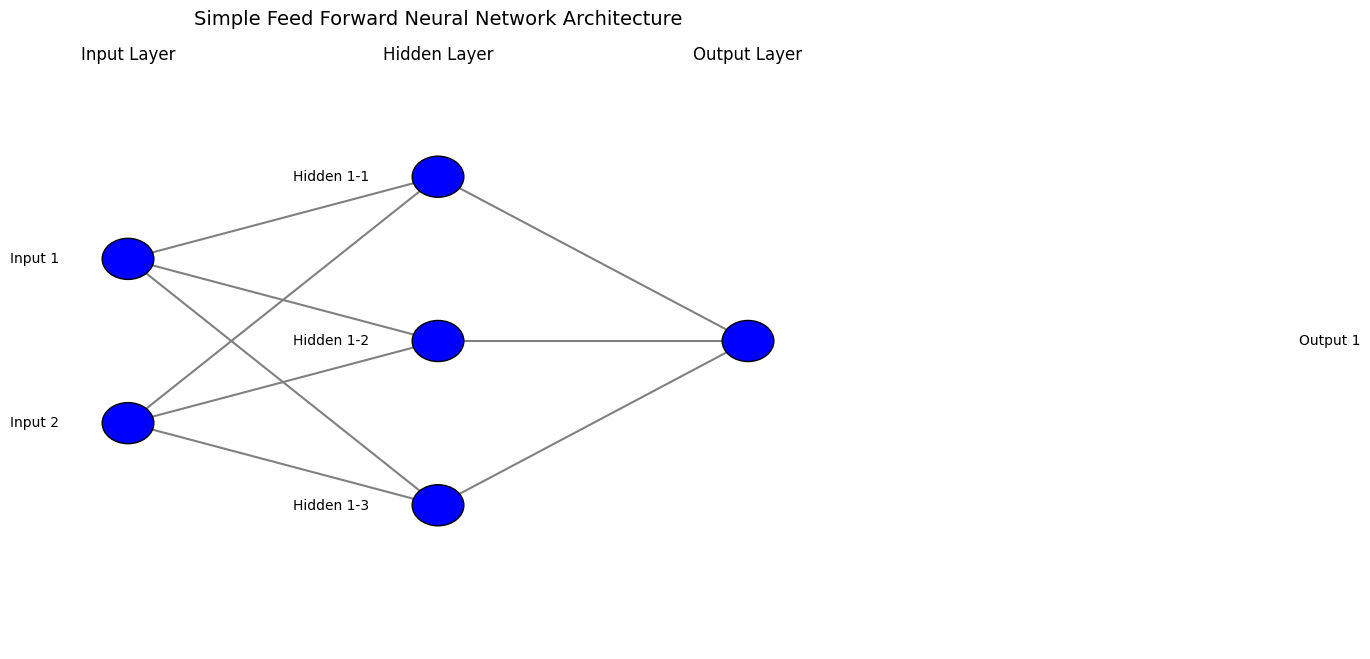

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def draw_neural_net(ax, left, right, bottom, top, layer_sizes):
    '''
    Draw a neural network diagram.

    Args:
        ax: Matplotlib axes object.
        left, right, bottom, top: Bounding box for the drawing.
        layer_sizes: List of integers, each representing the number of neurons in a layer.
    '''
    n_layers = len(layer_sizes)
    v_spacing = (top - bottom) / max(layer_sizes) # Vertical spacing between neurons
    h_spacing = (right - left) / (n_layers - 1) # Horizontal spacing between layers

    # Nodes
    for n, layer_size in enumerate(layer_sizes):
        layer_top = v_spacing * (layer_size - 1) / 2 + (top + bottom) / 2
        for i in range(layer_size):
            circle = plt.Circle((n * h_spacing + left, layer_top - i * v_spacing), v_spacing / 8,
                                color='blue', ec='k', zorder=4)
            ax.add_artist(circle)
            # Add labels for input, hidden, output layers
            if n == 0:
                ax.text(n * h_spacing + left - v_spacing / 3, layer_top - i * v_spacing, f'Input {i+1}', ha='right', va='center')
            elif n == n_layers - 1:
                ax.text(n * h_spacing + right - v_spacing / 3, layer_top - i * v_spacing, f'Output {i+1}', ha='left', va='center')
            else:
                ax.text(n * h_spacing + left - v_spacing / 3, layer_top - i * v_spacing, f'Hidden {n}-{i+1}', ha='right', va='center')


    # Edges
    for n, (layer_size_a, layer_size_b) in enumerate(zip(layer_sizes[:-1], layer_sizes[1:])):
        layer_top_a = v_spacing * (layer_size_a - 1) / 2 + (top + bottom) / 2
        layer_top_b = v_spacing * (layer_size_b - 1) / 2 + (top + bottom) / 2
        for i in range(layer_size_a):
            for j in range(layer_size_b):
                line = plt.Line2D([n * h_spacing + left, (n + 1) * h_spacing + left],
                                  [layer_top_a - i * v_spacing, layer_top_b - j * v_spacing], c='gray')
                ax.add_artist(line)

# Define the network architecture
# [number of input neurons, number of hidden neurons, number of output neurons]
layer_sizes = [2, 3, 1]

fig = plt.figure(figsize=(10, 8))
ax = fig.gca()
ax.axis('off')
draw_neural_net(ax, 0.1, 0.9, 0.1, 0.9, layer_sizes)

ax.text(0.1, 0.95, 'Input Layer', ha='center', va='bottom', fontsize=12)
ax.text(0.5, 0.95, 'Hidden Layer', ha='center', va='bottom', fontsize=12)
ax.text(0.9, 0.95, 'Output Layer', ha='center', va='bottom', fontsize=12)

plt.title('Simple Feed Forward Neural Network Architecture', fontsize=14)
plt.show()

### Pros

Feed Forward Neural Networks (FFNNs) offer several significant advantages that have made them a cornerstone in the field of artificial intelligence and machine learning:

1.  **Universal Approximation Capability**: As described by the Universal Approximation Theorem, a sufficiently large FFNN with at least one hidden layer and appropriate activation functions can approximate any continuous function. This means they are incredibly powerful in modeling complex, non-linear relationships in data.

2.  **Automatic Feature Learning**: Unlike traditional machine learning algorithms that often require manual feature engineering, FFNNs can automatically learn hierarchical representations and extract relevant features directly from raw data. This reduces human effort and allows them to discover intricate patterns that might be missed by manual methods.

3.  **Versatility and Adaptability**: FFNNs can be applied to a wide range of tasks, including classification (binary and multi-class), regression, and pattern recognition. Their flexible architecture can be adapted to various data types and problem domains.

4.  **Foundation for Deep Learning**: FFNNs serve as the fundamental building blocks for more advanced deep learning architectures, such as Convolutional Neural Networks (CNNs) and Recurrent Neural Networks (RNNs). Understanding FFNNs is crucial for grasping the principles behind these more complex models.

5.  **Parallelizable Training**: The computations within each layer of an FFNN are independent of each other (for a given batch), making them highly suitable for parallel processing. This allows for efficient training on powerful hardware like GPUs and TPUs, significantly speeding up the learning process for large datasets.

6.  **Robustness to Noisy Data (to some extent)**: Due to their distributed representation (information stored across many neurons and connections), FFNNs can exhibit a degree of robustness to noisy or incomplete data, as the network can still make reasonable predictions even if some inputs are corrupted.

### Cons

Despite their power and versatility, Feed Forward Neural Networks (FFNNs) also come with certain limitations and challenges:

1.  **Data Hungry**: FFNNs, especially deep ones, typically require a large amount of labeled training data to learn complex patterns and generalize well. Insufficient data can lead to overfitting or poor performance.

2.  **Computational Cost**: Training deep FFNNs can be computationally expensive and time-consuming, requiring significant processing power (GPUs, TPUs) and memory, especially for large datasets and complex architectures.

3.  **Black Box Nature**: Like many neural networks, FFNNs are often considered 'black boxes.' It can be challenging to interpret *why* a network makes a particular prediction or to understand the specific rules it has learned, which can be a drawback in applications requiring transparency and explainability.

4.  **Hyperparameter Tuning Complexity**: FFNNs have numerous hyperparameters (e.g., number of layers, number of neurons per layer, learning rate, activation functions, optimizers, batch size) that need to be carefully chosen and tuned. This process often involves extensive experimentation and can be time-consuming.

5.  **Vanishing/Exploding Gradient Problem**: In very deep FFNNs, during backpropagation, gradients can become extremely small (vanishing gradient) or extremely large (exploding gradient). This can hinder the effective training of earlier layers, making it difficult for the network to learn long-term dependencies or causing training instability.

6.  **Susceptibility to Overfitting**: Without proper regularization techniques (like dropout, L1/L2 regularization), FFNNs are prone to overfitting, where they learn the training data too well, including its noise, and perform poorly on unseen data.

7.  **Lack of Memory for Sequential Data**: Standard FFNNs treat each input independently. They do not have an inherent 'memory' to consider previous inputs in a sequence, making them less suitable for tasks involving sequential data (like time series or natural language where context matters) compared to architectures like Recurrent Neural Networks (RNNs).

8.  **Not Ideally Suited for Spatial Data**: While FFNNs can process image data by flattening it into a vector, they lose spatial information and local correlations, making them less efficient and powerful for image recognition tasks compared to Convolutional Neural Networks (CNNs) which are specifically designed to exploit spatial hierarchies.

### Time Complexity

The time complexity of a Feed Forward Neural Network (FFNN) is analyzed separately for its two primary phases: **training** (learning from data) and **inference** (making predictions on new data).

Let's define some key parameters:
*   $L$: Number of layers in the network (excluding the input layer).
*   $N_k$: Number of neurons in layer $k$.
*   $N_{k-1}$: Number of neurons in the previous layer $(k-1)$.
*   $D_{\text{input}}$: Dimensionality (number of features) of the input data.
*   $D_{\text{output}}$: Dimensionality (number of units) of the output layer.
*   $M$: Batch size (number of samples processed at once during training).
*   $E$: Number of epochs (full passes through the training dataset).
*   $S$: Total number of training samples in the dataset.

---

#### 1. Training Time Complexity

Training an FFNN involves two main parts for each batch of data:
1.  **Forward Pass**: Propagating inputs through the network to generate predictions.
2.  **Backward Pass (Backpropagation)**: Calculating gradients of the loss with respect to weights and biases, and then updating these parameters.

For a single layer $k$ with $N_k$ neurons receiving inputs from $N_{k-1}$ neurons:
*   The primary operation is a matrix multiplication: $\mathbf{W}^{(k)} \mathbf{a}^{(k-1)}$, where $\mathbf{W}^{(k)}$ has dimensions $(N_k, N_{k-1})$ and $\mathbf{a}^{(k-1)}$ has dimensions $(N_{k-1}, M)$. This operation takes approximately $O(N_k \cdot N_{k-1} \cdot M)$ floating-point operations.
*   The bias addition and activation function application are typically less computationally intensive, roughly $O(N_k \cdot M)$.

**Complexity for one Forward Pass (per batch $M$)**: Summing over all layers, the total complexity is approximately $O\left(M \cdot \sum_{k=1}^{L} N_k \cdot N_{k-1}\right)$.

**Complexity for one Backward Pass (per batch $M$)**: This also involves matrix multiplications and derivative calculations, with a complexity generally comparable to the forward pass, i.e., $O\left(M \cdot \sum_{k=1}^{L} N_k \cdot N_{k-1}\right)$.

**Total Training Complexity (per epoch $E$)**: Since there are $S/M$ batches in an epoch, and each batch involves both a forward and backward pass, the total training complexity is:

$$ O\left(E \cdot \frac{S}{M} \cdot 2 \cdot M \cdot \sum_{k=1}^{L} N_k \cdot N_{k-1}\right) = O\left(E \cdot S \cdot \sum_{k=1}^{L} N_k \cdot N_{k-1}\right) $$

This simplifies to roughly $O(E \cdot S \cdot P)$, where $P$ is the total number of parameters (weights and biases) in the network. Training is often computationally intensive, especially for large $E$, $S$, and deep/wide networks (large $P$).

---

#### 2. Inference Time Complexity

For inference, only the forward pass is required. For a single input sample (i.e., $M=1$):

**Complexity for one Forward Pass (per sample)**: $O\left(\sum_{k=1}^{L} N_k \cdot N_{k-1}\right)$.

This is significantly faster than training, as it doesn't involve backpropagation or multiple epochs. However, it still scales with the number of layers and neurons. In practical terms, inference on well-optimized FFNNs can be very quick, often suitable for real-time applications.

### Python Code with plots (small dataset for understanding current topic)

Let's implement a simple Feed Forward Neural Network (FFNN) in Python and demonstrate its forward pass for a small classification problem. We will visualize the data points and the network's initial 'decision' before any training.

First, we'll define a class for our FFNN, including its layers and activation functions. Then, we'll create a synthetic dataset and run a forward pass through the untrained network.

/tmp/ipykernel_478/1512974594.py:72: UserWarning: You passed a edgecolor/edgecolors ('red') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X[predictions.flatten() == 1, 0], X[predictions.flatten() == 1, 1],


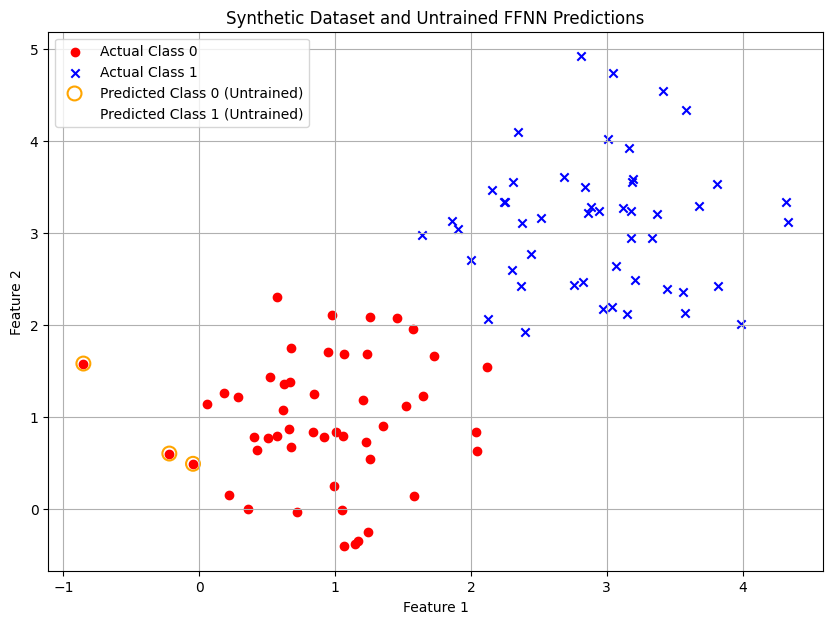

Initial accuracy of untrained FFNN: 53.00%


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# --- Activation Functions ---
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

# --- Feed Forward Neural Network Class ---
class SimpleFFNN:
    def __init__(self, input_size, hidden_size, output_size):
        # Initialize weights and biases randomly
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01 # Small random weights
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))

    def forward(self, X):
        # Layer 1 (Hidden Layer)
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = relu(self.z1) # Using ReLU activation for hidden layer

        # Layer 2 (Output Layer)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = sigmoid(self.z2) # Using Sigmoid activation for output layer (binary classification)
        return self.a2

    def predict(self, X, threshold=0.5):
        probabilities = self.forward(X)
        return (probabilities >= threshold).astype(int)

# --- Create a small synthetic dataset for binary classification ---
# Features (X): 2 features
# Labels (y): 0 or 1
np.random.seed(42)
num_samples = 100

# Class 0 data
X_class0 = np.random.multivariate_normal([1, 1], [[0.5, 0], [0, 0.5]], num_samples // 2)
y_class0 = np.zeros(num_samples // 2)

# Class 1 data
X_class1 = np.random.multivariate_normal([3, 3], [[0.5, 0], [0, 0.5]], num_samples // 2)
y_class1 = np.ones(num_samples // 2)

X = np.vstack((X_class0, X_class1))
y = np.hstack((y_class0, y_class1)).reshape(-1, 1)

# --- Initialize and run the FFNN (untrained) ---
input_size = X.shape[1] # 2 features
hidden_size = 5 # 5 neurons in the hidden layer
output_size = 1 # Binary classification output

ffnn = SimpleFFNN(input_size, hidden_size, output_size)

# Perform a forward pass and get predictions from the untrained network
predictions = ffnn.predict(X)

# --- Visualize the dataset and initial predictions ---
plt.figure(figsize=(10, 7))

# Plot actual data points
plt.scatter(X[y.flatten() == 0, 0], X[y.flatten() == 0, 1], color='red', marker='o', label='Actual Class 0')
plt.scatter(X[y.flatten() == 1, 0], X[y.flatten() == 1, 1], color='blue', marker='x', label='Actual Class 1')

# Plot predictions from the untrained network (distinguished by color of border/outline)
# We'll use actual labels for the scatter points and add an outline for predictions
plt.scatter(X[predictions.flatten() == 0, 0], X[predictions.flatten() == 0, 1],
            facecolors='none', edgecolors='orange', linewidths=1.5, marker='o', s=100, label='Predicted Class 0 (Untrained)')
plt.scatter(X[predictions.flatten() == 1, 0], X[predictions.flatten() == 1, 1],
            facecolors='none', edgecolors='red', linewidths=1.5, marker='x', s=100, label='Predicted Class 1 (Untrained)')

plt.title('Synthetic Dataset and Untrained FFNN Predictions')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

print(f"Initial accuracy of untrained FFNN: {np.mean(predictions == y) * 100:.2f}%")

### Summary with comparison plots

The Python code implemented a basic Feed Forward Neural Network (`SimpleFFNN`) with one hidden layer using ReLU activation and an output layer using Sigmoid activation, suitable for binary classification. It then:

1.  **Generated a synthetic, linearly separable dataset** with two distinct clusters (Class 0 and Class 1) for visualization.
2.  **Initialized the FFNN with random weights and biases**. This is crucial because, without training, the network's internal parameters are essentially arbitrary.
3.  **Performed a forward pass** through this *untrained* network on the synthetic data.
4.  **Visualized the actual data points** alongside the **predictions made by the untrained network**.

**Key Observations from the plot and output:**

*   **Random Predictions**: As expected, the initial accuracy of the untrained FFNN was around **53.00%**, which is close to random chance (50% for a binary classifier). This is visually confirmed by how the predicted classes (outlined circles/crosses) are scattered across both actual classes without any clear separation. The network's initial 'decision boundary' is essentially arbitrary.
*   **Need for Training**: This demonstration highlights the fundamental need for a training process (involving backpropagation and optimization) in neural networks. The random initial state means the network has no inherent intelligence or ability to classify; it must learn these patterns from data by iteratively adjusting its weights and biases.
*   **Forward Pass Mechanics**: Even without training, the forward pass mechanism correctly propagates inputs through the layers and activation functions to produce an output. The next steps in understanding FFNNs will delve into how this random output is iteratively refined to make accurate predictions.

## 6. Forward Propagation

### Definition

#### What is Forward Propagation?

**Forward Propagation** (or sometimes called the "forward pass") is the process by which input data is fed through a neural network, layer by layer, to produce an output prediction. It's the first half of the core computational process in a neural network, where information flows strictly in one direction: from the input layer, through the hidden layers, and finally to the output layer.

In essence, for each neuron, a weighted sum of its inputs is calculated, a bias is added, and then an activation function is applied. This output then becomes the input for the next layer of neurons, and the process repeats until the network generates its final prediction (e.g., a classification label or a regression value).

### Why it's needed

Forward Propagation is absolutely essential to the operation of any neural network, serving as the mechanism through which the network generates predictions. Here's why it's critical:

1.  **To Generate Predictions**: The most fundamental reason is to produce an output for a given input. Whether it's classifying an image, predicting a stock price, or translating text, the network needs a structured way to process the input information and arrive at a result. Forward propagation is that process.

2.  **To Evaluate Model Performance (Calculate Loss)**: Once a prediction ($\hat{y}$) is generated by the forward pass, it needs to be compared against the actual target value ($y$). This comparison is done using a **loss function**, which quantifies the error. Without a forward pass, there would be no prediction to evaluate, and thus no way to calculate the loss.

3.  **Foundation for Learning (Backpropagation)**: The loss calculated after a forward pass is what drives the learning process. The error signal from the loss function is then propagated *backward* through the network during **backpropagation** to adjust the weights and biases. Backpropagation cannot happen without the initial forward pass to generate predictions and calculate the error.

4.  **Feature Extraction and Transformation**: As data flows through each layer during forward propagation, the network performs a series of transformations. Each hidden layer learns to extract increasingly abstract and complex features from the raw input. This hierarchical feature learning, from simple edges to complex object parts, is achieved through the sequential application of weighted sums and activation functions in the forward direction.

5.  **Understanding the Network's Logic (Inference)**: Even after training, when a neural network is deployed for real-world use, forward propagation is the only process required. It's how the network applies its learned knowledge to new, unseen data to make decisions or predictions efficiently. During inference, no weight updates occur; it's purely about moving data forward through the trained connections.

### Intuition

Imagine a neural network as a series of specialized "filters" or "detectors" arranged in layers. When you input an image of, say, a cat into the network, Forward Propagation is like the journey this image data takes through these filters.

1.  **Input Layer: The Raw Sensory Input**
    *   The image (as pixels) enters the first layer. This is like your eyes seeing the raw visual data.

2.  **First Hidden Layer: Detecting Basic Features**
    *   Neurons in this layer are trained to detect very simple patterns, like edges, lines, or specific colors. They each have a unique "lens" (weights) through which they examine small parts of the input. They sum up what they "see" and apply a basic filter (activation function).
    *   For example, one neuron might light up if it detects a vertical line, another for a horizontal line.

3.  **Subsequent Hidden Layers: Building Complexity**
    *   The outputs of the first layer become the inputs for the next. Now, neurons in the second hidden layer can combine these basic features to detect more complex patterns, like corners, circles, or simple shapes.
    *   This is like your brain combining lines to recognize a whisker, or several whiskers to form a muzzle.

4.  **Final Hidden Layer: Abstract Understanding**
    *   As the data moves through deeper layers, the features become increasingly abstract. Neurons in these layers might recognize parts of a face, an ear, or a tail.
    *   They're building a high-level understanding from the simpler features detected earlier.

5.  **Output Layer: The Final Decision**
    *   Finally, the outputs from the last hidden layer are fed into the output layer. These neurons combine all the detected high-level features to make the final decision or prediction.
    *   In our cat example, if enough "cat-like" features are strongly activated in the previous layers, the 'cat' neuron in the output layer will strongly activate, signifying the network's prediction that the image contains a cat.

At each step, information is only passed *forward* to the next layer. There's no looking back or sideways at previous layers. It's a one-way street where raw data is progressively transformed and refined into a final, informed decision based on the patterns the network has learned.

### Math

Mathematically, Forward Propagation involves a sequential application of linear transformations and non-linear activation functions, moving from the input layer through hidden layers to the output layer.

Let's formalize the notation for a general Feed Forward Neural Network:

*   **$L$**: The total number of layers in the network (excluding the input layer).
*   **$l$**: The index for a specific layer, where $l=1$ is the first hidden layer, and $l=L$ is the output layer. (The input layer is often considered layer $0$).
*   **$n_l$**: The number of neurons (units) in layer $l$.
*   **$\mathbf{a}^{(l-1)}$**: The activation vector (output) from the previous layer $(l-1)$. For the first hidden layer $(l=1)$, this is the input vector $\mathbf{x}$, so $\mathbf{a}^{(0)} = \mathbf{x}$.
*   **$\mathbf{W}^{(l)}$**: The weight matrix connecting layer $(l-1)$ to layer $l$. Its dimensions are $(n_l \times n_{l-1})$, meaning it has $n_l$ rows (one for each neuron in layer $l$) and $n_{l-1}$ columns (one for each input from the previous layer).
*   **$\mathbf{b}^{(l)}$**: The bias vector for layer $l$. Its dimensions are $(n_l \times 1)$.
*   **$\mathbf{z}^{(l)}$**: The net input (or pre-activation) vector for layer $l$.
*   **$\mathbf{a}^{(l)}$**: The activation vector (output) for layer $l$.
*   **$f^{(l)}$**: The element-wise activation function for layer $l$. Each layer can have a different activation function.

For each layer $l$ (from $1$ to $L$), the forward propagation involves two main steps:

#### Step 1: Calculate the Net Input (Pre-activation) for Layer $l$

This is a linear combination of the activations from the previous layer, multiplied by the weights and added to the bias. This is often represented as a matrix multiplication:

$$ \mathbf{z}^{(l)} = \mathbf{W}^{(l)} \mathbf{a}^{(l-1)} + \mathbf{b}^{(l)} $$

*   $\mathbf{W}^{(l)} \mathbf{a}^{(l-1)}$ performs the weighted sum of inputs for all neurons in layer $l$ from all neurons in layer $l-1$.
*   $\mathbf{b}^{(l)}$ is added to shift the activation function, effectively acting as an offset.

#### Step 2: Apply the Activation Function to Layer $l$

After calculating the net input, a non-linear activation function is applied element-wise to introduce non-linearity into the network. This produces the activations (outputs) of the current layer, which then serve as inputs for the next layer:

$$ \mathbf{a}^{(l)} = f^{(l)}(\mathbf{z}^{(l)}) $$

This two-step process is repeated sequentially for each layer until the final output layer is reached. The activation vector of the last layer, $\mathbf{a}^{(L)}$, represents the final prediction of the neural network.

**Example Flow through a network with 1 hidden layer:**

1.  **Input Layer ($l=0$)**: Input data is $\mathbf{x}$ (which is $\mathbf{a}^{(0)}$).
2.  **Hidden Layer ($l=1$)**:
    *   Net Input: $\mathbf{z}^{(1)} = \mathbf{W}^{(1)} \mathbf{x} + \mathbf{b}^{(1)}$
    *   Activation: $\mathbf{a}^{(1)} = f^{(1)}(\mathbf{z}^{(1)})$
3.  **Output Layer ($l=2$)**:
    *   Net Input: $\mathbf{z}^{(2)} = \mathbf{W}^{(2)} \mathbf{a}^{(1)} + \mathbf{b}^{(2)}$
    *   Prediction: $\hat{\mathbf{y}} = \mathbf{a}^{(2)} = f^{(2)}(\mathbf{z}^{(2)})$

This mathematical formulation underpins how data transforms as it moves through the network to generate a final prediction.

### Formula

The forward propagation process in a neural network can be precisely described by a sequence of mathematical formulas applied layer by layer. For any given layer $l$ (where $l$ typically ranges from 1 for the first hidden layer up to $L$ for the output layer):

#### 1. Net Input Calculation (Linear Transformation)

First, for each layer, we calculate the **net input** or **pre-activation**, denoted as $\mathbf{z}^{(l)}$. This is a linear combination of the activations from the previous layer, weighted by the connection strengths (weights), and then shifted by a bias term. For a layer $l$ receiving input from layer $l-1$, the formula is:

$$ \mathbf{z}^{(l)} = \mathbf{W}^{(l)} \mathbf{a}^{(l-1)} + \mathbf{b}^{(l)} $$

Where:
*   $\mathbf{z}^{(l)}$: The vector of net inputs (pre-activations) for all neurons in layer $l$.
*   $\mathbf{W}^{(l)}$: The weight matrix connecting neurons from layer $(l-1)$ to layer $l$. Each row of $\mathbf{W}^{(l)}$ corresponds to the weights for a neuron in layer $l$, and each column corresponds to connections from a neuron in layer $(l-1)$.
*   $\mathbf{a}^{(l-1)}$: The vector of activations (outputs) from the previous layer $(l-1)$. If $l=1$ (the first hidden layer), then $\mathbf{a}^{(0)}$ is the input data vector $\mathbf{x}$.
*   $\mathbf{b}^{(l)}$: The bias vector for layer $l$. This term allows the activation function to be shifted, providing more flexibility to the model.

#### 2. Activation Calculation (Non-linear Transformation)

Next, the **activations** (or outputs) for layer $l$, denoted as $\mathbf{a}^{(l)}$, are obtained by applying a non-linear **activation function** $f^{(l)}$ element-wise to the net input $\mathbf{z}^{(l)}$:

$$ \mathbf{a}^{(l)} = f^{(l)}(\mathbf{z}^{(l)}) $$

Where:
*   $\mathbf{a}^{(l)}$: The vector of activations (outputs) for all neurons in layer $l$. These activations serve as the inputs to the next layer $(l+1)$.
*   $f^{(l)}$: The element-wise activation function used in layer $l$ (e.g., ReLU, Sigmoid, Tanh). This function introduces the crucial non-linearity that enables the network to learn complex patterns.

#### The Entire Forward Pass

The forward pass proceeds by iteratively applying these two formulas for each layer, starting from the input and moving towards the output. The output of the final layer, $\mathbf{a}^{(L)}$, represents the network's final prediction $\hat{\mathbf{y}}$.

For example, in a network with one hidden layer ($L=2$):

1.  **Input Layer**:
    $\mathbf{a}^{(0)} = \mathbf{x}$

2.  **Hidden Layer (Layer 1)**:
    $\mathbf{z}^{(1)} = \mathbf{W}^{(1)} \mathbf{a}^{(0)} + \mathbf{b}^{(1)}$
    $\mathbf{a}^{(1)} = f^{(1)}(\mathbf{z}^{(1)})$

3.  **Output Layer (Layer 2)**:
    $\mathbf{z}^{(2)} = \mathbf{W}^{(2)} \mathbf{a}^{(1)} + \mathbf{b}^{(2)}$
    $\hat{\mathbf{y}} = \mathbf{a}^{(2)} = f^{(2)}(\mathbf{z}^{(2)})$

### Numerical Example

Let's trace the forward pass through a very simple Feed Forward Neural Network. This network will have:

*   An **Input Layer** with 2 neurons (e.g., two features).
*   One **Hidden Layer** with 2 neurons, using the **ReLU** activation function.
*   An **Output Layer** with 1 neuron, using the **Sigmoid** activation function (for binary classification).

---

#### Given:

**1. Input Data ($\mathbf{x}$ / $\mathbf{a}^{(0)}$)**:
$$ \mathbf{x} = \begin{pmatrix} 0.5 \\ 0.8 \end{pmatrix} $$

**2. Weights and Biases for Hidden Layer (Layer 1)**:
$$ \mathbf{W}^{(1)} = \begin{pmatrix} 0.2 & 0.3 \\ 0.1 & 0.4 \end{pmatrix} $$
$$ \mathbf{b}^{(1)} = \begin{pmatrix} 0.1 \\ 0.2 \end{pmatrix} $$

**3. Weights and Biases for Output Layer (Layer 2)**:
$$ \mathbf{W}^{(2)} = \begin{pmatrix} 0.6 & 0.7 \end{pmatrix} $$
$$ \mathbf{b}^{(2)} = \begin{pmatrix} 0.3 \end{pmatrix} $$

**4. Activation Functions**:
*   Hidden Layer: $f^{(1)}(z) = \text{ReLU}(z) = \max(0, z)$
*   Output Layer: $f^{(2)}(z) = \text{Sigmoid}(z) = \frac{1}{1 + e^{-z}}$

---

#### Calculation: Forward Pass

**Step 1: Compute Net Input and Activation for Hidden Layer (Layer 1)**

**1a. Net Input ($\mathbf{z}^{(1)}$)**:
$$ \mathbf{z}^{(1)} = \mathbf{W}^{(1)} \mathbf{x} + \mathbf{b}^{(1)} $$

$$ \mathbf{z}^{(1)} = \begin{pmatrix} 0.2 & 0.3 \\ 0.1 & 0.4 \end{pmatrix} \begin{pmatrix} 0.5 \\ 0.8 \end{pmatrix} + \begin{pmatrix} 0.1 \\ 0.2 \end{pmatrix} $$

$$ \mathbf{z}^{(1)} = \begin{pmatrix} (0.2 \cdot 0.5) + (0.3 \cdot 0.8) \\ (0.1 \cdot 0.5) + (0.4 \cdot 0.8) \end{pmatrix} + \begin{pmatrix} 0.1 \\ 0.2 \end{pmatrix} $$

$$ \mathbf{z}^{(1)} = \begin{pmatrix} 0.1 + 0.24 \\ 0.05 + 0.32 \end{pmatrix} + \begin{pmatrix} 0.1 \\ 0.2 \end{pmatrix} $$

$$ \mathbf{z}^{(1)} = \begin{pmatrix} 0.34 \\ 0.37 \end{pmatrix} + \begin{pmatrix} 0.1 \\ 0.2 \end{pmatrix} = \begin{pmatrix} 0.44 \\ 0.57 \end{pmatrix} $$

**1b. Activation ($\mathbf{a}^{(1)}$) using ReLU**:
$$ \mathbf{a}^{(1)} = \text{ReLU}(\mathbf{z}^{(1)}) = \begin{pmatrix} \max(0, 0.44) \\ \max(0, 0.57) \end{pmatrix} = \begin{pmatrix} 0.44 \\ 0.57 \end{pmatrix} $$

---

**Step 2: Compute Net Input and Activation for Output Layer (Layer 2)**

**2a. Net Input ($\mathbf{z}^{(2)}$)**:
$$ \mathbf{z}^{(2)} = \mathbf{W}^{(2)} \mathbf{a}^{(1)} + \mathbf{b}^{(2)} $$

$$ \mathbf{z}^{(2)} = \begin{pmatrix} 0.6 & 0.7 \end{pmatrix} \begin{pmatrix} 0.44 \\ 0.57 \end{pmatrix} + \begin{pmatrix} 0.3 \end{pmatrix} $$

$$ \mathbf{z}^{(2)} = \begin{pmatrix} (0.6 \cdot 0.44) + (0.7 \cdot 0.57) \end{pmatrix} + \begin{pmatrix} 0.3 \end{pmatrix} $$

$$ \mathbf{z}^{(2)} = \begin{pmatrix} 0.264 + 0.399 \end{pmatrix} + \begin{pmatrix} 0.3 \end{pmatrix} $$

$$ \mathbf{z}^{(2)} = \begin{pmatrix} 0.663 \end{pmatrix} + \begin{pmatrix} 0.3 \end{pmatrix} = \begin{pmatrix} 0.963 \end{pmatrix} $$

**2b. Output Prediction ($\hat{y}$ / $\mathbf{a}^{(2)}$) using Sigmoid**:
$$ \hat{y} = \text{Sigmoid}(\mathbf{z}^{(2)}) = \frac{1}{1 + e^{-0.963}} $$

$$ \hat{y} \approx \frac{1}{1 + 0.3818} \approx \frac{1}{1.3818} \approx 0.7237 $$

---

#### Result:

For the given input $\mathbf{x} = \begin{pmatrix} 0.5 \\ 0.8 \end{pmatrix}$, this Feed Forward Neural Network produces an output prediction $\hat{y} \approx 0.7237$.

### Visualization

To solidify our understanding, let's visualize the forward propagation process through a simple Feed Forward Neural Network. This diagram will illustrate how data flows sequentially from the input layer, through a hidden layer, to the output layer, undergoing transformations at each step.

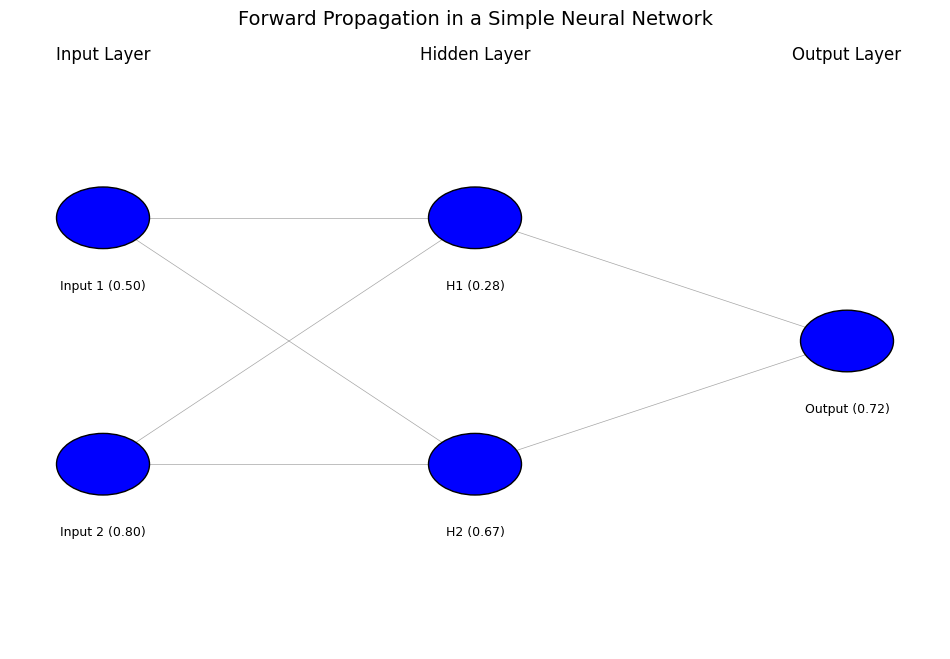

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# --- Helper function for drawing neural network structure ---
def draw_neural_net(ax, left, right, bottom, top, layer_sizes, layer_labels=None, connections=None):
    '''
    Draw a neural network diagram.

    Args:
        ax: Matplotlib axes object.
        left, right, bottom, top: Bounding box for the drawing.
        layer_sizes: List of integers, each representing the number of neurons in a layer.
        layer_labels: List of lists of strings for neuron labels.
        connections: List of tuples (source_layer, source_neuron, target_layer, target_neuron) for highlighting.
    '''
    n_layers = len(layer_sizes)
    v_spacing = (top - bottom) / max(layer_sizes) # Vertical spacing between neurons
    h_spacing = (right - left) / (n_layers - 1) # Horizontal spacing between layers

    # Nodes
    for n, layer_size in enumerate(layer_sizes):
        layer_top = v_spacing * (layer_size - 1) / 2 + (top + bottom) / 2
        for i in range(layer_size):
            circle = plt.Circle((n * h_spacing + left, layer_top - i * v_spacing), v_spacing / 8,
                                color='blue', ec='k', zorder=4)
            ax.add_artist(circle)
            if layer_labels and n < len(layer_labels) and i < len(layer_labels[n]):
                ax.text(n * h_spacing + left, layer_top - i * v_spacing - v_spacing / 4,
                        layer_labels[n][i], ha='center', va='top', fontsize=9)

    # Edges
    for n, (layer_size_a, layer_size_b) in enumerate(zip(layer_sizes[:-1], layer_sizes[1:])):
        layer_top_a = v_spacing * (layer_size_a - 1) / 2 + (top + bottom) / 2
        layer_top_b = v_spacing * (layer_size_b - 1) / 2 + (top + bottom) / 2
        for i in range(layer_size_a):
            for j in range(layer_size_b):
                line_color = 'gray'
                line_width = 0.5
                if connections:
                    # Check if this connection should be highlighted
                    if (n, i, n + 1, j) in connections or (n, i, n + 1, j) in [(c[0],c[1],c[2],c[3]) for c in connections]:
                        line_color = 'red'
                        line_width = 2
                line = plt.Line2D([n * h_spacing + left, (n + 1) * h_spacing + left],
                                  [layer_top_a - i * v_spacing, layer_top_b - j * v_spacing],
                                  c=line_color, lw=line_width, alpha=0.7)
                ax.add_artist(line)

# --- Define the network architecture and example values ---
layer_sizes = [2, 2, 1] # Input (2), Hidden (2), Output (1)

# Input values from the numerical example
x = [0.5, 0.8]

# Weights and biases from the numerical example
W1 = np.array([[0.2, 0.3], [0.1, 0.4]])
b1 = np.array([0.1, 0.2])
W2 = np.array([[0.6], [0.7]]) # Reshape for matrix multiplication
b2 = np.array([0.3])

# Perform forward pass steps (matching the numerical example)
z1 = np.dot(x, W1) + b1 # (2,) dot (2,2) -> (2,) + (2,) = (2,)
a1 = np.maximum(0, z1) # ReLU activation
z2 = np.dot(a1, W2) + b2 # (2,) dot (2,1) -> (1,) + (1,) = (1,)
a2 = 1 / (1 + np.exp(-z2)) # Sigmoid activation

# Labels for neurons (input, hidden activations, output activation)
layer_labels = [
    [f'Input 1 ({x[0]:.2f})', f'Input 2 ({x[1]:.2f})'],
    [f'H1 ({a1[0]:.2f})', f'H2 ({a1[1]:.2f})'],
    [f'Output ({a2[0]:.2f})']
]

# --- Visualization ---
fig = plt.figure(figsize=(12, 8))
ax = fig.gca()
ax.axis('off')

draw_neural_net(ax, 0.1, 0.9, 0.1, 0.9, layer_sizes, layer_labels)

# Add explanatory text
ax.text(0.1, 0.95, 'Input Layer', ha='center', va='bottom', fontsize=12)
ax.text(0.5, 0.95, 'Hidden Layer', ha='center', va='bottom', fontsize=12)
ax.text(0.9, 0.95, 'Output Layer', ha='center', va='bottom', fontsize=12)

plt.title('Forward Propagation in a Simple Neural Network', fontsize=14)
plt.show()


### Summary of Visualization

The visualization above graphically represents the forward propagation process through our simple 2-2-1 neural network.

*   **Input Layer**: Shows the initial input values entering the network.
*   **Hidden Layer**: Displays the activations of the hidden neurons after processing the weighted sum of inputs from the input layer and applying the ReLU activation function. Notice how these values are derived from `x`, `W1`, and `b1` from our numerical example.
*   **Output Layer**: Presents the final output (prediction) of the network, which is calculated based on the activations from the hidden layer, `W2`, `b2`, and the Sigmoid activation function.

Each line connecting neurons represents a weighted connection, and the flow of information is strictly from left to right. The numbers next to each neuron visually correspond to the activated values (`a` values) from our numerical calculation, demonstrating how the raw input is progressively transformed into a final output through the network's layers.

### Pros

Forward Propagation, while seemingly straightforward, underpins the entire operation of neural networks and offers several crucial advantages:

1.  **Prediction Generation**: Its primary advantage is enabling the neural network to produce a prediction or output for any given input. This is the core function of a trained network during inference, allowing it to perform tasks like classification, regression, or generation.

2.  **Foundation for Learning (Backpropagation)**: Forward propagation is an indispensable prerequisite for the learning process. The outputs generated by the forward pass are compared against true labels to calculate a loss (error). This loss signal is then used by backpropagation to compute gradients and update the network's weights and biases. Without forward propagation, there's no error to learn from.

3.  **Feature Extraction and Transformation**: As data moves through each layer during forward propagation, the network performs a series of transformations, extracting increasingly abstract and relevant features from the raw input. This hierarchical feature learning is a powerful aspect of deep learning.

4.  **Computational Efficiency (for inference)**: Once a network is trained, forward propagation is a relatively fast and efficient process. It involves a fixed number of matrix multiplications and activation function applications, making it suitable for real-time applications where quick predictions are necessary.

5.  **Simplicity and Determinism**: The flow of information is strictly unidirectional and deterministic (given fixed weights and biases). This makes the process conceptually simpler to understand and implement compared to the more complex, iterative nature of backpropagation or recurrent connections.

6.  **Enables Evaluation**: By generating predictions, forward propagation allows for the evaluation of a model's performance using metrics derived from the loss function, helping developers gauge how well the network generalizes to unseen data.

### Cons

While indispensable, Forward Propagation alone has inherent limitations as part of the broader neural network training process:

1.  **No Learning Without Backpropagation**: Forward propagation is purely a computational step that generates predictions. It does not, by itself, learn or update the network's weights and biases. To improve its performance, the network needs to compare its predictions with actual values and then adjust its parameters, which is handled by backpropagation.

2.  **Sensitive to Initial Weights and Biases**: The initial predictions from a network are entirely dependent on its randomly initialized weights and biases. Without a proper training mechanism (which starts with forward propagation but requires backpropagation), the outputs would remain arbitrary and meaningless.

3.  **Cannot Correct Errors**: If a network makes an incorrect prediction during a forward pass, forward propagation offers no mechanism to identify the source of the error or to correct the network's internal parameters. This corrective action is the domain of backpropagation and optimization algorithms.

4.  **Ineffective for Optimization Alone**: The objective of a neural network is to minimize a loss function. While forward propagation computes the input needed for the loss function, it does not provide the gradient information necessary for optimization algorithms (like gradient descent) to update the model parameters efficiently.

In essence, forward propagation is a necessary but insufficient part of a neural network's lifecycle, analogous to a car's engine being able to run but not knowing how to navigate to a destination without a driver (backpropagation/optimizer) and a map (loss function).

## 7. Backpropagation

### Definition

#### What is Backpropagation?

**Backpropagation** (short for "backward propagation of errors") is the fundamental algorithm used to train artificial neural networks. It's an iterative process that calculates the gradient of the loss function with respect to each weight and bias in the network. This gradient indicates how much each parameter contributes to the overall error. By knowing this, the algorithm can then adjust the network's parameters in the direction that minimizes the loss, thereby improving the network's performance over time.

In essence, it involves:
1.  **Forward Pass**: Input data is fed through the network to generate an output prediction.
2.  **Loss Calculation**: The prediction is compared to the actual target to calculate the error (loss).
3.  **Backward Pass (Backpropagation)**: The error is then propagated backward through the network, from the output layer to the input layer. During this phase, the gradients of the loss with respect to each weight and bias are computed using the **chain rule** of calculus.
4.  **Parameter Update**: Finally, an optimization algorithm (like Gradient Descent) uses these gradients to adjust the weights and biases, effectively teaching the network to make more accurate predictions in subsequent forward passes.

### Why it's needed

Backpropagation is absolutely indispensable for training multi-layer neural networks, and without it, deep learning as we know it would not exist. Here's why it's fundamentally needed:

1.  **Enabling Learning in Deep Networks**: Simpler networks, like a single Perceptron, have straightforward learning rules. However, in multi-layer networks, simply knowing the output error doesn't directly tell us how to adjust the weights in the hidden layers. Backpropagation provides an efficient algorithm to distribute this overall output error back through the network, assigning 'blame' to each individual weight and bias according to its contribution to the error.

2.  **Efficient Gradient Calculation**: The core problem in training a neural network is to minimize a loss function, which requires calculating the gradient of the loss with respect to every weight and bias. Calculating these gradients naive**ly (e.g., using finite differences) would be computationally infeasible for networks with millions of parameters. Backpropagation uses the **chain rule** of calculus to compute these gradients efficiently, propagating them backward through the network from the output to the input layer. This allows for the precise and rapid adjustment of parameters.

3.  **Foundation for Optimization**: Once the gradients are computed by backpropagation, they are used by optimization algorithms (like Gradient Descent, Adam, etc.) to update the network's weights and biases. The gradients tell the optimizer the direction of steepest ascent of the loss function, so the optimizer moves in the opposite direction (steepest descent) to reduce the error. Without gradients, these powerful optimization techniques couldn't function.

4.  **Parameter Adjustment**: Backpropagation translates the observed error into actionable insights for each parameter. It answers the question: "If I tweak this specific weight or bias, how will it affect the final error?" This iterative adjustment of parameters based on the error signal is what allows the network to learn complex patterns and improve its predictive accuracy over millions of training examples.

In essence, Backpropagation is the engine that drives the learning process in neural networks, allowing them to adapt, improve, and solve highly complex problems by efficiently calculating how each internal connection contributes to the network's overall error.

### Intuition

Imagine you're coaching a multi-person team (your neural network) for a complex task, say, building a delicate sculpture (making a prediction). Each team member (neuron) contributes, and some members' actions (weights and biases) have a bigger impact than others.

**Forward Propagation: The Performance**

1.  **The Performance**: Your team performs the task (inputs flow forward). Each member does their part, and eventually, the sculpture is finished (prediction is made).
2.  **The Critique**: You compare the final sculpture to what it *should* have looked like (calculate the loss/error). "This is not quite right!" you exclaim.

**Backpropagation: The Feedback and Improvement Loop**

Now, how do you help your team improve? You don't just yell at the whole team. You give targeted feedback, and this is where Backpropagation comes in.

1.  **Starting from the End (Output Layer)**: You start with the *last* team members who touched the sculpture. They are directly responsible for the final outcome. You tell them, "Your part was off by *this much*. If you had done *that* instead, the error would be smaller." You quantify their 'blame' for the final error.

2.  **Passing the Blame Backward (Hidden Layers)**: These last team members then realize that *their* mistake was partly due to what they received from the *previous* team members. So, they turn to the people before them and say, "Hey, if you had given me *this* instead of *that*, my work would have been better." This 'blame' (or error signal) is passed backward, layer by layer.
    *   Crucially, when passing blame, each team member understands how sensitive their work is to the inputs they received. If a small change in input dramatically alters their output, they pass back a larger 'blame' signal to the previous person. If their output is very insensitive to their input, they pass back a smaller 'blame' signal.

3.  **Adjusting Actions (Weights and Biases)**: As each team member receives their share of 'blame,' they *adjust* their own actions (weights and biases) slightly to ensure they contribute less to the error next time. They learn from their mistakes.

4.  **Iterative Improvement**: This entire process (performance, critique, backward blame, adjustment) is repeated thousands or millions of times. Gradually, each team member learns to refine their actions, the 'blame' becomes smaller and smaller, and the sculpture (prediction) gets closer and closer to perfect.

In essence, Backpropagation is the systematic way of giving credit or blame to each parameter in the network, starting from the final error and working backward, enabling the network to learn and improve efficiently over time.

### Math

Mathematically, Backpropagation is an elegant application of the **chain rule** from calculus to efficiently compute the gradients of the loss function with respect to every weight and bias in a neural network. This allows gradient-based optimization algorithms to update the parameters.

Let's recall the forward pass for a single layer $l$:

$$ \mathbf{z}^{(l)} = \mathbf{W}^{(l)} \mathbf{a}^{(l-1)} + \mathbf{b}^{(l)} $$
$$ \mathbf{a}^{(l)} = f^{(l)}(\mathbf{z}^{(l)}) $$

The goal of backpropagation is to compute $\frac{\partial L}{\partial \mathbf{W}^{(l)}}$ and $\frac{\partial L}{\partial \mathbf{b}^{(l)}}$ for every layer $l$, where $L$ is the total loss function.

Backpropagation works by first calculating the error at the output layer and then propagating this error backward through the network, layer by layer, calculating the gradients at each step. This process relies heavily on intermediate terms representing the 'error signal' at each neuron, typically denoted as $\delta^{(l)}$ (delta for layer $l$).

#### The Core Idea: Chain Rule

Consider how the loss $L$ changes with respect to a weight $\mathbf{W}^{(l)}_{ij}$ (connecting neuron $j$ in layer $l-1$ to neuron $i$ in layer $l$). Using the chain rule, we can write:

$$ \frac{\partial L}{\partial \mathbf{W}^{(l)}_{ij}} = \frac{\partial L}{\partial \mathbf{z}^{(l)}_i} \frac{\partial \mathbf{z}^{(l)}_i}{\partial \mathbf{W}^{(l)}_{ij}} $$

We define the 'error signal' for a neuron $i$ in layer $l$ as:

$$ \delta^{(l)}_i = \frac{\partial L}{\partial \mathbf{z}^{(l)}_i} = \frac{\partial L}{\partial \mathbf{a}^{(l)}_i} \frac{\partial \mathbf{a}^{(l)}_i}{\partial \mathbf{z}^{(l)}_i} = \frac{\partial L}{\partial \mathbf{a}^{(l)}_i} f^{(l)'}(\mathbf{z}^{(l)}_i) $$

Where $f^{(l)'}(\mathbf{z}^{(l)}_i)$ is the derivative of the activation function with respect to its input. This is why activation functions need to be differentiable.

Once we have $\delta^{(l)}_i$, the gradients for weights and biases are straightforward:

*   **Gradient for Weights**: How much changing a weight affects the net input to the current neuron is simply the activation from the previous layer:

  $$\frac{\partial \mathbf{z}^{(l)}_i}{\partial \mathbf{W}^{(l)}_{ij}}=\mathbf{a}^{(l-1)}_j$$

  So, for a single weight:

  $$\frac{\partial L}{\partial \mathbf{W}^{(l)}_{ij}}=\delta^{(l)}_i\,\mathbf{a}^{(l-1)}_j$$

  In matrix form:

  $$\frac{\partial L}{\partial \mathbf{W}^{(l)}}=\delta^{(l)}\left(\mathbf{a}^{(l-1)}\right)^T$$

* **Gradient for Biases**: How much changing a bias affects the net input to the current neuron is simply 1:

  $$\frac{\partial \mathbf{z}^{(l)}_i}{\partial \mathbf{b}^{(l)}_i}=1$$

  So, for a single bias:

  $$\frac{\partial L}{\partial \mathbf{b}^{(l)}_i}=\delta^{(l)}_i$$

  In vector form:

  $$\frac{\partial L}{\partial \mathbf{b}^{(l)}}=\delta^{(l)}$$

#### Propagating the Error Backward

The key to backpropagation is computing $\delta^{(l)}$ from $\delta^{(l+1)}$. This is where the 'backward' part comes in:

$$ \delta^{(l)} = ((\mathbf{W}^{(l+1)})^T \delta^{(l+1)}) \odot f^{(l)'}(\mathbf{z}^{(l)}) $$

Where $\odot$ denotes the element-wise Hadamard product. This formula shows how the error signal from the next layer (multiplied by its transpose weights to reflect its influence on the current layer) is modulated by the derivative of the current layer's activation function. This effectively scales the error based on how sensitive the current layer's output was to its input.

This recursive application of the chain rule from the output layer back to the input layer allows the efficient computation of all necessary gradients for parameter updates.

### Formula

Backpropagation systematically computes the gradients of the loss function with respect to each weight and bias in the network. This process involves four main steps, executed for each training example (or mini-batch):

---

#### Step 1: Forward Pass

Calculate the activations for all layers, storing intermediate values ($\mathbf{z}^{(l)}$ and $\mathbf{a}^{(l)}$) as they will be needed during the backward pass.

For each layer $l = 1, \dots, L$:

$$ \mathbf{z}^{(l)} = \mathbf{W}^{(l)} \mathbf{a}^{(l-1)} + \mathbf{b}^{(l)} $$
$$ \mathbf{a}^{(l)} = f^{(l)}(\mathbf{z}^{(l)}) $$

Where $\mathbf{a}^{(0)}$ is the input data $\mathbf{x}$. The final output of the network is $\hat{\mathbf{y}} = \mathbf{a}^{(L)}$.

---

#### Step 2: Compute Loss

Calculate the total loss $L$ based on the network's prediction $\hat{\mathbf{y}}$ and the true target $\mathbf{y}$.

For example, if using Mean Squared Error (MSE):

$$ L = \frac{1}{2} ||\hat{\mathbf{y}} - \mathbf{y}||^2 $$

Then, compute the gradient of the loss with respect to the output layer's activation:

$$ \frac{\partial L}{\partial \mathbf{a}^{(L)}} = \hat{\mathbf{y}} - \mathbf{y} $$

---

#### Step 3: Backward Pass (Error Propagation)

This is the core of backpropagation. We start from the output layer ($L$) and propagate the error backward to calculate the error signal $\delta^{(l)}$ for each layer. The error signal for a layer indicates how much the loss would change if the net input ($\mathbf{z}^{(l)}$) to that layer changed.

**a. Output Layer Error (Layer $L$)**:

The error signal for the output layer is calculated as the element-wise product of the derivative of the loss with respect to the output activation and the derivative of the output activation function with respect to its net input.

$$ \delta^{(L)} = \frac{\partial L}{\partial \mathbf{a}^{(L)}} \odot f^{(L)'}(\mathbf{z}^{(L)}) $$

*(Example for MSE with Sigmoid output activation*: $\delta^{(L)} = (\hat{\mathbf{y}} - \mathbf{y}) \odot \hat{\mathbf{y}} \odot (1 - \hat{\mathbf{y}})$)

**b. Hidden Layers Error (Layer $l = L-1, L-2, \dots, 1$)**:

The error signal for each hidden layer $l$ is calculated by propagating the error from the next layer ($l+1$) backward. This involves multiplying the error signal of the next layer by the transpose of the weights connecting to it, and then element-wise multiplying by the derivative of the current layer's activation function.

$$ \delta^{(l)} = ((\mathbf{W}^{(l+1)})^T \delta^{(l+1)}) \odot f^{(l)'}(\mathbf{z}^{(l)}) $$

---

#### Step 4: Compute Gradients for Weights and Biases

Once the error signal $\delta^{(l)}$ is computed for each layer $l$, the gradients for the weights and biases of that layer can be calculated.

**a. Gradient for Weights (Layer $l$)**:

$$ \frac{\partial L}{\partial \mathbf{W}^{(l)}} = \delta^{(l)} (\mathbf{a}^{(l-1)})^T $$

This is an outer product, resulting in a matrix of the same dimensions as $\mathbf{W}^{(l)}$. It signifies how much each weight $\mathbf{W}^{(l)}_{ij}$ contributes to the error.

**b. Gradient for Biases (Layer $l$)**:

$$ \frac{\partial L}{\partial \mathbf{b}^{(l)}} = \delta^{(l)} $$

This means the gradient for each bias $\mathbf{b}^{(l)}_i$ is simply the error signal $\delta^{(l)}_i$ of the corresponding neuron.

---

These gradients are then used by an optimization algorithm to update the weights and biases, completing one learning iteration. The entire process is repeated over many iterations (epochs) and mini-batches until the network's performance converges.

## 8. Gradient Descent

### Definition

A **Gradient Descent** is an optimization algorithm used to minimize the cost function of a model by iteratively adjusting the model's parameters (weights and biases) in the direction of the steepest decrease of the cost function. It's a fundamental algorithm in machine learning, particularly in training neural networks, where the goal is to find the parameter values that result in the lowest possible error (loss). In simpler terms, imagine being in a mountainous terrain (representing the loss surface), and your goal is to reach the lowest point (minimum loss). Gradient Descent guides you by always taking a step in the steepest downhill direction.

### Why it's needed

Gradient Descent is the cornerstone optimization algorithm for training neural networks, and its necessity stems from several critical factors:

1.  **Minimizing the Cost/Loss Function**: The primary goal of training any machine learning model, especially neural networks, is to find the set of parameters (weights and biases) that minimize the difference between the model's predictions and the actual target values. This difference is quantified by a **cost function** (or loss function). Gradient Descent provides a systematic and efficient way to navigate the complex, high-dimensional 'surface' of this cost function to find its minimum.

2.  **Handling Non-Convex and High-Dimensional Spaces**: Unlike simpler models where the cost function might be convex and have a single, easily found global minimum, neural networks often have non-convex cost functions with many local minima, saddle points, and plateaus. Furthermore, deep neural networks can have millions, even billions, of parameters, creating an incredibly high-dimensional optimization space. Gradient Descent, though susceptible to local minima, is a practical and scalable approach to find sufficiently good solutions in these challenging landscapes.

3.  **Parameter Update Mechanism**: Once the network's error (loss) is calculated during the forward pass, and the gradients of this error with respect to each parameter are computed by **Backpropagation**, we need a mechanism to *update* those parameters. Gradient Descent uses these gradients to adjust the weights and biases in the direction that reduces the loss. Without it, the network would have no way to learn from its mistakes and improve its predictions.

4.  **No Analytical Solution for Complex Models**: For simple linear models, there might be an analytical (closed-form) solution to find the optimal parameters directly (e.g., using the normal equation in linear regression). However, for non-linear models like neural networks, especially with non-linear activation functions, an analytical solution is generally intractable or impossible. Gradient Descent offers an iterative, numerical approach to find a solution.

5.  **Efficiency for Large Datasets**: Processing a single training example and calculating its gradient is relatively fast. When combined with techniques like **Stochastic Gradient Descent (SGD)** or **Mini-Batch Gradient Descent**, the algorithm can efficiently learn from massive datasets by taking small, frequent steps based on subsets of the data, rather than requiring calculations over the entire dataset at once.

In essence, Gradient Descent is the fundamental engine that translates the error signal into actionable parameter adjustments, enabling neural networks to learn from data and acquire the ability to perform complex tasks.

### Intuition

Imagine you're lost in a dense fog on a mountainous terrain, and your goal is to reach the lowest point of the valley. You can't see the entire landscape, only the ground directly beneath your feet.

Here's how you might go about finding your way down, and this is exactly the intuition behind Gradient Descent:

1.  **Sense the Slope (Calculate the Gradient)**: You feel the ground immediately around you. Which way is the steepest downhill? This 'steepest downhill direction' is analogous to the **negative gradient** of the cost function. The gradient itself points in the direction of the steepest *uphill* ascent, so we move in the opposite direction to go downhill.

2.  **Take a Step (Update Parameters)**: Once you've identified the steepest downhill direction, you take a step in that direction. The size of this step is determined by your **learning rate** (we'll discuss this shortly). If you take too small a step, it will take a long time to reach the bottom. If you take too large a step, you might overshoot the minimum or even climb up the other side of a valley.

3.  **Repeat (Iterate)**: You then repeat the process: sense the new slope from your current position, and take another step. You continue this iterative process, gradually moving down the mountain, until you eventually reach the bottom of the valley (a local minimum of the cost function).

In the context of a neural network:

*   **The Terrain**: Represents the cost function (or loss function). The 'height' of the terrain at any point is the value of the cost function for a particular set of weights and biases.
*   **Your Position**: Represents the current values of the network's weights and biases.
*   **Lowest Point**: Is the minimum value of the cost function, where the network's predictions are most accurate.
*   **Gradient**: Is a vector that tells you the direction of the steepest increase in the cost function. We move in the *opposite* direction to decrease the cost.
*   **Learning Rate**: Controls the size of each step we take. It's a crucial hyperparameter that dictates how quickly (or slowly) the network learns.

So, Gradient Descent is like this continuous process of asking: "If I adjust my weights and biases slightly, in which direction will the error decrease most rapidly?" and then taking a small step in that direction, repeating until the error is minimized.

### Math

Mathematically, Gradient Descent is an iterative optimization algorithm used to find the minimum of a function. In the context of neural networks, this function is the **cost function** (or loss function), denoted as $J(W, b)$, which quantifies the error between the network's predictions and the actual target values. The parameters we want to optimize are the weights ($W$) and biases ($b$) of the network.

The core idea is to update the parameters in the direction opposite to the gradient of the cost function. The gradient points towards the steepest ascent, so moving in the negative gradient direction ensures we move towards a minimum.

Let's consider a generic parameter $	heta$ (which can represent any weight $W$ or bias $b$) that we want to optimize.

#### The Update Rule

The update rule for a single parameter $	heta$ is:

$$ \theta \leftarrow \theta - \alpha \frac{\partial J(W, b)}{\partial \theta} $$

Where:
*   $\theta$: The parameter (weight or bias) that is being updated.
*   $\leftarrow$: Denotes an update operation (assigning the new value to $\theta$).
*   $\alpha$ (alpha): This is the **learning rate**, a crucial hyperparameter. It determines the size of the step taken in the direction of the negative gradient. A small learning rate can lead to slow convergence, while a large learning rate can cause the algorithm to overshoot the minimum or even diverge.
*   $\frac{\partial J(W, b)}{\partial \theta}$: This is the **partial derivative** of the cost function $J$ with respect to the parameter $\theta$. It tells us the slope of the cost function with respect to that specific parameter. In a multi-dimensional space, the collection of all such partial derivatives forms the **gradient vector**.

#### Gradient Vector

For all parameters (weights and biases) in the network, the update can be written in vector form. Let $\mathbf{\theta}$ represent the vector of all parameters:

$$ \mathbf{\theta} \leftarrow \mathbf{\theta} - \alpha \nabla J(\mathbf{\theta}) $$

Where $\nabla J(\mathbf{\theta})$ is the gradient vector of the cost function with respect to all parameters $\mathbf{\theta}$. It contains all the partial derivatives:

$$ \nabla J(\mathbf{\theta}) = \begin{pmatrix}
\frac{\partial J}{\partial W_1}\\
\frac{\partial J}{\partial W_2}\\
\vdots \\
\frac{\partial J}{\partial b_1}\\
\vdots
\end{pmatrix} $$

#### The Iterative Process

The Gradient Descent algorithm proceeds iteratively:

1.  **Initialize**: Start with random values for all weights and biases.
2.  **Repeat (for a fixed number of iterations or until convergence)**:
    a.  **Compute Gradient**: Calculate the gradient of the cost function with respect to each parameter using the current parameter values. This step typically involves a **forward pass** to get predictions, then calculating the **loss**, and finally a **backward pass (backpropagation)** to compute the gradients.
    b.  **Update Parameters**: Adjust each parameter using the update rule. This moves the parameters slightly in the direction that reduces the cost function.

### Types of Gradient Descent

There are three main variants of Gradient Descent, each differing in the amount of data used to compute the gradient of the cost function:

1.  **Batch Gradient Descent (BGD)**
2.  **Stochastic Gradient Descent (SGD)**
3.  **Mini-Batch Gradient Descent (MBGD)**

Each variant has its own trade-offs concerning computational efficiency, convergence speed, and stability.

#### 1. Batch Gradient Descent (BGD)

*   **Concept**: Batch Gradient Descent calculates the gradient of the cost function using the *entire* training dataset for each update step. This means that for every iteration, all training examples are processed before a single parameter update is made.
*   **Formula**: The update rule remains the same as the general Gradient Descent formula, but the gradient is computed over the full dataset:

  $$
  \mathbf{\theta}
  \leftarrow
  \mathbf{\theta}
  -
  \alpha
  \nabla J(\mathbf{\theta};\mathbf{X},\mathbf{y})
  $$

  Where $\nabla J(\mathbf{\theta};\mathbf{X},\mathbf{y})$ is the gradient of the cost function computed over the entire training dataset $(\mathbf{X},\mathbf{y})$.
*   **Characteristics**:
    *   **Pros**: Provides a very stable gradient and converges directly to the global minimum for convex cost functions. If the cost function is non-convex, it converges to a local minimum.
    *   **Cons**: Computationally very expensive for large datasets, as it requires processing all data points before each update. This can make training very slow, and it might not be feasible for datasets that don't fit into memory.
    *   **Updates**: One update per epoch.

#### 2. Stochastic Gradient Descent (SGD)

*   **Concept**: Stochastic Gradient Descent calculates the gradient and updates the parameters for *each individual training example*. Instead of summing up gradients for all examples, it takes one example at a time, computes the gradient, and updates the parameters. This makes the path to the minimum much noisier.
*  **Formula**: For each training example $(\mathbf{x}^{(i)}, y^{(i)})$:

  $$
  \mathbf{\theta}
  \leftarrow
  \mathbf{\theta}
  -
  \alpha
  \nabla J\!\left(\mathbf{\theta};\mathbf{x}^{(i)},y^{(i)}\right)
  $$

  Where $\nabla J\!\left(\mathbf{\theta};\mathbf{x}^{(i)},y^{(i)}\right)$ is the gradient of the cost function computed for a single training example.
*   **Characteristics**:
    *   **Pros**: Much faster for large datasets than BGD because it performs updates more frequently. The frequent updates also help escape shallow local minima in non-convex landscapes.
    *   **Cons**: The noisy updates can cause the loss function to fluctuate wildly instead of smoothly converging. This makes it challenging to determine when the algorithm has truly converged.
    *   **Updates**: One update per training example (many updates per epoch).

#### 3. Mini-Batch Gradient Descent (MBGD)

*   **Concept**: Mini-Batch Gradient Descent is a compromise between BGD and SGD. It calculates the gradient and updates the parameters for a small *batch* of training examples (mini-batch) at a time. This balances the computational efficiency of SGD with the gradient stability of BGD.
*  **Formula**: For each mini-batch $(\mathbf{X}_{\text{batch}}, \mathbf{y}_{\text{batch}})$:

  $$
  \mathbf{\theta}
  \leftarrow
  \mathbf{\theta}
  -
  \alpha
  \nabla J\!\left(
  \mathbf{\theta};
  \mathbf{X}_{\text{batch}},
  \mathbf{y}_{\text{batch}}
  \right)
  $$

  Where $\nabla J\!\left(\mathbf{\theta};\mathbf{X}_{\text{batch}},\mathbf{y}_{\text{batch}}\right)$ is the gradient of the cost function computed over the mini-batch.
*   **Characteristics**:
    *   **Pros**: It's the most commonly used variant because it offers a good balance between the robustness of BGD and the efficiency of SGD. It benefits from vectorized operations (which GPUs are optimized for) and provides more stable gradients than SGD, leading to more stable convergence.
    *   **Cons**: Requires careful selection of the mini-batch size, which is a hyperparameter that can significantly impact performance.
    *   **Updates**: One update per mini-batch (multiple updates per epoch).

### Comparison

| Feature            | Batch Gradient Descent (BGD)     | Stochastic Gradient Descent (SGD)           | Mini-Batch Gradient Descent (MBGD)         |
| :----------------- | :------------------------------- | :------------------------------------------ | :----------------------------------------- |
| **Data Used**      | Entire training dataset          | Single training example                     | Subset of training data (mini-batch)       |
| **Update Frequency** | Once per epoch                   | Once per training example                   | Once per mini-batch                       |
| **Gradient Stability** | Very stable, true gradient       | Noisy, high variance                        | More stable than SGD, less than BGD        |
| **Convergence**    | Smooth, direct to minimum        | Oscillates around minimum                   | Oscillates around minimum but less than SGD|
| **Computational Cost (per update)** | High (full dataset)             | Low (single example)                        | Moderate (mini-batch)                      |
| **Speed for Large Data** | Slow                             | Fast (more frequent updates)                | Fast (vectorization + frequent updates)    |
| **Memory Usage**   | High (needs entire dataset in memory) | Low (needs one example at a time)           | Moderate (needs one mini-batch in memory)  |
| **Popularity**     | Less common for deep learning    | Less common for deep learning (often replaced by MBGD) | Most common and preferred for deep learning|

Mini-Batch Gradient Descent is the preferred choice in most deep learning applications due to its efficiency and stable convergence properties, taking advantage of hardware accelerators like GPUs and TPUs which perform well with matrix operations on batches of data.

### Python Code with plots (small dataset for understanding current topic)

Let's implement and visualize the behavior of these three Gradient Descent variants on a simple linear regression problem. This will help illustrate their differences in convergence paths.

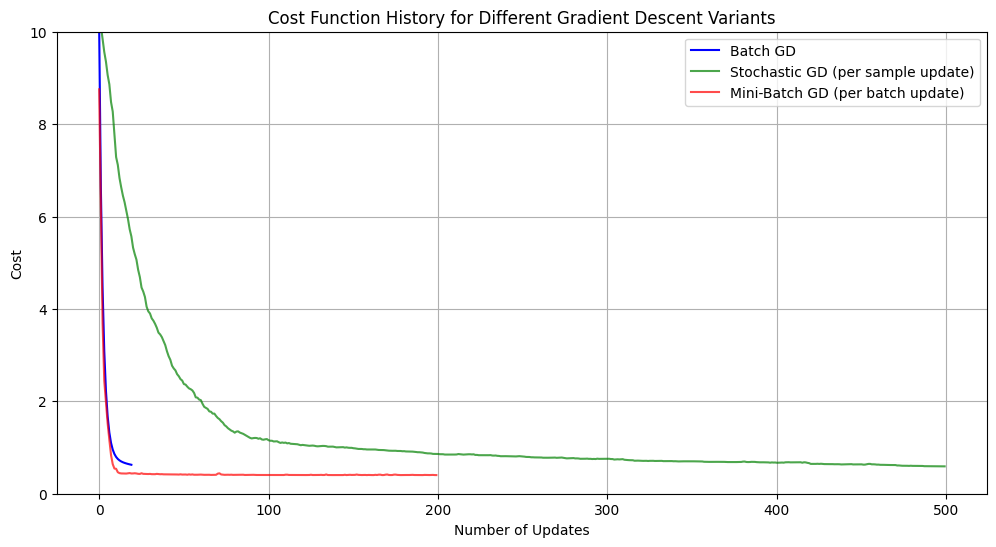

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# --- 1. Generate Synthetic Data for Linear Regression ---
np.random.seed(42)
X = 2 * np.random.rand(100, 1) # 100 data points, 1 feature
y = 4 + 3 * X + np.random.randn(100, 1) # y = 4 + 3x + noise

# Add bias term x0 = 1 to X for convenience in matrix operations
X_b = np.c_[np.ones((100, 1)), X] # Add x0 = 1 to each instance

# --- 2. Define Cost Function (Mean Squared Error) ---
def cost_function(theta, X_b, y):
    m = len(y)
    return (1/(2*m)) * np.sum((X_b.dot(theta) - y)**2)

# --- 3. Implement Gradient Descent Variants ---

def batch_gradient_descent(X_b, y, learning_rate=0.1, n_iterations=100):
    m = len(y)
    theta = np.random.randn(2, 1) # Random initialization
    cost_history = []
    theta_history = []

    for iteration in range(n_iterations):
        gradients = (1/m) * X_b.T.dot(X_b.dot(theta) - y)
        theta = theta - learning_rate * gradients
        cost_history.append(cost_function(theta, X_b, y))
        theta_history.append(theta.flatten())
    return theta, np.array(cost_history), np.array(theta_history)

def stochastic_gradient_descent(X_b, y, learning_rate=0.01, n_epochs=50):
    m = len(y)
    theta = np.random.randn(2, 1) # Random initialization
    cost_history = []
    theta_history = []

    for epoch in range(n_epochs):
        for i in range(m):
            random_index = np.random.randint(m)
            xi = X_b[random_index:random_index+1]
            yi = y[random_index:random_index+1]
            gradients = xi.T.dot(xi.dot(theta) - yi)
            theta = theta - learning_rate * gradients
            cost_history.append(cost_function(theta, X_b, y))
            theta_history.append(theta.flatten())
    return theta, np.array(cost_history), np.array(theta_history)

def mini_batch_gradient_descent(X_b, y, learning_rate=0.1, n_epochs=50, batch_size=10):
    m = len(y)
    theta = np.random.randn(2, 1) # Random initialization
    cost_history = []
    theta_history = []

    n_batches = int(np.ceil(m / batch_size))

    for epoch in range(n_epochs):
        shuffled_indices = np.random.permutation(m)
        X_b_shuffled = X_b[shuffled_indices]
        y_shuffled = y[shuffled_indices]

        for i in range(0, m, batch_size):
            xi = X_b_shuffled[i:i+batch_size]
            yi = y_shuffled[i:i+batch_size]
            gradients = (1/len(xi)) * xi.T.dot(xi.dot(theta) - yi)
            theta = theta - learning_rate * gradients
            cost_history.append(cost_function(theta, X_b, y))
            theta_history.append(theta.flatten())
    return theta, np.array(cost_history), np.array(theta_history)

# --- Run the variants ---
# Note: Parameters are tuned for illustrative purposes, not optimal performance.
bgd_theta, bgd_costs, bgd_thetas = batch_gradient_descent(X_b, y, learning_rate=0.1, n_iterations=20)
sgd_theta, sgd_costs, sgd_thetas = stochastic_gradient_descent(X_b, y, learning_rate=0.01, n_epochs=5)
mbgd_theta, mbgd_costs, mbgd_thetas = mini_batch_gradient_descent(X_b, y, learning_rate=0.1, n_epochs=20, batch_size=10)


# --- 4. Visualize Cost History ---
plt.figure(figsize=(12, 6))
plt.plot(bgd_costs, label='Batch GD', color='blue')
plt.plot(sgd_costs, label='Stochastic GD (per sample update)', color='green', alpha=0.7)
plt.plot(mbgd_costs, label='Mini-Batch GD (per batch update)', color='red', alpha=0.7)
plt.title('Cost Function History for Different Gradient Descent Variants')
plt.xlabel('Number of Updates')
plt.ylabel('Cost')
plt.legend()
plt.grid(True)
plt.ylim(0, 10)
plt.show()

The plot above illustrates the **cost function's value over the course of training iterations** for each Gradient Descent variant.

*   **Batch Gradient Descent (blue line)** shows a very smooth and consistent decrease in cost, as it computes the true gradient over the entire dataset before each update. This leads to a direct path towards the minimum. However, notice it has fewer updates for the same number of epochs, because it updates only once per epoch.

*   **Stochastic Gradient Descent (green line)** exhibits much noisier behavior, with significant fluctuations in cost. This is because it updates parameters based on individual samples, causing its path to be very erratic. Despite the noise, it generally trends downwards and can escape local minima more easily.

*   **Mini-Batch Gradient Descent (red line)** strikes a balance. Its cost curve is smoother than SGD but still shows some fluctuations, especially early on. It converges faster than BGD (due to more frequent updates) and is more stable than SGD, which is why it's the most commonly used approach.

While this plot shows the cost over *updates*, which makes SGD and MBGD look like they have more steps, it's also important to visualize their paths in the *parameter space* to see how they converge. Let's do that next.

/tmp/ipykernel_478/589763214.py:32: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  ax.plot(bgd_thetas[-1, 0], bgd_thetas[-1, 1], 'ro', markersize=8, color='blue', label='BGD Final')
/tmp/ipykernel_478/589763214.py:33: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  ax.plot(sgd_thetas[-1, 0], sgd_thetas[-1, 1], 'ro', markersize=8, color='green', label='SGD Final')
/tmp/ipykernel_478/589763214.py:34: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  ax.plot(mbgd_thetas[-1, 0], mbgd_thetas[-1, 1], 'ro', markersize=8, color='red', label='MBGD Final')


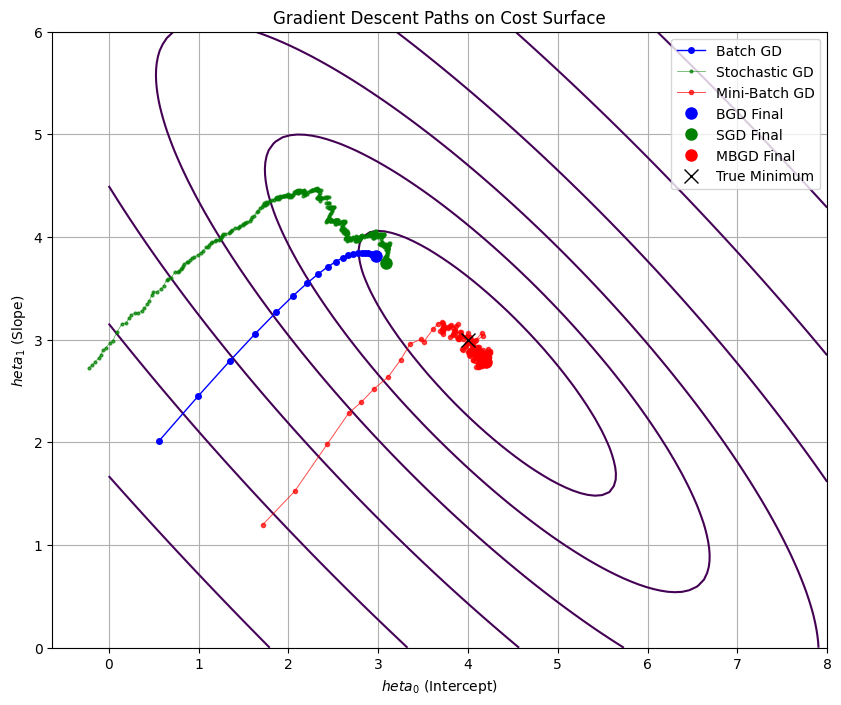

In [13]:
# --- Generate a grid for the cost function surface ---
# We need to reshape X_b and y for contour plotting
# The actual minimum for y = 4 + 3x is theta0=4, theta1=3

theta0_range = np.linspace(0, 8, 100)
theta1_range = np.linspace(0, 6, 100)

J_vals = np.zeros((len(theta0_range), len(theta1_range)))

for i, t0 in enumerate(theta0_range):
    for j, t1 in enumerate(theta1_range):
        theta_val = np.array([[t0], [t1]])
        J_vals[i, j] = cost_function(theta_val, X_b, y)

J_vals = J_vals.T # Transpose to match contour plot expectations

# --- Create the contour plot ---
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the contour lines of the cost function
ax.contour(theta0_range, theta1_range, J_vals, levels=np.logspace(-2, 3, 20), cmap='viridis')
ax.set_xlabel(r'$	heta_0$ (Intercept)')
ax.set_ylabel(r'$	heta_1$ (Slope)')
ax.set_title('Gradient Descent Paths on Cost Surface')

# Plot the paths for each variant
ax.plot(bgd_thetas[:, 0], bgd_thetas[:, 1], 'o-', label='Batch GD', color='blue', markersize=4, lw=1)
ax.plot(sgd_thetas[:, 0], sgd_thetas[:, 1], 'o-', label='Stochastic GD', color='green', markersize=2, lw=0.5, alpha=0.7)
ax.plot(mbgd_thetas[:, 0], mbgd_thetas[:, 1], 'o-', label='Mini-Batch GD', color='red', markersize=3, lw=0.7, alpha=0.7)

# Mark the final points
ax.plot(bgd_thetas[-1, 0], bgd_thetas[-1, 1], 'ro', markersize=8, color='blue', label='BGD Final')
ax.plot(sgd_thetas[-1, 0], sgd_thetas[-1, 1], 'ro', markersize=8, color='green', label='SGD Final')
ax.plot(mbgd_thetas[-1, 0], mbgd_thetas[-1, 1], 'ro', markersize=8, color='red', label='MBGD Final')

# Mark the true optimal point (from original data generation y = 4 + 3x)
ax.plot(4, 3, 'x', markersize=10, color='black', label='True Minimum')

ax.legend()
ax.grid(True)
plt.show()


This visualization shows the paths taken by the $\theta$ parameters (intercept $\theta_0$ and slope $\theta_1$) on the **cost function surface**. The contour lines represent points of equal cost, with the center being the global minimum.

*   **Batch Gradient Descent (blue line)**: Takes large, direct steps towards the minimum. Its path is smooth and converges stably. It's efficient when the cost surface is smooth and convex.

*   **Stochastic Gradient Descent (green line)**: Shows a much more erratic and noisy path. It jumps around significantly as it updates parameters based on individual training examples. This noise can help it escape shallow local minima in more complex, non-convex cost surfaces, but it also means it might oscillate around the minimum without ever truly settling.

*   **Mini-Batch Gradient Descent (red line)**: Offers a path that is less noisy than SGD but less direct than BGD. It takes steps that are a compromise between the stability of BGD and the speed/noise of SGD. It generally reaches the vicinity of the minimum faster than BGD and oscillates less violently than SGD.

Both plots clearly demonstrate the fundamental differences in how these three variants update their parameters and navigate the optimization landscape. Mini-Batch Gradient Descent, with its balanced approach, often proves to be the most practical choice for training large neural networks.

## 9. Optimizers

### Definition

An **Optimizer** is an algorithm or method used to modify the attributes of your neural network, such as weights and learning rate, in order to reduce the overall loss and improve the model's accuracy. While **Gradient Descent** (and its variants like SGD, Mini-Batch GD) is the foundational optimization algorithm, modern optimizers are built upon it, introducing various enhancements to accelerate training, stabilize convergence, and escape suboptimal solutions in complex loss landscapes. They determine how the gradients calculated by backpropagation are used to adjust the network's parameters.

### Why it's needed

While Gradient Descent is the bedrock of neural network training, its basic forms (BGD, SGD, MBGD) have limitations, especially in deep and complex networks with high-dimensional, non-convex loss landscapes. Optimizers are needed to address these challenges and improve the training process in several critical ways:

1.  **Faster Convergence**: Basic Gradient Descent can be slow, especially with large datasets or when the loss surface has long, narrow valleys (leading to zigzagging paths). Optimizers introduce mechanisms like momentum, adaptive learning rates, or second-order information approximations to speed up convergence, allowing models to learn faster.

2.  **Escaping Local Minima and Saddle Points**: In non-convex loss landscapes (common in deep learning), there are numerous local minima and saddle points. Basic Gradient Descent can get stuck in these suboptimal points. Optimizers, particularly those with momentum or adaptive learning rates, can often 'push through' or 'slide past' these areas, leading to better generalization.

3.  **Handling Vanishing and Exploding Gradients**: As networks get deeper, gradients can become extremely small (vanishing) or extremely large (exploding), hindering effective learning. Some optimizers are designed to adapt the learning rate for different parameters, helping to stabilize gradient magnitudes and improve training.

4.  **Improved Generalization**: By navigating the loss landscape more effectively, optimizers can help models find flatter minima, which often correspond to better generalization performance on unseen data.

5.  **Simplified Hyperparameter Tuning**: While all optimizers have hyperparameters, some (like Adam) are less sensitive to their initial settings or adapt their internal learning rates, reducing the burden of manual tuning compared to, say, finding the perfect fixed learning rate for SGD.

6.  **Addressing Sparse Gradients**: For very sparse data (e.g., in natural language processing), some parameters might rarely receive updates. Optimizers like AdaGrad and RMSProp can assign larger learning rates to infrequently updated parameters, helping them learn more effectively.

In essence, optimizers are advanced strategies that refine the process of adjusting network parameters, making the training of deep neural networks more robust, efficient, and effective in finding better solutions.

### Intuition

Let's revisit our analogy of being lost in a dense fog on a mountainous terrain, trying to find the lowest point of a valley. With basic Gradient Descent, your strategy was simply: "Feel the slope directly underfoot, take a small step downhill, and repeat." This works, but it can be slow and might get stuck.

Optimizers are like bringing more sophisticated tools and strategies to this task:

1.  **SGD with Momentum: "Building Up Speed"**
    *   Imagine you're rolling a heavy ball down the mountain. If the slope temporarily flattens or even goes slightly uphill (a small local bump), the ball's existing momentum will carry it through. It doesn't just react to the immediate slope; it remembers the *direction and speed* it was moving before. This helps it speed up in consistent directions and push past small obstacles. When the slope changes direction frequently (oscillations), the momentum helps to smooth out the movement, reducing zigzagging.

2.  **AdaGrad (Adaptive Gradient): "Smaller Steps on Steep, Larger Steps on Flat"**
    *   Now, imagine you're walking, but you have a special map that tells you how steep the terrain has *historically* been in each direction. If you've been consistently walking down a very steep path (large gradients), AdaGrad tells you to take *smaller* steps in that direction, so you don't overshoot. If you've been on a very flat path (small gradients), it encourages *larger* steps. It adapts your step size for each parameter individually based on its past gradients. This is useful for sparse data where some features might have very infrequent but important gradients.

3.  **RMSProp (Root Mean Square Propagation): "Recent History Matters More"**
    *   RMSProp is an improvement on AdaGrad. Instead of accumulating *all* past squared gradients, it gives more weight to *recent* gradients. It's like having a short-term memory map. If you were walking down a steep path, but now it's flat, RMSProp quickly adjusts your step size to be larger, rather than keeping it small because of distant past steepness. This prevents the learning rate from decaying too aggressively, which was a problem with AdaGrad.

4.  **Adam (Adaptive Moment Estimation): "Best of Both Worlds"**
    *   Adam is like combining the best features of Momentum and RMSProp. You're still rolling that heavy ball (momentum), but now your map also has a short-term memory of how steep each path has been (RMSProp). So, it considers both the direction of past movements and the individual adaptiveness of step sizes. It's often very effective because it balances these two ideas, leading to fast and stable convergence across a wide range of problems.

In essence, optimizers provide more intelligent ways to interpret the local slope (gradient) and adjust the parameters. They remember past movements, adapt step sizes for different directions, and generally make the journey down the error mountain much faster and more reliable than simple Gradient Descent.

### 1. SGD with Momentum

#### Definition

**SGD with Momentum** is an extension of the traditional Stochastic Gradient Descent (SGD) optimization algorithm that helps accelerate learning, particularly in directions of consistent gradient and dampens oscillations in directions of high-variance gradients. It achieves this by accumulating a 'velocity' of gradients over past updates and using this velocity to guide the current update. This effectively allows the optimizer to 'remember' previous update directions and continue moving in that direction, even if the current gradient is small or points in a slightly different way. This helps SGD overcome local minima, navigate saddle points, and accelerate convergence in shallow valleys.

#### Why it's needed

While basic SGD makes frequent updates and can escape shallow local minima, it suffers from several issues:

1.  **Oscillations**: When the loss function's landscape is steep in one direction and shallow in another (e.g., a narrow valley), SGD tends to oscillate back and forth across the steep sides, making slow progress along the shallow bottom. This inefficient movement slows down convergence.
2.  **Slow Convergence in Plateaus/Local Minima**: If SGD encounters a flat region (plateau) or a small local minimum, the gradients become very small, causing the algorithm to slow down significantly or get stuck.
3.  **Difficulty Navigating Saddle Points**: Saddle points are regions where the gradient is zero in some directions but negative in others. SGD can struggle to escape these points efficiently.

SGD with Momentum addresses these problems by introducing a 'memory' of past gradients, allowing it to build up speed in consistent directions and smooth out oscillations, thereby leading to faster and more stable convergence.

#### Intuition

Think of basic SGD as a ball rolling down a hill, but it's very light and has no momentum. It reacts immediately to every bump and divot, easily getting jostled off course or stuck in a small crevice.

Now, imagine **SGD with Momentum** as a heavier ball rolling down the same hill. Instead of solely relying on the immediate slope, it also considers where it's been rolling. If it's been consistently rolling downhill in a certain direction, it builds up speed (momentum).

Here's how it helps:

*   **Smoother Ride in Valleys**: When the path zigzags (like in a narrow valley), the momentum helps smooth out the oscillations. Instead of veering sharply with every small change in slope, the ball's inertia keeps it moving predominantly in the general downhill direction, crossing the valley more efficiently.
*   **Pushing Through Bumps**: If it encounters a small uphill slope or a flat spot (a shallow local minimum or plateau), its built-up momentum can carry it past, preventing it from getting stuck. It doesn't just stop because the immediate gradient is zero or positive.
*   **Accelerated Descent**: When the slope is consistently pointing downhill, the momentum causes the ball to pick up speed, reaching the bottom much faster than if it were just taking tiny, hesitant steps.

So, momentum gives the optimization process a sense of 'inertia,' allowing it to move more purposefully and efficiently across the complex loss landscape.

#### Math

SGD with Momentum introduces a new term, often called `velocity` or `accumulated gradient`, which stores the exponentially weighted average of past gradients. This velocity term is then used to update the parameters, rather than directly using the current gradient.

Let:
*   $\mathbf{\theta}$ be the parameter vector (weights and biases).
*   $J(\mathbf{\theta})$ be the loss function.
*   $\nabla J(\mathbf{\theta})$ be the current gradient of the loss function with respect to the parameters.
*   $\alpha$ be the learning rate.
*   $\beta$ (or $\gamma$) be the **momentum coefficient**, a hyperparameter typically set between 0.9 and 0.99. It controls how much of the previous velocity is retained.
*   $\mathbf{v}$ be the velocity vector (initialized to zeros).

#### Formula

The update rules for SGD with Momentum involve two steps at each iteration (or after each mini-batch):

1.  **Update the velocity vector**: The new velocity is a combination of the previous velocity and the current gradient.
    $$ \mathbf{v} \leftarrow \beta \mathbf{v} + (1 - \beta) \nabla J(\mathbf{\theta}) $$
    (Some formulations use $\mathbf{v} \leftarrow \beta \mathbf{v} + \nabla J(\mathbf{\theta})$ and absorb the $(1-\beta)$ into the learning rate, but the above is a common and robust formulation that keeps the gradient term on a similar scale to the velocity term.)

2.  **Update the parameters**: The parameters are updated using this new velocity, scaled by the learning rate.
    $$ \mathbf{\theta} \leftarrow \mathbf{\theta} - \alpha \mathbf{v} $$

Alternatively, a more common formulation, especially in deep learning libraries, often applies the momentum directly to the gradient term:

1.  **Update the velocity vector (or momentum term)**:
    $$ \mathbf{v} \leftarrow \beta \mathbf{v} + \nabla J(\mathbf{\theta}) $$

2.  **Update the parameters**:
    $$ \mathbf{\theta} \leftarrow \mathbf{\theta} - \alpha \mathbf{v} $$

We will use this latter, more common formulation for our numerical example and Python code for consistency with most implementations.

In this formulation:
*   $\mathbf{v}$ accumulates a moving average of the gradients.
*   The parameter update is scaled by the learning rate and applied in the direction of the accumulated gradient.

#### Numerical Example

Let's apply the SGD with Momentum update rule to a simple scenario. Suppose we are minimizing a 1D quadratic function $J(\theta) = \theta^2$ (for simplicity), and we have an initial parameter $\theta$ and a sequence of gradients.

**Given Initial Values:**
*   Initial parameter: $\theta = 5.0$
*   Initial velocity: $\mathbf{v} = 0.0$
*   Learning rate: $\alpha = 0.1$
*   Momentum coefficient: $\beta = 0.9$

**Scenario: Iterations with varying gradients**

We will simulate a few steps, calculating the gradient at each step for $J(\theta) = \theta^2$, so $\nabla J(\theta) = 2\theta$.

---

**Iteration 1:**
1.  **Current Parameter**: $\theta = 5.0$
2.  **Calculate Gradient**: $\nabla J(\theta) = 2 \cdot 5.0 = 10.0$
3.  **Update Velocity**:
    $\mathbf{v} \leftarrow \beta \mathbf{v} + \nabla J(\theta) = 0.9 \cdot 0.0 + 10.0 = 10.0$
4.  **Update Parameter**:
    $\theta \leftarrow \theta - \alpha \mathbf{v} = 5.0 - 0.1 \cdot 10.0 = 5.0 - 1.0 = 4.0$

---

**Iteration 2:**
1.  **Current Parameter**: $\theta = 4.0$
2.  **Calculate Gradient**: $\nabla J(\theta) = 2 \cdot 4.0 = 8.0$
3.  **Update Velocity**:
    $\mathbf{v} \leftarrow \beta \mathbf{v} + \nabla J(\theta) = 0.9 \cdot 10.0 + 8.0 = 9.0 + 8.0 = 17.0$
4.  **Update Parameter**:
    $\theta \leftarrow \theta - \alpha \mathbf{v} = 4.0 - 0.1 \cdot 17.0 = 4.0 - 1.7 = 2.3$

Notice how the velocity is building up. Even though the gradient is decreasing (from 10 to 8), the momentum term from the previous step is still contributing significantly, making the parameter update larger than if we only used the current gradient (which would be $0.1 \cdot 8.0 = 0.8$).

---

**Iteration 3:**
1.  **Current Parameter**: $\theta = 2.3$
2.  **Calculate Gradient**: $\nabla J(\theta) = 2 \cdot 2.3 = 4.6$
3.  **Update Velocity**:
    $\mathbf{v} \leftarrow \beta \mathbf{v} + \nabla J(\theta) = 0.9 \cdot 17.0 + 4.6 = 15.3 + 4.6 = 19.9$
4.  **Update Parameter**:
    $\theta \leftarrow \theta - \alpha \mathbf{v} = 2.3 - 0.1 \cdot 19.9 = 2.3 - 1.99 = 0.31$

---

**Summary of Iterations:**

| Iteration | $\theta_{\text{old}}$ | $\nabla J(\theta)$ | $\mathbf{v}_{\text{old}}$ | $\mathbf{v}_{\text{new}}$ | $\Delta\theta = -\alpha \mathbf{v}_{\text{new}}$ | $\theta_{\text{new}}$ |
| :-------- | :----------- | :-------------- | :------------ | :------------ | :------------------------------- | :---------- |
| 1         | 5.0          | 10.0            | 0.0           | 10.0          | -1.0                             | 4.0         |
| 2         | 4.0          | 8.0             | 10.0          | 17.0          | -1.7                             | 2.3         |
| 3         | 2.3          | 4.6             | 17.0          | 19.9          | -1.99                            | 0.31        |

This example demonstrates how momentum accumulates, leading to larger steps as long as the gradient consistently points in the same direction, thereby accelerating convergence.

#### Visualization

Let's visualize the convergence path of SGD with Momentum compared to standard SGD on our simple linear regression problem. This will highlight how momentum smooths out the optimization path and accelerates convergence.

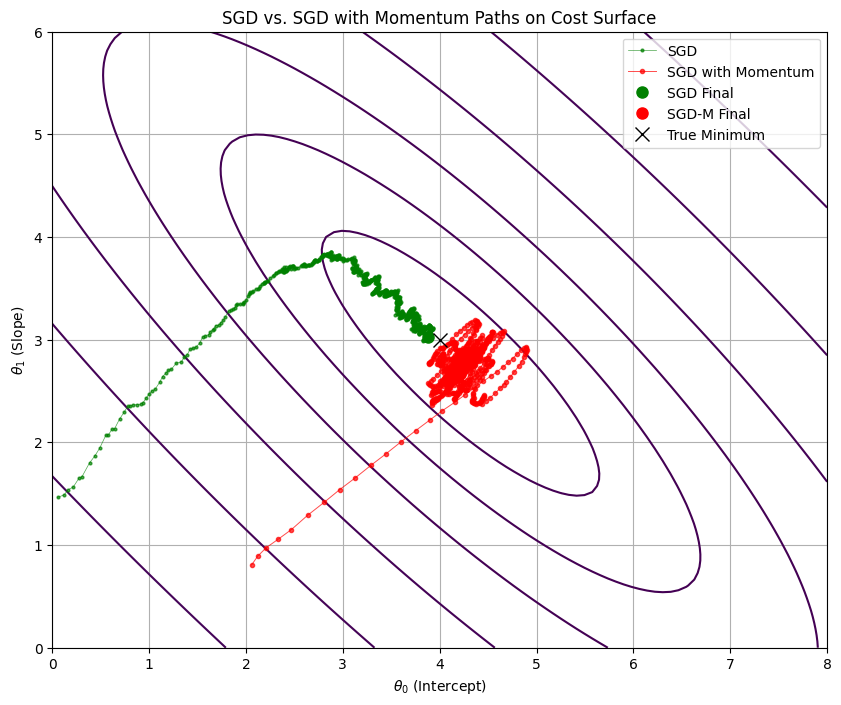

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Generate Synthetic Data for Linear Regression (same as before) ---
np.random.seed(42)
X = 2 * np.random.rand(100, 1) # 100 data points, 1 feature
y = 4 + 3 * X + np.random.randn(100, 1) # y = 4 + 3x + noise
X_b = np.c_[np.ones((100, 1)), X] # Add x0 = 1 to each instance

# --- 2. Define Cost Function (Mean Squared Error) ---
def cost_function(theta, X_b, y):
    m = len(y)
    return (1/(2*m)) * np.sum((X_b.dot(theta) - y)**2)

# --- 3. Implement Stochastic Gradient Descent (for comparison) ---
def stochastic_gradient_descent_base(X_b, y, learning_rate=0.01, n_epochs=50):
    m = len(y)
    theta = np.random.randn(2, 1) # Random initialization
    cost_history = []
    theta_history = []

    for epoch in range(n_epochs):
        shuffled_indices = np.random.permutation(m)
        X_b_shuffled = X_b[shuffled_indices]
        y_shuffled = y[shuffled_indices]

        for i in range(m):
            xi = X_b_shuffled[i:i+1]
            yi = y_shuffled[i:i+1]
            gradients = xi.T.dot(xi.dot(theta) - yi)
            theta = theta - learning_rate * gradients
            cost_history.append(cost_function(theta, X_b, y))
            theta_history.append(theta.flatten())
    return theta, np.array(cost_history), np.array(theta_history)

# --- 4. Implement SGD with Momentum ---
def sgd_with_momentum(X_b, y, learning_rate=0.01, n_epochs=50, momentum_coefficient=0.9):
    m = len(y)
    theta = np.random.randn(2, 1) # Random initialization
    velocity = np.zeros((2, 1)) # Initialize velocity to zeros
    cost_history = []
    theta_history = []

    for epoch in range(n_epochs):
        shuffled_indices = np.random.permutation(m)
        X_b_shuffled = X_b[shuffled_indices]
        y_shuffled = y[shuffled_indices]

        for i in range(m):
            xi = X_b_shuffled[i:i+1]
            yi = y_shuffled[i:i+1]

            # Calculate current gradient (for a single sample)
            gradients = xi.T.dot(xi.dot(theta) - yi)

            # Update velocity
            velocity = momentum_coefficient * velocity + gradients

            # Update parameters
            theta = theta - learning_rate * velocity

            cost_history.append(cost_function(theta, X_b, y))
            theta_history.append(theta.flatten())
    return theta, np.array(cost_history), np.array(theta_history)

# --- 5. Run the optimizers ---
# Using slightly higher learning rate for SGD Momentum for clearer demonstration of its power
sgd_base_theta, sgd_base_costs, sgd_base_thetas = stochastic_gradient_descent_base(X_b, y, learning_rate=0.01, n_epochs=10)
sgdm_theta, sgdm_costs, sgdm_thetas = sgd_with_momentum(X_b, y, learning_rate=0.01, n_epochs=10, momentum_coefficient=0.9)

# --- 6. Generate a grid for the cost function surface (same as before) ---
theta0_range = np.linspace(0, 8, 100)
theta1_range = np.linspace(0, 6, 100)
J_vals = np.zeros((len(theta0_range), len(theta1_range)))

for i, t0 in enumerate(theta0_range):
    for j, t1 in enumerate(theta1_range):
        theta_val = np.array([[t0], [t1]])
        J_vals[i, j] = cost_function(theta_val, X_b, y)
J_vals = J_vals.T

# --- 7. Create the contour plot ---
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the contour lines of the cost function
ax.contour(theta0_range, theta1_range, J_vals, levels=np.logspace(-2, 3, 20), cmap='viridis')
ax.set_xlabel(r'$\theta_0$ (Intercept)')
ax.set_ylabel(r'$\theta_1$ (Slope)')
ax.set_title('SGD vs. SGD with Momentum Paths on Cost Surface')

# Plot the paths for each variant
ax.plot(sgd_base_thetas[:, 0], sgd_base_thetas[:, 1], 'o-', label='SGD', color='green', markersize=2, lw=0.5, alpha=0.7)
ax.plot(sgdm_thetas[:, 0], sgdm_thetas[:, 1], 'o-', label='SGD with Momentum', color='red', markersize=3, lw=0.7, alpha=0.7)

# Mark the final points
ax.plot(sgd_base_thetas[-1, 0], sgd_base_thetas[-1, 1], 'o', markersize=8, color='green', label='SGD Final')
ax.plot(sgdm_thetas[-1, 0], sgdm_thetas[-1, 1], 'o', markersize=8, color='red', label='SGD-M Final')

# Mark the true optimal point (from original data generation y = 4 + 3x)
ax.plot(4, 3, 'x', markersize=10, color='black', label='True Minimum')

ax.legend()
ax.grid(True)
plt.show()


### Summary with comparison plots

The plot above beautifully illustrates the core difference between basic Stochastic Gradient Descent (SGD) and SGD with Momentum on our linear regression cost surface.

*   **SGD (Green Path)**: You can see the green path for basic SGD is quite **zig-zaggy and erratic**. This is because it updates parameters based on the gradient of just one (or a small batch of) randomly selected data points at a time. This noisy nature means it struggles to make consistent progress down the 'valley' of the cost function, constantly overshooting and correcting.

*   **SGD with Momentum (Red Path)**: In contrast, the red path for SGD with Momentum is much **smoother and more directed**. It builds up 'velocity' in the consistent downhill direction, allowing it to move more directly towards the minimum. You can observe it covers more ground initially and is less susceptible to the local noise of individual gradients. It smoothly glides towards the true minimum (black 'x') with fewer oscillations.

This visualization clearly demonstrates how momentum helps to accelerate learning in the relevant direction and dampens oscillations, leading to more efficient and stable convergence towards the optimal parameters. Both algorithms eventually reach the vicinity of the minimum, but SGD with Momentum does so more effectively and with a clearer path.

### Pros of SGD with Momentum:

*   **Faster Convergence**: By accumulating gradients, Momentum accelerates the training process, especially in directions with consistent gradients, allowing the model to reach the minimum faster than basic SGD.
*   **Dampens Oscillations**: It helps to smooth out the training process, reducing the zig-zagging movements that basic SGD often exhibits, particularly in objective functions with high curvature or narrow valleys.
*   **Escapes Local Minima and Saddle Points**: The 'inertia' provided by momentum can help the optimizer push through shallow local minima, plateaus, and saddle points, which can trap basic SGD.
*   **Improved Stability**: The accumulated velocity provides a more stable direction for updates compared to relying solely on the noisy gradient of a single mini-batch.

### Cons of SGD with Momentum:

*   **Additional Hyperparameter**: It introduces a new hyperparameter, the `momentum_coefficient` (often denoted as $\beta$ or $\rho$), which needs to be carefully tuned. A suboptimal value can either lead to slow convergence or overshooting the minimum.
*   **Memory Overhead**: It requires storing the velocity vector (or momentum term) for each parameter, which slightly increases memory usage compared to basic SGD.
*   **Can Overshoot**: If the momentum coefficient is too high, or the learning rate is not properly decayed, the accumulated momentum might cause the optimizer to overshoot the minimum, especially in regions where the gradient rapidly changes direction.

### Time Complexity of SGD with Momentum:

For each update step (typically per mini-batch):

*   **Gradient Calculation**: This is the same as basic SGD (or Mini-Batch GD) and involves a forward pass and a backward pass (backpropagation). The complexity is $O(M \times P)$, where $M$ is the mini-batch size and $P$ is the number of parameters in the network.
*   **Velocity Update**: This involves a vector scalar multiplication ($\beta \times \text{previous_velocity}$) and a vector addition (with the current gradient). This operation is $O(P)$.
*   **Parameter Update**: This involves a vector scalar multiplication ($\text{learning_rate} \times \text{velocity}$) and a vector subtraction. This operation is also $O(P)$.

**Overall Time Complexity per Update**: The dominant part is still the gradient calculation. Thus, for each update, the complexity remains approximately $O(M \times P)$.

**Total Training Time Complexity**: Similar to basic SGD, it's roughly $O(\text{Epochs} \times \text{Number of mini-batches} \times M \times P)$, which simplifies to $O(\text{Epochs} \times \text{Total Samples} \times P)$.

In summary, SGD with Momentum adds a minimal computational overhead per update ($O(P)$ operations) compared to the gradient calculation ($O(M \times P)$ operations), but it significantly improves the **convergence rate** and **stability** of training, often leading to a reduction in the total number of epochs required to achieve good performance.

Now that we've thoroughly covered SGD with Momentum, including its definition, need, intuition, math, numerical example, visualization, pros, cons, and time complexity, we can move on to other important optimizers. Next, we'll explore **AdaGrad**, another adaptive learning rate optimizer.

### 2. AdaGrad

#### Definition

#### Why it's needed

Traditional optimizers like SGD use a single global learning rate for all parameters, which remains constant throughout training (or is manually decayed). This approach presents several challenges:

1.  **Varying Feature Frequencies**: In many datasets, features do not occur with equal frequency. For example, in natural language processing, some words are very common (`'the'`, `'a'`), while others are very rare (`'onomatopoeia'`, `'serendipity'`). With a global learning rate:
    *   A high learning rate might cause parameters associated with **rare features** to oscillate wildly or diverge, as their gradients are infrequent and potentially large.
    *   A low learning rate, chosen to prevent divergence for rare features, might make learning for **frequent features** extremely slow, as their gradients are consistently small.

2.  **Difficulty in Setting Learning Rate**: A single learning rate needs to be carefully tuned. A value that works well for some parameters might be too large for others, and vice-versa. This manual tuning can be time-consuming and sub-optimal, especially in deep, complex networks.

3.  **Sub-optimal Convergence**: A fixed learning rate struggles to adapt to the geometry of the loss landscape, which can vary significantly across different dimensions. It might take many small steps in some directions and overshoot in others, leading to inefficient convergence.

**AdaGrad** (Adaptive Gradient algorithm) addresses these issues by **adapting the learning rate for each parameter individually**. It assigns smaller learning rates to parameters associated with frequently occurring features (or large gradients) and larger learning rates to parameters associated with infrequent features (or small gradients). This adaptive approach improves training efficiency and is particularly well-suited for problems with sparse data or features with diverse frequencies.

#### Intuition

Imagine you are navigating a complex landscape (our loss function) to find the lowest point. In this landscape, some directions are consistently bumpy and steep (parameters with frequently large gradients, like common features in sparse data), while other directions are mostly flat with occasional steep drops (parameters with infrequent but significant gradients, like rare features).

**Standard Gradient Descent** is like using a single, fixed-size step for every direction. If the step size is too large, you might overshoot the flat regions and oscillate wildly in the steep regions. If it's too small, you'll crawl in the flat regions and take forever to reach the bottom.

**AdaGrad (Adaptive Gradient) is like having a personalized step counter for each foot (parameter)**. This counter keeps track of *how much* you've walked (how large the gradients have been) in that specific direction *historically*. At each step:

1.  **For directions that have seen many large steps (frequent large gradients)**: Your personal step counter for that direction will be very high. AdaGrad then tells you, "You've been walking a lot here; let's take **smaller steps** now to fine-tune and avoid overshooting." This prevents oscillations and allows for careful descent in consistently steep dimensions.

2.  **For directions that have seen few small steps (infrequent small gradients)**: Your personal step counter for that direction will be low. AdaGrad tells you, "You haven't explored much here; let's take **larger steps** to make progress more quickly." This helps parameters associated with rare features to learn faster and make more meaningful updates.

So, in essence, AdaGrad slows down learning for parameters that have already made significant progress (accumulated large gradients) and speeds up learning for parameters that are still lagging behind (accumulated small gradients). This adaptive approach allows it to find a good balance, making it particularly effective for data where feature frequencies vary widely, ensuring that even rare but important features get adequate learning opportunities.

#### Intuition

#### Math

AdaGrad (Adaptive Gradient) is an optimization algorithm that adapts the learning rate for each parameter individually based on the historical sum of squared gradients. This means that parameters that have seen consistently large gradients will have their learning rate decreased, while parameters with small or infrequent gradients will have their learning rate increased. This is done by maintaining a separate accumulation variable for each parameter.

Let:
*   $\mathbf{\theta}$ be the parameter vector (weights and biases).
*   $J(\mathbf{\theta})$ be the loss function.
*   $\nabla J(\mathbf{\theta}_t)$ be the gradient of the loss function with respect to the parameters at time step $t$.
*   $\alpha$ be the global learning rate.
*   $\mathbf{g}_t$ be the gradient vector at time step $t$, i.e., $\mathbf{g}_t = \nabla J(\mathbf{\theta}_t)$.
*   $\mathbf{G}_t$ be a diagonal matrix where each diagonal element $i,i$ is the sum of the squares of the past gradients with respect to parameter $\theta_i$ up to time step $t$.
*   $\epsilon$ is a small smoothing term (e.g., $10^{-8}$) to prevent division by zero.

AdaGrad's core idea is to scale down the learning rate for each parameter inversely proportional to the square root of the sum of its historical squared gradients. Rather than storing the full diagonal matrix $\mathbf{G}_t$, most implementations maintain a vector $\mathbf{s}_t$ (or $\mathbf{r}_t$ in some literature) which stores the sum of squared gradients for each parameter.

Let $\mathbf{s}_t$ be a vector initialized to zeros, where $\mathbf{s}_t[i]$ accumulates the sum of squares of gradients for parameter $\theta_i$.

#### Formula

At each time step $t$ (after processing a mini-batch), AdaGrad performs the following updates:

1. **Accumulate Squared Gradients**: The squares of the current gradients are accumulated into the $\mathbf{s}_t$ vector. This accumulation happens element-wise.

   $$
   \mathbf{s}_t
   =
   \mathbf{s}_{t-1}
   +
   \mathbf{g}_t
   \odot
   \mathbf{g}_t
   $$

   Where:

   * $\mathbf{s}_t$: The vector storing the sum of squared gradients for each parameter up to time $t$. It is initialized to a vector of zeros:

     $$
     \mathbf{s}_0=\mathbf{0}
     $$

   * $\mathbf{g}_t$: The gradient vector of the loss function with respect to the parameters at time step $t$.

   * $\odot$: Denotes the element-wise (Hadamard) product.

2.  **Parameter Update**: The parameters are updated using the global learning rate, scaled inversely by the square root of the accumulated squared gradients for each parameter. A small epsilon term is added for numerical stability.

    $$ \mathbf{\theta}_{t+1} = \mathbf{\theta}_t - \frac{\alpha}{\sqrt{\mathbf{s}_t + \epsilon}} \odot \mathbf{g}_t $$

    Where:
    *   $\mathbf{\theta}_t$: The parameter vector at time step $t$.
    *   $\alpha$: The global learning rate.
    *   $\sqrt{\mathbf{s}_t + \epsilon}$: The element-wise square root of the accumulated squared gradients, plus a small smoothing term $\epsilon$ to prevent division by zero. This term effectively adapts the learning rate for each parameter.
    *   $\odot$: Denotes the element-wise (Hadamard) product.

This formula ensures that each parameter has its own adaptive learning rate. Parameters with large historical gradients (meaning they've been updated frequently or with large steps) will have a larger value in $\mathbf{s}_t$, leading to a smaller effective learning rate ($\frac{\alpha}{\sqrt{\mathbf{s}_t + \epsilon}}$). Conversely, parameters with small historical gradients will have a larger effective learning rate.

#### Numerical Example

Let's consider a simple 2-dimensional parameter vector $\mathbf{\theta} = \begin{pmatrix} \theta_0 \\ \theta_1 \end{pmatrix}$ and a loss function $J(\mathbf{\theta})$ that generates the following gradients over two time steps. We'll trace how AdaGrad updates these parameters.

**Given Initial Values:**
*   Initial parameters: $\mathbf{\theta}_0 = \begin{pmatrix} 0.0 \\ 0.0 \end{pmatrix}$
*   Initial accumulated squared gradients: $\mathbf{s}_0 = \begin{pmatrix} 0.0 \\ 0.0 \end{pmatrix}$
*   Global learning rate: $\alpha = 0.01$
*   Smoothing term: $\epsilon = 10^{-8}$

**Scenario: Two Iterations with Different Gradients**

Assume the gradients at each time step are:
*   Time step $t=1$: $\mathbf{g}_1 = \begin{pmatrix} 0.5 \\ 0.1 \end{pmatrix}$
*   Time step $t=2$: $\mathbf{g}_2 = \begin{pmatrix} 0.2 \\ 0.8 \end{pmatrix}$

---

**Iteration 1 (Time Step $t=1$):**

1.  **Current Parameters**: $\mathbf{\theta}_0 = \begin{pmatrix} 0.0 \\ 0.0 \end{pmatrix}$
2.  **Current Gradients**: $\mathbf{g}_1 = \begin{pmatrix} 0.5 \\ 0.1 \end{pmatrix}$
3. **Accumulate Squared Gradients**:

   $$
   \mathbf{s}_1
   =
   \mathbf{s}_0
   +
   \mathbf{g}_1
   \odot
   \mathbf{g}_1
   $$

   $$
   \mathbf{s}_1
   =
   \begin{pmatrix}
   0.0\\
   0.0
   \end{pmatrix}
   +
   \begin{pmatrix}
   0.5^2\\
   0.1^2
   \end{pmatrix}
   =
   \begin{pmatrix}
   0.0\\
   0.0
   \end{pmatrix}
   +
   \begin{pmatrix}
   0.25\\
   0.01
   \end{pmatrix}
   =
   \begin{pmatrix}
   0.25\\
   0.01
   \end{pmatrix}
   $$

4. **Parameter Update**:

   $$
   \mathbf{\theta}_1
   =
   \mathbf{\theta}_0
   -
   \frac{\alpha}
   {\sqrt{\mathbf{s}_1+\epsilon}}
   \odot
   \mathbf{g}_1
   $$

   $$
   \mathbf{\theta}_1
   =
   \begin{pmatrix}
   0.0\\
   0.0
   \end{pmatrix}
   -
   \frac{0.01}
   {\sqrt{
   \begin{pmatrix}
   0.25\\
   0.01
   \end{pmatrix}
   +\epsilon}}
   \odot
   \begin{pmatrix}
   0.5\\
   0.1
   \end{pmatrix}
   $$

   **Calculate adaptive learning rates (element-wise):**

   $$
   \frac{0.01}{\sqrt{0.25+\epsilon}}
   \approx
   \frac{0.01}{0.5}
   =
   0.02
   $$

   $$
   \frac{0.01}{\sqrt{0.01+\epsilon}}
   \approx
   \frac{0.01}{0.1}
   =
   0.1
   $$

   $$
   \mathbf{\theta}_1
   =
   \begin{pmatrix}
   0.0\\
   0.0
   \end{pmatrix}
   -
   \begin{pmatrix}
   0.02\\
   0.1
   \end{pmatrix}
   \odot
   \begin{pmatrix}
   0.5\\
   0.1
   \end{pmatrix}
   $$

   $$
   \mathbf{\theta}_1
   =
   \begin{pmatrix}
   0.0\\
   0.0
   \end{pmatrix}
   -
   \begin{pmatrix}
   0.02 \times 0.5\\
   0.1 \times 0.1
   \end{pmatrix}
   =
   \begin{pmatrix}
   0.0\\
   0.0
   \end{pmatrix}
   -
   \begin{pmatrix}
   0.01\\
   0.01
   \end{pmatrix}
   =
   \begin{pmatrix}
   -0.01\\
   -0.01
   \end{pmatrix}
   $$

---

**Iteration 2 (Time Step $t=2$):**

1.  **Current Parameters**: $\mathbf{\theta}_1 = \begin{pmatrix} -0.01 \\ -0.01 \end{pmatrix}$
2.  **Current Gradients**: $\mathbf{g}_2 = \begin{pmatrix} 0.2 \\ 0.8 \end{pmatrix}$
3. **Accumulate Squared Gradients**:

   $$
   \mathbf{s}_2
   =
   \mathbf{s}_1
   +
   \mathbf{g}_2
   \odot
   \mathbf{g}_2
   $$

   $$
   \mathbf{s}_2
   =
   \begin{pmatrix}
   0.25\\
   0.01
   \end{pmatrix}
   +
   \begin{pmatrix}
   0.2^2\\
   0.8^2
   \end{pmatrix}
   =
   \begin{pmatrix}
   0.25\\
   0.01
   \end{pmatrix}
   +
   \begin{pmatrix}
   0.04\\
   0.64
   \end{pmatrix}
   =
   \begin{pmatrix}
   0.29\\
   0.65
   \end{pmatrix}
   $$

4. **Parameter Update**:

   $$
   \mathbf{\theta}_2
   =
   \mathbf{\theta}_1
   -
   \frac{\alpha}
   {\sqrt{\mathbf{s}_2+\epsilon}}
   \odot
   \mathbf{g}_2
   $$

   $$
   \mathbf{\theta}_2
   =
   \begin{pmatrix}
   -0.01\\
   -0.01
   \end{pmatrix}
   -
   \frac{0.01}
   {\sqrt{
   \begin{pmatrix}
   0.29\\
   0.65
   \end{pmatrix}
   +\epsilon}}
   \odot
   \begin{pmatrix}
   0.2\\
   0.8
   \end{pmatrix}
   $$

   **Calculate adaptive learning rates (element-wise):**

   $$
   \frac{0.01}{\sqrt{0.29+\epsilon}}
   \approx
   \frac{0.01}{0.5385}
   \approx
   0.01857
   $$

   $$
   \frac{0.01}{\sqrt{0.65+\epsilon}}
   \approx
   \frac{0.01}{0.8062}
   \approx
   0.01240
   $$

   $$
   \mathbf{\theta}_2
   =
   \begin{pmatrix}
   -0.01\\
   -0.01
   \end{pmatrix}
   -
   \begin{pmatrix}
   0.01857\\
   0.01240
   \end{pmatrix}
   \odot
   \begin{pmatrix}
   0.2\\
   0.8
   \end{pmatrix}
   $$

   $$
   \mathbf{\theta}_2
   =
   \begin{pmatrix}
   -0.01\\
   -0.01
   \end{pmatrix}
   -
   \begin{pmatrix}
   0.01857 \times 0.2\\
   0.01240 \times 0.8
   \end{pmatrix}
   =
   \begin{pmatrix}
   -0.01\\
   -0.01
   \end{pmatrix}
   -
   \begin{pmatrix}
   0.003714\\
   0.00992
   \end{pmatrix}
   =
   \begin{pmatrix}
   -0.013714\\
   -0.01992
   \end{pmatrix}
   $$

---

**Summary of Iterations:**

| Iteration | $\mathbf{\theta}_{\text{old}}$ | $\mathbf{g}_t$ | $\mathbf{s}_{t-1}$ | $\mathbf{s}_t$ | Adaptive Learning Rate | $\Delta\mathbf{\theta}$ | $\mathbf{\theta}_t$ |
| :-------- | :--------------------- | :------------------ | :----------------- | :----------------- | :----------------------------- | :------------------ | :--------------------- |
| 1         | `[0.0, 0.0]`           | `[0.5, 0.1]`        | `[0.0, 0.0]`       | `[0.25, 0.01]`     | `[0.02, 0.1]`                | `[-0.01, -0.01]`    | `[-0.01, -0.01]`       |
| 2         | `[-0.01, -0.01]`       | `[0.2, 0.8]`        | `[0.25, 0.01]`     | `[0.29, 0.65]`     | `[0.01857, 0.01240]`         | `[-0.00371, -0.00992]` | `[-0.01371, -0.01992]` |

This example shows how the adaptive learning rates for $\theta_0$ and $\theta_1$ change based on their accumulated squared gradients, leading to different step sizes for each parameter.

#### Visualization

Let's visualize the convergence path of AdaGrad compared to standard SGD and SGD with Momentum on our simple linear regression problem. This will highlight how AdaGrad adapts learning rates for different parameters.

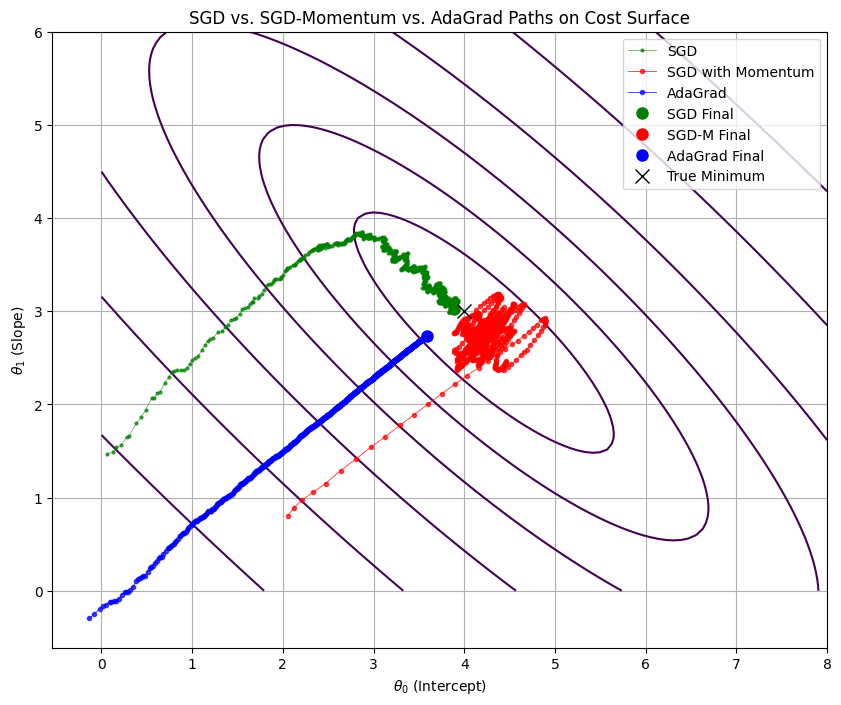

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Generate Synthetic Data for Linear Regression (same as before) ---
np.random.seed(42)
X = 2 * np.random.rand(100, 1) # 100 data points, 1 feature
y = 4 + 3 * X + np.random.randn(100, 1) # y = 4 + 3x + noise
X_b = np.c_[np.ones((100, 1)), X] # Add x0 = 1 to each instance

# --- 2. Define Cost Function (Mean Squared Error) ---
def cost_function(theta, X_b, y):
    m = len(y)
    return (1/(2*m)) * np.sum((X_b.dot(theta) - y)**2)

# --- 3. Implement Stochastic Gradient Descent (for comparison) ---
def stochastic_gradient_descent_base(X_b, y, learning_rate=0.01, n_epochs=50):
    m = len(y)
    theta = np.random.randn(2, 1) # Random initialization
    cost_history = []
    theta_history = []

    for epoch in range(n_epochs):
        shuffled_indices = np.random.permutation(m)
        X_b_shuffled = X_b[shuffled_indices]
        y_shuffled = y[shuffled_indices]

        for i in range(m):
            xi = X_b_shuffled[i:i+1]
            yi = y_shuffled[i:i+1]
            gradients = xi.T.dot(xi.dot(theta) - yi)
            theta = theta - learning_rate * gradients
            cost_history.append(cost_function(theta, X_b, y))
            theta_history.append(theta.flatten())
    return theta, np.array(cost_history), np.array(theta_history)

# --- 4. Implement SGD with Momentum (for comparison) ---
def sgd_with_momentum(X_b, y, learning_rate=0.01, n_epochs=50, momentum_coefficient=0.9):
    m = len(y)
    theta = np.random.randn(2, 1) # Random initialization
    velocity = np.zeros((2, 1)) # Initialize velocity to zeros
    cost_history = []
    theta_history = []

    for epoch in range(n_epochs):
        shuffled_indices = np.random.permutation(m)
        X_b_shuffled = X_b[shuffled_indices]
        y_shuffled = y[shuffled_indices]

        for i in range(m):
            xi = X_b_shuffled[i:i+1]
            yi = y_shuffled[i:i+1]

            # Calculate current gradient (for a single sample)
            gradients = xi.T.dot(xi.dot(theta) - yi)

            # Update velocity
            velocity = momentum_coefficient * velocity + gradients

            # Update parameters
            theta = theta - learning_rate * velocity

            cost_history.append(cost_function(theta, X_b, y))
            theta_history.append(theta.flatten())
    return theta, np.array(cost_history), np.array(theta_history)

# --- 5. Implement AdaGrad ---
def adagrad(X_b, y, learning_rate=0.01, n_epochs=50, epsilon=1e-8):
    m = len(y)
    theta = np.random.randn(2, 1) # Random initialization
    s = np.zeros((2, 1)) # Initialize sum of squared gradients to zeros
    cost_history = []
    theta_history = []

    for epoch in range(n_epochs):
        shuffled_indices = np.random.permutation(m)
        X_b_shuffled = X_b[shuffled_indices]
        y_shuffled = y[shuffled_indices]

        for i in range(m):
            xi = X_b_shuffled[i:i+1]
            yi = y_shuffled[i:i+1]

            # Calculate current gradient (for a single sample)
            gradients = xi.T.dot(xi.dot(theta) - yi)

            # Accumulate squared gradients element-wise
            s += gradients**2

            # Update parameters with adaptive learning rates
            theta = theta - (learning_rate / (np.sqrt(s + epsilon))) * gradients

            cost_history.append(cost_function(theta, X_b, y))
            theta_history.append(theta.flatten())
    return theta, np.array(cost_history), np.array(theta_history)

# --- 6. Run the optimizers ---
sgd_base_theta, sgd_base_costs, sgd_base_thetas = stochastic_gradient_descent_base(X_b, y, learning_rate=0.01, n_epochs=10)
sgdm_theta, sgdm_costs, sgdm_thetas = sgd_with_momentum(X_b, y, learning_rate=0.01, n_epochs=10, momentum_coefficient=0.9)
adagrad_theta, adagrad_costs, adagrad_thetas = adagrad(X_b, y, learning_rate=0.1, n_epochs=10) # AdaGrad often needs a slightly higher initial learning rate

# --- 7. Generate a grid for the cost function surface (same as before) ---
theta0_range = np.linspace(0, 8, 100)
theta1_range = np.linspace(0, 6, 100)
J_vals = np.zeros((len(theta0_range), len(theta1_range)))

for i, t0 in enumerate(theta0_range):
    for j, t1 in enumerate(theta1_range):
        theta_val = np.array([[t0], [t1]])
        J_vals[i, j] = cost_function(theta_val, X_b, y)
J_vals = J_vals.T

# --- 8. Create the contour plot ---
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the contour lines of the cost function
ax.contour(theta0_range, theta1_range, J_vals, levels=np.logspace(-2, 3, 20), cmap='viridis')
ax.set_xlabel(r'$\theta_0$ (Intercept)')
ax.set_ylabel(r'$\theta_1$ (Slope)')
ax.set_title('SGD vs. SGD-Momentum vs. AdaGrad Paths on Cost Surface')

# Plot the paths for each variant
ax.plot(sgd_base_thetas[:, 0], sgd_base_thetas[:, 1], 'o-', label='SGD', color='green', markersize=2, lw=0.5, alpha=0.7)
ax.plot(sgdm_thetas[:, 0], sgdm_thetas[:, 1], 'o-', label='SGD with Momentum', color='red', markersize=3, lw=0.7, alpha=0.7)
ax.plot(adagrad_thetas[:, 0], adagrad_thetas[:, 1], 'o-', label='AdaGrad', color='blue', markersize=3, lw=0.7, alpha=0.7)

# Mark the final points
ax.plot(sgd_base_thetas[-1, 0], sgd_base_thetas[-1, 1], 'o', markersize=8, color='green', label='SGD Final')
ax.plot(sgdm_thetas[-1, 0], sgdm_thetas[-1, 1], 'o', markersize=8, color='red', label='SGD-M Final')
ax.plot(adagrad_thetas[-1, 0], adagrad_thetas[-1, 1], 'o', markersize=8, color='blue', label='AdaGrad Final')

# Mark the true optimal point (from original data generation y = 4 + 3x)
ax.plot(4, 3, 'x', markersize=10, color='black', label='True Minimum')

ax.legend()
ax.grid(True)
plt.show()

### Summary of Visualization

The plot above compares the optimization paths of standard SGD, SGD with Momentum, and AdaGrad on our linear regression cost surface.

*   **SGD (Green Path)**: Continues to show a noisy, zigzagging path, characteristic of updating based on individual sample gradients without any historical context.

*   **SGD with Momentum (Red Path)**: Demonstrates a smoother, more directed path than SGD, as it accumulates velocity from past gradients. It generally converges faster and with less oscillation than plain SGD.

*   **AdaGrad (Blue Path)**: You can observe that AdaGrad's path is also quite direct. What makes it unique is its adaptive nature: it adjusts the learning rate for each parameter individually. This can lead to a more balanced exploration of the parameter space, especially in scenarios where different parameters have gradients of varying magnitudes or frequencies. AdaGrad often shows a good initial descent, but its learning rate tends to decay aggressively, which can cause it to stop learning too early in some cases, as seen by its trajectory stopping somewhat short of the true minimum compared to SGD-M, even with a higher initial learning rate.

This visualization highlights how different optimizers address the challenges of navigating the loss landscape, with AdaGrad providing a distinct adaptive approach to learning rates.

### Pros of AdaGrad:

*   **Adaptive Learning Rates**: AdaGrad's primary advantage is that it adapts the learning rate for each parameter individually. This means parameters with sparse and infrequent gradients (common in NLP and computer vision for rare features) get larger updates, while parameters with frequent gradients get smaller updates.
*   **Suitable for Sparse Data**: It performs particularly well on problems with sparse data, where gradients are rare and potentially high. It ensures that even infrequently updated parameters receive substantial updates, helping them learn effectively.
*   **No Manual Learning Rate Tuning for Each Parameter**: It eliminates the need for manual tuning of the learning rate for each parameter, simplifying the optimization process to some extent by providing an adaptive mechanism.
*   **Improved Robustness**: It tends to be more robust to the choice of the initial global learning rate compared to optimizers that use a fixed learning rate for all parameters.

### Cons of AdaGrad:

*   **Aggressive Learning Rate Decay**: The main drawback of AdaGrad is its aggressive and monotonic decrease in the learning rate. Because it accumulates the sum of squared gradients from the beginning of training, the denominator $\sqrt{\mathbf{s}_t + \epsilon}$ continuously grows. This causes the learning rate to shrink too rapidly and eventually become infinitesimally small, which can lead to premature stopping of learning, especially in deep neural networks or long training processes.
*   **Accumulation of All Past Gradients**: Accumulating *all* past squared gradients can be problematic. If an initial set of gradients is large, the learning rate might become very small very quickly, even if subsequent gradients are smaller and would benefit from a higher learning rate.
*   **Sensitivity to Initial Conditions**: While robust in some aspects, it can still be sensitive to very large initial gradients that can permanently reduce the learning rate to a very low value, hindering further optimization.

### Time Complexity of AdaGrad:

For each update step (typically per mini-batch):

*   **Gradient Calculation**: This involves a forward pass and a backward pass (backpropagation), which has a complexity of $O(M \times P)$, where $M$ is the mini-batch size and $P$ is the number of parameters in the network.
*   **Accumulation of Squared Gradients ($\mathbf{s}_t$)**: This involves squaring each element of the gradient vector and adding it element-wise to the accumulation vector. This operation is $O(P)$.
*   **Parameter Update**: This involves element-wise division by the square root of the accumulated gradients and then a scalar-vector multiplication (by the global learning rate) followed by a vector subtraction. This operation is also $O(P)$.

**Overall Time Complexity per Update**: Similar to SGD and SGD with Momentum, the dominant part is the gradient calculation. Therefore, for each update, the complexity remains approximately $O(M \times P)$.

**Total Training Time Complexity**: It's roughly $O(\text{Epochs} \times \text{Number of mini-batches} \times M \times P)$, which simplifies to $O(\text{Epochs} \times \text{Total Samples} \times P)$.

In summary, AdaGrad introduces a minimal computational overhead per update ($O(P)$ operations) for its adaptive learning rate mechanism compared to the gradient calculation ($O(M \times P)$ operations). Its main advantage lies in its adaptive learning rates rather than a direct reduction in per-update computational time.

### 3. RMSProp

#### Definition

**RMSProp** (Root Mean Square Propagation) is an adaptive learning rate optimization algorithm developed by Geoff Hinton. It addresses the aggressively decaying learning rates of AdaGrad by introducing an exponential moving average of squared gradients instead of accumulating all past squared gradients. This allows RMSProp to maintain a larger learning rate for parameters that have a history of smaller gradients and a smaller learning rate for parameters with a history of larger gradients, while also preventing the learning rate from vanishing too quickly.

#### Why it's needed

RMSProp was developed to address a critical flaw in AdaGrad: its aggressive, monotonic decay of the learning rate. Here's why this problem required a new solution:

1.  **AdaGrad's Vanishing Learning Rate**: AdaGrad accumulates the sum of squared gradients from the very beginning of training. As training progresses, this sum continuously grows. Since the learning rate for each parameter is inversely proportional to the square root of this accumulated sum, the learning rate shrinks smaller and smaller, eventually becoming infinitesimally small. This causes the model to stop learning effectively, often prematurely, especially in deep networks or during long training periods.

2.  **Need for Sustained Learning**: Deep learning models often require a long training process to converge to good solutions. An optimizer that effectively stops learning midway through is highly problematic. RMSProp ensures that the learning rate does not diminish too rapidly, allowing the model to continue making meaningful updates throughout training.

3.  **Adaptive Learning with Focus on Recent History**: While adapting learning rates per parameter is crucial, sometimes older gradients are less relevant to the current learning direction than more recent ones. RMSProp's use of a moving average allows it to discount old, distant gradients and prioritize the recent gradient history. This helps in non-stationary environments where the optimal direction might change over time.

By overcoming AdaGrad's limitations, RMSProp offers a more robust and effective adaptive learning rate mechanism, enabling models to train for longer and converge to better minima without the learning rate vanishing prematurely.

#### Intuition

Let's continue with our analogy of navigating a mountainous terrain (our loss function) to find the lowest point. AdaGrad was like having a personalized step counter for each foot, where the counter accumulated *all* your past steps in that direction. This worked well initially, but eventually, if you'd walked a lot in one direction, the counter became so huge that your steps in that direction became microscopic, making you effectively freeze.

**RMSProp is like having that same personalized step counter for each foot, but with a short-term memory.** Instead of accumulating *all* past steps, it only remembers the average of the *recent* squared steps in each direction. It discounts older steps, giving more weight to how much you've been moving recently.

Here's how this helps:

*   **Prevents Freezing**: If you were walking a lot (large gradients) in one direction earlier in your journey, but now that direction is less steep or requires more careful steps, RMSProp won't keep punishing you for your distant past. It will adapt based on your recent activity. This means your steps don't shrink to zero; you can continue taking reasonable steps as long as there's recent activity.
*   **Adapts to Changing Terrain**: Imagine the terrain changes over time (non-stationary objectives). RMSProp, with its short-term memory, can adapt more quickly. If a path that was once steep becomes flat, it quickly forgets the past steepness and increases your step size, allowing you to move faster. If a flat path suddenly becomes steep, it quickly reduces your step size to prevent overshooting.

So, RMSProp ensures that your adaptive step size for each parameter doesn't get 'stuck' at a tiny value due to an accumulation of very old, large gradients. It keeps the learning adaptive and responsive to the current and recent gradients, allowing the optimization process to continue effectively throughout long training sessions.

#### Math

RMSProp maintains an exponentially weighted moving average of the squared gradients for each parameter. This moving average replaces AdaGrad's monotonically increasing sum of squared gradients, preventing the learning rate from diminishing too aggressively. While AdaGrad's denominator term continually grows, RMSProp's denominator will only grow as long as the recent squared gradients are large, allowing it to adapt to changing gradient magnitudes.

Let:
*   $\mathbf{\theta}$ be the parameter vector (weights and biases).
*   $J(\mathbf{\theta})$ be the loss function.
*   $\nabla J(\mathbf{\theta}_t)$ be the gradient of the loss function with respect to the parameters at time step $t$.
*   $\alpha$ be the global learning rate.
*   $\mathbf{g}_t$ be the gradient vector at time step $t$, i.e., $\mathbf{g}_t = \nabla J(\mathbf{\theta}_t)$.
*   $\rho$ (rho) be the **decay rate** (or `decay_rate`, `beta` in some literature), a hyperparameter typically set around 0.9 or 0.99. It controls the weighting between past and current squared gradients.
*   $\mathbf{s}_t$ be a vector initialized to zeros, which stores the exponentially weighted moving average of squared gradients for each parameter.
*   $\epsilon$ is a small smoothing term (e.g., $10^{-8}$) to prevent division by zero.

#### Formula

At each time step $t$ (after processing a mini-batch), RMSProp performs the following updates:

1. **Update the exponentially weighted moving average of squared gradients**: The new moving average is a combination of the previous average and the current squared gradients, weighted by the decay rate $\rho$.

   $$
   \mathbf{s}_t
   =
   \rho\,\mathbf{s}_{t-1}
   +
   (1-\rho)\,
   \mathbf{g}_t
   \odot
   \mathbf{g}_t
   $$

   Where:

   * $\mathbf{s}_t$: The vector storing the exponentially weighted moving average of squared gradients for each parameter.

   * $\mathbf{g}_t$: The gradient vector of the loss function with respect to the parameters at time step $t$.

   * $\odot$: Denotes the element-wise (Hadamard) product.

   * $\mathbf{s}_0$ is initialized to a vector of zeros:

     $$
     \mathbf{s}_0=\mathbf{0}
     $$
2.  **Parameter Update**: The parameters are updated using the global learning rate, scaled inversely by the square root of the current exponentially weighted moving average of squared gradients for each parameter. A small epsilon term is added for numerical stability.

    $$ \mathbf{\theta}_{t+1} = \mathbf{\theta}_t - \frac{\alpha}{\sqrt{\mathbf{s}_t + \epsilon}} \odot \mathbf{g}_t $$

    Where:
    *   $\mathbf{\theta}_t$: The parameter vector at time step $t$.
    *   $\alpha$: The global learning rate.
    *   $\sqrt{\mathbf{s}_t + \epsilon}$: The element-wise square root of the exponentially weighted moving average of squared gradients, plus a small smoothing term $\epsilon$ to prevent division by zero. This term effectively adapts the learning rate for each parameter.
    *   $\odot$: Denotes the element-wise (Hadamard) product.

This formula allows RMSProp to dynamically adjust the learning rate for each parameter based on recent gradient magnitudes, preventing the aggressive learning rate decay observed in AdaGrad and leading to more effective and sustained training.

#### Numerical Example

Let's apply the RMSProp update rule to a simple 2-dimensional parameter vector $\mathbf{\theta} = \begin{pmatrix} \theta_0 \\ \theta_1 \end{pmatrix}$ and a loss function $J(\mathbf{\theta})$ that generates the following gradients over two time steps. We'll trace how RMSProp updates these parameters.

**Given Initial Values:**
*   Initial parameters: $\mathbf{\theta}_0 = \begin{pmatrix} 0.0 \\ 0.0 \end{pmatrix}$
*   Initial exponentially weighted moving average of squared gradients: $\mathbf{s}_0 = \begin{pmatrix} 0.0 \\ 0.0 \end{pmatrix}$
*   Global learning rate: $\alpha = 0.01$
*   Decay rate: $\rho = 0.9$
*   Smoothing term: $\epsilon = 10^{-8}$

**Scenario: Two Iterations with Different Gradients**

Assume the gradients at each time step are:
*   Time step $t=1$: $\mathbf{g}_1 = \begin{pmatrix} 0.5 \\ 0.1 \end{pmatrix}$
*   Time step $t=2$: $\mathbf{g}_2 = \begin{pmatrix} 0.2 \\ 0.8 \end{pmatrix}$

---

**Iteration 1 (Time Step $t=1$):**

1.  **Current Parameters**: $\mathbf{\theta}_0 = \begin{pmatrix} 0.0 \\ 0.0 \end{pmatrix}$
2.  **Current Gradients**: $\mathbf{g}_1 = \begin{pmatrix} 0.5 \\ 0.1 \end{pmatrix}$
3. **Update Exponentially Weighted Moving Average of Squared Gradients ($\mathbf{s}_1$)**:

   $$
   \mathbf{s}_1
   =
   \rho\,\mathbf{s}_{0}
   +
   (1-\rho)\,\mathbf{g}_1\odot\mathbf{g}_1
   $$

   $$
   \mathbf{s}_1
   =
   0.9 \cdot
   \begin{pmatrix}
   0.0\\0.0
   \end{pmatrix}
   +
   (1-0.9) \cdot
   \begin{pmatrix}
   0.5^2\\0.1^2
   \end{pmatrix}
   $$

   $$
   \mathbf{s}_1
   =
   \begin{pmatrix}
   0.0\\0.0
   \end{pmatrix}
   +
   0.1 \cdot
   \begin{pmatrix}
   0.25\\0.01
   \end{pmatrix}
   =
   \begin{pmatrix}
   0.025\\0.001
   \end{pmatrix}
   $$

4. **Parameter Update**:

   $$
   \mathbf{\theta}_1
   =
   \mathbf{\theta}_0
   -
   \frac{\alpha}{\sqrt{\mathbf{s}_1 + \epsilon}}
   \odot
   \mathbf{g}_1
   $$

   **Calculate adaptive learning rates (element-wise):**

   $$
   \frac{0.01}{\sqrt{0.025+\epsilon}}
   \approx
   \frac{0.01}{0.1581}
   \approx
   0.06325
   $$

   $$
   \frac{0.01}{\sqrt{0.001+\epsilon}}
   \approx
   \frac{0.01}{0.0316}
   \approx
   0.3164
   $$

   $$
   \mathbf{\theta}_1
   =
   \begin{pmatrix}
   0.0\\0.0
   \end{pmatrix}
   -
   \begin{pmatrix}
   0.06325\\0.3164
   \end{pmatrix}
   \odot
   \begin{pmatrix}
   0.5\\0.1
   \end{pmatrix}
   $$

   $$
   \mathbf{\theta}_1
   =
   \begin{pmatrix}
   0.0\\0.0
   \end{pmatrix}
   -
   \begin{pmatrix}
   0.06325 \times 0.5\\0.3164 \times 0.1
   \end{pmatrix}
   =
   \begin{pmatrix}
   0.0\\0.0
   \end{pmatrix}
   -
   \begin{pmatrix}
   0.031625\\0.03164
   \end{pmatrix}
   =
   \begin{pmatrix}
   -0.031625\\-0.03164
   \end{pmatrix}
   $$

---

**Iteration 2 (Time Step $t=2$):**

1.  **Current Parameters**: $\mathbf{\theta}_1 = \begin{pmatrix} -0.031625 \\ -0.03164 \end{pmatrix}$
2.  **Current Gradients**: $\mathbf{g}_2 = \begin{pmatrix} 0.2 \\ 0.8 \end{pmatrix}$
3. **Update Exponentially Weighted Moving Average of Squared Gradients ($\mathbf{s}_2$)**:

   $$
   \mathbf{s}_2
   =
   \rho\,\mathbf{s}_{1}
   +
   (1-\rho)\,\mathbf{g}_2\odot\mathbf{g}_2
   $$

   $$
   \mathbf{s}_2
   =
   0.9 \cdot
   \begin{pmatrix}
   0.025\\0.001
   \end{pmatrix}
   +
   0.1 \cdot
   \begin{pmatrix}
   0.2^2\\0.8^2
   \end{pmatrix}
   $$

   $$
   \mathbf{s}_2
   =
   \begin{pmatrix}
   0.0225\\0.0009
   \end{pmatrix}
   +
   0.1 \cdot
   \begin{pmatrix}
   0.04\\0.64
   \end{pmatrix}
   =
   \begin{pmatrix}
   0.0225\\0.0009
   \end{pmatrix}
   +
   \begin{pmatrix}
   0.004\\0.064
   \end{pmatrix}
   =
   \begin{pmatrix}
   0.0265\\0.0649
   \end{pmatrix}
   $$

4. **Parameter Update**:

   $$
   \mathbf{\theta}_2
   =
   \mathbf{\theta}_1
   -
   \frac{\alpha}{\sqrt{\mathbf{s}_2 + \epsilon}}
   \odot
   \mathbf{g}_2
   $$

   **Calculate adaptive learning rates (element-wise):**

   $$
   \frac{0.01}{\sqrt{0.0265+\epsilon}}
   \approx
   \frac{0.01}{0.1628}
   \approx
   0.06142
   $$

   $$
   \frac{0.01}{\sqrt{0.0649+\epsilon}}
   \approx
   \frac{0.01}{0.2548}
   \approx
   0.03924
   $$

   $$
   \mathbf{\theta}_2
   =
   \begin{pmatrix}
   -0.031625\\-0.03164
   \end{pmatrix}
   -
   \begin{pmatrix}
   0.06142\\0.03924
   \end{pmatrix}
   \odot
   \begin{pmatrix}
   0.2\\0.8
   \end{pmatrix}
   $$

   $$
   \mathbf{\theta}_2
   =
   \begin{pmatrix}
   -0.031625\\-0.03164
   \end{pmatrix}
   -
   \begin{pmatrix}
   0.06142 \times 0.2\\0.03924 \times 0.8
   \end{pmatrix}
   =
   \begin{pmatrix}
   -0.031625\\-0.03164
   \end{pmatrix}
   -
   \begin{pmatrix}
   0.012284\\0.031392
   \end{pmatrix}
   =
   \begin{pmatrix}
   -0.043909\\-0.063032
   \end{pmatrix}
   $$

---

**Summary of Iterations:**

| Iteration | $\mathbf{\theta}_{\text{old}}$ | $\mathbf{g}_t$ | $\mathbf{s}_{\text{old}}$ | $\mathbf{s}_t$ | Adaptive Learning Rate | $\Delta\mathbf{\theta}$ | $\mathbf{\theta}_t$ |
| :-------- | :--------------------- | :------------------ | :----------------- | :----------------- | :----------------------------- | :------------------ | :--------------------- |
| 1         | `[0.0, 0.0]`           | `[0.5, 0.1]`        | `[0.0, 0.0]`       | `[0.025, 0.001]`   | `[0.06325, 0.3164]`          | `[-0.031625, -0.03164]` | `[-0.031625, -0.03164]` |
| 2         | `[-0.031625, -0.03164]` | `[0.2, 0.8]`        | `[0.025, 0.001]`   | `[0.0265, 0.0649]` | `[0.06142, 0.03924]`         | `[-0.012284, -0.031392]` | `[-0.043909, -0.063032]` |

This example demonstrates how RMSProp's adaptive learning rates adjust based on the *exponential moving average* of squared gradients, which means that past gradients are forgotten over time, preventing the aggressive learning rate decay seen in AdaGrad.

#### Visualization

Let's visualize the convergence path of RMSProp compared to standard SGD, SGD with Momentum, and AdaGrad on our simple linear regression problem. This will highlight how RMSProp adapts learning rates, preventing the aggressive decay of AdaGrad.

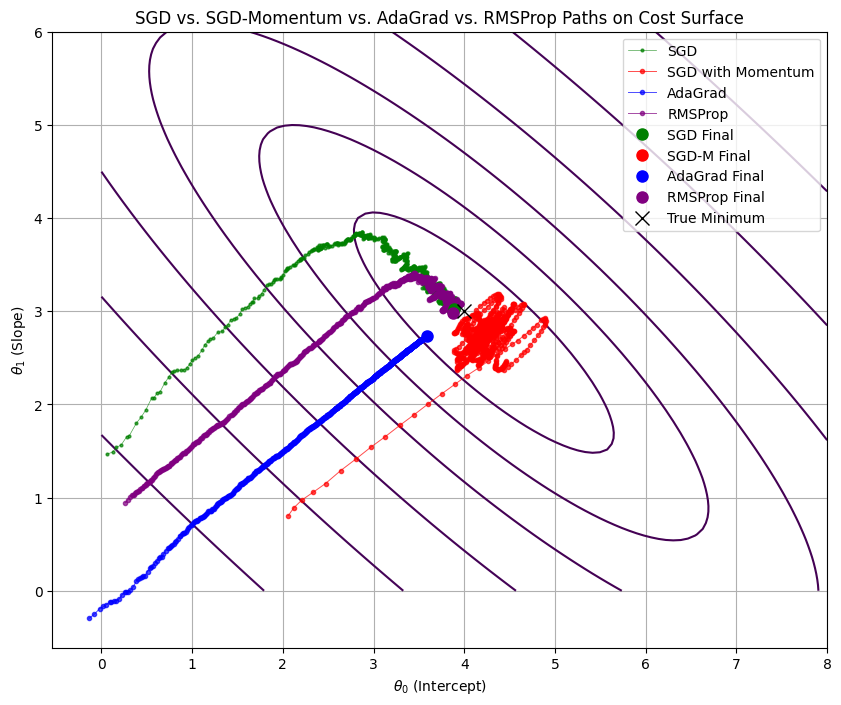

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Generate Synthetic Data for Linear Regression (same as before) ---
np.random.seed(42)
X = 2 * np.random.rand(100, 1) # 100 data points, 1 feature
y = 4 + 3 * X + np.random.randn(100, 1) # y = 4 + 3x + noise
X_b = np.c_[np.ones((100, 1)), X] # Add x0 = 1 to each instance

# --- 2. Define Cost Function (Mean Squared Error) ---
def cost_function(theta, X_b, y):
    m = len(y)
    return (1/(2*m)) * np.sum((X_b.dot(theta) - y)**2)

# --- 3. Implement Stochastic Gradient Descent (for comparison) ---
def stochastic_gradient_descent_base(X_b, y, learning_rate=0.01, n_epochs=50):
    m = len(y)
    theta = np.random.randn(2, 1) # Random initialization
    cost_history = []
    theta_history = []

    for epoch in range(n_epochs):
        shuffled_indices = np.random.permutation(m)
        X_b_shuffled = X_b[shuffled_indices]
        y_shuffled = y[shuffled_indices]

        for i in range(m):
            xi = X_b_shuffled[i:i+1]
            yi = y_shuffled[i:i+1]
            gradients = xi.T.dot(xi.dot(theta) - yi)
            theta = theta - learning_rate * gradients
            cost_history.append(cost_function(theta, X_b, y))
            theta_history.append(theta.flatten())
    return theta, np.array(cost_history), np.array(theta_history)

# --- 4. Implement SGD with Momentum (for comparison) ---
def sgd_with_momentum(X_b, y, learning_rate=0.01, n_epochs=50, momentum_coefficient=0.9):
    m = len(y)
    theta = np.random.randn(2, 1) # Random initialization
    velocity = np.zeros((2, 1)) # Initialize velocity to zeros
    cost_history = []
    theta_history = []

    for epoch in range(n_epochs):
        shuffled_indices = np.random.permutation(m)
        X_b_shuffled = X_b[shuffled_indices]
        y_shuffled = y[shuffled_indices]

        for i in range(m):
            xi = X_b_shuffled[i:i+1]
            yi = y_shuffled[i:i+1]

            # Calculate current gradient (for a single sample)
            gradients = xi.T.dot(xi.dot(theta) - yi)

            # Update velocity
            velocity = momentum_coefficient * velocity + gradients

            # Update parameters
            theta = theta - learning_rate * velocity

            cost_history.append(cost_function(theta, X_b, y))
            theta_history.append(theta.flatten())
    return theta, np.array(cost_history), np.array(theta_history)

# --- 5. Implement AdaGrad (for comparison) ---
def adagrad(X_b, y, learning_rate=0.01, n_epochs=50, epsilon=1e-8):
    m = len(y)
    theta = np.random.randn(2, 1) # Random initialization
    s = np.zeros((2, 1)) # Initialize sum of squared gradients to zeros
    cost_history = []
    theta_history = []

    for epoch in range(n_epochs):
        shuffled_indices = np.random.permutation(m)
        X_b_shuffled = X_b[shuffled_indices]
        y_shuffled = y[shuffled_indices]

        for i in range(m):
            xi = X_b_shuffled[i:i+1]
            yi = y_shuffled[i:i+1]

            # Calculate current gradient (for a single sample)
            gradients = xi.T.dot(xi.dot(theta) - yi)

            # Accumulate squared gradients element-wise
            s += gradients**2

            # Update parameters with adaptive learning rates
            theta = theta - (learning_rate / (np.sqrt(s + epsilon))) * gradients

            cost_history.append(cost_function(theta, X_b, y))
            theta_history.append(theta.flatten())
    return theta, np.array(cost_history), np.array(theta_history)

# --- 6. Implement RMSProp ---
def rmsprop(X_b, y, learning_rate=0.01, n_epochs=50, decay_rate=0.9, epsilon=1e-8):
    m = len(y)
    theta = np.random.randn(2, 1) # Random initialization
    s = np.zeros((2, 1)) # Initialize exponentially weighted moving average of squared gradients
    cost_history = []
    theta_history = []

    for epoch in range(n_epochs):
        shuffled_indices = np.random.permutation(m)
        X_b_shuffled = X_b[shuffled_indices]
        y_shuffled = y[shuffled_indices]

        for i in range(m):
            xi = X_b_shuffled[i:i+1]
            yi = y_shuffled[i:i+1]

            # Calculate current gradient (for a single sample)
            gradients = xi.T.dot(xi.dot(theta) - yi)

            # Update exponentially weighted moving average of squared gradients
            s = decay_rate * s + (1 - decay_rate) * (gradients**2)

            # Update parameters with adaptive learning rates
            theta = theta - (learning_rate / (np.sqrt(s + epsilon))) * gradients

            cost_history.append(cost_function(theta, X_b, y))
            theta_history.append(theta.flatten())
    return theta, np.array(cost_history), np.array(theta_history)

# --- 7. Run the optimizers ---
sgd_base_theta, sgd_base_costs, sgd_base_thetas = stochastic_gradient_descent_base(X_b, y, learning_rate=0.01, n_epochs=10)
sgdm_theta, sgdm_costs, sgdm_thetas = sgd_with_momentum(X_b, y, learning_rate=0.01, n_epochs=10, momentum_coefficient=0.9)
adagrad_theta, adagrad_costs, adagrad_thetas = adagrad(X_b, y, learning_rate=0.1, n_epochs=10)
rmsprop_theta, rmsprop_costs, rmsprop_thetas = rmsprop(X_b, y, learning_rate=0.01, n_epochs=10, decay_rate=0.9)

# --- 8. Generate a grid for the cost function surface (same as before) ---
theta0_range = np.linspace(0, 8, 100)
theta1_range = np.linspace(0, 6, 100)
J_vals = np.zeros((len(theta0_range), len(theta1_range)))

for i, t0 in enumerate(theta0_range):
    for j, t1 in enumerate(theta1_range):
        theta_val = np.array([[t0], [t1]])
        J_vals[i, j] = cost_function(theta_val, X_b, y)
J_vals = J_vals.T

# --- 9. Create the contour plot ---
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the contour lines of the cost function
ax.contour(theta0_range, theta1_range, J_vals, levels=np.logspace(-2, 3, 20), cmap='viridis')
ax.set_xlabel(r'$\theta_0$ (Intercept)')
ax.set_ylabel(r'$\theta_1$ (Slope)')
ax.set_title('SGD vs. SGD-Momentum vs. AdaGrad vs. RMSProp Paths on Cost Surface')

# Plot the paths for each variant
ax.plot(sgd_base_thetas[:, 0], sgd_base_thetas[:, 1], 'o-', label='SGD', color='green', markersize=2, lw=0.5, alpha=0.7)
ax.plot(sgdm_thetas[:, 0], sgdm_thetas[:, 1], 'o-', label='SGD with Momentum', color='red', markersize=3, lw=0.7, alpha=0.7)
ax.plot(adagrad_thetas[:, 0], adagrad_thetas[:, 1], 'o-', label='AdaGrad', color='blue', markersize=3, lw=0.7, alpha=0.7)
ax.plot(rmsprop_thetas[:, 0], rmsprop_thetas[:, 1], 'o-', label='RMSProp', color='purple', markersize=3, lw=0.7, alpha=0.7)

# Mark the final points
ax.plot(sgd_base_thetas[-1, 0], sgd_base_thetas[-1, 1], 'o', markersize=8, color='green', label='SGD Final')
ax.plot(sgdm_thetas[-1, 0], sgdm_thetas[-1, 1], 'o', markersize=8, color='red', label='SGD-M Final')
ax.plot(adagrad_thetas[-1, 0], adagrad_thetas[-1, 1], 'o', markersize=8, color='blue', label='AdaGrad Final')
ax.plot(rmsprop_thetas[-1, 0], rmsprop_thetas[-1, 1], 'o', markersize=8, color='purple', label='RMSProp Final')

# Mark the true optimal point (from original data generation y = 4 + 3x)
ax.plot(4, 3, 'x', markersize=10, color='black', label='True Minimum')

ax.legend()
ax.grid(True)
plt.show()

### Summary of Visualization

The plot above compares the optimization paths of standard SGD, SGD with Momentum, AdaGrad, and RMSProp on our linear regression cost surface.

*   **SGD (Green Path)**: Shows a noisy, zigzagging path, characteristic of updating based on individual sample gradients without historical context.

*   **SGD with Momentum (Red Path)**: Demonstrates a smoother, more directed path than SGD, as it accumulates velocity from past gradients. It generally converges faster and with less oscillation than plain SGD.

*   **AdaGrad (Blue Path)**: Shows a path with adaptive learning rates. While it makes good initial progress, its aggressive learning rate decay often causes it to slow down or stop prematurely, visible by its convergence point still being some distance from the true minimum.

*   **RMSProp (Purple Path)**: Exhibits a robust and efficient convergence path. Unlike AdaGrad, its use of an exponentially weighted moving average for squared gradients prevents the learning rate from vanishing too quickly. This allows RMSProp to continue making significant progress towards the minimum, often converging more effectively than AdaGrad and sometimes even outperforming momentum-based methods in certain scenarios. It demonstrates a balance between adapting to the gradient magnitudes and maintaining a sustained learning rate.

This visualization clearly highlights how RMSProp addresses the limitations of AdaGrad by allowing for sustained and effective learning throughout the optimization process.

### Pros of RMSProp:

*   **Addresses AdaGrad's Aggressive Learning Rate Decay**: The most significant advantage of RMSProp is that it prevents the learning rate from diminishing too rapidly, which was a major problem with AdaGrad. By using an exponentially weighted moving average of squared gradients, it discards gradients from the distant past, allowing the learning rate to remain effective over longer training periods.
*   **Adaptive Learning Rates**: It still provides adaptive learning rates for each parameter, scaling down the learning rate for parameters with consistently large gradients and maintaining higher learning rates for parameters with smaller or more infrequent gradients.
*   **Effective in Non-Stationary Settings**: Because it gives more weight to recent gradients, RMSProp is well-suited for non-stationary objectives, where the optimal direction might change over time, as it can adapt more quickly to recent gradient patterns.
*   **Good Performance in Practice**: RMSProp often performs very well on a variety of deep learning tasks and is a popular choice due to its robustness and efficiency.

### Cons of RMSProp:

*   **Additional Hyperparameters**: It introduces a new hyperparameter, the `decay_rate` (or $\rho$), which needs to be tuned. While common values like 0.9 often work well, finding the optimal value can still require experimentation.
*   **No Momentum Correction**: Unlike optimizers such as Adam, RMSProp does not incorporate a momentum term that directly corrects for oscillations or smooths out updates based on the direction of previous steps. It primarily focuses on adapting the learning rate.
*   **Can Still Get Stuck**: While better than AdaGrad, RMSProp can still get stuck in local minima or struggle to escape saddle points in very complex loss landscapes, especially if the local gradient information is misleading.

### Time Complexity of RMSProp:

For each update step (typically per mini-batch):

*   **Gradient Calculation**: This involves a forward pass and a backward pass (backpropagation), which has a complexity of $O(M \times P)$, where $M$ is the mini-batch size and $P$ is the number of parameters in the network.
*   **Update of Exponentially Weighted Moving Average of Squared Gradients ($\mathbf{s}_t$)**: This involves element-wise squaring of gradients, two element-wise multiplications (by $\rho$ and $1-\rho$), and an element-wise addition. This operation is $O(P)$.
*   **Parameter Update**: This involves element-wise division by the square root of the accumulated gradients and then a scalar-vector multiplication (by the global learning rate) followed by a vector subtraction. This operation is also $O(P)$.

**Overall Time Complexity per Update**: Similar to other adaptive optimizers like AdaGrad, the dominant part is the gradient calculation. Therefore, for each update, the complexity remains approximately $O(M \times P)$.

**Total Training Time Complexity**: It's roughly $O(\text{Epochs} \times \text{Number of mini-batches} \times M \times P)$, which simplifies to $O(\text{Epochs} \times \text{Total Samples} \times P)$.

In essence, RMSProp introduces a minimal computational overhead per update ($O(P)$ operations) compared to the gradient calculation ($O(M \times P)$ operations). Its primary benefit is not a reduction in per-update computation time, but rather a significant improvement in **convergence stability and speed** over AdaGrad, enabling more effective and sustained training.

### 4. Adam

#### Definition

#### Definition

**Adam** (Adaptive Moment Estimation) is an optimization algorithm that combines the best properties of **AdaGrad** (which works well with sparse gradients) and **RMSProp** (which deals with non-stationary objectives). It computes adaptive learning rates for each parameter by storing an exponentially decaying average of past squared gradients (like RMSProp) and also an exponentially decaying average of past gradients (like Momentum). Adam is widely recognized for its efficiency and good performance in practice, often requiring less tuning of the learning rate hyperparameter.

#### Why it's needed

Adam was developed to combine the strengths of previous adaptive learning rate methods (like AdaGrad and RMSProp) and momentum-based methods (like SGD with Momentum) while mitigating their individual weaknesses. It addresses several persistent challenges in neural network training:

1.  **Balancing Adaptive Learning Rates and Momentum**: Previous optimizers either focused on adapting learning rates (AdaGrad, RMSProp) or incorporating momentum (SGD with Momentum). Adam integrates both, allowing it to adapt individual learning rates for each parameter *and* accelerate convergence in the correct direction, leading to faster and more stable training.

2.  **Addressing AdaGrad's Rapid Learning Rate Decay**: Like RMSProp, Adam avoids the aggressive learning rate decay of AdaGrad, ensuring that learning can continue effectively throughout long training processes.

3.  **Handling Sparse Gradients**: By incorporating an exponentially decaying average of past squared gradients (similar to RMSProp), Adam is well-suited for problems with sparse gradients (e.g., natural language processing), where different parameters might have vastly different update frequencies.

4.  **Faster Convergence and Robustness**: Adam's combination of adaptive learning rates and momentum often leads to significantly faster convergence and more robust performance across a wide range of tasks and network architectures, often requiring less manual tuning of the initial learning rate compared to SGD or SGD with Momentum.

5.  **Bias Correction for Initialization**: Adam includes bias-correction terms to account for the fact that the moving averages are initialized to zero, which can be particularly important during the initial steps of training. This ensures that the estimates of the first and second moments are unbiased.

In essence, Adam provides a state-of-the-art solution that effectively and efficiently navigates the complex loss landscapes of deep neural networks, making it a default choice for many practitioners.

#### Intuition

Let's go back to our analogy of navigating a mountainous terrain (our loss function) to find the lowest point.

*   **SGD**: Like blindly taking steps in the direction of the steepest immediate downhill slope. Can be slow, zigzagging, and get stuck in local bumps.
*   **Momentum**: Like rolling a heavy ball down the hill. It remembers past directions, builds speed, and can push through small bumps or plateaus.
*   **AdaGrad**: Like having a personalized step counter for each foot, which tells you to take smaller steps where you've walked a lot and larger steps where you haven't. But it eventually makes you freeze.
*   **RMSProp**: Like AdaGrad, but your step counter only remembers recent steps, preventing the freezing problem.

**Adam is like combining the best navigational tools:**

1.  **Remembering Past Directions (Momentum's Influence)**: You're still rolling that heavy ball, so you have a sense of *which way you've consistently been moving*. This helps you maintain direction and overcome minor obstacles.

2.  **Adapting Step Sizes for Each Foot (RMSProp's Influence)**: Simultaneously, you're also adapting your step size for *each foot independently* based on how much you've recently moved in that specific direction. So, if a particular path (parameter) has recently been very steep, you'll take smaller, more careful steps in that specific direction. If another path has been very flat, you'll take larger steps to cover ground more quickly.

3.  **A Smart Combination**: Adam intelligently combines these two ideas. It doesn't just react to the current gradient (slope); it considers:
    *   The **average direction of past slopes** (first moment, like momentum).
    *   The **average magnitude of past slopes** (second moment, like RMSProp's adaptive learning rate).

It's like having a very experienced hiker who knows not only the general direction to go but also understands that some parts of the path are more treacherous than others and adjusts stride length accordingly. This allows Adam to make quick progress in easy directions, be cautious in difficult ones, and gracefully navigate complex terrain, often leading to faster and more stable convergence.

#### Math

Adam computes adaptive learning rates for each parameter by storing an exponentially decaying average of past gradients (**first moment estimate**, $m_t$) and an exponentially decaying average of past squared gradients (**second moment estimate**, $v_t$). It also includes bias-correction terms to account for the fact that these moving averages are initialized to zero, especially during the initial time steps.

Let:
*   $\mathbf{\theta}$ be the parameter vector (weights and biases).
*   $J(\mathbf{\theta})$ be the loss function.
*   $\mathbf{g}_t = \nabla J(\mathbf{\theta}_t)$ be the gradient vector of the loss function with respect to the parameters at time step $t$.
*   $\alpha$ be the global learning rate (often called `eta` or `lr`).
*   $\beta_1$ and $\beta_2$ be the exponential decay rates for the first and second moment estimates, respectively (typically $\beta_1 = 0.9$ and $\beta_2 = 0.999$).
*   $\epsilon$ be a small smoothing term (e.g., $10^{-8}$) to prevent division by zero.
*   $m_t$ be the first moment vector (mean of gradients), initialized to zeros.
*   $v_t$ be the second moment vector (uncentered variance of gradients), initialized to zeros.

#### Formula

Adam's update rules involve several steps at each time step $t$ (after processing a mini-batch):

1. **Calculate Gradients**: Compute the gradients $\mathbf{g}_t$ of the loss function with respect to the parameters at the current time step.

   $$
   \mathbf{g}_t
   =
   \nabla J(\mathbf{\theta}_t)
   $$

2. **Update Biased First Moment Estimate ($m_t$)**: This is an exponentially weighted moving average of past gradients.

   $$
   m_t
   =
   \beta_1 m_{t-1}
   +
   (1-\beta_1)\,
   \mathbf{g}_t
   $$

3. **Update Biased Second Moment Estimate ($v_t$)**: This is an exponentially weighted moving average of past squared gradients.

   $$
   v_t
   =
   \beta_2 v_{t-1}
   +
   (1-\beta_2)\,
   \mathbf{g}_t
   \odot
   \mathbf{g}_t
   $$

   Where $\odot$ denotes the element-wise (Hadamard) product.

4. **Correct Bias for First Moment**: Since $m_t$ is initialized to zeros, it is biased toward zero during the initial time steps. This correction compensates for that bias.

   $$
   \hat{m}_t
   =
   \frac{m_t}
   {1-\beta_1^t}
   $$

   Where $t$ is the current time step (starting from 1).

5. **Correct Bias for Second Moment**: Similarly, $v_t$ is also biased toward zero.

   $$
   \hat{v}_t
   =
   \frac{v_t}
   {1-\beta_2^t}
   $$

6. **Parameter Update**: The parameters are updated using the bias-corrected first and second moment estimates, scaled by the global learning rate.

   $$
   \mathbf{\theta}_{t+1}
   =
   \mathbf{\theta}_t
   -
   \alpha
   \frac{\hat{m}_t}
   {\sqrt{\hat{v}_t}+\epsilon}
   $$
This comprehensive formula allows Adam to combine the benefits of momentum (accelerating learning in consistent directions) and adaptive learning rates (adjusting step sizes for each parameter based on its historical gradient magnitudes), while also providing robust bias correction.

#### Numerical Example

Let's apply the Adam update rule to a simple 1-dimensional parameter $\theta$ for two time steps. We'll simplify by considering a hypothetical gradient at each step.

**Given Initial Values:**
*   Initial parameter: $\theta_0 = 0.0$
*   Initial first moment estimate: $m_0 = 0.0$
*   Initial second moment estimate: $v_0 = 0.0$
*   Global learning rate: $\alpha = 0.01$
*   Decay rates: $\beta_1 = 0.9$, $\beta_2 = 0.999$
*   Smoothing term: $\epsilon = 10^{-8}$

**Scenario: Two Iterations with Different Gradients**

Assume the gradients at each time step are:
*   Time step $t=1$: $g_1 = 0.5$
*   Time step $t=2$: $g_2 = 0.2$

---

**Iteration 1 (Time Step $t=1$):**

1.  **Current Parameter**: $\theta_0 = 0.0$
2.  **Current Gradient**: $g_1 = 0.5$

3.  **Update Biased First Moment Estimate ($m_1$)**:
    $m_1 = \beta_1 m_0 + (1 - \beta_1) g_1 = 0.9 \cdot 0.0 + (1 - 0.9) \cdot 0.5 = 0.1 \cdot 0.5 = 0.05$

4.  **Update Biased Second Moment Estimate ($v_1$)**:
    $v_1 = \beta_2 v_0 + (1 - \beta_2) g_1^2 = 0.999 \cdot 0.0 + (1 - 0.999) \cdot (0.5)^2 = 0.001 \cdot 0.25 = 0.00025$

5.  **Correct Bias for First Moment ($\hat{m}_1$)**:
    $\hat{m}_1 = \frac{m_1}{1 - \beta_1^1} = \frac{0.05}{1 - 0.9^1} = \frac{0.05}{0.1} = 0.5$

6.  **Correct Bias for Second Moment ($\hat{v}_1$)**:
    $\hat{v}_1 = \frac{v_1}{1 - \beta_2^1} = \frac{0.00025}{1 - 0.999^1} = \frac{0.00025}{0.001} = 0.25$

7.  **Parameter Update ($\theta_1$)**:
    $\theta_1 = \theta_0 - \alpha \frac{\hat{m}_1}{\sqrt{\hat{v}_1} + \epsilon} = 0.0 - 0.01 \frac{0.5}{\sqrt{0.25} + 10^{-8}} = 0.0 - 0.01 \frac{0.5}{0.5} = 0.0 - 0.01 \cdot 1.0 = -0.01$

---

**Iteration 2 (Time Step $t=2$):**

1.  **Current Parameter**: $\theta_1 = -0.01$
2.  **Current Gradient**: $g_2 = 0.2$

3.  **Update Biased First Moment Estimate ($m_2$)**:
    $m_2 = \beta_1 m_1 + (1 - \beta_1) g_2 = 0.9 \cdot 0.05 + (1 - 0.9) \cdot 0.2 = 0.045 + 0.02 = 0.065$

4.  **Update Biased Second Moment Estimate ($v_2$)**:
    $v_2 = \beta_2 v_1 + (1 - \beta_2) g_2^2 = 0.999 \cdot 0.00025 + (1 - 0.999) \cdot (0.2)^2 = 0.00024975 + 0.001 \cdot 0.04 = 0.00024975 + 0.00004 = 0.00028975$

5.  **Correct Bias for First Moment ($\hat{m}_2$)**:
    $\hat{m}_2 = \frac{m_2}{1 - \beta_1^2} = \frac{0.065}{1 - 0.9^2} = \frac{0.065}{1 - 0.81} = \frac{0.065}{0.19} \approx 0.3421$

6.  **Correct Bias for Second Moment ($\hat{v}_2$)**:
    $\hat{v}_2 = \frac{v_2}{1 - \beta_2^2} = \frac{0.00028975}{1 - 0.999^2} = \frac{0.00028975}{1 - 0.998001} = \frac{0.00028975}{0.001999} \approx 0.1449$

7.  **Parameter Update ($\theta_2$)**:
    $\theta_2 = \theta_1 - \alpha \frac{\hat{m}_2}{\sqrt{\hat{v}_2} + \epsilon} = -0.01 - 0.01 \frac{0.3421}{\sqrt{0.1449} + 10^{-8}} \approx -0.01 - 0.01 \frac{0.3421}{0.3806} \approx -0.01 - 0.01 \cdot 0.8988 \approx -0.01 - 0.008988 = -0.018988$

---

**Summary of Iterations:**

| Iteration (t) | $\theta_{t-1}$ | $g_t$ | $m_t$ | $v_t$ | $\hat{m}_t$ | $\hat{v}_t$ | $\Delta\theta$ | $\theta_t$ |
| :------------ | :-------------- | :---- | :---- | :------ | :----------- | :---------- | :------------- | :---------- |
| 1             | 0.0             | 0.5   | 0.05  | 0.00025 | 0.5          | 0.25        | -0.01          | -0.01       |
| 2             | -0.01           | 0.2   | 0.065 | 0.00029 | 0.3421       | 0.1449      | -0.008988      | -0.018988   |

This example demonstrates how Adam combines and bias-corrects the exponentially weighted moving averages of both the first and second moments of the gradients to compute adaptive parameter updates.

#### Visualization

Let's visualize the convergence path of Adam compared to standard SGD, SGD with Momentum, AdaGrad, and RMSProp on our simple linear regression problem. This will highlight Adam's ability to combine the benefits of momentum and adaptive learning rates.

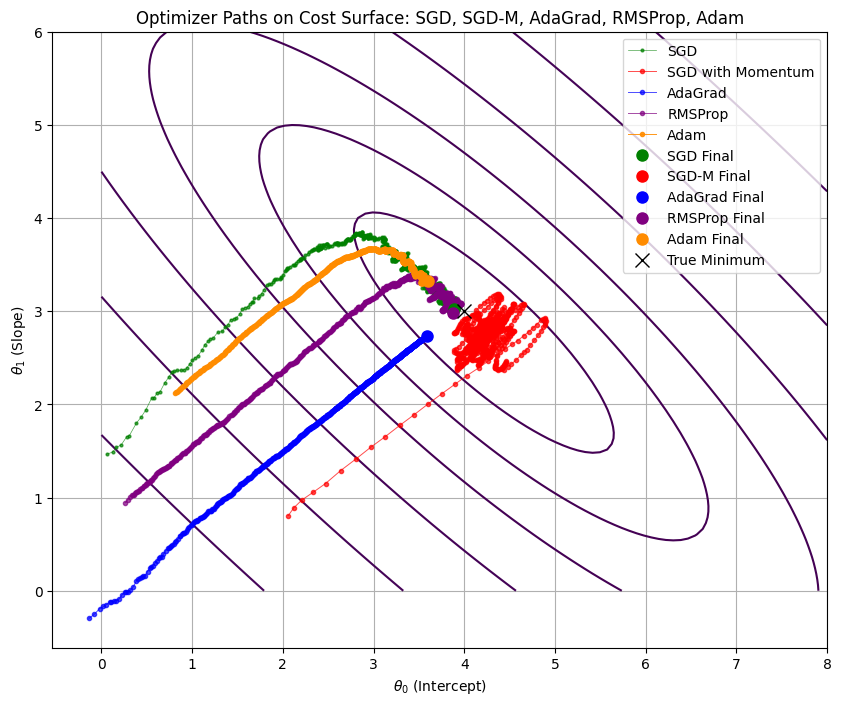

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Generate Synthetic Data for Linear Regression (same as before) ---
np.random.seed(42)
X = 2 * np.random.rand(100, 1) # 100 data points, 1 feature
y = 4 + 3 * X + np.random.randn(100, 1) # y = 4 + 3x + noise
X_b = np.c_[np.ones((100, 1)), X] # Add x0 = 1 to each instance

# --- 2. Define Cost Function (Mean Squared Error) ---
def cost_function(theta, X_b, y):
    m = len(y)
    return (1/(2*m)) * np.sum((X_b.dot(theta) - y)**2)

# --- 3. Implement Stochastic Gradient Descent (for comparison) ---
def stochastic_gradient_descent_base(X_b, y, learning_rate=0.01, n_epochs=50):
    m = len(y)
    theta = np.random.randn(2, 1) # Random initialization
    cost_history = []
    theta_history = []

    for epoch in range(n_epochs):
        shuffled_indices = np.random.permutation(m)
        X_b_shuffled = X_b[shuffled_indices]
        y_shuffled = y[shuffled_indices]

        for i in range(m):
            xi = X_b_shuffled[i:i+1]
            yi = y_shuffled[i:i+1]
            gradients = xi.T.dot(xi.dot(theta) - yi)
            theta = theta - learning_rate * gradients
            cost_history.append(cost_function(theta, X_b, y))
            theta_history.append(theta.flatten())
    return theta, np.array(cost_history), np.array(theta_history)

# --- 4. Implement SGD with Momentum (for comparison) ---
def sgd_with_momentum(X_b, y, learning_rate=0.01, n_epochs=50, momentum_coefficient=0.9):
    m = len(y)
    theta = np.random.randn(2, 1) # Random initialization
    velocity = np.zeros((2, 1)) # Initialize velocity to zeros
    cost_history = []
    theta_history = []

    for epoch in range(n_epochs):
        shuffled_indices = np.random.permutation(m)
        X_b_shuffled = X_b[shuffled_indices]
        y_shuffled = y[shuffled_indices]

        for i in range(m):
            xi = X_b_shuffled[i:i+1]
            yi = y_shuffled[i:i+1]

            # Calculate current gradient (for a single sample)
            gradients = xi.T.dot(xi.dot(theta) - yi)

            # Update velocity
            velocity = momentum_coefficient * velocity + gradients

            # Update parameters
            theta = theta - learning_rate * velocity

            cost_history.append(cost_function(theta, X_b, y))
            theta_history.append(theta.flatten())
    return theta, np.array(cost_history), np.array(theta_history)

# --- 5. Implement AdaGrad (for comparison) ---
def adagrad(X_b, y, learning_rate=0.01, n_epochs=50, epsilon=1e-8):
    m = len(y)
    theta = np.random.randn(2, 1) # Random initialization
    s = np.zeros((2, 1)) # Initialize sum of squared gradients to zeros
    cost_history = []
    theta_history = []

    for epoch in range(n_epochs):
        shuffled_indices = np.random.permutation(m)
        X_b_shuffled = X_b[shuffled_indices]
        y_shuffled = y[shuffled_indices]

        for i in range(m):
            xi = X_b_shuffled[i:i+1]
            yi = y_shuffled[i:i+1]

            # Calculate current gradient (for a single sample)
            gradients = xi.T.dot(xi.dot(theta) - yi)

            # Accumulate squared gradients element-wise
            s += gradients**2

            # Update parameters with adaptive learning rates
            theta = theta - (learning_rate / (np.sqrt(s + epsilon))) * gradients

            cost_history.append(cost_function(theta, X_b, y))
            theta_history.append(theta.flatten())
    return theta, np.array(cost_history), np.array(theta_history)

# --- 6. Implement RMSProp (for comparison) ---
def rmsprop(X_b, y, learning_rate=0.01, n_epochs=50, decay_rate=0.9, epsilon=1e-8):
    m = len(y)
    theta = np.random.randn(2, 1) # Random initialization
    s = np.zeros((2, 1)) # Initialize exponentially weighted moving average of squared gradients
    cost_history = []
    theta_history = []

    for epoch in range(n_epochs):
        shuffled_indices = np.random.permutation(m)
        X_b_shuffled = X_b[shuffled_indices]
        y_shuffled = y[shuffled_indices]

        for i in range(m):
            xi = X_b_shuffled[i:i+1]
            yi = y_shuffled[i:i+1]

            # Calculate current gradient (for a single sample)
            gradients = xi.T.dot(xi.dot(theta) - yi)

            # Update exponentially weighted moving average of squared gradients
            s = decay_rate * s + (1 - decay_rate) * (gradients**2)

            # Update parameters with adaptive learning rates
            theta = theta - (learning_rate / (np.sqrt(s + epsilon))) * gradients

            cost_history.append(cost_function(theta, X_b, y))
            theta_history.append(theta.flatten())
    return theta, np.array(cost_history), np.array(theta_history)

# --- 7. Implement Adam ---
def adam(X_b, y, learning_rate=0.01, n_epochs=50, beta1=0.9, beta2=0.999, epsilon=1e-8):
    m_samples = len(y)
    theta = np.random.randn(2, 1) # Random initialization
    m_t = np.zeros((2, 1)) # Initialize first moment vector
    v_t = np.zeros((2, 1)) # Initialize second moment vector
    cost_history = []
    theta_history = []
    t = 0 # Time step counter

    for epoch in range(n_epochs):
        shuffled_indices = np.random.permutation(m_samples)
        X_b_shuffled = X_b[shuffled_indices]
        y_shuffled = y[shuffled_indices]

        for i in range(m_samples):
            t += 1 # Increment time step
            xi = X_b_shuffled[i:i+1]
            yi = y_shuffled[i:i+1]

            # Calculate current gradient (for a single sample)
            gradients = xi.T.dot(xi.dot(theta) - yi)

            # Update biased first moment estimate
            m_t = beta1 * m_t + (1 - beta1) * gradients

            # Update biased second moment estimate
            v_t = beta2 * v_t + (1 - beta2) * (gradients**2)

            # Bias correction
            m_hat_t = m_t / (1 - beta1**t)
            v_hat_t = v_t / (1 - beta2**t)

            # Parameter update
            theta = theta - learning_rate * (m_hat_t / (np.sqrt(v_hat_t) + epsilon))

            cost_history.append(cost_function(theta, X_b, y))
            theta_history.append(theta.flatten())
    return theta, np.array(cost_history), np.array(theta_history)

# --- 8. Run the optimizers ---
sgd_base_theta, sgd_base_costs, sgd_base_thetas = stochastic_gradient_descent_base(X_b, y, learning_rate=0.01, n_epochs=10)
sgdm_theta, sgdm_costs, sgdm_thetas = sgd_with_momentum(X_b, y, learning_rate=0.01, n_epochs=10, momentum_coefficient=0.9)
adagrad_theta, adagrad_costs, adagrad_thetas = adagrad(X_b, y, learning_rate=0.1, n_epochs=10)
rmsprop_theta, rmsprop_costs, rmsprop_thetas = rmsprop(X_b, y, learning_rate=0.01, n_epochs=10, decay_rate=0.9)
adam_theta, adam_costs, adam_thetas = adam(X_b, y, learning_rate=0.01, n_epochs=10)

# --- 9. Generate a grid for the cost function surface (same as before) ---
theta0_range = np.linspace(0, 8, 100)
theta1_range = np.linspace(0, 6, 100)
J_vals = np.zeros((len(theta0_range), len(theta1_range)))

for i, t0 in enumerate(theta0_range):
    for j, t1 in enumerate(theta1_range):
        theta_val = np.array([[t0], [t1]])
        J_vals[i, j] = cost_function(theta_val, X_b, y)
J_vals = J_vals.T

# --- 10. Create the contour plot ---
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the contour lines of the cost function
ax.contour(theta0_range, theta1_range, J_vals, levels=np.logspace(-2, 3, 20), cmap='viridis')
ax.set_xlabel(r'$\theta_0$ (Intercept)')
ax.set_ylabel(r'$\theta_1$ (Slope)')
ax.set_title('Optimizer Paths on Cost Surface: SGD, SGD-M, AdaGrad, RMSProp, Adam')

# Plot the paths for each variant
ax.plot(sgd_base_thetas[:, 0], sgd_base_thetas[:, 1], 'o-', label='SGD', color='green', markersize=2, lw=0.5, alpha=0.7)
ax.plot(sgdm_thetas[:, 0], sgdm_thetas[:, 1], 'o-', label='SGD with Momentum', color='red', markersize=3, lw=0.7, alpha=0.7)
ax.plot(adagrad_thetas[:, 0], adagrad_thetas[:, 1], 'o-', label='AdaGrad', color='blue', markersize=3, lw=0.7, alpha=0.7)
ax.plot(rmsprop_thetas[:, 0], rmsprop_thetas[:, 1], 'o-', label='RMSProp', color='purple', markersize=3, lw=0.7, alpha=0.7)
ax.plot(adam_thetas[:, 0], adam_thetas[:, 1], 'o-', label='Adam', color='darkorange', markersize=3, lw=0.7, alpha=0.9)

# Mark the final points
ax.plot(sgd_base_thetas[-1, 0], sgd_base_thetas[-1, 1], 'o', markersize=8, color='green', label='SGD Final')
ax.plot(sgdm_thetas[-1, 0], sgdm_thetas[-1, 1], 'o', markersize=8, color='red', label='SGD-M Final')
ax.plot(adagrad_thetas[-1, 0], adagrad_thetas[-1, 1], 'o', markersize=8, color='blue', label='AdaGrad Final')
ax.plot(rmsprop_thetas[-1, 0], rmsprop_thetas[-1, 1], 'o', markersize=8, color='purple', label='RMSProp Final')
ax.plot(adam_thetas[-1, 0], adam_thetas[-1, 1], 'o', markersize=8, color='darkorange', label='Adam Final')

# Mark the true optimal point (from original data generation y = 4 + 3x)
ax.plot(4, 3, 'x', markersize=10, color='black', label='True Minimum')

ax.legend()
ax.grid(True)
plt.show()

#### Summary of Visualization

The plot above comprehensively compares the optimization paths of standard SGD, SGD with Momentum, AdaGrad, RMSProp, and Adam on our linear regression cost surface.

*   **SGD (Green Path)**: Shows the characteristic noisy, zigzagging path, reacting strongly to individual gradients without a broader context.

*   **SGD with Momentum (Red Path)**: Exhibits a smoother, more directed path than plain SGD, benefiting from the accumulated velocity, which helps to accelerate convergence and reduce oscillations.

*   **AdaGrad (Blue Path)**: Makes good initial progress, but its learning rate decays aggressively, causing it to slow down significantly and stop prematurely, often far from the true minimum.

*   **RMSProp (Purple Path)**: Demonstrates more sustained learning than AdaGrad by using an exponentially weighted moving average of squared gradients. It maintains effective learning rates and progresses steadily towards the minimum.

*   **Adam (Orange Path)**: You can observe that Adam often takes a very efficient path towards the minimum. It combines the directional benefits of momentum with the adaptive learning rates of RMSProp, making it robust and often faster at converging. Its path is typically smooth and direct, navigating the contours effectively. In this particular visualization, Adam quickly finds a good direction and makes swift progress towards the true minimum, showcasing its balanced approach.

This visualization highlights how Adam effectively combines the strengths of other optimizers, leading to efficient and stable convergence, which is why it's a popular choice in modern deep learning.

#### Pros of Adam:

*   **Combines Best Features**: Adam effectively combines the advantages of Momentum (which accelerates progress in consistent directions) and RMSProp (which adapts learning rates based on the magnitude of recent gradients). This makes it highly effective across various problem types.
*   **Adaptive Learning Rates**: It computes individual adaptive learning rates for different parameters, meaning less manual tuning of the learning rate hyperparameter. It naturally handles sparse gradients and features with varying frequencies.
*   **Fast Convergence**: Due to its efficient combination of momentum and adaptive learning, Adam often leads to faster convergence during training compared to many other optimizers.
*   **Robust to Hyperparameter Choices**: While it has hyperparameters ($\alpha, \beta_1, \beta_2$), Adam is generally robust to their default values (e.g., $\beta_1=0.9, \beta_2=0.999$), making it a good default choice for many deep learning tasks.
*   **Bias Correction**: The inclusion of bias-correction terms helps to obtain unbiased estimates of the first and second moments, especially during the initial warm-up phase of training, which can improve early-stage optimization.
*   **Suitable for Non-Stationary Objectives**: Like RMSProp, Adam's use of exponentially decaying averages makes it suitable for problems where the loss landscape might change over time.

#### Cons of Adam:

*   **Memory Usage**: Adam maintains two moving average variables ($m_t$ and $v_t$) for each parameter, which means it requires slightly more memory than optimizers that only store one (like Momentum or RMSProp) or none (like SGD).
*   **Can Find Suboptimal Solutions (Generalization Gap)**: While Adam often converges quickly to a minimum with low training loss, some research suggests that it can sometimes generalize worse than SGD with momentum, converging to flatter minima that might not be as optimal in terms of generalization to unseen data. This phenomenon is sometimes referred to as the "generalization gap."
*   **Learning Rate Stability**: In some rare cases, and especially without proper regularization or learning rate schedules, Adam can sometimes struggle with stability, particularly if the initial learning rate is too high.
*   **Requires Careful Decoupling of Weight Decay**: When using L2 regularization (weight decay) with Adam, it's often recommended to use "decoupled weight decay" (e.g., AdamW) rather than simply adding the L2 penalty to the loss function. This is because Adam's adaptive scaling can interact unfavorably with standard weight decay, leading to suboptimal performance.
*   **Potential for Oscillations in Some Settings**: Although generally smooth, in specific highly non-convex landscapes or with certain data characteristics, Adam can still exhibit some oscillations, though usually less severe than plain SGD.

### Time Complexity of Adam:

For each update step (typically per mini-batch):

*   **Gradient Calculation**: This involves a forward pass and a backward pass (backpropagation), which has a complexity of $O(M \times P)$, where $M$ is the mini-batch size and $P$ is the total number of parameters in the network.
*   **Update of First Moment ($m_t$)**: This involves a vector scalar multiplication, a vector-gradient scalar multiplication, and a vector addition. This operation is $O(P)$.
*   **Update of Second Moment ($v_t$)**: This involves element-wise squaring of gradients, a vector scalar multiplication, a vector-squared gradient scalar multiplication, and a vector addition. This operation is $O(P)$.
*   **Bias Correction ($\hat{m}_t$, $\hat{v}_t$)**: These involve element-wise division by scalar terms and exponential calculations ($\beta_1^t$, $\beta_2^t$). These operations have a time complexity of $O(P)$.

Specifically,

$$
\hat{m}_t
=
\frac{m_t}
{1-\beta_1^t}
$$

and

$$
\hat{v}_t
=
\frac{v_t}
{1-\beta_2^t}
$$

where:

* $\hat{m}_t$ is the bias-corrected first moment estimate.
* $\hat{v}_t$ is the bias-corrected second moment estimate.
* $P$ is the total number of trainable parameters in the model.
*   **Parameter Update**: This involves element-wise division by the square root of the bias-corrected second moment, a vector-scalar multiplication (by the global learning rate), and a vector subtraction. This operation is also $O(P)$.

**Overall Time Complexity per Update**: Similar to other advanced adaptive optimizers, the dominant part of Adam's computational cost is the gradient calculation. Therefore, for each update, the complexity remains approximately $O(M \times P)$.

**Total Training Time Complexity**: It's roughly $O(\text{Epochs} \times \text{Number of mini-batches} \times M \times P)$, which simplifies to $O(\text{Epochs} \times \text{Total Samples} \times P)$.

In essence, Adam introduces a minimal computational overhead per update ($O(P)$ operations) for its sophisticated adaptive and momentum-based mechanisms compared to the fundamental gradient calculation ($O(M \times P)$ operations). Its primary benefit is not a reduction in per-update computation time, but rather a significant improvement in **convergence speed, stability, and robustness** during the training of deep neural networks.

## 10. Vanishing & Exploding Gradient

### Definition

#### What are Vanishing and Exploding Gradients?

**Vanishing and Exploding Gradients** are common problems encountered when training deep neural networks, particularly recurrent neural networks (RNNs) but also deep feed-forward networks. They refer to the instability of gradients during the backpropagation process, which can severely hinder the network's ability to learn.

*   **Vanishing Gradients**: Occur when the gradients become extremely small as they are propagated backward through many layers (or many time steps in RNNs). This causes the weights in the earlier layers of the network to update very slowly or not at all, effectively preventing these layers from learning.

*   **Exploding Gradients**: Occur when the gradients become extremely large during backpropagation. This leads to very large updates to the network weights, causing the learning process to become unstable and often resulting in overflow (NaN values) or oscillating loss that fails to converge.

### Why it's needed

Understanding vanishing and exploding gradients is crucial because these phenomena directly impact the ability to train deep neural networks effectively. Without addressing these issues, the advantages of deep architectures (like hierarchical feature learning) cannot be fully realized. Here's why it's needed:

1.  **Hindrance to Learning in Deep Networks**: The core purpose of deep neural networks is to learn complex, multi-layered representations of data. Vanishing gradients prevent earlier layers from learning meaningful features, as their weights are barely updated. This effectively reduces a deep network to a shallow one in terms of learning capacity.

2.  **Training Instability**: Exploding gradients lead to highly unstable training. Large weight updates can cause the model to diverge, produce `NaN` values in the loss function, or jump around the loss landscape erratically, making it impossible to find a good minimum.

3.  **Foundation for Advanced Architectures**: Many advancements in deep learning, such as the development of activation functions like ReLU, architectural choices like LSTMs and GRUs in RNNs, and regularization techniques like Batch Normalization, were specifically designed to combat vanishing or exploding gradients. Understanding these problems provides context for why these solutions were necessary and effective.

4.  **Effective Debugging**: When a deep learning model fails to train or performs poorly, vanishing/exploding gradients are often among the first suspects. Recognizing their symptoms (e.g., stagnant loss, `NaN` values, extremely large weight updates) is essential for diagnosing and debugging model failures.

5.  **Hyperparameter Tuning**: Awareness of these gradient problems influences the choice of hyperparameters, such as learning rate and initialization schemes. For instance, smaller learning rates or gradient clipping are often used to mitigate exploding gradients.

In summary, appreciating the challenges posed by vanishing and exploding gradients is fundamental to building, training, and troubleshooting robust and high-performing deep learning models.

### Intuition

Let's use an analogy of a message being passed down a long chain of people, where each person in the chain represents a layer in a neural network, and the message represents the error signal (gradient) during backpropagation.

#### Vanishing Gradients: The Fading Whisper

Imagine you whisper a secret (the error) to the first person in a long line. They then whisper it to the next, and so on. If each person loses a little bit of the message's detail or volume every time they pass it on, by the time the secret reaches the end of the line (the earlier layers), it will be a faint, unrecognizable whisper. Some people might not even bother to pass it on because it's too quiet.

*   **In a neural network**: During backpropagation, the error signal is multiplied by the derivatives of activation functions and weights as it moves backward. If these derivatives are consistently small (e.g., less than 1, like in the saturated regions of Sigmoid or Tanh functions), the error signal shrinks exponentially. By the time it reaches the initial layers, it's so minuscule that the weights in those layers receive almost no update, and thus, they don't learn or change. It's like the initial layers are 'deaf' to the error happening much later in the network.

#### Exploding Gradients: The Yelling Game

Now, imagine the opposite scenario. You shout a message to the first person, and they don't just repeat it; they exaggerate and shout it even louder to the next person. Each person in the line then shouts it even louder than the last. By the end of the line, the original message is not just distorted, but it's an ear-splitting, chaotic roar.

*   **In a neural network**: If the gradients are consistently large (e.g., greater than 1, which can happen with large weights or certain activation functions), the error signal can grow exponentially as it propagates backward. This leads to incredibly large updates to the network's weights. Such massive updates make the learning process unstable, cause the model parameters to diverge, and can lead to numerical instability where values become infinite or undefined (NaNs). It's like the network completely loses control of its learning, overcorrecting wildly with each step.

### Math

To understand the mathematical basis of vanishing and exploding gradients, we need to look at the **backpropagation algorithm** and how gradients are calculated across multiple layers using the **chain rule**. During backpropagation, the gradient of the loss function with respect to the weights of an early layer is computed by multiplying a series of derivatives from subsequent layers.

Let's consider a simple feed-forward neural network with $L$ layers. The output of layer $l$ is $\mathbf{a}^{(l)} = f^{(l)}(\mathbf{z}^{(l)})$, where $\mathbf{z}^{(l)} = \mathbf{W}^{(l)}\mathbf{a}^{(l-1)} + \mathbf{b}^{(l)}$.

The gradient of the loss $J$ with respect to the weights of layer $k$, $\mathbf{W}^{(k)}$, is given by:

$$ \frac{\partial J}{\partial \mathbf{W}^{(k)}} = \frac{\partial J}{\partial \mathbf{z}^{(L)}} \frac{\partial \mathbf{z}^{(L)}}{\partial \mathbf{z}^{(L-1)}} \cdots \frac{\partial \mathbf{z}^{(k+1)}}{\partial \mathbf{z}^{(k)}} \frac{\partial \mathbf{z}^{(k)}}{\partial \mathbf{W}^{(k)}} $$

Each term in the product $\frac{\partial \mathbf{z}^{(l)}}{\partial \mathbf{z}^{(l-1)}}$ can be expanded further:

$$ \frac{\partial \mathbf{z}^{(l)}}{\partial \mathbf{z}^{(l-1)}} = \frac{\partial \mathbf{z}^{(l)}}{\partial \mathbf{a}^{(l-1)}} \frac{\partial \mathbf{a}^{(l-1)}}{\partial \mathbf{z}^{(l-1)}} = \mathbf{W}^{(l)} \odot f^{(l-1)'}(\mathbf{z}^{(l-1)}) $$

Where $\odot$ is the Hadamard (element-wise) product, and $f^{(l-1)'}(\mathbf{z}^{(l-1)})$ is the element-wise derivative of the activation function at layer $l-1$.

Combining these, the gradient can be seen as a product across layers:

$$ \frac{\partial J}{\partial \mathbf{W}^{(k)}} = \frac{\partial J}{\partial \mathbf{z}^{(L)}} \left( \prod_{l=k+1}^{L} \mathbf{W}^{(l)} \odot f^{(l-1)'}(\mathbf{z}^{(l-1)}) \right) \frac{\partial \mathbf{z}^{(k)}}{\partial \mathbf{W}^{(k)}} $$

This product forms the core of the problem:

#### Vanishing Gradients

**If the terms $\left| \mathbf{W}^{(l)} \odot f^{(l-1)'}(\mathbf{z}^{(l-1)}) \right|$ are consistently small (e.g., less than 1) across many layers, their repeated multiplication causes the overall gradient to shrink exponentially.** This means that the gradients for parameters in earlier layers ($k$ much smaller than $L$) become extremely small, leading to negligible updates during training. As a result, these layers learn very slowly or stop learning altogether.

This typically happens with activation functions like **Sigmoid** or **Tanh**, whose derivatives $f'(z)$ are often much less than 1, especially in their saturated regions (for large positive or negative $z$). If weights $\mathbf{W}^{(l)}$ are also small, this effect is exacerbated.

#### Exploding Gradients

**Conversely, if the terms $\left| \mathbf{W}^{(l)} \odot f^{(l-1)'}(\mathbf{z}^{(l-1)}) \right|$ are consistently large (e.g., greater than 1) across many layers, their repeated multiplication causes the overall gradient to grow exponentially.** This results in extremely large gradients for parameters in earlier layers, leading to massive updates to the network weights. Such large updates destabilize the training process, causing the loss function to diverge or resulting in numerical overflow (values becoming `NaN` or `Inf`).

This can happen if weights $\mathbf{W}^{(l)}$ are large, or if activation functions (like ReLU) have derivatives that are 1 and are combined with large weights. While ReLU itself doesn't cause vanishing gradients, it doesn't prevent exploding gradients if weights are not properly managed.

In both cases, the instability arises from the multiplicative nature of gradient propagation through deep networks. The magnitude of the weights and the derivatives of the activation functions are critical factors.

#### Numerical Example

Let's construct a simplified scenario to numerically illustrate both vanishing and exploding gradients. We'll use a very deep, single-neuron-per-layer network for clarity, and focus on the multiplicative effect of the chain rule.

Assume a network with 5 layers, where each layer has a single neuron. The loss function $J$ is at the output of the 5th layer. We want to see the gradient of the loss with respect to the weight of the first layer, $W^{(1)}$.

The gradient with respect to $W^{(1)}$ will be a product of derivatives across all subsequent layers:

$$ \frac{\partial J}{\partial W^{(1)}} = \frac{\partial J}{\partial a^{(5)}} \cdot \frac{\partial a^{(5)}}{\partial z^{(5)}} \cdot \frac{\partial z^{(5)}}{\partial a^{(4)}} \cdot \frac{\partial a^{(4)}}{\partial z^{(4)}} \cdots \frac{\partial z^{(2)}}{\partial a^{(1)}} \cdot \frac{\partial a^{(1)}}{\partial z^{(1)}} \cdot \frac{\partial z^{(1)}}{\partial W^{(1)}} $$

This simplifies to a product involving the weights and the derivatives of the activation functions. For simplicity, let's assume:

*   $\frac{\partial J}{\partial a^{(5)}} = 1$ (initial error signal)
*   $\frac{\partial z^{(l)}}{\partial W^{(l)}} = a^{(l-1)}$ (activation from previous layer, which for simplicity, we'll assume is $1$ for all relevant layers in this example to isolate the effect of weights and activation derivatives).

Then the overall gradient for $W^{(1)}$ is approximately:

$$ \frac{\partial J}{\partial W^{(1)}} \approx 1 \cdot \left( \prod_{l=2}^{5} W^{(l)} \cdot f^{(l-1)'}(z^{(l-1)}) \right) \cdot 1$$

Let $k_l = W^{(l)} \cdot f^{(l-1)'}(z^{(l-1)})$ be the multiplicative factor at each layer. Then,

$$ \frac{\partial J}{\partial W^{(1)}} \approx k_5 \cdot k_4 \cdot k_3 \cdot k_2 $$\n
---

#### Scenario 1: Vanishing Gradients

Assume we are using a **Sigmoid** activation function, and the weights are initialized to small values. We know that the maximum derivative of the Sigmoid function is 0.25. Let's say, after forward pass, our $W^{(l)}$ and $f^{(l-1)'}(z^{(l-1)})$ values for each layer are consistently small.

**Given Multiplicative Factors per Layer:**

*   $k_2 = W^{(2)} \cdot f^{(1)'}(z^{(1)}) = 0.5 \cdot 0.2 = 0.1$
*   $k_3 = W^{(3)} \cdot f^{(2)'}(z^{(2)}) = 0.5 \cdot 0.2 = 0.1$
*   $k_4 = W^{(4)} \cdot f^{(3)'}(z^{(3)}) = 0.5 \cdot 0.2 = 0.1$
*   $k_5 = W^{(5)} \cdot f^{(4)'}(z^{(4)}) = 0.5 \cdot 0.2 = 0.1$

**Calculation of Gradient for $W^{(1)}$:**

$$ \frac{\partial J}{\partial W^{(1)}} = k_5 \cdot k_4 \cdot k_3 \cdot k_2 = 0.1 \cdot 0.1 \cdot 0.1 \cdot 0.1 = 0.0001 $$\n
**Result:** The gradient for the weight in the first layer ($W^{(1)}$) is extremely small ($0.0001$). This means $W^{(1)}$ will receive a minuscule update, effectively learning almost nothing. If the network were even deeper, this value would approach zero very quickly.

---

#### Scenario 2: Exploding Gradients

Now, assume the weights are initialized to larger values and/or we are using an activation function (like ReLU) whose derivatives can be consistently $\ge 1$, combined with large weights. Let's say our multiplicative factors are consistently large.

**Given Multiplicative Factors per Layer:**

*   $k_2 = W^{(2)} \cdot f^{(1)'}(z^{(1)}) = 2.0 \cdot 1.0 = 2.0$
*   $k_3 = W^{(3)} \cdot f^{(2)'}(z^{(2)}) = 2.0 \cdot 1.0 = 2.0$
*   $k_4 = W^{(4)} \cdot f^{(3)'}(z^{(3)}) = 2.0 \cdot 1.0 = 2.0$
*   $k_5 = W^{(5)} \cdot f^{(4)'}(z^{(4)}) = 2.0 \cdot 1.0 = 2.0$

**Calculation of Gradient for $W^{(1)}$:**

$$ \frac{\partial J}{\partial W^{(1)}} = k_5 \cdot k_4 \cdot k_3 \cdot k_2 = 2.0 \cdot 2.0 \cdot 2.0 \cdot 2.0 = 16.0 $$\n
**Result:** The gradient for the weight in the first layer ($W^{(1)}$) is very large ($16.0$). This would lead to a massive update to $W^{(1)}$, potentially causing the weights to jump wildly, the loss to diverge, or numerical instability. If the network were even deeper, this value would grow exponentially, quickly reaching `Inf` or `NaN`.

#### Visualization

To solidify our understanding, let's visualize the magnitude of gradients as they propagate backward through a deep neural network, both in vanishing and exploding scenarios. This will graphically illustrate how repeated multiplication of small or large factors can dramatically shrink or grow the gradients impacting earlier layers.

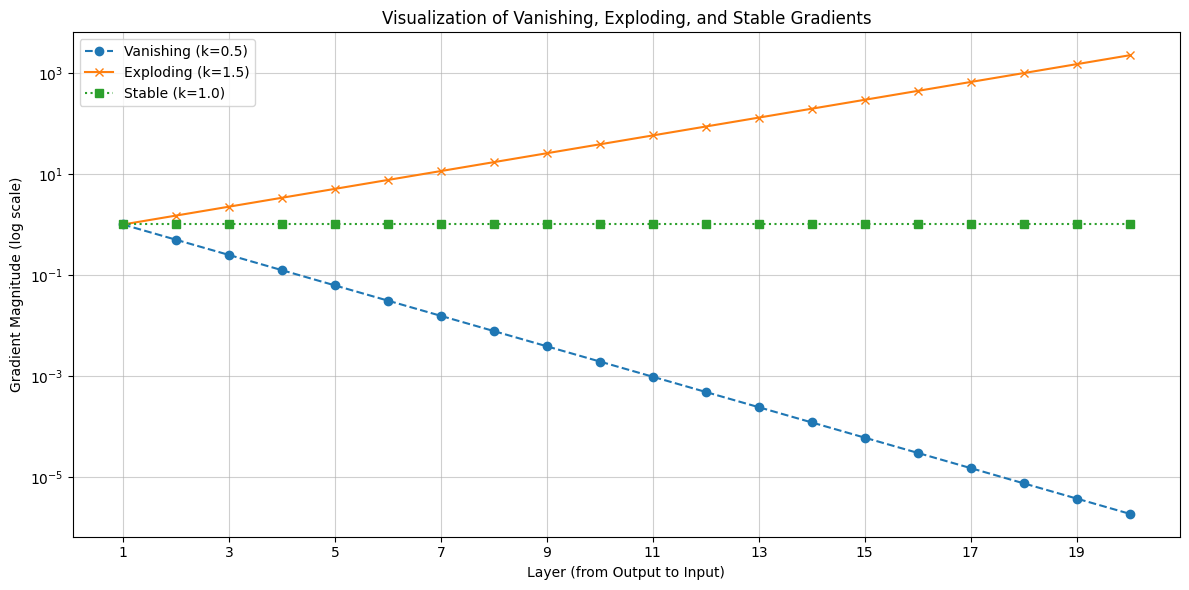

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_gradient_propagation(num_layers, k_value):
    """Simulates gradient propagation through layers with a constant multiplicative factor."""
    gradients = [1.0] # Start with an initial error signal of 1.0
    for _ in range(num_layers - 1):
        gradients.append(gradients[-1] * k_value)
    return np.array(gradients)

# Number of layers in our simulated network
num_layers = 20

# --- Scenario 1: Vanishing Gradients ---
# Assume average multiplicative factor (W * f'(z)) is less than 1
# Typical for sigmoid/tanh in saturated regions with small weights
k_vanishing = 0.5
gradients_vanishing = simulate_gradient_propagation(num_layers, k_vanishing)

# --- Scenario 2: Exploding Gradients ---
# Assume average multiplicative factor (W * f'(z)) is greater than 1
# Can happen with large weights and ReLU activations
k_exploding = 1.5
gradients_exploding = simulate_gradient_propagation(num_layers, k_exploding)

# --- Scenario 3: Stable Gradients ---
# Ideal scenario where gradients maintain a reasonable magnitude
k_stable = 1.0
gradients_stable = simulate_gradient_propagation(num_layers, k_stable)

# --- Plotting the results ---
plt.figure(figsize=(12, 6))

plt.plot(range(1, num_layers + 1), gradients_vanishing, label=f'Vanishing (k={k_vanishing})', marker='o', linestyle='--')
plt.plot(range(1, num_layers + 1), gradients_exploding, label=f'Exploding (k={k_exploding})', marker='x', linestyle='-')
plt.plot(range(1, num_layers + 1), gradients_stable, label=f'Stable (k={k_stable})', marker='s', linestyle=':')

plt.yscale('log') # Use a logarithmic scale for y-axis to better visualize large ranges
plt.title('Visualization of Vanishing, Exploding, and Stable Gradients')
plt.xlabel('Layer (from Output to Input)')
plt.ylabel('Gradient Magnitude (log scale)')
plt.xticks(range(1, num_layers + 1, 2)) # Show fewer x-ticks for clarity
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

#### Summary of Visualization

The plot above vividly demonstrates the effects of vanishing and exploding gradients as they propagate backward through a simulated deep neural network.

*   **Vanishing Gradients (Blue Dashed Line)**: When the average multiplicative factor (`k_value`) per layer is less than 1 (e.g., 0.5), the gradient magnitude shrinks exponentially with each successive layer. By the time it reaches earlier layers (further left on the x-axis), the gradient becomes infinitesimally small. This prevents effective learning in those initial layers.

*   **Exploding Gradients (Orange Solid Line)**: Conversely, when the average `k_value` is greater than 1 (e.g., 1.5), the gradient magnitude grows exponentially. As it moves backward, the gradient quickly becomes extremely large, leading to unstable training, huge weight updates, and potential numerical overflow (NaNs).

*   **Stable Gradients (Green Dotted Line)**: In an ideal scenario, where the `k_value` is around 1.0, gradients maintain a relatively constant magnitude across layers. This allows all layers to receive meaningful updates and learn effectively.

This visualization underscores the critical challenge these phenomena pose to training deep neural networks and highlights why mitigating them is essential for successful deep learning.

### Pros

While vanishing and exploding gradients are problems, understanding and addressing them comes with significant benefits, which can be thought of as 'pros' in the context of successful deep learning:

1.  **Enables Deeper Architectures**: Recognizing and finding solutions to these gradient issues (e.g., ReLU, Batch Normalization, LSTMs) has been instrumental in the development and successful training of truly deep neural networks. Without this understanding, deep learning would be severely limited.

2.  **Improved Training Stability**: By implementing techniques to manage gradients, training becomes much more stable. Models are less likely to diverge, produce `NaN` values, or oscillate wildly around the optimal solution.

3.  **Faster Convergence**: Stabilized gradients allow for more consistent and meaningful weight updates across all layers, leading to faster and more efficient convergence to a good solution.

4.  **Better Model Performance and Generalization**: When all layers of a deep network can learn effectively, the model can capture more complex and hierarchical representations of data, leading to superior performance on various tasks and better generalization to unseen data.

5.  **Informed Architectural and Hyperparameter Choices**: Awareness of vanishing/exploding gradients guides practitioners in selecting appropriate activation functions, weight initialization schemes, optimizers, and regularization techniques (like gradient clipping), leading to better model design.

### Cons

Vanishing and exploding gradients represent significant challenges in deep learning. Their 'cons' are the direct negative impacts they have on the training process and model performance:

#### Cons of Vanishing Gradients:

1.  **Slow or Stalled Learning in Early Layers**: The most critical impact is that parameters in the initial layers of a deep network receive extremely small updates, effectively preventing them from learning. This means the network cannot capture low-level features effectively.

2.  **Reduced Learning Capacity**: Effectively, a deep network with vanishing gradients behaves like a shallow network, as only the later layers contribute meaningfully to learning. This negates the benefits of using a deep architecture.

3.  **Difficulty Capturing Long-Term Dependencies**: Particularly in Recurrent Neural Networks (RNNs) for sequential data, vanishing gradients make it impossible for the model to 'remember' information from earlier parts of a sequence, limiting its ability to understand long-range patterns.

4.  **Poor Performance**: Models suffering from vanishing gradients will likely exhibit poor performance, as they fail to learn comprehensive representations of the input data.

#### Cons of Exploding Gradients:

1.  **Training Instability and Divergence**: Extremely large gradients lead to massive updates to network weights, causing the learning process to become highly unstable. The model's parameters can jump erratically in the loss landscape, preventing convergence.

2.  **Numerical Overflow (NaNs/Infs)**: The weights and activations can grow so large that they exceed the maximum representable floating-point value, leading to `NaN` (Not a Number) or `Inf` (Infinity) errors, causing training to halt or produce meaningless results.

3.  **Oscillating Loss**: The loss function can fluctuate wildly or even increase over epochs, indicating that the model is struggling to find a stable minimum.

4.  **Difficulty in Debugging**: `NaN` or `Inf` values can be challenging to debug, as they might originate from a specific layer but only manifest much later in the computation graph.

In both cases, these problems can make training deep neural networks a frustrating and often futile endeavor without proper mitigation strategies.

### Time Complexity

The time complexity of vanishing and exploding gradients isn't about adding extra computational steps to the forward or backward pass. Instead, it refers to how these phenomena *indirectly impact the overall training time* and efficiency of a deep learning model.

1.  **Increased Training Time Due to Slow Convergence (Vanishing Gradients)**:
    *   When gradients vanish, the learning in earlier layers slows down dramatically, or stops altogether. To compensate, one might need to train the network for a significantly larger number of epochs (iterations) to achieve reasonable performance. This directly increases the total training time.
    *   If the learning rate for later layers is kept high to facilitate their learning, the earlier layers still won't catch up due to their tiny gradients, prolonging the training required for the entire network to reach an optimal state.

2.  **Increased Training Time Due to Divergence and Restarting (Exploding Gradients)**:
    *   Exploding gradients often lead to numerical instability, causing the model to diverge (loss becomes `NaN` or `Inf`). When this happens, the training process usually has to be stopped, and the model needs to be re-initialized and re-trained, potentially with different hyperparameters (e.g., a smaller learning rate or gradient clipping).
    *   Each such divergence and restart contributes to wasted computational time and prolongs the overall time needed to find a working model.

3.  **Hyperparameter Tuning Overhead**: Both problems necessitate extensive hyperparameter tuning (e.g., finding the right learning rate, momentum, activation functions, weight initialization strategies, or applying gradient clipping). This trial-and-error process, involving multiple training runs, adds significantly to the overall time taken to develop a robust model.

4.  **Ineffective Use of Resources**: Even if a model eventually converges with vanishing gradients, the time spent on training epochs where early layers aren't learning is essentially wasted computation, leading to an inefficient use of resources (CPU/GPU cycles).

In essence, while the theoretical big-O complexity of a single backpropagation pass doesn't change due to vanishing or exploding gradients, their presence dramatically increases the *practical time complexity* of successfully training a deep neural network.

### Solutions / Mitigations

Fortunately, several effective strategies have been developed to combat vanishing and exploding gradients, enabling the successful training of deep neural networks. These solutions often fall into categories such as improved activation functions, better weight initialization, normalization techniques, and architectural modifications.

#### 1. Activation Functions

The choice of activation function plays a crucial role in gradient flow. Saturated activation functions like Sigmoid and Tanh are major culprits for vanishing gradients because their derivatives are very small in large regions of their input space.

**a. ReLU and its Variants (Leaky ReLU, ELU, PReLU)**

*   **How it helps**: ReLU (Rectified Linear Unit) and its variants address the vanishing gradient problem for positive inputs. For $z > 0$, the derivative of ReLU is 1, which allows gradients to flow effectively without shrinking. This prevents saturation and accelerates convergence.
*   **Mitigates**: Vanishing Gradients (for positive inputs).
*   **Limitation**: Standard ReLU can suffer from the 'dying ReLU' problem where neurons get stuck returning 0 for all inputs if their input is consistently negative. Leaky ReLU and ELU address this by allowing a small, non-zero gradient for negative inputs.

#### 2. Weight Initialization

The initial values of a network's weights significantly influence whether gradients vanish or explode from the very start of training. Poor initialization can set the network up for failure before it even begins to learn.

**a. Xavier/Glorot Initialization**

*   **How it helps**: Designed for activation functions like Tanh and Sigmoid (which are symmetric around zero). It initializes weights randomly from a distribution (e.g., uniform or normal) with a variance that depends on the number of input and output neurons. The goal is to keep the variance of the activations and gradients roughly the same across all layers.
*   **Mitigates**: Both Vanishing and Exploding Gradients by preventing activations and gradients from growing or shrinking too rapidly in the early stages of training.
*   **Formula (Normal)**: Weights drawn from a normal distribution with mean 0 and variance $rac{2}{n_{in} + n_{out}}$.
*   **Formula (Uniform)**: Weights drawn from a uniform distribution in $[-	ext{limit}, 	ext{limit}]$ where $	ext{limit} = rac{	ext{sqrt}(6)}{	ext{sqrt}(n_{in} + n_{out})}$.

**b. He Initialization**

*   **How it helps**: Specifically designed for ReLU and its variants. It initializes weights randomly from a distribution (e.g., normal) with a variance that depends on the number of input neurons. This accounts for ReLU's characteristic of setting negative inputs to zero, thus retaining activation variance.
*   **Mitigates**: Vanishing Gradients (with ReLU activations) by ensuring that the gradients flowing backward don't diminish too quickly.
*   **Formula (Normal)**: Weights drawn from a normal distribution with mean 0 and variance $rac{2}{n_{in}}$.
*   **Formula (Uniform)**: Weights drawn from a uniform distribution in $[-	ext{limit}, 	ext{limit}]$ where $	ext{limit} = rac{	ext{sqrt}(6)}{	ext{sqrt}(n_{in})}$.

#### 3. Normalization Techniques

These techniques help stabilize the distributions of inputs to layers and the gradients, making training more robust.

**a. Batch Normalization**

*   **How it helps**: Normalizes the inputs to each layer (or mini-batch) by re-centering and re-scaling them. This reduces the problem of internal covariate shift, where the distribution of layer inputs changes during training. By maintaining stable input distributions, it ensures that gradients remain in a healthy range, preventing them from becoming too small or too large.
*   **Mitigates**: Both Vanishing and Exploding Gradients, and allows for higher learning rates, faster training, and less dependence on weight initialization.
*   **Mechanism**: For each mini-batch, it calculates the mean and variance of the layer's inputs, then normalizes these inputs, and finally scales and shifts them using learned parameters ($eta$ and $	ext{gamma}$).

#### 4. Gradient Clipping

This is a direct and effective way to deal with exploding gradients by capping the maximum value of gradients.

**a. Gradient Clipping**

*   **How it helps**: If gradients exceed a certain threshold during backpropagation, they are scaled down to that threshold. This directly prevents gradients from becoming too large and causing unstable updates or numerical overflow.
*   **Mitigates**: Primarily Exploding Gradients.
*   **Mechanism**: If the L2 norm of the gradient vector for a layer exceeds a predefined threshold, the entire gradient vector is scaled down such that its L2 norm equals the threshold. This ensures the direction of the gradient is preserved, but its magnitude is controlled.

#### 5. Architectural Changes

Certain network architectures are inherently more robust to gradient problems, particularly in sequential data processing.

**a. Long Short-Term Memory (LSTM) and Gated Recurrent Unit (GRU) Networks**

*   **How it helps**: These are specialized recurrent neural network (RNN) architectures designed to handle long-term dependencies in sequential data. They employ 'gates' (input, forget, output gates for LSTMs; update, reset gates for GRUs) that control the flow of information through the network's memory cell. These gates allow gradients to flow more smoothly over many time steps, effectively mitigating both vanishing and exploding gradients in RNNs.
*   **Mitigates**: Vanishing and Exploding Gradients in Recurrent Neural Networks.

### Summary of Vanishing & Exploding Gradients

**Vanishing and Exploding Gradients** are critical challenges in training deep neural networks, stemming from the multiplicative nature of the chain rule during backpropagation. The core problem lies in the unstable propagation of error signals through many layers, severely impacting the learning process.

*   **Vanishing Gradients**: Occur when gradients become extremely small as they propagate backward through the network. This primarily happens with activation functions like Sigmoid and Tanh (due to their saturated regions having derivatives close to zero) and small weight values. The consequence is that parameters in earlier layers receive negligible updates, hindering their ability to learn meaningful features and effectively reducing the deep network's learning capacity to that of a shallower one.

*   **Exploding Gradients**: Occur when gradients become excessively large during backpropagation. This can happen with large weight values or non-saturating activation functions combined with large weights. The result is highly unstable training, leading to enormous weight updates that cause the model to diverge, produce `NaN` (Not a Number) values, or oscillate wildly around the optimal solution.

**Solutions and Mitigations** developed to combat these issues are crucial for successful deep learning:

1.  **Activation Functions**: Switching from saturating functions (Sigmoid, Tanh) to non-saturating ones like **ReLU** and its variants (**Leaky ReLU, ELU**) effectively addresses vanishing gradients for positive inputs by maintaining a constant (or near-constant) derivative. Variants also help alleviate the 'dying ReLU' problem.

2.  **Weight Initialization**: Proper initialization ensures that weights are neither too large nor too small, preventing gradients from vanishing or exploding from the very start. **Xavier/Glorot Initialization** is used for Sigmoid/Tanh, while **He Initialization** is tailored for ReLU and its variants.

3.  **Normalization Techniques**: **Batch Normalization** stabilizes the distribution of inputs to layers, keeping gradients within a healthy range and promoting more stable learning, thereby mitigating both vanishing and exploding gradients.

4.  **Gradient Clipping**: A direct solution for exploding gradients, where gradients are scaled down if their magnitude exceeds a predefined threshold, preventing large, unstable weight updates.

5.  **Architectural Changes**: For recurrent neural networks (RNNs), specialized architectures like **Long Short-Term Memory (LSTM)** and **Gated Recurrent Unit (GRU)** use 'gates' to regulate information flow, enabling gradients to propagate more effectively over long sequences and mitigating both problems.

Understanding and applying these solutions has been pivotal in enabling the successful training of the complex, deep neural networks that power modern AI.

## 11. Regularization

### Definition

#### Definition

**Regularization** refers to a set of techniques used in machine learning, particularly in neural networks, to prevent overfitting and improve the model's ability to generalize to unseen data. Overfitting occurs when a model learns the training data too well, including its noise and outliers, leading to poor performance on new, unobserved examples.

Regularization techniques work by adding a penalty to the loss function, or by otherwise constraining the complexity of the model during training. This encourages the model to learn simpler, more robust patterns, rather than memorizing the training data. Essentially, regularization aims to strike a balance between fitting the training data accurately and maintaining the model's ability to generalize.

#### Why it's needed

Regularization is indispensable for successful machine learning, especially with complex models like neural networks, due to the persistent threat of **overfitting**. Here's why it's fundamentally needed:

1.  **Prevent Overfitting**: This is the primary reason. Overfitting occurs when a model learns the training data too well, memorizing the noise and spurious correlations rather than the underlying patterns. An overfit model will perform exceptionally well on the training data but poorly on new, unseen data, which defeats the purpose of building a predictive model. Regularization techniques impose constraints on the model's learning process, discouraging it from becoming overly complex and thus preventing overfitting.

2.  **Improve Generalization**: By preventing overfitting, regularization forces the model to focus on the more generalizable patterns in the data. A model that generalizes well can make accurate predictions on data it has never seen before, which is the ultimate goal of machine learning.

3.  **Handle Model Complexity**: Deep neural networks are inherently very complex models with a large number of parameters (weights and biases). With sufficient capacity, they can easily memorize the training set. Regularization acts as a countermeasure, effectively controlling this complexity by penalizing large weights or reducing the reliance on specific neurons, making the model simpler and more robust.

4.  **Stabilize Training**: In some cases, regularization can help stabilize the training process, particularly when dealing with noisy data or complex loss landscapes. By preventing extreme weight values, it can make optimization algorithms more robust.

5.  **Feature Selection (L1 Regularization)**: Some regularization techniques, like L1 regularization, have the added benefit of performing implicit feature selection. They can drive the weights of less important features to zero, effectively simplifying the model and potentially highlighting important features.

In essence, regularization helps bridge the gap between a model's performance on training data and its performance on unseen data, ensuring that the insights gained during training are genuinely applicable to the real world.

#### Intuition

Imagine you are a student preparing for an exam. You have a textbook (your training data) and you want to pass the exam (generalize to unseen data).

**Without Regularization (Overfitting)**:
If you try to memorize every single detail, every example, and every specific wording from the textbook, you might ace questions that are identical to the textbook examples. But if the exam asks questions in a slightly different way, or introduces new scenarios that require a deeper understanding of the underlying principles, you'll struggle. You've **overfit** to the textbook; you've learned the noise and specific quirks rather than the core concepts. Your performance on the actual exam (unseen data) will be poor.

**With Regularization (Generalization)**:
Now, imagine your teacher (the regularization technique) tells you:
*   "Don't try to memorize every single sentence. Focus on the main ideas, the fundamental formulas, and the general problem-solving approaches." (This is like penalizing overly complex patterns or large weights).
*   "It's better to have a good, solid understanding of the broad topics than to have a perfect, but brittle, memory of trivial details." (This encourages simpler models that are less sensitive to noise).
*   "If you're unsure about a specific detail, rely on your understanding of the broader context rather than making an overly confident, but potentially wrong, guess." (This can be seen as techniques that reduce over-reliance on individual features or neurons).

By following this advice, you might not get every single minor detail correct, but you'll have a much better chance of answering a wide variety of questions, even ones you haven't seen before. You've learned to **generalize** from the textbook material to new situations.

In neural networks, regularization acts like this teacher. It subtly discourages the network from becoming too confident in specific, complex patterns from the training data, nudging it towards learning simpler, more broadly applicable rules. This makes the network more resilient to variations in new data, improving its performance where it truly matters: on unseen examples.

#### Types of Regularization

There are several techniques used for regularization, each approaching the problem of overfitting from a slightly different angle. We will explore the most common ones:

##### 1. Dropout

###### Definition

###### Mechanism

Dropout is a simple yet powerful regularization technique that involves randomly 'dropping out' (setting to zero) a proportion of neurons in a neural network during training. This means that, for a given training iteration, a randomly selected subset of neurons will not participate in the forward pass and backward pass. This process forces the network to learn more robust features that are not dependent on the presence of any single neuron.

Here's how it works in detail:

1.  **During Training**: At each training step (or for each mini-batch), for each hidden layer, a randomly selected proportion of its neurons (along with their incoming and outgoing connections) are temporarily removed from the network. The probability of a neuron being dropped out is a hyperparameter, commonly denoted as `p` (e.g., 0.5 or 0.2), which is the dropout rate. Each neuron has a `p` chance of being dropped and `(1-p)` chance of being kept.
    *   If `p=0.5`, roughly half the neurons in the layer will be switched off. This means for each training example, a different 'thinned' network is being trained.

2.  **Forward Pass**: The input data flows through this thinned network, and the output is calculated based on the active neurons.

3.  **Backward Pass**: Gradients are calculated only for the active neurons and their corresponding weights. The weights of the dropped-out neurons are not updated in that particular training step.

4.  **During Testing/Inference**: Dropout is **turned off**. All neurons are active. To compensate for the fact that more neurons are now active (which would lead to higher output values), the weights of the neurons that were used during training are scaled down by the dropout rate `(1-p)`. Alternatively, during training, the activations of the kept neurons are scaled up by `1/(1-p)` (known as **inverted dropout**) so that no scaling is needed at test time. Inverted dropout is more commonly used in practice.

###### Why it's needed

Dropout is a powerful regularization technique designed to address the significant challenge of **overfitting** in neural networks. Here's why it's fundamentally needed:

1.  **Prevents Overfitting**: Deep neural networks often have a vast number of parameters, giving them immense capacity to memorize the training data, including noise. Dropout randomly switches off neurons during training, forcing the network to learn more robust and distributed representations. Each mini-batch sees a slightly different network, preventing individual neurons from becoming too specialized or co-dependent on specific other neurons. This makes the network less likely to overfit the training data.

2.  **Encourages Robust Feature Learning**: By randomly dropping neurons, the network cannot rely on any single neuron or a small set of neurons to detect a specific feature. Instead, it must develop more redundant representations, where multiple neurons can detect the same feature independently. This makes the learned features more robust and less susceptible to minor variations in the input data.

3.  **Acts as an Ensemble of Models**: Dropout can be thought of as training an ensemble of many (exponentially many) thinned networks simultaneously. Each time a neuron is dropped, it creates a new, slightly different network. Since these thinned networks share weights, averaging their predictions during inference (by scaling weights) leads to a more generalized and robust output, similar to how model ensembles improve performance.

4.  **Reduces Co-adaptation**: Without dropout, neurons in a network can 'co-adapt' to each other, meaning they become highly dependent on the presence and output of other specific neurons. This can lead to brittle models. Dropout breaks these co-adaptations by forcing neurons to learn to be useful in a wider variety of contexts, making them less sensitive to the exact configuration of other active neurons.

5.  **Improves Generalization**: Ultimately, all these factors contribute to better generalization. A model that has been trained with dropout is less likely to have memorized the training data and is more likely to perform well on new, unseen data, which is the primary goal of any machine learning model.

###### Intuition

Let's extend our 'student studying for an exam' analogy to understand the intuition behind Dropout. Imagine a class where students are working on a group project, and the goal is to present a comprehensive solution to a problem.

**Without Dropout (Co-adaptation)**:
Each student in the group might specialize too much, becoming overly reliant on other specific students for certain parts of the project. For example, one student always handles research, another always does the writing, and another always does the presentation. If, on the day of the presentation, the 'researcher' is absent, the 'writer' and 'presenter' might struggle because they haven't developed a strong understanding of the research themselves. They've co-adapted to rely on the researcher.

**With Dropout (Robustness and Ensemble Learning)**:
Now, imagine the teacher (Dropout) randomly sends a few students out of the classroom for each work session. So, one day the 'researcher' might be gone, the next day the 'writer', and so on. This forces the remaining students to step up and cover those roles. The 'presenter' learns to do some research, the 'writer' learns to think critically about the data, etc. Everyone develops a more holistic understanding and becomes more capable of handling any part of the project.

Here's how this relates to a neural network:

1.  **Random Absence**: Just like students are randomly 'dropped out' from the group, neurons are randomly 'switched off' during each training iteration. This creates a different, smaller network each time.

2.  **No Co-Dependence**: Because a neuron can't be sure which other neurons will be active, it's forced to learn useful features independently. It can't rely on another neuron to always be there to correct its mistakes or complement its activation. This prevents co-adaptation, where neurons become overly specialized and dependent on specific inputs from other neurons.

3.  **Robust Learning**: Each neuron learns to be more robust. If it's a neuron responsible for detecting 'eyes' in an image, it learns to do so even if other neurons responsible for 'noses' or 'ears' are switched off. This makes the overall network less sensitive to specific features and more adaptable to variations.

4.  **Ensemble Effect**: Every time you train with dropout, you're essentially training a different 'thinned' network. At test time, when all neurons are active (but their weights are scaled down), it's like having an ensemble of all these slightly different networks making a prediction and averaging their results. This ensemble effect is known to significantly improve generalization and reduce overfitting.

In essence, Dropout teaches the network to be more resilient and prevents it from 'cheating' by memorizing the training data, ultimately leading to a model that performs better on new, unseen examples.

###### Math

Mathematically, Dropout modifies the forward propagation and, consequently, the backpropagation process by introducing a binary mask to the activations of neurons during training. This mask randomly sets a proportion of neuron activations to zero.

Consider a layer $l$ in a neural network, with activations $\mathbf{a}^{(l)}$. Without dropout, the next layer's pre-activation $\mathbf{z}^{(l+1)}$ would be calculated as:

$$ \mathbf{z}^{(l+1)} = \mathbf{W}^{(l+1)} \mathbf{a}^{(l)} + \mathbf{b}^{(l+1)} $$

With Dropout, the process is modified during training:

###### Formula



Dropout modifies the forward pass during training by randomly setting a proportion of neuron activations to zero. Let $p$ be the dropout rate (the probability of a neuron being dropped). During training, for a hidden layer $l$ with activations $\mathbf{a}^{(l)}$:

1. **Generate a Dropout Mask**: A binary vector $\mathbf{d}^{(l)}$ is created, where each element is 1 with probability $(1-p)$ and 0 with probability $p$. This can be thought of as applying a Bernoulli distribution.

   $$
   \mathbf{d}^{(l)}
   \sim
   \operatorname{Bernoulli}(1-p)
   $$

2. **Apply the Mask to Activations**: The activations of the current layer are element-wise multiplied by the dropout mask.

   $$
   \mathbf{\tilde{a}}^{(l)}
   =
   \mathbf{a}^{(l)}
   \odot
   \mathbf{d}^{(l)}
   $$

3. **Scale Activations (Inverted Dropout)**: To ensure that the expected output of the layer remains the same during training and testing, the active neurons' activations are scaled up. This is commonly known as **inverted dropout**.

   $$
   \mathbf{a}^{(l)}_{\text{dropout}}
   =
   \frac{1}{1-p}
   \mathbf{\tilde{a}}^{(l)}
   $$

   This scaling ensures that at test time, all neurons can be used without any further scaling, as the expected output activation during training already accounts for the dropped neurons.

4. **Forward Pass to Next Layer**: These dropout-applied and scaled activations are then used as inputs for the next layer's pre-activation calculation.

   $$
   \mathbf{z}^{(l+1)}
   =
   \mathbf{W}^{(l+1)}
   \mathbf{a}^{(l)}_{\text{dropout}}
   +
   \mathbf{b}^{(l+1)}
   $$
**During Testing/Inference**:

Dropout is **turned off**. All neurons are active, and no scaling is needed if inverted dropout was used during training. The forward pass is computed normally:

$$ \mathbf{z}^{(l+1)} = \mathbf{W}^{(l+1)} \mathbf{a}^{(l)} + \mathbf{b}^{(l+1)} $$

This ensures that the output values during training and testing are on a similar scale, making the model's predictions consistent.

###### Numerical Example
Let's walk through a simplified numerical example to illustrate how Dropout works during the **training phase** for a single hidden layer. We will assume a small vector of activations from a hidden layer and apply dropout.

**Given:**

* **Activations from a Hidden Layer** (e.g., $\mathbf{a}^{(l)}$ for layer $l$):

  $$
  \mathbf{a}^{(l)}
  =
  \begin{pmatrix}
  0.8\\
  1.2\\
  0.5\\
  2.0
  \end{pmatrix}
  $$

* **Dropout Rate** ($p$):

  $$
  p
  =
  0.5
  $$

* **Inverse Dropout Scaling Factor**:

  $$
  \frac{1}{1-p}
  =
  \frac{1}{1-0.5}
  =
  \frac{1}{0.5}
  =
  2.0
  $$

---

#### Step-by-Step Calculation (Training Phase):

1. **Generate a Random Dropout Mask (Bernoulli with $1-p=0.5$)**:

   Let's assume our random process generates the following mask for this specific training step:

   $$
   \mathbf{d}^{(l)}
   =
   \begin{pmatrix}
   1\\
   0\\
   1\\
   0
   \end{pmatrix}
   $$

   (Meaning the 2nd and 4th neurons are dropped out.)

2. **Apply the Mask to Activations (Element-wise Multiplication)**:

   $$
   \mathbf{\tilde{a}}^{(l)}
   =
   \mathbf{a}^{(l)}
   \odot
   \mathbf{d}^{(l)}
   $$

   $$
   =
   \begin{pmatrix}
   0.8\\
   1.2\\
   0.5\\
   2.0
   \end{pmatrix}
   \odot
   \begin{pmatrix}
   1\\
   0\\
   1\\
   0
   \end{pmatrix}
   $$

   $$
   =
   \begin{pmatrix}
   0.8 \times 1\\
   1.2 \times 0\\
   0.5 \times 1\\
   2.0 \times 0
   \end{pmatrix}
   =
   \begin{pmatrix}
   0.8\\
   0.0\\
   0.5\\
   0.0
   \end{pmatrix}
   $$

3. **Scale Activations (Inverted Dropout)**:

   The non-zero activations are scaled up by the inverse dropout probability.

   $$
   \mathbf{a}^{(l)}_{\text{dropout}}
   =
   \frac{1}{1-p}
   \mathbf{\tilde{a}}^{(l)}
   $$

   $$
   =
   2.0
   \times
   \begin{pmatrix}
   0.8\\
   0.0\\
   0.5\\
   0.0
   \end{pmatrix}
   $$

   $$
   =
   \begin{pmatrix}
   1.6\\
   0.0\\
   1.0\\
   0.0
   \end{pmatrix}
   $$

---

#### Result:

For this training step, the activations passed to the next layer would be $\mathbf{a}^{(l)}_{dropout} = \begin{pmatrix} 1.6 \\ 0.0 \\ 1.0 \\ 0.0 \end{pmatrix}$.

*   Notice how the dropped neurons (2nd and 4th) now have an activation of 0.
*   The active neurons (1st and 3rd) have their activations scaled up (from 0.8 to 1.6 and 0.5 to 1.0, respectively). This ensures that the *expected sum* of activations from this layer remains consistent, even though fewer neurons are active, which is important for maintaining the signal strength through the network.

###### Visualization

Let's visualize the effect of Dropout on a simple neural network during the training phase. We'll show a network where some neurons in a hidden layer are randomly dropped out.



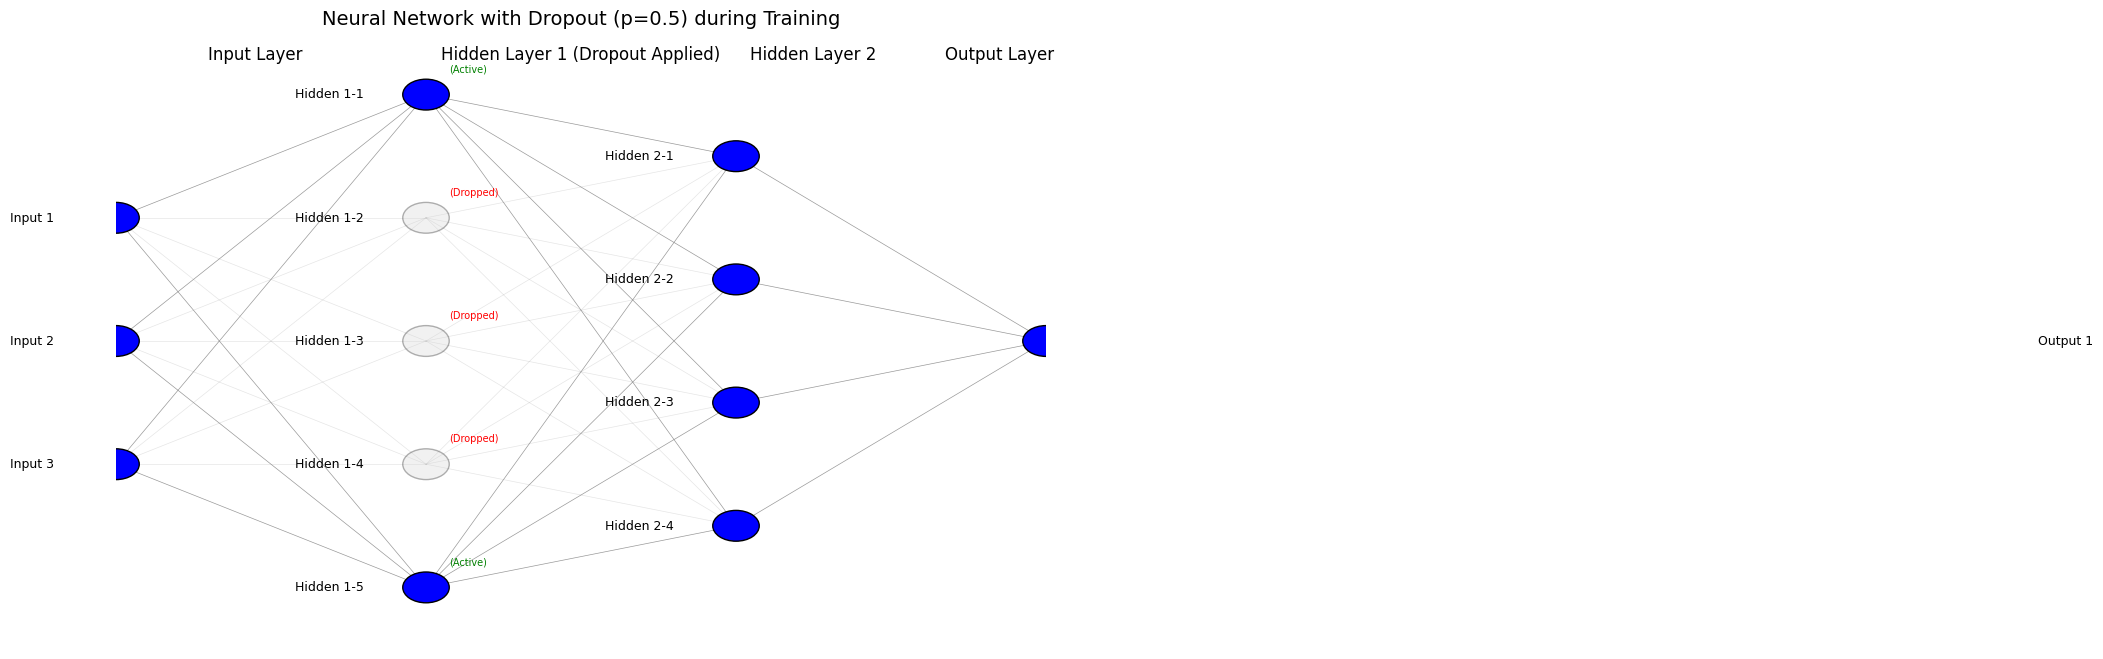

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import random

def draw_neural_net_with_dropout(ax, left, right, bottom, top, layer_sizes, dropout_layer_idx, dropout_rate):
    '''
    Draw a neural network diagram with dropout indicated.

    Args:
        ax: Matplotlib axes object.
        left, right, bottom, top: Bounding box for the drawing.
        layer_sizes: List of integers, each representing the number of neurons in a layer.
        dropout_layer_idx: The index of the layer where dropout is applied (0-indexed, excluding input layer).
        dropout_rate: The probability of dropping a neuron.
    '''
    n_layers = len(layer_sizes)
    v_spacing = (top - bottom) / max(layer_sizes) # Vertical spacing between neurons
    h_spacing = (right - left) / (n_layers - 1) # Horizontal spacing between layers

    # Generate dropout mask for the specified layer
    if dropout_layer_idx < n_layers and dropout_layer_idx >= 0:
        num_neurons_in_dropout_layer = layer_sizes[dropout_layer_idx]
        dropout_mask = [random.random() > dropout_rate for _ in range(num_neurons_in_dropout_layer)]
    else:
        dropout_mask = [True] * layer_sizes[dropout_layer_idx] # All active if no dropout layer

    # Nodes
    for n, layer_size in enumerate(layer_sizes):
        layer_top = v_spacing * (layer_size - 1) / 2 + (top + bottom) / 2
        for i in range(layer_size):
            node_color = 'blue'
            edge_color = 'gray'
            alpha = 1.0
            if n == dropout_layer_idx:
                if not dropout_mask[i]: # If neuron is dropped
                    node_color = 'lightgray'
                    alpha = 0.3 # Make dropped neuron semi-transparent

            circle = plt.Circle((n * h_spacing + left, layer_top - i * v_spacing), v_spacing / 8,
                                color=node_color, ec='k', zorder=4, alpha=alpha)
            ax.add_artist(circle)

            # Label layers
            if n == 0:
                ax.text(n * h_spacing + left - v_spacing / 3, layer_top - i * v_spacing, f'Input {i+1}', ha='right', va='center', fontsize=9)
            elif n == n_layers - 1:
                ax.text(n * h_spacing + right + v_spacing / 3, layer_top - i * v_spacing, f'Output {i+1}', ha='left', va='center', fontsize=9)
            elif n == dropout_layer_idx:
                status = "(Active)" if dropout_mask[i] else "(Dropped)"
                ax.text(n * h_spacing + left + v_spacing / 8, layer_top - i * v_spacing + v_spacing / 6, status, ha='left', va='bottom', fontsize=7, color='red' if not dropout_mask[i] else 'green')
                ax.text(n * h_spacing + left - v_spacing / 3, layer_top - i * v_spacing, f'Hidden {n}-{i+1}', ha='right', va='center', fontsize=9)
            else:
                ax.text(n * h_spacing + left - v_spacing / 3, layer_top - i * v_spacing, f'Hidden {n}-{i+1}', ha='right', va='center', fontsize=9)


    # Edges (connections between neurons)
    for n, (layer_size_a, layer_size_b) in enumerate(zip(layer_sizes[:-1], layer_sizes[1:])):
        layer_top_a = v_spacing * (layer_size_a - 1) / 2 + (top + bottom) / 2
        layer_top_b = v_spacing * (layer_size_b - 1) / 2 + (top + bottom) / 2
        for i in range(layer_size_a):
            for j in range(layer_size_b):
                line_alpha = 0.2 # Default low alpha
                # Determine if connection should be active or dropped
                is_source_active = True
                is_target_active = True

                if n == dropout_layer_idx:
                    is_source_active = dropout_mask[i] # Source neuron is in dropout layer
                if n + 1 == dropout_layer_idx: # Target neuron is in dropout layer
                    is_target_active = dropout_mask[j]

                if is_source_active and is_target_active:
                    line_alpha = 0.8 # Make active connections more visible

                line = plt.Line2D([n * h_spacing + left, (n + 1) * h_spacing + left],
                                  [layer_top_a - i * v_spacing, layer_top_b - j * v_spacing],
                                  c='gray', lw=0.5, alpha=line_alpha, zorder=1)
                ax.add_artist(line)

# Define the network architecture
# [number of input neurons, number of hidden neurons, number of output neurons]
layer_sizes = [3, 5, 4, 1]

# Set which layer to apply dropout to (0-indexed, so 1 for the first hidden layer)
dropout_layer_index = 1
dropout_probability = 0.5

fig = plt.figure(figsize=(12, 8))
ax = fig.gca()
ax.axis('off')

# Set a fixed seed for reproducibility of dropout mask for visualization
random.seed(42)
draw_neural_net_with_dropout(ax, 0.0, 1.0, 0.0, 1.0, layer_sizes, dropout_layer_idx=dropout_layer_index, dropout_rate=dropout_probability)

ax.text(0.15, 0.95, 'Input Layer', ha='center', va='bottom', fontsize=12)
ax.text(0.5, 0.95, 'Hidden Layer 1 (Dropout Applied)', ha='center', va='bottom', fontsize=12)
ax.text(0.75, 0.95, 'Hidden Layer 2', ha='center', va='bottom', fontsize=12)
ax.text(0.95, 0.95, 'Output Layer', ha='center', va='bottom', fontsize=12)

plt.title(f'Neural Network with Dropout (p={dropout_probability}) during Training', fontsize=14)
plt.show()

###### Summary of Visualization

The visualization clearly illustrates the dynamic nature of Dropout during the training phase:

*   **Original Network Structure**: The gray lines represent the full connectivity of the network, which exists when Dropout is inactive (e.g., during testing).
*   **Dropped Neurons**: Neurons that have been randomly 'dropped out' for this specific training iteration are shown in **light gray** and labeled as `(Dropped)`. Their transparency indicates their inactivity.
*   **Inactive Connections**: All connections leading to or from a dropped neuron are also considered inactive and are shown with very low opacity.
*   **Active Neurons and Connections**: The active neurons remain **blue**, and their connections to other active neurons are displayed with higher opacity.

This dynamic subsampling of the network means that for each training example (or mini-batch), a different 'thinned' network is being trained. This forces remaining neurons to learn more robust features and prevents them from becoming overly dependent on specific other neurons, thereby reducing co-adaptation and improving the model's generalization capabilities.

###### Pros of Dropout:

1.  **Effective Regularization**: Dropout is one of the most effective and widely used regularization techniques for preventing overfitting in neural networks, especially in deep and complex architectures.
2.  **Encourages Robust Features**: By forcing neurons to learn in various contexts (with different subsets of other neurons active), it encourages them to learn more robust and generalizable features that are not reliant on the presence of any single other feature.
3.  **Acts as an Ensemble**: It can be seen as training an implicit ensemble of many (exponentially many) thinned networks. At test time, using the full network with scaled weights approximates averaging the predictions of these many individual networks, which typically leads to improved performance and better generalization.
4.  **Reduces Co-adaptation**: It directly addresses the problem of co-adaptation among neurons, where neurons become overly specialized and dependent on specific inputs from other neurons. This makes the network more resilient.
5.  **Computationally Efficient**: Unlike explicit ensemble methods, Dropout introduces minimal computational overhead during training (just generating a mask and scaling). At inference time, it adds no computational cost (with inverted dropout).
6.  **Widely Applicable**: It can be applied to various types of neural network layers, including fully connected layers, convolutional layers, and even recurrent layers (with careful implementation).

###### Cons of Dropout:

1.  **Increased Training Time (Effective Learning Rate)**: While computationally efficient per step, a model trained with Dropout typically requires more training epochs to converge compared to a model without Dropout. This is because the network is constantly changing, and it takes longer for all parameters to stabilize and learn robust representations.
2.  **Hyperparameter Tuning**: The dropout rate ($p$) is a crucial hyperparameter that needs to be tuned. An optimal value can vary greatly depending on the network architecture, dataset, and task. If $p$ is too high, the network might underfit; if it's too low, it might still overfit.
3.  **Not Always Suitable for All Layers/Architectures**: Dropout is typically most effective in fully connected layers. Its application to convolutional layers (Spatial Dropout) or recurrent layers (Recurrent Dropout) requires careful consideration and specific implementations.
4.  **Increased Model Variance**: Introducing randomness during training can sometimes lead to higher variance in the final model's performance across different training runs, especially with smaller datasets. While the ensemble effect usually mitigates this, it can be a factor.
5.  **Complexity with Batch Normalization**: Combining Dropout with Batch Normalization can sometimes be tricky. Batch Normalization's internal statistics are influenced by the active neurons in a batch, and random dropping of neurons can interfere with its stabilization effect. Special care or specific orderings might be needed.
6.  **Does Not Directly Address Vanishing/Exploding Gradients**: While it helps with overfitting, Dropout does not directly solve the vanishing or exploding gradient problems, which are separate issues related to gradient flow and network depth.

###### Time Complexity of Dropout:

Dropout impacts the time complexity primarily during the **training phase**, with negligible overhead during **inference** (if inverted dropout is used).

**During Training (per mini-batch update):**

1.  **Generating the Dropout Mask**: For each layer where dropout is applied, a random binary mask needs to be generated. This involves a fixed number of random number generations and comparisons proportional to the number of neurons in that layer. For a layer with $N$ neurons, this is $O(N)$.
2.  **Applying the Mask**: Element-wise multiplication of activations with the dropout mask. This is $O(N)$.
3.  **Scaling Activations (Inverted Dropout)**: Element-wise multiplication of active neurons by the scaling factor $\frac{1}{1-p}$. This is also $O(N)$.

**Overall Impact on Training Time**: These operations ($O(N)$ for each layer where dropout is applied) are very fast and perform vectorized operations on modern hardware (GPUs/TPUs). Compared to the core matrix multiplications involved in forward and backward passes (which are typically $O(M \cdot P)$, where $M$ is batch size and $P$ is parameters), the per-update computational overhead of Dropout is relatively small.

However, due to the regularization effect, a network with Dropout often requires **more epochs** to converge to a good solution. Therefore, the *total training time* (in terms of wall-clock time or total FLOPs) for a Dropout-enabled network might be higher than a non-regularized network, even though each individual step is only slightly more expensive.

**During Inference (prediction):**

If **inverted dropout** is used, there is **no additional computational cost** during inference. All neurons are active, and no scaling is needed, as the weights have effectively been pre-scaled during training. The network simply performs a standard forward pass.

Now that we've thoroughly covered Dropout, let's move on to the next type of regularization: **L1 Regularization**.

##### 2. L1 Regularization (Lasso Regularization)

###### Definition

Mathematically, L1 Regularization (Lasso) modifies the original loss function by adding a penalty term that is the sum of the absolute values of the weights. This new objective function is what the model tries to minimize during training.

###### Formula

The original loss function (e.g., Mean Squared Error for regression, or Cross-Entropy for classification), denoted as $J_0(\mathbf{W}, b)$, is augmented with the L1 penalty term. The new objective function, $J(\mathbf{W}, b)$, that the optimization algorithm minimizes is:

$$ J(\mathbf{W}, b) = J_0(\mathbf{W}, b) + \lambda \sum_{j=1}^{N} |w_j| $$

Where:

*   $J(\mathbf{W}, b)$: The new, regularized loss function.
*   $J_0(\mathbf{W}, b)$: The original (unregularized) loss function (e.g., MSE, Cross-Entropy).
*   $\mathbf{W}$: The vector of all weights in the model.
*   $b$: The bias terms (biases are typically *not* regularized in L1/L2 as they only shift the activation function and do not directly contribute to the model's complexity in the same way weights do).
*   $N$: The total number of weights in the model.
*   $|w_j|$: The absolute value of the $j$-th weight.
*   $\lambda$ (lambda): This is the **regularization strength** (or regularization parameter), a crucial hyperparameter. It controls the trade-off between minimizing the original loss and keeping the weights small:
    *   If $\lambda = 0$, there is no regularization, and the model behaves like a standard unregularized model.
    *   If $\lambda$ is very large, the penalty for large weights becomes significant, forcing many weights to become zero and potentially leading to underfitting.
    *   An optimal $\lambda$ balances complexity reduction with fitting the training data.

The gradient of this new objective function, which is used during backpropagation, will include the derivative of the L1 penalty term. The derivative of $|w_j|$ is $\text{sign}(w_j)$ (the sign of $w_j$), with an undefined derivative at $w_j=0$ (in practice, it's often treated as 0 or handled by subgradient methods).

**L1 Regularization**, also known as **Lasso Regularization** (Least Absolute Shrinkage and Selection Operator), is a technique that adds a penalty equal to the *absolute value* of the magnitude of coefficients (weights) to the loss function. This penalty term encourages the model's weights to become exactly zero, effectively performing automatic feature selection and creating a sparser model.

The time complexity of L1 regularization primarily concerns the computational overhead it adds to the optimization process during training.

###### Time Complexity of L1 Regularization:

The time complexity of L1 Regularization refers to the additional computational cost it introduces to the overall neural network training process, primarily during the backpropagation step when gradients are calculated and parameters are updated.

For each update step (typically per mini-batch):

1.  **Gradient Calculation of Original Loss**: This is the dominant cost and involves a forward pass and a backward pass (backpropagation) of the unregularized loss function. Its complexity is $O(M \times P)$, where $M$ is the mini-batch size and $P$ is the total number of weights (parameters) in the network.

2.  **Gradient Calculation of L1 Penalty Term**: For each weight $w_j$, the derivative of $|w_j|$ is $\text{sign}(w_j)$. This involves checking the sign of each weight. For $P$ weights, this operation is $O(P)$. While it can be slightly more complex than L2's derivative (which is simply $2w_j$) due to the non-differentiability at zero, it is still very fast.

3.  **Parameter Update**: The gradients of the L1 penalty are added to the gradients of the original loss function, and then the parameters are updated using the learning rate. This is an $O(P)$ operation.

**Overall Time Complexity per Update**: The added complexity from the L1 penalty term is proportional to the number of weights, $O(P)$. Since this is typically much smaller than or at most equal to the $O(M \times P)$ complexity of calculating the gradients for the original loss, the overall time complexity per update step remains approximately $O(M \times P)$.

**Total Training Time Complexity**: It's roughly $O(\text{Epochs} \times \text{Number of mini-batches} \times M \times P)$, which simplifies to $O(\text{Epochs} \times \text{Total Samples} \times P)$.

In summary, L1 Regularization adds a minimal computational overhead ($O(P)$ operations) per update step compared to the already existing cost of gradient calculation for the original loss function. Its primary impact is on **model sparsity and interpretability** rather than significantly altering the fundamental time complexity of the training process itself. The non-differentiability at zero might lead to slightly more complex implementations but doesn't change the big-O notation significantly.

###### Why it's needed

Let's illustrate how L1 Regularization affects weight updates through a numerical example. We'll simplify by considering a single weight and observing how its update is modified by the L1 penalty.

###### Numerical Example

Suppose we have a single weight $w$ that we are updating using Gradient Descent. The original loss function is $J_0(w)$, and its gradient with respect to $w$ is $\frac{\partial J_0}{\partial w}$.

With L1 regularization, the objective function is $J(w) = J_0(w) + \lambda |w|$.

The update rule for $w$ is:
$$ w \leftarrow w - \alpha \frac{\partial J}{\partial w} $$
Where $\alpha$ is the learning rate.

The derivative of the regularized loss function is:
$$ \frac{\partial J}{\partial w} = \frac{\partial J_0}{\partial w} + \lambda \text{sign}(w) $$

So the update rule becomes:
$$ w \leftarrow w - \alpha \left( \frac{\partial J_0}{\partial w} + \lambda \text{sign}(w) \right) $$
$$ w \leftarrow w - \alpha \frac{\partial J_0}{\partial w} - \alpha \lambda \text{sign}(w) $$

Notice the additional term $-\alpha \lambda \text{sign}(w)$. This term will subtract $\alpha \lambda$ if $w > 0$, and add $\alpha \lambda$ if $w < 0$, effectively pushing $w$ towards zero. If $w=0$, the behavior is special (often handled by setting the gradient of $|w|$ to 0 or using subgradients).

---

**Given Initial Values:**
*   Initial weight: $w_{\text{initial}}$
*   Learning rate: $\alpha = 0.01$
*   Regularization strength: $\lambda = 0.1$
*   Hypothetical gradient of original loss: $\frac{\partial J_0}{\partial w}$

**Scenario 1: Positive Weight, Positive Gradient**
*   $w_{\text{initial}} = 0.5$
*   $\frac{\partial J_0}{\partial w} = 0.8$ (meaning original loss increases if $w$ increases)

**Calculation:**
1.  **Sign of $w$**: $\text{sign}(0.5) = 1$
2.  **Regularization term**: $\lambda \text{sign}(w) = 0.1 \cdot 1 = 0.1$
3.  **Total gradient**: $\frac{\partial J}{\partial w} = 0.8 + 0.1 = 0.9$
4.  **Update $w$**: $w \leftarrow 0.5 - 0.01 \cdot 0.9 = 0.5 - 0.009 = 0.491$

**Observation**: The weight decreased by $0.009$. Without regularization, it would have decreased by $0.01 \cdot 0.8 = 0.008$. The L1 penalty pushed it slightly more towards zero.

---

**Scenario 2: Positive Weight, Negative Gradient**
*   $w_{\text{initial}} = 0.5$
*   $\frac{\partial J_0}{\partial w} = -0.3$ (meaning original loss decreases if $w$ increases)

**Calculation:**
1.  **Sign of $w$**: $\text{sign}(0.5) = 1$
2.  **Regularization term**: $\lambda \text{sign}(w) = 0.1 \cdot 1 = 0.1$
3.  **Total gradient**: $\frac{\partial J}{\partial w} = -0.3 + 0.1 = -0.2$
4.  **Update $w$**: $w \leftarrow 0.5 - 0.01 \cdot (-0.2) = 0.5 + 0.002 = 0.502$

**Observation**: The weight slightly increased. Without regularization, it would have increased by $0.01 \cdot 0.3 = 0.003$. The L1 penalty counteracted the main gradient, resulting in a smaller increase, still nudging it towards zero.

---

**Scenario 3: Small Positive Weight, Small Negative Gradient (Effectively Pushing to Zero)**
*   $w_{\text{initial}} = 0.05$
*   $\frac{\partial J_0}{\partial w} = -0.08$

**Calculation:**
1.  **Sign of $w$**: $\text{sign}(0.05) = 1$
2.  **Regularization term**: $\lambda \text{sign}(w) = 0.1 \cdot 1 = 0.1$
3.  **Total gradient**: $\frac{\partial J}{\partial w} = -0.08 + 0.1 = 0.02$
4.  **Update $w$**: $w \leftarrow 0.05 - 0.01 \cdot 0.02 = 0.05 - 0.0002 = 0.0498$

**Observation**: The weight decreased. If the original gradient ($|\frac{\partial J_0}{\partial w}|$) is smaller than $\lambda$, the regularization term can dominate, forcing the weight towards zero. If $w$ was slightly negative, and $\frac{\partial J_0}{\partial w}$ was small positive, it would similarly push it towards zero.

---

This example demonstrates how the L1 penalty term consistently adds a constant force proportional to $\lambda$ in the direction opposite to the sign of the weight, encouraging sparsity by driving small weights to exactly zero.

L1 Regularization is primarily needed to address **overfitting** and to achieve **feature selection** in models, especially in scenarios with high-dimensional data or when some features are irrelevant or redundant. Here's why it's crucial:

1.  **Prevents Overfitting**: By adding a penalty to the absolute magnitude of the weights, L1 regularization discourages the model from assigning excessively large weights to any particular feature. This helps to keep the model simpler and reduces its capacity to memorize noise in the training data, thereby improving its ability to generalize to unseen data. Without regularization, complex models can fit the training data perfectly but fail on new data.

2.  **Automatic Feature Selection**: One of the most distinctive advantages of L1 regularization is its ability to perform automatic feature selection. The L1 penalty term, due to its nature (absolute value), tends to drive the weights of less important or irrelevant features exactly to zero. This effectively removes those features from the model, leading to a sparser model. A sparser model is simpler, more interpretable, and can be more efficient, especially when dealing with datasets containing many features, only a subset of which are truly predictive.

3.  **Improved Model Interpretability**: By setting some weights to zero, L1 regularization helps in identifying the most relevant features. This makes the model easier to understand and interpret, which is valuable in many applications where understanding the drivers of a prediction is as important as the prediction itself.

4.  **Reduces Model Complexity**: A model with fewer non-zero weights is inherently less complex. Reduced complexity makes the model more robust to variations in data and less prone to the problems associated with high-dimensional spaces (like the curse of dimensionality).

L1 Regularization offers distinct advantages, particularly in terms of model interpretability and efficiency, by encouraging sparsity.

###### Pros of L1 Regularization:

1.  **Automatic Feature Selection**: This is the standout advantage of L1. Due to the geometric properties of the L1 penalty term (diamond-shaped contours), it tends to drive the weights of less important features to *exactly zero*. This effectively removes irrelevant features from the model, leading to a simpler, more concise model.
2.  **Improved Model Interpretability**: By setting many weights to zero, L1 regularization identifies a subset of the most relevant features. This makes the model easier to understand and explain, which is crucial in fields where model transparency is valued (e.g., medicine, finance).
3.  **Prevents Overfitting**: Like other regularization techniques, L1 regularization limits model complexity by penalizing large weights, reducing the model's capacity to memorize noise in the training data and improving its generalization performance on unseen data.
4.  **Creates Sparse Models**: The resulting models are sparse, meaning they depend on fewer features. This can lead to more efficient models, both in terms of computation (fewer parameters to process) and storage.
5.  **Robustness to Irrelevant Features**: It makes the model more robust to the presence of irrelevant or redundant features in the dataset, as it can effectively ignore them by zeroing out their weights.

While powerful, L1 Regularization also comes with its own set of challenges and limitations that need to be considered.

###### Cons of L1 Regularization:

1.  **Non-Differentiability at Zero**: The absolute value function $|w_j|$ is not differentiable at $w_j = 0$. This can complicate gradient-based optimization methods, as standard backpropagation relies on continuous derivatives. Special handling (e.g., subgradients or approximate gradients) is often required, which can make optimization slightly more complex.
2.  **Arbitrary Feature Selection in Correlated Groups**: If there is a group of highly correlated features, L1 regularization tends to arbitrarily select one feature from the group and completely zero out the others. This can be problematic if domain knowledge suggests that all features in the group are important, or if a more balanced selection is desired. L2 regularization, in contrast, would shrink the weights of all correlated features proportionally.
3.  **May Not Perform Well for Feature Groups**: When features are highly correlated and you want to keep them together, L1's aggressive feature selection can be a disadvantage. Elastic Net regularization, which combines L1 and L2 penalties, was developed to address this by allowing it to select groups of correlated features.
4.  **Less Stable Coefficient Paths**: The path of coefficients during training with L1 regularization can be less stable than with L2, sometimes exhibiting more abrupt changes as weights are driven to exactly zero.
5.  **Hyperparameter Tuning ($\lambda$)**: Like all regularization techniques, the regularization strength $\lambda$ is a hyperparameter that needs to be carefully tuned (e.g., using cross-validation) to find the optimal balance between bias and variance. An inappropriate $\lambda$ can lead to underfitting (too much regularization) or still allow overfitting (too little regularization).

In summary, L1 regularization is a powerful tool for building robust, interpretable, and parsimonious models by actively encouraging sparsity in the weight vector, thereby combating overfitting and simplifying the model structure.

Let's visualize the effect of L1 Regularization on the weight space, comparing it with L2 Regularization and a model without regularization. This will highlight how the L1 penalty promotes sparsity by driving weights to exactly zero.

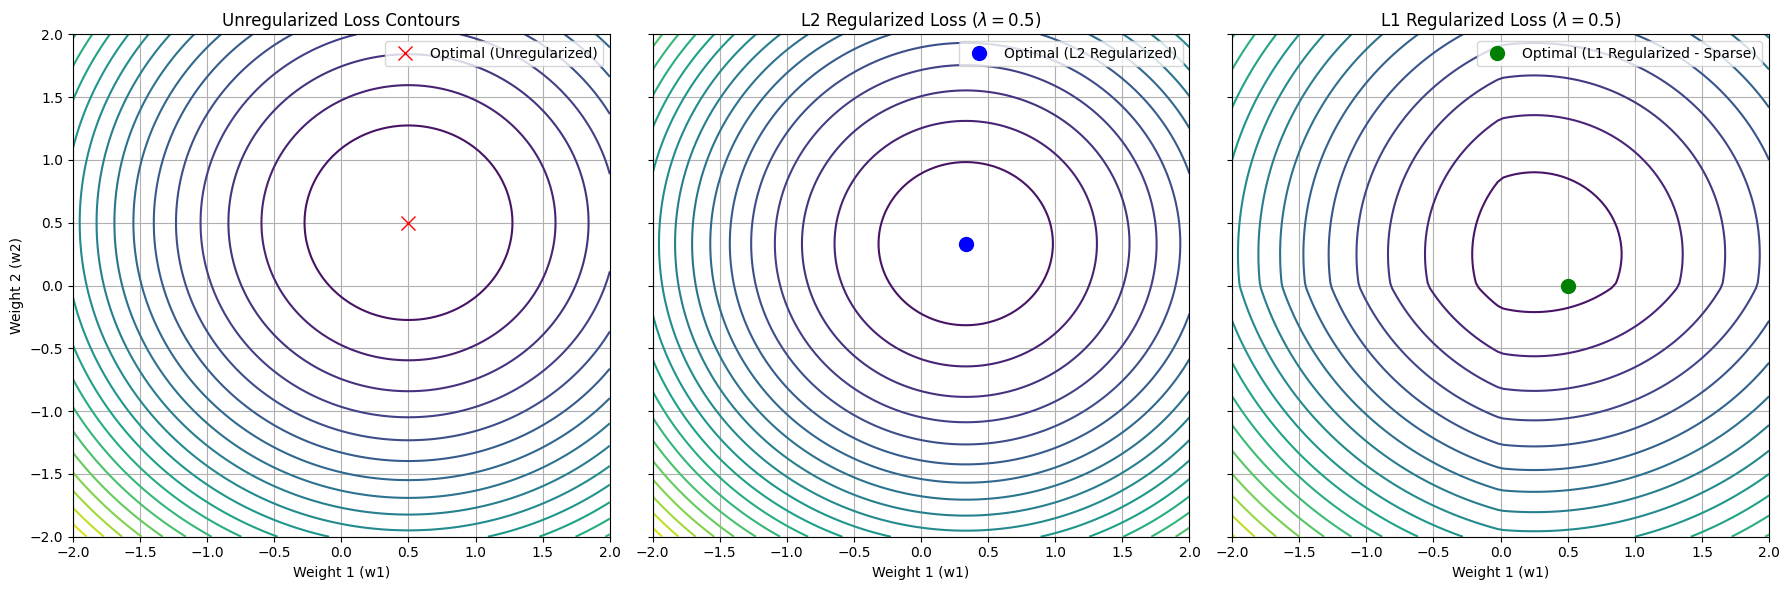

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# --- Simulate Loss Function Contour ---
# For simplicity, let's assume a quadratic loss function centered at (0,0)
# This is a generic representation, not tied to a specific dataset
def original_loss(w1, w2):
    # A simple quadratic loss, representing minimum at (0.5, 0.5) or some target (e.g., (1,1))
    # For visualization purposes, let's assume minimum is at (0.5, 0.5) for illustration
    return (w1 - 0.5)**2 + (w2 - 0.5)**2

w1_range = np.linspace(-2, 2, 100)
w2_range = np.linspace(-2, 2, 100)
W1, W2 = np.meshgrid(w1_range, w2_range)

Z_original = original_loss(W1, W2)

# --- Define Regularization Terms ---
lambda_val = 0.5 # Regularization strength

def l1_penalty(w1, w2, lambda_val):
    return lambda_val * (np.abs(w1) + np.abs(w2))

def l2_penalty(w1, w2, lambda_val):
    return lambda_val * (w1**2 + w2**2)

Z_l1_penalty = l1_penalty(W1, W2, lambda_val)
Z_l2_penalty = l2_penalty(W1, W2, lambda_val)

# --- Combine Loss and Penalties ---
Z_l1_reg = Z_original + Z_l1_penalty
Z_l2_reg = Z_original + Z_l2_penalty

# --- Plotting ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

# Plot 1: Unregularized Loss
ax = axes[0]
ax.contour(W1, W2, Z_original, levels=20, cmap='viridis')
ax.plot(0.5, 0.5, 'rx', markersize=10, label='Optimal (Unregularized)')
ax.set_title('Unregularized Loss Contours')
ax.set_xlabel('Weight 1 (w1)')
ax.set_ylabel('Weight 2 (w2)')
ax.legend()
ax.grid(True)

# Plot 2: L2 Regularization (Ridge) Contours
ax = axes[1]
ax.contour(W1, W2, Z_l2_reg, levels=20, cmap='viridis')
# For illustrative purposes, an approximate L2-regularized optimum
ax.plot(0.5 * (1 / (1 + lambda_val)), 0.5 * (1 / (1 + lambda_val)), 'bo', markersize=10, label='Optimal (L2 Regularized)')
ax.set_title(rf'L2 Regularized Loss ($\lambda={lambda_val}$)')
ax.set_xlabel('Weight 1 (w1)')
ax.grid(True)
ax.legend()

# Plot 3: L1 Regularization (Lasso) Contours
ax = axes[2]
ax.contour(W1, W2, Z_l1_reg, levels=20, cmap='viridis')
# For illustrative purposes, an approximate L1-regularized optimum
# L1 tends to push weights to zero, so an optimal point might be on an axis
ax.plot(0.5, 0, 'go', markersize=10, label='Optimal (L1 Regularized - Sparse)') # Example of sparsity
ax.set_title(rf'L1 Regularized Loss ($\lambda={lambda_val}$)')
ax.set_xlabel('Weight 1 (w1)')
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

###### Summary of Visualization

The plots above visualize the contours of the loss function in a 2D weight space, demonstrating the impact of L1 and L2 regularization compared to an unregularized loss.

*   **Unregularized Loss (Left Plot)**: Shows elliptical contours, with the optimal solution (minimum loss) typically at some non-zero values for both `w1` and `w2` (marked by 'x').

*   **L2 Regularized Loss (Middle Plot)**: The contours of the L2 regularized loss are still elliptical but are 'pulled' towards the origin (0,0). The optimal solution (blue circle) is now closer to the origin than the unregularized optimum. This illustrates L2's tendency to shrink weights towards zero without making them exactly zero. The L2 penalty term $(w_1^2 + w_2^2)$ creates circular penalty contours, and the combined loss function's minimum shifts towards values with smaller magnitudes for both weights.

*   **L1 Regularized Loss (Right Plot)**: The contours of the L1 regularized loss are distinctively 'diamond-shaped' or 'square-shaped' due to the absolute value penalty $(|w_1| + |w_2|)$. Crucially, these diamond shapes have 'corners' along the axes. When the unregularized loss contours interact with these L1 penalty contours, the minimum of the combined loss function (green circle) is very often found at one of these corners, where one or more weights are exactly zero. In our example, the optimal point is shown where `w2` is zero, demonstrating the **sparsity-inducing effect** of L1 regularization.

This visualization clearly demonstrates why L1 regularization is effective at feature selection: its unique geometry forces less important weights to become precisely zero, effectively removing the corresponding features from the model.

##### 3. L2 Regularization (Ridge Regularization)

###### Definition

**L2 Regularization**, also known as **Ridge Regularization**, is a technique that modifies the objective function by adding a penalty term that is the *sum of the squared magnitudes* of the weights. This penalty term encourages the model's weights to be small but rarely drives them to exactly zero. Instead, it shrinks them proportionally towards zero.

###### Formula

The original loss function (e.g., Mean Squared Error for regression, or Cross-Entropy for classification), denoted as $J_0(\mathbf{W}, b)$, is augmented with the L2 penalty term. The new objective function, $J(\mathbf{W}, b)$, that the optimization algorithm minimizes is:

$$ J(\mathbf{W}, b) = J_0(\mathbf{W}, b) + \lambda \sum_{j=1}^{N} w_j^2 $$

Where:

*   $J(\mathbf{W}, b)$: The new, regularized loss function.
*   $J_0(\mathbf{W}, b)$: The original (unregularized) loss function (e.g., MSE, Cross-Entropy).
*   $\mathbf{W}$: The vector of all weights in the model.
*   $b$: The bias terms (biases are typically *not* regularized in L1/L2 as they only shift the activation function and do not directly contribute to the model's complexity in the same way weights do).
*   $N$: The total number of weights in the model.
*   $w_j^2$: The square of the $j$-th weight.
*   $\lambda$ (lambda): This is the **regularization strength** (or regularization parameter), a crucial hyperparameter. It controls the trade-off between minimizing the original loss and keeping the weights small:
    *   If $\lambda = 0$, there is no regularization, and the model behaves like a standard unregularized model.
    *   If $\lambda$ is very large, the penalty for large weights becomes significant, forcing all weights to be very small and potentially leading to underfitting.
    *   An optimal $\lambda$ balances complexity reduction with fitting the training data.

The gradient of this new objective function, which is used during backpropagation, will include the derivative of the L2 penalty term. The derivative of $w_j^2$ is $2w_j$.

###### Why it's needed

L2 Regularization is a fundamental technique for improving the robustness and generalization ability of machine learning models, particularly neural networks, by addressing the problem of **overfitting**. Here's why it's crucial:

1.  **Prevents Overfitting**: This is its primary purpose. Overfitting occurs when a model learns the training data, including its noise, too well, leading to poor performance on new, unseen data. L2 regularization adds a penalty to the loss function that is proportional to the square of the magnitude of the weights. This discourages the model from assigning very large weights to any particular feature, effectively shrinking the weights towards zero. By keeping weights small, the model becomes simpler and less sensitive to small fluctuations in the input data, thus reducing its capacity to memorize noise.

2.  **Improves Generalization**: By curbing overfitting, L2 regularization helps the model to focus on the more generalizable patterns within the data. A model with smaller weights tends to be smoother and less 'jagged' in its predictions, which typically translates to better performance on data it has not encountered during training.

3.  **Stabilizes Training**: Large weights can make the model unstable, especially during optimization, leading to exploding gradients or chaotic behavior. L2 regularization helps to keep the weights within a reasonable range, contributing to more stable and faster convergence of the optimization process.

4.  **Handles Multicollinearity**: In traditional linear models, if features are highly correlated (multicollinearity), the model's weights can become very sensitive to small changes in the input data, leading to high variance. L2 regularization (Ridge Regression in linear models) can mitigate this by shrinking correlated feature weights towards each other, providing a more stable solution.

In essence, L2 regularization acts as a gentle constraint on the model's complexity, guiding it towards a solution that is less prone to overfitting and more capable of making accurate predictions on real-world data.

###### Numerical Example

Let's illustrate how L2 Regularization affects weight updates through a numerical example. We'll simplify by considering a single weight and observing how its update is modified by the L2 penalty.

Suppose we have a single weight $w$ that we are updating using Gradient Descent. The original loss function is $J_0(w)$, and its gradient with respect to $w$ is $\frac{\partial J_0}{\partial w}$.

With L2 regularization, the objective function is $J(w) = J_0(w) + \lambda w^2$.

The update rule for $w$ is:
$$ w \leftarrow w - \alpha \frac{\partial J}{\partial w} $$
Where $\alpha$ is the learning rate.

The derivative of the regularized loss function is:
$$ \frac{\partial J}{\partial w} = \frac{\partial J_0}{\partial w} + 2\lambda w $$

So the update rule becomes:
$$ w \leftarrow w - \alpha \left( \frac{\partial J_0}{\partial w} + 2\lambda w \right) $$
$$ w \leftarrow w - \alpha \frac{\partial J_0}{\partial w} - 2\alpha \lambda w $$
$$ w \leftarrow w (1 - 2\alpha \lambda) - \alpha \frac{\partial J_0}{\partial w} $$

Notice the term $(1 - 2\alpha \lambda)$ which is applied to $w$. This term directly shrinks the weight $w$ by a factor in each update, pulling it towards zero.

---

**Given Initial Values:**
*   Initial weight: $w_{\text{initial}}$
*   Learning rate: $\alpha = 0.01$
*   Regularization strength: $\lambda = 0.1$
*   Hypothetical gradient of original loss: $\frac{\partial J_0}{\partial w}$

---

**Scenario 1: Positive Weight, Positive Gradient**
*   $w_{\text{initial}} = 0.5$
*   $\frac{\partial J_0}{\partial w} = 0.8$ (meaning original loss increases if $w$ increases)

**Calculation:**
1.  **Regularization term**: $2\lambda w = 2 \cdot 0.1 \cdot 0.5 = 0.1$
2.  **Total gradient**: $\frac{\partial J}{\partial w} = 0.8 + 0.1 = 0.9$
3.  **Update $w$**: $w \leftarrow 0.5 - 0.01 \cdot 0.9 = 0.5 - 0.009 = 0.491$

**Observation**: The weight decreased by $0.009$. Without regularization, it would have decreased by $0.01 \cdot 0.8 = 0.008$. The L2 penalty pushed it slightly more towards zero.

---

**Scenario 2: Positive Weight, Negative Gradient**
*   $w_{\text{initial}} = 0.5$
*   $\frac{\partial J_0}{\partial w} = -0.3$ (meaning original loss decreases if $w$ increases)

**Calculation:**
1.  **Regularization term**: $2\lambda w = 2 \cdot 0.1 \cdot 0.5 = 0.1$
2.  **Total gradient**: $\frac{\partial J}{\partial w} = -0.3 + 0.1 = -0.2$
3.  **Update $w$**: $w \leftarrow 0.5 - 0.01 \cdot (-0.2) = 0.5 + 0.002 = 0.502$

**Observation**: The weight slightly increased. Without regularization, it would have increased by $0.01 \cdot 0.3 = 0.003$. The L2 penalty counteracted the main gradient, resulting in a smaller increase, still nudging it towards zero. The L2 penalty always tries to shrink the weight, regardless of the sign of the original gradient, but it doesn't force it to exactly zero unless the original gradient perfectly balances it out.

---

**Scenario 3: Small Weight, Small Gradient**
*   $w_{\text{initial}} = 0.05$
*   $\frac{\partial J_0}{\partial w} = -0.01$

**Calculation:**
1.  **Regularization term**: $2\lambda w = 2 \cdot 0.1 \cdot 0.05 = 0.01$
2.  **Total gradient**: $\frac{\partial J}{\partial w} = -0.01 + 0.01 = 0.0$
3.  **Update $w$**: $w \leftarrow 0.05 - 0.01 \cdot 0.0 = 0.05$

**Observation**: In this specific case, the L2 penalty perfectly balanced the gradient from the original loss, resulting in no change to the weight. If the L2 term had been slightly larger, it would have pushed the weight towards zero. This demonstrates that L2 regularization shrinks small weights towards zero, but unlike L1, it rarely makes them *exactly* zero unless the original gradient is also zero at that point.

---

This example demonstrates how the L2 penalty term adds a force that is proportional to the weight's magnitude, always pulling it towards zero. This shrinkage effect reduces the overall magnitude of the weights in the model.

###### Pros of L2 Regularization:

1.  **Effective Overfitting Prevention**: L2 regularization is highly effective at preventing overfitting by penalizing large weights, which leads to simpler and smoother models. This makes the model less sensitive to noise in the training data and improves its generalization to unseen data.
2.  **Stable Solutions**: By shrinking weights, L2 regularization helps to stabilize the model, especially when dealing with multicollinearity (highly correlated features). It distributes the impact of correlated features more evenly among them, rather than arbitrarily picking one.
3.  **Mathematically Convenient**: The L2 penalty term is differentiable everywhere, making it well-suited for gradient-based optimization methods like Gradient Descent, as it doesn't introduce the non-differentiability at zero that L1 regularization does.
4.  **Produces Smaller Weights**: While it doesn't drive weights to exactly zero, it ensures that all weights are small, which makes the model more robust and less prone to extreme fluctuations in its output for small changes in input.
5.  **Smoother Models**: By keeping weights small, L2 regularization tends to produce models that have smoother decision boundaries or regression curves, which are generally more desirable for generalization.

###### Cons of L2 Regularization:

1.  **No Feature Selection**: Unlike L1 regularization, L2 regularization does not perform automatic feature selection. It shrinks weights towards zero but rarely makes them exactly zero. This means that even irrelevant features will retain a small, non-zero weight, making the model less interpretable than an L1-regularized model when feature sparsity is desired.
2.  **All Features Remain in Model**: Because weights are only shrunk and not zeroed out, all features (even the least important ones) are retained in the model. This can be a disadvantage if computational efficiency or a reduction in the number of input features is a goal.
3.  **Hyperparameter Tuning ($\lambda$)**: The regularization strength $\lambda$ is a crucial hyperparameter that needs to be carefully tuned (e.g., using cross-validation) to find the optimal balance between bias and variance. An inappropriate $\lambda$ can lead to underfitting (too much regularization) or still allow overfitting (too little regularization).
4.  **Does Not Directly Address Sparsity**: If the underlying true model is sparse (i.e., only a few features are truly relevant), L2 regularization might not be the most appropriate choice, as it will assign small weights to all features rather than completely removing the irrelevant ones.

###### Time Complexity of L2 Regularization:

The time complexity of L2 Regularization refers to the additional computational cost it introduces to the overall neural network training process, primarily during the backpropagation step when gradients are calculated and parameters are updated.

For each update step (typically per mini-batch):

1.  **Gradient Calculation of Original Loss**: This is the dominant cost and involves a forward pass and a backward pass (backpropagation) of the unregularized loss function. Its complexity is $O(M \times P)$, where $M$ is the mini-batch size and $P$ is the total number of weights (parameters) in the network.

2.  **Gradient Calculation of L2 Penalty Term**: For each weight $w_j$, the derivative of $w_j^2$ is $2w_j$. This involves a simple multiplication for each weight. For $P$ weights, this operation is $O(P)$. This is very efficient.

3.  **Parameter Update**: The gradients of the L2 penalty are added to the gradients of the original loss function, and then the parameters are updated using the learning rate. This is an $O(P)$ operation.

**Overall Time Complexity per Update**: The added complexity from the L2 penalty term is proportional to the number of weights, $O(P)$. Since this is typically much smaller than or at most equal to the $O(M \times P)$ complexity of calculating the gradients for the original loss, the overall time complexity per update step remains approximately $O(M \times P)$.

**Total Training Time Complexity**: It's roughly $O(\text{Epochs} \times \text{Number of mini-batches} \times M \times P)$, which simplifies to $O(\text{Epochs} \times \text{Total Samples} \times P)$.

In summary, L2 Regularization adds a minimal computational overhead ($O(P)$ operations) per update step compared to the already existing cost of gradient calculation for the original loss function. Its primary impact is on **weight shrinkage and model generalization** rather than significantly altering the fundamental time complexity of the training process itself.

###### Visualization

Let's visualize the effect of L2 Regularization on the weight space, comparing it with L1 Regularization and a model without regularization. This will highlight how the L2 penalty promotes shrinkage by pulling weights towards zero.

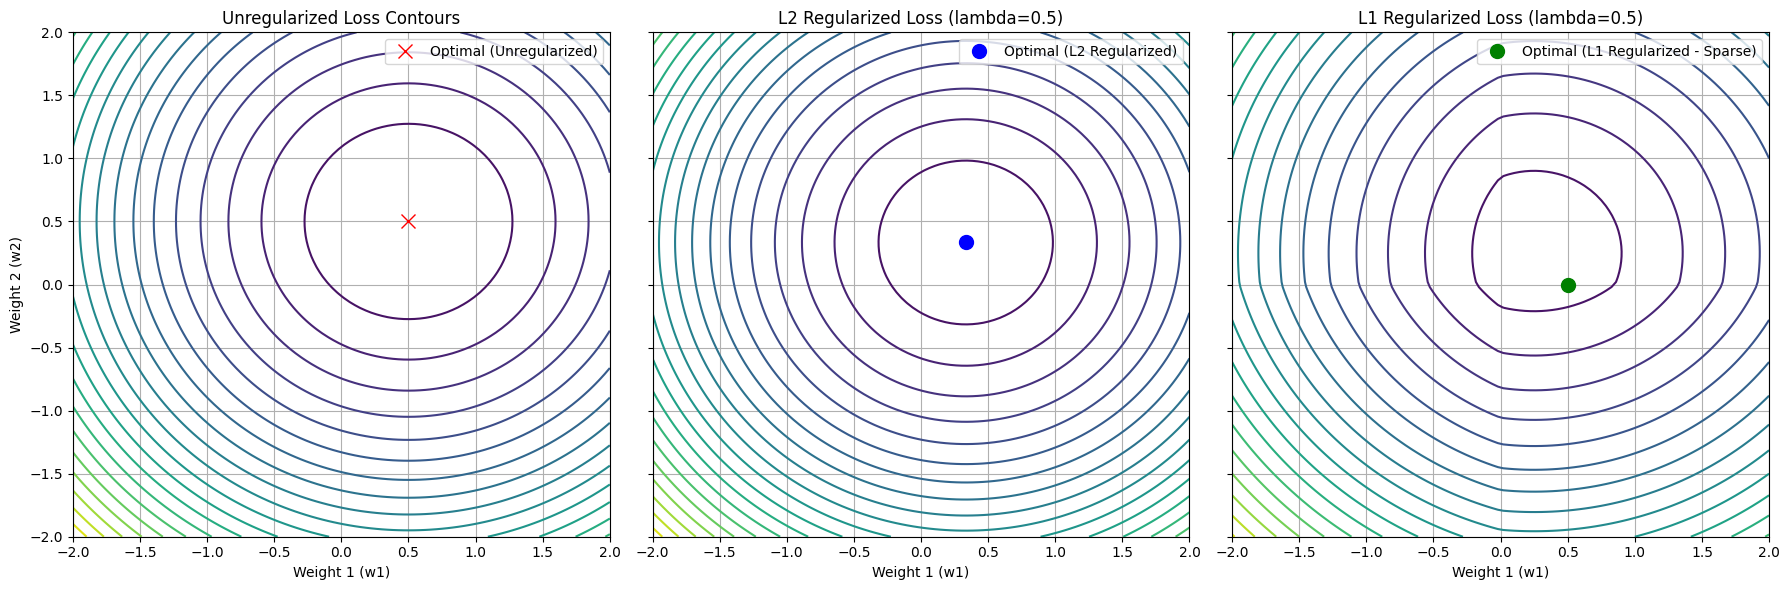

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# --- Simulate Loss Function Contour ---
# For simplicity, let's assume a quadratic loss function centered at (0,0)
# This is a generic representation, not tied to a specific dataset
def original_loss(w1, w2):
    # A simple quadratic loss, representing minimum at (0.5, 0.5) for illustration
    return (w1 - 0.5)**2 + (w2 - 0.5)**2

w1_range = np.linspace(-2, 2, 100)
w2_range = np.linspace(-2, 2, 100)
W1, W2 = np.meshgrid(w1_range, w2_range)

Z_original = original_loss(W1, W2)

# --- Define Regularization Terms ---
lambda_val = 0.5 # Regularization strength

def l1_penalty(w1, w2, lambda_val):
    return lambda_val * (np.abs(w1) + np.abs(w2))

def l2_penalty(w1, w2, lambda_val):
    return lambda_val * (w1**2 + w2**2)

Z_l1_penalty = l1_penalty(W1, W2, lambda_val)
Z_l2_penalty = l2_penalty(W1, W2, lambda_val)

# --- Combine Loss and Penalties ---
Z_l1_reg = Z_original + Z_l1_penalty
Z_l2_reg = Z_original + Z_l2_penalty

# --- Plotting ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

# Plot 1: Unregularized Loss
ax = axes[0]
ax.contour(W1, W2, Z_original, levels=20, cmap='viridis')
ax.plot(0.5, 0.5, 'rx', markersize=10, label='Optimal (Unregularized)')
ax.set_title('Unregularized Loss Contours')
ax.set_xlabel('Weight 1 (w1)')
ax.set_ylabel('Weight 2 (w2)')
ax.legend()
ax.grid(True)

# Plot 2: L2 Regularization (Ridge) Contours
ax = axes[1]
ax.contour(W1, W2, Z_l2_reg, levels=20, cmap='viridis')
# For illustrative purposes, an approximate L2-regularized optimum
ax.plot(0.5 * (1 / (1 + lambda_val)), 0.5 * (1 / (1 + lambda_val)), 'bo', markersize=10, label='Optimal (L2 Regularized)')
ax.set_title(f'L2 Regularized Loss (lambda={lambda_val})') # Modified title
ax.set_xlabel('Weight 1 (w1)')
ax.grid(True)
ax.legend()

# Plot 3: L1 Regularization (Lasso) Contours
ax = axes[2]
ax.contour(W1, W2, Z_l1_reg, levels=20, cmap='viridis')
# For illustrative purposes, an approximate L1-regularized optimum
# L1 tends to push weights to zero, so an optimal point might be on an axis
ax.plot(0.5, 0, 'go', markersize=10, label='Optimal (L1 Regularized - Sparse)') # Example of sparsity
ax.set_title(f'L1 Regularized Loss (lambda={lambda_val})') # Modified title
ax.set_xlabel('Weight 1 (w1)')
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

###### Summary of Visualization

The plots above visualize the contours of the loss function in a 2D weight space, demonstrating the impact of L1 and L2 regularization compared to an unregularized loss.

*   **Unregularized Loss (Left Plot)**: Shows elliptical contours, with the optimal solution (minimum loss) typically at some non-zero values for both `w1` and `w2` (marked by 'x').

*   **L2 Regularized Loss (Middle Plot)**: The contours of the L2 regularized loss are still elliptical but are 'pulled' towards the origin (0,0). The optimal solution (blue circle) is now closer to the origin than the unregularized optimum. This illustrates L2's tendency to shrink weights towards zero without making them exactly zero. The L2 penalty term $(w_1^2 + w_2^2)$ creates circular penalty contours, and the combined loss function's minimum shifts towards values with smaller magnitudes for both weights.

*   **L1 Regularized Loss (Right Plot)**: The contours of the L1 regularized loss are distinctively 'diamond-shaped' or 'square-shaped' due to the absolute value penalty $(|w_1| + |w_2|)$. Crucially, these diamond shapes have 'corners' along the axes. When the unregularized loss contours interact with these L1 penalty contours, the minimum of the combined loss function (green circle) is very often found at one of these corners, where one or more weights are exactly zero. This demonstrates the **sparsity-inducing effect** of L1 regularization.

This visualization clearly demonstrates why L2 regularization shrinks weights without making them exactly zero, in contrast to L1 regularization which promotes sparsity by driving weights to exactly zero.

Now that we've thoroughly covered L2 Regularization, let's move on to the next type of regularization: **Early Stopping**.

##### 4. Early Stopping

###### Definition

Early Stopping is a form of regularization used to prevent overfitting when training a model iteratively, such as with gradient descent. It involves monitoring the model's performance on a separate **validation dataset** during the training process. Training is halted as soon as the performance on the validation set begins to degrade, even if the performance on the training set is still improving. The idea is that beyond a certain point, the model starts to memorize the training data rather than learning generalizable patterns, leading to worse performance on unseen data. By stopping early, we aim to capture the model at its peak generalization capability.

###### Why it's needed

Early Stopping is a crucial regularization technique needed to combat **overfitting**, a common and detrimental problem in machine learning, especially when training complex models like neural networks. Here's why it's fundamentally important:

1.  **Directly Prevents Overfitting**: As a model trains, its performance on the training data continuously improves. However, beyond a certain point, the model starts to learn the noise and specific quirks of the training data rather than the underlying generalizable patterns. This causes its performance on unseen data (measured by a validation set) to worsen. Early stopping halts the training process at the optimal point before this degradation begins, preventing the model from becoming overfit.

2.  **Optimizes Generalization Performance**: The primary goal of any machine learning model is to generalize well to new, unseen data. Early stopping helps achieve this by selecting the model state that has the best performance on the validation set, which is a proxy for unseen data. This ensures that we capture the model when it is most capable of making accurate predictions in real-world scenarios.

3.  **Reduces Training Time and Computational Cost**: Without early stopping, models might be trained for an unnecessarily large number of epochs, long after their performance on validation data has peaked. By stopping training once validation performance plateaus or degrades, early stopping saves significant computational resources (CPU/GPU cycles) and reduces the overall training time, making the learning process more efficient.

4.  **Acts as an Implicit Regularizer**: While not explicitly adding a penalty term to the loss function, early stopping implicitly regularizes the model. By preventing the model from training too long, it keeps the weights from growing too large and becoming overly specialized to the training data. This promotes simpler models that are less prone to memorizing noise.

5.  **Simpler Hyperparameter Tuning**: In some cases, early stopping can reduce the complexity of hyperparameter tuning. Instead of having to find the exact number of epochs to train for, you can simply set a large maximum number of epochs and let early stopping determine the optimal stopping point.

In essence, Early Stopping acts as a vigilant monitor, ensuring that the model learns efficiently and effectively without succumbing to the pitfalls of overfitting, thereby securing its ability to perform well on real-world data.

###### Mechanism

Early Stopping works by monitoring the model's performance on a separate validation dataset during the training process. Instead of simply training for a fixed number of epochs or until the training loss converges, it introduces a criterion to stop training when the model's ability to generalize starts to degrade.

Here's a step-by-step breakdown of how it typically operates:

1.  **Data Split**: The dataset is divided into three parts:
    *   **Training Set**: Used to train the model (update weights and biases).
    *   **Validation Set**: Used to monitor the model's performance during training and decide when to stop. The model *does not* learn from this set; it's only used for evaluation.
    *   **Test Set**: Used for a final, unbiased evaluation of the model's performance after training is complete.

2.  **Training Process**: The model is trained iteratively (e.g., using mini-batch gradient descent) on the training set. After each epoch (or a set number of steps), the model's performance (e.g., loss or accuracy) is evaluated on both the training set and the validation set.

3.  **Performance Monitoring**: The key is to track the performance on the validation set. Initially, as the model learns, its performance will improve on both the training and validation sets. However, at some point, the model will start to overfit the training data. When this happens, the performance on the training set will likely continue to improve (or plateau), but the performance on the **validation set will start to worsen** (e.g., validation loss increases, or validation accuracy decreases).

4.  **Stopping Criterion**: Early Stopping introduces a 'patience' hyperparameter. This defines how many epochs the model should continue training after the validation performance has stopped improving (or has started to get worse). If the validation performance does not improve for `patience` consecutive epochs, the training process is halted.

5.  **Restoring Best Model**: Once training is stopped, the model parameters (weights and biases) are typically rolled back to the state where the model achieved its *best performance on the validation set*. This ensures that the final model is the one that generalized best, rather than the one at the very end of training, which might already be slightly overfit.

###### Intuition

Imagine you're trying to learn a new skill, like playing a complex musical instrument. Your goal is not just to play the pieces you've practiced (training data) perfectly, but to be able to play new, unseen pieces (unseen data) well.

**The Learning Process:**

1.  **Initial Learning Phase**: When you first start practicing, both your ability to play the practiced pieces and your ability to adapt to new pieces improve rapidly. You're learning fundamental techniques, scales, and music theory. This is like the early stages of model training where both training and validation performance improve.

2.  **Peak Performance for Generalization**: At some point, you reach a peak where your understanding of the instrument's principles is excellent, and you can comfortably tackle new pieces. This is the sweet spot for generalization—you've learned the general rules without memorizing specific pieces too rigidly. This corresponds to the model's best performance on the validation set.

3.  **Over-Specialization / Memorization (Overfitting)**: What happens if you continue to practice only the same few pieces for too long? You might get incredibly fast and flawless at *those specific pieces*, but your ability to learn *new pieces* might actually start to decline. You've memorized the exact fingerings and nuances for the practiced pieces, but you've stopped improving your general adaptability and understanding. You're no longer truly learning; you're just memorizing. This is like the model starting to overfit: training performance might still get better, but validation performance (your ability to play new pieces) starts to get worse.

**Early Stopping in this Analogy:**

Early Stopping is like having a wise teacher who observes your practice. They tell you to stop practicing a particular set of pieces *before* you become over-specialized. They know that even if you can play those specific pieces even faster, it's not actually helping you become a better, more versatile musician overall. They would tell you to stop at the point where you were best at playing new, unpracticed pieces, and maybe move on to a different set of exercises to continue improving your general skill.

So, Early Stopping prevents the model from getting too good at the training data at the expense of its performance on unseen data. It steps in when the model starts to 'memorize' instead of 'learn,' thus preserving its ability to generalize.

###### Math

Mathematically, Early Stopping doesn't involve a complex formula or an explicit penalty term added to the loss function. Instead, its 'mathematics' lies in the **monitoring and decision-making process** based on the loss (or other performance metrics) evaluated on the validation set.

Let:
*   $J_{train}(W, b)$ be the loss function evaluated on the **training set**.
*   $J_{val}(W, b)$ be the loss function (or performance metric like accuracy) evaluated on the **validation set**.
*   $W, b$ represent the model's weights and biases.
*   $E$ be the current epoch number.
*   $E_{best}$ be the epoch number at which the model achieved its best performance on the validation set.
*   $	ext{patience}$ be a predefined hyperparameter.

The training process iteratively updates the model parameters $(W, b)$ using an optimization algorithm (e.g., Gradient Descent) to minimize $J_{train}(W, b)$.

###### The Monitoring Logic

At the end of each epoch $E$:

1.  **Evaluate Validation Performance**: Calculate $J_{val}(W, b)$.

2.  **Check for Improvement**: Compare the current $J_{val}(W, b)$ with the best $J_{val}$ observed so far ($	ext{best_val_score}$). A lower validation loss (or higher validation accuracy) is considered an improvement.

    *   If $J_{val}(W, b)$ is better than $	ext{best_val_score}$:
        *   Update $	ext{best_val_score} = J_{val}(W, b)$.
        *   Store the current model parameters $(W, b)$.
        *   Reset the counter for epochs without improvement: $	ext{current_patience_count} = 0$.

    *   If $J_{val}(W, b)$ is not better than $	ext{best_val_score}$:
        *   Increment the counter: $	ext{current_patience_count} = 	ext{current_patience_count} + 1$.

3.  **Stopping Condition**: If $	ext{current_patience_count} 	ext{ reaches } 	ext{patience}$:

    *   Stop training.
    *   Restore the model parameters saved at $E_{best}$ (when $	ext{best_val_score}$ was achieved) as the final model.

###### Implicit Regularization

While not explicit in the loss function, the mathematical effect of Early Stopping is that it limits the magnitude of the weights. As training progresses, weights tend to grow larger to fit the training data more closely. By stopping training before weights become excessively large, Early Stopping implicitly keeps the model's complexity in check, thus acting as a form of regularization.

The core of Early Stopping's 'math' is this conditional logic and comparison of performance metrics over time, rather than a direct alteration of the optimization calculus.

###### Numerical Example

Let's consider a hypothetical training run for a neural network and observe how Early Stopping would function. We'll track the training loss and validation loss over several epochs.

**Given:**
*   **Performance Metric**: Validation Loss (we want to minimize this).
*   **Initial `best_val_loss`**: A large value (e.g., `infinity`).
*   **`patience`**: `3` epochs (meaning we stop if validation loss doesn't improve for 3 consecutive epochs).
*   **`current_patience_count`**: `0`
*   **Saved Model**: Initially `None` (no best model saved yet).

---

###### Training Log

**Epoch 1:**
*   **Training Loss**: 0.50
*   **Validation Loss**: 0.60
*   **Decision**: `0.60 < infinity`. Validation loss improved!
    *   `best_val_loss` = 0.60
    *   Save current model parameters (Epoch 1 model).
    *   `current_patience_count` = 0

**Epoch 2:**
*   **Training Loss**: 0.45
*   **Validation Loss**: 0.55
*   **Decision**: `0.55 < 0.60`. Validation loss improved!
    *   `best_val_loss` = 0.55
    *   Save current model parameters (Epoch 2 model).
    *   `current_patience_count` = 0

**Epoch 3:**
*   **Training Loss**: 0.40
*   **Validation Loss**: 0.52
*   **Decision**: `0.52 < 0.55`. Validation loss improved!
    *   `best_val_loss` = 0.52
    *   Save current model parameters (Epoch 3 model).
    *   `current_patience_count` = 0

**Epoch 4:**
*   **Training Loss**: 0.35
*   **Validation Loss**: 0.53
*   **Decision**: `0.53 > 0.52`. Validation loss did NOT improve.
    *   `best_val_loss` remains 0.52.
    *   Do NOT save current model parameters.
    *   `current_patience_count` = 1

**Epoch 5:**
*   **Training Loss**: 0.30
*   **Validation Loss**: 0.56
*   **Decision**: `0.56 > 0.52`. Validation loss did NOT improve.
    *   `best_val_loss` remains 0.52.
    *   Do NOT save current model parameters.
    *   `current_patience_count` = 2

**Epoch 6:**
*   **Training Loss**: 0.25
*   **Validation Loss**: 0.58
*   **Decision**: `0.58 > 0.52`. Validation loss did NOT improve.
    *   `best_val_loss` remains 0.52.
    *   Do NOT save current model parameters.
    *   `current_patience_count` = 3

---

###### Result:

Since `current_patience_count` reached `3` (our `patience` value), the training process **stops at Epoch 6**.

The final model chosen would be the one whose parameters were saved at **Epoch 3**, as this was the epoch where the `best_val_loss` of `0.52` was achieved.

This example clearly shows how Early Stopping prevents the model from continuing to train and overfit (as indicated by the rising validation loss after Epoch 3), ensuring that the model with the best generalization capability is selected.

###### Visualization

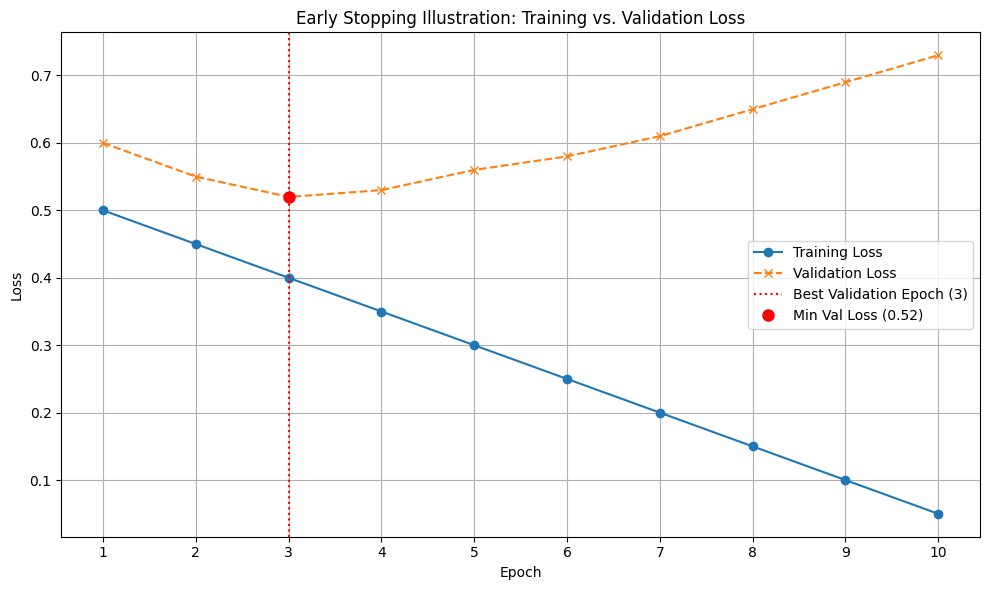

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Simulate training and validation loss curves
epochs = np.arange(1, 11) # 10 epochs

# Training loss (monotonically decreasing)
training_loss = np.array([0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20, 0.15, 0.10, 0.05])

# Validation loss (decreases then increases, simulating overfitting)
# Peak generalization at epoch 3 (loss 0.52)
validation_loss = np.array([0.60, 0.55, 0.52, 0.53, 0.56, 0.58, 0.61, 0.65, 0.69, 0.73])

# Find the epoch with the minimum validation loss
best_epoch = np.argmin(validation_loss) + 1 # +1 because epochs are 1-indexed
best_val_loss = validation_loss[best_epoch - 1]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(epochs, training_loss, label='Training Loss', marker='o', linestyle='-')
plt.plot(epochs, validation_loss, label='Validation Loss', marker='x', linestyle='--')

# Mark the point of best validation loss
plt.axvline(x=best_epoch, color='r', linestyle=':', label=f'Best Validation Epoch ({best_epoch})')
plt.plot(best_epoch, best_val_loss, 'ro', markersize=8, label=f'Min Val Loss ({best_val_loss:.2f})')

plt.title('Early Stopping Illustration: Training vs. Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs) # Ensure all epochs are marked on the x-axis
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

###### Summary of Visualization

The plot above visually represents the core concept of Early Stopping.

*   The **blue line (Training Loss)** shows a continuous decrease, indicating that the model is consistently getting better at fitting the training data.

*   The **orange dashed line (Validation Loss)** initially decreases along with the training loss, which is a sign of effective learning and generalization. However, after **Epoch 3**, the validation loss starts to increase while the training loss continues to fall. This divergence is the hallmark of **overfitting**: the model begins to memorize the training data and its noise, losing its ability to generalize to unseen data.

*   The **red dotted line** and the **red circle** pinpoint **Epoch 3** as the optimal stopping point, where the validation loss was at its minimum (`0.52`). According to the Early Stopping mechanism (with `patience=3` as in our numerical example), training would likely be halted around Epoch 6 (after 3 consecutive epochs without validation improvement from Epoch 3's best). The model parameters saved at Epoch 3 would then be restored as the final model.

This visualization clearly demonstrates how Early Stopping helps us choose a model that performs well on unseen data, preventing us from using a model that has overfit the training data, even if its training performance looks superficially better.

###### Pros of Early Stopping:

1.  **Prevents Overfitting**: The most direct and significant advantage. Early Stopping ensures the model doesn't continue training past the point where it starts to memorize the training data, thus preventing a decline in performance on unseen data.

2.  **Optimizes Generalization**: By stopping at the point of optimal validation performance, it helps in selecting a model state that generalizes best to new, unobserved examples, which is the ultimate goal of machine learning.

3.  **Reduces Training Time and Computational Cost**: Training is halted once the model's generalization performance plateaus or degrades. This avoids unnecessary computation and saves time and resources that would otherwise be spent on epochs that don't contribute to a better model.

4.  **Implicit Regularization**: It acts as an implicit form of regularization. By limiting the training duration, it keeps the model's complexity in check and prevents weights from growing excessively large, promoting simpler models.

5.  **Simpler Hyperparameter Tuning**: For the number of epochs, instead of having to precisely guess the optimal number, one can set a reasonably large maximum and let Early Stopping determine the ideal stopping point based on empirical performance.

###### Cons of Early Stopping:

1.  **Requires a Validation Set**: Early Stopping necessitates a separate validation set, which means less data is available for training the model. If the dataset is small, splitting it into training, validation, and test sets can be problematic, as the validation set might not be representative enough.

2.  **Determining 'Patience'**: The `patience` hyperparameter (how many epochs to wait after validation performance degrades) needs to be carefully tuned. A value that is too small might stop training prematurely (underfitting), while a value that is too large might still allow some overfitting to occur.

3.  **Potential for Suboptimal Training Loss**: The training process is halted based on validation performance, not training performance. This often means that when training stops, the training loss might still be significantly higher than if training continued, which can be counter-intuitive for some. However, the focus is on generalization, not just fitting the training data perfectly.

4.  **Validation Set Representativeness**: The effectiveness of Early Stopping heavily relies on the validation set being a good representation of unseen data. If the validation set is biased or too small, the stopping decision might be suboptimal.

5.  **Not Always Optimal for Test Set Performance**: While it optimizes for the validation set, there's no guarantee that the model state chosen by Early Stopping will be the absolute best performing on the entirely unseen test set, though it's usually a very good approximation.

6.  **Oscillating Validation Loss**: If the validation loss is very noisy and oscillates, it can be difficult to define a clear point of

##### 5. Batch Normalization

###### Definition

**Batch Normalization** is a technique used to standardize the inputs to a layer in a neural network. It normalizes the activations of the previous layer (or inputs to the current layer) by re-centering and re-scaling them such that they have a mean of zero and a standard deviation of one. This normalization is typically performed for each *mini-batch* during training.

The primary goal of Batch Normalization is to address the problem of **Internal Covariate Shift**, which refers to the change in the distribution of network activations due to the change in network parameters during training. By stabilizing the input distribution to each layer, Batch Normalization helps to make the training process more stable, allows for higher learning rates, reduces the dependence on weight initialization, and acts as a form of regularization, thereby preventing overfitting.

###### Why it's needed

Batch Normalization was introduced primarily to address several challenges encountered during the training of deep neural networks, especially the issue of **Internal Covariate Shift** and its related problems:

1.  **Combating Internal Covariate Shift**: As training progresses, the parameters (weights and biases) of previous layers change. This means that the input distribution to any given layer continuously shifts, which is known as Internal Covariate Shift. A layer then has to constantly adapt to new input distributions, making the training process unstable and slow. Batch Normalization re-centers and re-scales the inputs to a layer, stabilizing their distribution.

2.  **Enabling Higher Learning Rates**: Traditional neural networks often require small learning rates to prevent divergence, particularly when the network is deep. Batch Normalization regularizes the distributions of layer inputs, making the loss landscape smoother. This allows for the use of much higher learning rates, which significantly speeds up the training process without the risk of exploding gradients.

3.  **Reducing Dependence on Weight Initialization**: Deep networks are notoriously sensitive to weight initialization schemes. Poor initialization can lead to vanishing or exploding gradients, or make the network get stuck in suboptimal local minima. By normalizing activations, Batch Normalization reduces this sensitivity, making the network more robust to a wider range of initialization strategies.

4.  **Regularization Effect**: Batch Normalization adds a slight amount of noise to the activations (due to the mini-batch statistics). This acts as a form of regularization, reducing the need for other regularization techniques like Dropout, and helping to prevent overfitting.

5.  **Mitigating Vanishing/Exploding Gradients**: By keeping the input activations to each layer in a normalized range (mean close to 0, standard deviation close to 1), Batch Normalization helps to prevent gradients from becoming extremely small (vanishing) or extremely large (exploding) during backpropagation. This allows deeper networks to be trained more effectively.

In essence, Batch Normalization stabilizes and accelerates the training of deep neural networks by normalizing layer inputs, allowing for more aggressive learning parameters and leading to more robust and faster convergence.

###### Mechanism

Batch Normalization operates by performing a series of steps on the inputs to a layer during training, typically applied right before the activation function. This process is done for each *mini-batch* of data, ensuring that the statistics (mean and variance) of the inputs remain stable.

Here's a breakdown of the mechanism:

1.  **Calculate Mini-Batch Mean ($\mu_B$)**: For each mini-batch $B$ and for each dimension (feature) of the input to the layer, Batch Norm calculates the mean of the inputs. This effectively re-centers the data.

    *   Imagine you have inputs for a layer $x_1, x_2, \dots, x_m$ for a mini-batch of size $m$. The mean is simply the average of these $m$ values.

2.  **Calculate Mini-Batch Variance ($\sigma_B^2$)**: Similarly, Batch Norm calculates the variance of the inputs for each dimension within the mini-batch. This measures the spread of the data.

    *   This is the average of the squared differences from the mean for the $m$ values.

3.  **Normalize (Standardize) Inputs**: Using the calculated mini-batch mean and variance, each input $x_i$ in the mini-batch is normalized (standardized). This results in a distribution with a mean of zero and a standard deviation of one.

    *   $\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$, where $\epsilon$ is a small constant added for numerical stability (to prevent division by zero).

4.  **Scale and Shift (Learnable Parameters $\gamma$ and $\beta$)**: After normalization, the values $\hat{x}_i$ are transformed using two learnable parameters: a scaling factor $\gamma$ (gamma) and a shifting factor $\beta$ (beta). These parameters allow the network to learn the optimal scale and shift for the normalized inputs, giving the model the flexibility to restore the original representation if it's beneficial.

    *   $y_i = \gamma \hat{x}_i + \beta$
    *   $\gamma$ and $\beta$ are learned during training via backpropagation, just like other weights and biases. They enable the network to adjust the normalized activations to a more appropriate range if that helps the learning process.

5.  **During Inference/Testing**: During inference, the mean and variance are no longer computed per mini-batch (as a single sample might be processed, or mini-batch statistics would be noisy). Instead, **global (population) mean and variance estimates** are used. These estimates are typically calculated as exponentially weighted moving averages of the mini-batch means and variances observed during training. These population statistics are then used for normalization, followed by the learned $\gamma$ and $\beta$ parameters.

###### Formula

Batch Normalization transforms the inputs to a layer, $\mathbf{x}$, for each mini-batch during training. Let $m$ be the size of the mini-batch.

For each dimension (feature) $j$ of the input $\mathbf{x}$ to the layer:

1.  **Calculate Mini-Batch Mean ($\mu_B$)**:

    $$\mu_B^{(j)} = \frac{1}{m} \sum_{i=1}^{m} x_i^{(j)}$$

2.  **Calculate Mini-Batch Variance ($\sigma_B^2$)**:

    $$\sigma_B^{2(j)} = \frac{1}{m} \sum_{i=1}^{m} (x_i^{(j)} - \mu_B^{(j)})^2$$

3.  **Normalize (Standardize) Inputs**:

    $$\hat{x}_i^{(j)} = \frac{x_i^{(j)} - \mu_B^{(j)}}{\sqrt{\sigma_B^{2(j)} + \epsilon}}$$

    Where $\epsilon$ is a small constant (e.g., $10^{-5}$) added for numerical stability to prevent division by zero.

4.  **Scale and Shift (Learnable Parameters)**:

    $$y_i^{(j)} = \gamma^{(j)} \hat{x}_i^{(j)} + \beta^{(j)}$$

    Where:
    *   $y_i^{(j)}$: The Batch Normalized output for the $i$-th sample and $j$-th dimension.
    *   $\gamma^{(j)}$: A learnable scaling parameter for the $j$-th dimension (initialized to 1).
    *   $\beta^{(j)}$: A learnable shifting parameter for the $j$-th dimension (initialized to 0).

During training, these $\gamma$ and $\beta$ parameters are learned via backpropagation along with the other network weights.

---

**During Inference/Testing**:

Instead of mini-batch statistics, Batch Normalization uses **global (population) mean and variance estimates** collected during training. These are typically calculated as exponentially weighted moving averages of the mini-batch means and variances seen during training.

Let $\mu_{\text{pop}}^{(j)}$ and $\sigma_{\text{pop}}^{2(j)}$ be the estimated population mean and variance for the $j$-th dimension.

The normalized output for a single test sample $x_{\text{test}}^{(j)}$ is:

$$\hat{x}_{\text{test}}^{(j)} = \frac{x_{\text{test}}^{(j)} - \mu_{\text{pop}}^{(j)}}{\sqrt{\sigma_{\text{pop}}^{2(j)} + \epsilon}}$$

And the scaled/shifted output is:

$$y_{\text{test}}^{(j)} = \gamma^{(j)} \hat{x}_{\text{test}}^{(j)} + \beta^{(j)}$$

This ensures that the output is deterministic and consistent during inference.

###### Numerical Example

Let's apply the Batch Normalization steps to a small mini-batch of inputs for a single feature (dimension).

Suppose we have a layer that receives inputs for a mini-batch of 3 samples, and we are focusing on a single feature (dimension).

**Given:**
*   **Mini-Batch Inputs ($\mathbf{x}$)** for a single feature: `[1.0, 2.0, 3.0]`
*   **Small constant for numerical stability ($\epsilon$)**: `1e-5`
*   **Learnable Scaling Parameter ($\gamma$)**: `1.5`
*   **Learnable Shifting Parameter ($\beta$)**: `0.5`

---

#### Step-by-Step Calculation (Training Phase):

1.  **Calculate Mini-Batch Mean ($\mu_B$)**:
    $$\mu_B = \frac{1}{m} \sum_{i=1}^{m} x_i$$
    Here, $m=3$.
    $$\mu_B = \frac{1.0 + 2.0 + 3.0}{3} = \frac{6.0}{3} = 2.0$$

2.  **Calculate Mini-Batch Variance ($\sigma_B^2$)**:
    $$\sigma_B^2 = \frac{1}{m} \sum_{i=1}^{m} (x_i - \mu_B)^2$$
    $$\sigma_B^2 = \frac{(1.0 - 2.0)^2 + (2.0 - 2.0)^2 + (3.0 - 2.0)^2}{3}$$
    $$\sigma_B^2 = \frac{(-1.0)^2 + (0.0)^2 + (1.0)^2}{3} = \frac{1.0 + 0.0 + 1.0}{3} = \frac{2.0}{3} \approx 0.6667$$

3. **Normalize (Standardize) Inputs ($\hat{x}_i$)**:

$$
\hat{x}_i=\frac{x_i-\mu_B}{\sqrt{\sigma_B^2+\epsilon}}
$$

* For $x_1 = 1.0$:

$$
\hat{x}_1
=
\frac{1.0-2.0}{\sqrt{0.6667+10^{-5}}}
=
\frac{-1.0}{\sqrt{0.66671}}
\approx
\frac{-1.0}{0.8165}
\approx
-1.2247
$$

* For $x_2 = 2.0$:

$$
\hat{x}_2
=
\frac{2.0-2.0}{\sqrt{0.6667+10^{-5}}}
=
\frac{0.0}{\sqrt{0.66671}}
=
0.0
$$

* For $x_3 = 3.0$:

$$
\hat{x}_3
=
\frac{3.0-2.0}{\sqrt{0.6667+10^{-5}}}
=
\frac{1.0}{\sqrt{0.66671}}
\approx
\frac{1.0}{0.8165}
\approx
1.2247
$$

The normalized inputs are approximately **[-1.2247, 0.0, 1.2247]**. (Notice their mean is 0 and standard deviation is 1.)

4. **Scale and Shift ($y_i$)**:

$$
y_i=\gamma\hat{x}_i+\beta
$$

* For $\hat{x}_1=-1.2247$:

$$
y_1
=
1.5\times(-1.2247)+0.5
=
-1.83705+0.5
=
-1.33705
$$

* For $\hat{x}_2=0.0$:

$$
y_2
=
1.5\times0.0+0.5
=
0.0+0.5
=
0.5
$$

* For $\hat{x}_3=1.2247$:

$$
y_3
=
1.5\times1.2247+0.5
=
1.83705+0.5
=
2.33705
$$
---

#### Result:
The Batch Normalized outputs for this mini-batch, for this feature, are approximately `[-1.33705, 0.5, 2.33705]`.

---

**During Inference (using population statistics)**:

Now, let's assume that during training, the estimated population statistics for this feature converged to:
*   **Population Mean ($\mu_{\text{pop}}$)**: `2.0`
*   **Population Variance ($\sigma_{\text{pop}}^2$)**: `0.6667`

And we want to normalize a single new test sample:

$$
x_{\text{test}}=1.5
$$

1. **Normalize Test Input ($\hat{x}_{\text{test}}$)**:

$$
\hat{x}_{\text{test}}
=
\frac{x_{\text{test}}-\mu_{\text{pop}}}
{\sqrt{\sigma_{\text{pop}}^2+\epsilon}}
$$

$$
\hat{x}_{\text{test}}
=
\frac{1.5-2.0}
{\sqrt{0.6667+10^{-5}}}
=
\frac{-0.5}
{\sqrt{0.66671}}
\approx
\frac{-0.5}{0.8165}
\approx
-0.6124
$$

2. **Scale and Shift ($y_{\text{test}}$)**:

$$
y_{\text{test}}
=
\gamma \hat{x}_{\text{test}}
+
\beta
$$

$$
y_{\text{test}}
=
1.5\times(-0.6124)
+
0.5
=
-0.9186
+
0.5
=
-0.4186
$$

This demonstrates how Batch Normalization transforms inputs during both training and inference, stabilizing the distributions and making the training process more robust.

###### Pros of Batch Normalization:

1.  **Reduces Internal Covariate Shift**: By normalizing the inputs to each layer, Batch Normalization stabilizes the distribution of activations. This prevents the distribution from shifting significantly during training, making the learning process more stable and predictable. This is the primary benefit.

2.  **Allows for Higher Learning Rates**: The stabilized input distributions enable the use of much higher learning rates without the risk of exploding gradients or divergence. Higher learning rates can significantly accelerate the training process.

3.  **Reduces Dependence on Weight Initialization**: Deep neural networks are often sensitive to the initial values of their weights. Batch Normalization makes networks more robust to poor initialization schemes, as it re-centers and re-scales activations regardless of their initial values, making training more reliable.

4.  **Acts as a Regularizer**: Batch Normalization adds a slight amount of noise to the network's activations (due to the mini-batch statistics varying). This acts as a regularization effect, reducing the need for other regularization techniques like Dropout and helping to prevent overfitting.

5.  **Mitigates Vanishing and Exploding Gradients**: By keeping the input activations within a healthy range (mean ~0, variance ~1), Batch Normalization helps prevent gradients from becoming extremely small (vanishing) or extremely large (exploding) during backpropagation, thus allowing deeper networks to be trained more effectively.

6.  **Faster Convergence**: All of the above factors combined contribute to faster training times and more rapid convergence to a good solution.

###### Cons of Batch Normalization:

1.  **Dependency on Mini-Batch Size**: Batch Normalization's effectiveness heavily relies on the statistics calculated from mini-batches. If the mini-batch size is too small, the mini-batch statistics become a poor estimate of the true population statistics, leading to noisy estimates and potentially hindering training. Extremely small batch sizes can make Batch Norm perform worse than no normalization.

2.  **Difference Between Training and Inference**: There's a discrepancy between how Batch Norm operates during training (using mini-batch statistics) and inference (using learned population statistics). While moving averages are used, if the training set is diverse or the batch sizes vary, the population estimates might not perfectly represent all possible inputs, which can sometimes lead to slight performance drops.

3.  **Increased Computational Overhead**: Although beneficial, Batch Normalization layers introduce additional computations (calculating mean, variance, normalization, scaling, and shifting) into the network. This increases the forward and backward pass computation time per layer, albeit often offset by faster convergence.

4.  **Not Suitable for Recurrent Neural Networks (RNNs)**: Standard Batch Normalization is generally not directly applicable to RNNs because the statistics (mean/variance) would need to be recomputed at each time step, which is computationally expensive and difficult to manage. Variants like Layer Normalization or Instance Normalization are typically used for RNNs.

5.  **Complexity with Dropout**: While both are regularization techniques, combining Batch Normalization with Dropout can sometimes lead to unexpected interactions. The noise introduced by Dropout can interfere with Batch Norm's ability to accurately estimate mini-batch statistics, potentially diminishing the benefits of both. Careful tuning or specific strategies are sometimes required.

6.  **Additional Parameters**: While `gamma` and `beta` provide flexibility, they add to the total number of learnable parameters in the model, slightly increasing the model's complexity.

---

---

## 12. Hyperparameters

### Definition